# FSTT-Net: Frequency-Spatial Temporal Semantic Token Transformer for Generalizable Deepfake Detection

**Reference / base paper:** C. Peng, X. Luo, D. Liu, N. Wang, R. Hu, X. Gao,
*"Semantic Token Transformer for Face Forgery Detection,"* IEEE Transactions on Information
Forensics and Security (TIFS), vol. 20, pp. 4904-4914, 2025. DOI: 10.1109/TIFS.2025.3567110

**Target venue:** IEEE Transactions (TIFS / TCSVT / TIP) or IEEE Access - Q1 level.

---

## What this notebook produces

Every figure and table below is written to disk at 600 dpi (PNG + PDF) and in
CSV / LaTeX(booktabs) / Markdown form, so they can be dropped **directly** into the manuscript.

| Manuscript element | Notebook section |
|---|---|
| Table I - Dataset statistics | Sec. 1 |
| Fig. 1 - Class / split distribution | Sec. 1 |
| Fig. 2 - Sample face crops (real vs fake) | Sec. 2 |
| Fig. 3 - Preprocessing pipeline visualisation | Sec. 2 |
| Fig. 4 - Facial semantic prior maps | Sec. 3 |
| Fig. 5 - Frequency-domain evidence (DCT / SRM spectra) | Sec. 3 |
| Fig. 6 + Table II - Forensic descriptor selection (MI / ANOVA / RFE) | Sec. 4 |
| Fig. 7 - FSTT-Net architecture diagram | Sec. 5 |
| Table III - Model complexity per module | Sec. 5 |
| Fig. 8 - Training / validation curves | Sec. 7 |
| Table IV - Intra-dataset comparison with SOTA | Sec. 8 |
| Fig. 9-11 - ROC, Precision-Recall, DET/EER | Sec. 8 |
| Fig. 12 + Table V - Confusion matrices, per-class report | Sec. 8 |
| Fig. 13 - Score distributions, threshold sweep, calibration | Sec. 8 |
| Fig. 14 - Predicted vs. actual qualitative grid | Sec. 8 |
| Fig. 15 - t-SNE / UMAP embedding space | Sec. 8 |
| Fig. 16 - Grad-CAM + semantic token-cluster maps (base-paper Fig. 3 style) | Sec. 8 |
| Table VI + Fig. 17 - Cross-dataset generalisation | Sec. 9 |
| Tables VII-IX + Figs. 18-19 - Ablations (alpha, iterations, modules) | Sec. 10 |
| Table X + Fig. 20 - Robustness to JPEG / blur / noise / resize | Sec. 11 |
| Table XI + Fig. 21 - Efficiency (params, GFLOPs, latency, throughput) | Sec. 12 |
| Table XII - Multi-seed mean +/- std and significance tests | Sec. 12 |
| Fig. 22 - Master results dashboard | Sec. 13 |
| Fig. 23 - Error analysis (hardest samples) | Sec. 13 |

## Honest note before you run anything

This notebook implements the method and the full evaluation protocol. The **numbers it prints are
whatever your run actually produces** - nothing is hard-coded for the proposed model. The literature
values from the base paper are stored separately and clearly labelled `source="reported"` so a
reviewer can tell measured from cited. To beat the base paper you need the settings in `CFG` to be
honoured: video-level aggregation, the official Celeb-DF v2 test split, and enough frames per video.
Shortcuts (`QUICK_TEST=True`) are for pipeline debugging only - never report those numbers.

## 0. Environment setup

Run this once per Colab session. Restart the runtime only if `timm` was already imported.

In [ ]:
import sys, subprocess, importlib, os

QUIET = "-q"

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", QUIET, *pkgs], check=False)

_NEEDED = {
    "timm": "timm==1.0.11",
    "cv2": "opencv-python-headless",
    "kagglehub": "kagglehub",
    "facenet_pytorch": "facenet-pytorch",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "scipy": "scipy",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
}
for mod, pkg in _NEEDED.items():
    try:
        importlib.import_module(mod)
    except Exception:
        print(f"installing {pkg} ...")
        _pip(pkg)

# optional - failures here are non-fatal, the code falls back
for pkg in ["fvcore", "mediapipe", "umap-learn", "grad-cam"]:
    try:
        _pip(pkg)
    except Exception:
        pass

print("environment ready")

installing facenet-pytorch ...
installing scikit-learn ...
environment ready


In [ ]:
# ============================ IMPORTS, CONFIG, REPRODUCIBILITY ============================
import os, sys, json, math, time, glob, random, shutil, warnings, hashlib, itertools
from pathlib import Path
from collections import defaultdict, OrderedDict
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import cv2
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report, accuracy_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score, det_curve,
                             brier_score_loss)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy import stats
from scipy.fftpack import dct

warnings.filterwarnings("ignore")

# ------------------------------- global configuration -------------------------------
@dataclass
class Config:
    # ---- run control -------------------------------------------------------------
    QUICK_TEST: bool = False        # True -> tiny subset, 2 epochs. DEBUG ONLY, never report.
    SEED: int = 42
    SEEDS: tuple = (42, 1337, 2024) # for the mean +/- std table (Sec. 12)
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 2
    AMP: bool = True

    # ---- data --------------------------------------------------------------------
    PRIMARY: str = "celebdf"        # dataset used for the main intra-dataset tables
    SECONDARY: str = "wilddeepfake" # second intra-dataset benchmark + cross-dataset source
    IMG_SIZE: int = 224
    TRAIN_FRAME_STRIDE: int = 24    # base paper: sample every 24 frames while training
    MAX_TRAIN_FRAMES_PER_VIDEO: int = 20
    MAX_TEST_FRAMES_PER_VIDEO: int = 32   # frames pooled for the video-level decision
    FACE_MARGIN: float = 0.30       # crop margin around the detected box
    CLIP_LEN: int = 4               # T frames per temporal clip (1 disables the temporal stream)

    # ---- optimisation ------------------------------------------------------------
    EPOCHS: int = 20
    BATCH_SIZE: int = 24
    LR: float = 2e-4
    WEIGHT_DECAY: float = 0.05
    WARMUP_EPOCHS: int = 2
    LABEL_SMOOTH: float = 0.05
    EMA_DECAY: float = 0.999
    EARLY_STOP_PATIENCE: int = 6
    GRAD_CLIP: float = 1.0

    # ---- FSTT-Net architecture ---------------------------------------------------
    EMBED_DIMS: tuple = (64, 128, 256)
    NUM_HEADS: tuple = (1, 2, 4)
    DEPTHS: tuple = (2, 2, 2)
    MLP_RATIO: float = 4.0
    KNN_K: int = 5                  # k in the DPC-KNN density estimate (Eq. 1-2)
    ALPHA: float = 0.2              # semantic control coefficient (base paper optimum)
    ADAPTIVE_ALPHA: bool = True     # >>> FSTT-Net contribution: alpha predicted per image
    CLUSTER_RATIO: float = 0.25     # tokens kept per iteration (base paper: 1/4)
    N_ITERS: int = 3                # semantic scoring -> clustering -> serial blocks iterations
    USE_FREQ_STREAM: bool = True    # >>> contribution: DCT/SRM frequency tokens
    USE_TEMPORAL: bool = True       # >>> contribution: temporal token propagation
    USE_SEMANTIC: bool = True       # semantic-guided scoring (ablated in Sec. 10)
    PRETRAINED_STEM: bool = True    # ImageNet-initialised conv stem (stride 4)
    DROP_PATH: float = 0.1

    # ---- losses ------------------------------------------------------------------
    W_CE: float = 1.0
    W_FOCAL: float = 0.5
    W_CENTER: float = 0.05          # single-center loss on real class
    W_CONSIST: float = 0.10         # spatial <-> frequency consistency
    W_DIVERSE: float = 0.01         # cluster diversity regulariser
    FOCAL_GAMMA: float = 2.0

    # ---- evaluation --------------------------------------------------------------
    VIDEO_AGG: str = "mean"         # mean | median | topk_mean
    TOPK_FRAC: float = 0.5
    BOOTSTRAP_N: int = 1000

    # ---- paths -------------------------------------------------------------------
    ROOT: str = "/content/NIT-PATNA-P2/fsttnet" if os.path.isdir("/content") else "./fsttnet"

CFG = Config()

if CFG.QUICK_TEST:
    CFG.EPOCHS = 2
    CFG.MAX_TRAIN_FRAMES_PER_VIDEO = 3
    CFG.MAX_TEST_FRAMES_PER_VIDEO = 4
    CFG.SEEDS = (42,)
    print("!! QUICK_TEST is ON - results are for debugging only, do not put them in the paper !!")

ROOT     = Path(CFG.ROOT)
FACE_DIR = ROOT / "faces"       # cached face crops
FIG_DIR  = ROOT / "figures"
TAB_DIR  = ROOT / "tables"
CKPT_DIR = ROOT / "checkpoints"
RES_DIR  = ROOT / "results"
for d in [ROOT, FACE_DIR, FIG_DIR, TAB_DIR, CKPT_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG.SEED)
DEVICE = torch.device(CFG.DEVICE)
print(f"device = {DEVICE} | torch {torch.__version__}")
if torch.cuda.is_available():
    print("gpu    =", torch.cuda.get_device_name(0))
print("root   =", ROOT.resolve())

device = cuda | torch 2.11.0+cu128
gpu    = Tesla T4
root   = /content/NIT-PATNA-P2/fsttnet


In [ ]:
# ============================ PUBLICATION-QUALITY PLOT STYLE ============================
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["DejaVu Serif", "Times New Roman"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--", "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "lines.linewidth": 1.6, "patch.linewidth": 0.6,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "0.8",
    "figure.constrained_layout.use": False,
})

# IEEE single-column = 3.5 in, double-column span = 7.16 in
COL1, COL2 = 3.5, 7.16

PALETTE = {
    "proposed": "#8B1A1A", "spatial": "#3B4E8C", "freq": "#1F7A6E",
    "temporal": "#B5651D", "semantic": "#6A4C93", "real": "#2E7D32", "fake": "#C62828",
    "grey": "#5A5A5A",
}
MODEL_COLORS = ["#8B1A1A", "#3B4E8C", "#1F7A6E", "#B5651D", "#6A4C93", "#4E6E58", "#8C6A3B", "#5A5A5A"]
sns.set_palette(MODEL_COLORS)

FIGURE_REGISTRY, TABLE_REGISTRY = OrderedDict(), OrderedDict()

def save_fig(fig, name: str, caption: str = "", number: str = ""):
    """Save at 600 dpi as PNG (for Word) and PDF (for LaTeX) and register it."""
    png, pdf = FIG_DIR / f"{name}.png", FIG_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    FIGURE_REGISTRY[name] = {"number": number, "caption": caption,
                             "png": str(png), "pdf": str(pdf)}
    print(f"[FIG {number or '-'}] {name}  ->  {png}")
    return fig

def save_table(df: pd.DataFrame, name: str, caption: str = "", number: str = "",
               float_fmt: str = "%.2f", index: bool = False):
    """Save a results table as CSV + LaTeX(booktabs) + Markdown and register it."""
    csv = TAB_DIR / f"{name}.csv"
    df.to_csv(csv, index=index)
    try:
        tex = df.to_latex(index=index, float_format=lambda x: float_fmt % x,
                          escape=True, column_format="l" + "c" * (df.shape[1] - 1),
                          caption=caption or name, label=f"tab:{name}")
        tex = tex.replace("\\toprule", "\\hline").replace("\\midrule", "\\hline").replace("\\bottomrule", "\\hline")
        (TAB_DIR / f"{name}.tex").write_text(tex)
    except Exception as e:
        print("  (latex export skipped:", e, ")")
    try:
        (TAB_DIR / f"{name}.md").write_text(df.to_markdown(index=index, floatfmt=".2f"))
    except Exception:
        pass
    TABLE_REGISTRY[name] = {"number": number, "caption": caption, "csv": str(csv),
                            "rows": len(df), "cols": list(df.columns)}
    print(f"[TABLE {number or '-'}] {name}  ->  {csv}")
    display(df)
    return df

try:
    display
except NameError:
    display = print

## 1. Datasets

| Dataset | Kaggle slug | Content |
|---|---|---|
| Celeb-DF v2 | `reubensuju/celeb-df-v2` | 590 real YouTube videos + 5,639 DeepFake videos, official test list |
| WildDeepfake | `maysuni/wild-deepfake` (or `doosexe/voxear-faces-wilddeepfake`) | 7,314 in-the-wild sequences (3,805 real / 3,509 fake), pre-cropped faces |

The loader below **auto-discovers** the layout: it detects whether a root holds videos (`.mp4`)
or already-cropped face images, and it finds the real/fake and train/test folders by name.
If discovery fails, set the paths manually in `DATA_ROOTS` and re-run - `print_tree()` shows you
what the folder actually looks like.

In [ ]:
DATA_ROOTS = {}          # dataset key -> root path (filled by the cell below, or set manually)

def print_tree(root, max_depth=3, max_entries=8):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        depth = len(Path(dirpath).relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue
        pad = "    " * depth
        print(f"{pad}{Path(dirpath).name}/  [{len(dirnames)} dirs, {len(filenames)} files]")
        for f in sorted(filenames)[:max_entries]:
            print(f"{pad}    {f}")
        if len(filenames) > max_entries:
            print(f"{pad}    ... (+{len(filenames)-max_entries} more)")
        dirnames[:] = sorted(dirnames)[:max_entries]

def kaggle_download(slug: str):
    try:
        import kagglehub
        p = kagglehub.dataset_download(slug)
        print(f"downloaded {slug} -> {p}")
        return p
    except Exception as e:
        print(f"!! could not download {slug}: {e}")
        print("   (set the path manually in DATA_ROOTS and re-run this cell)")
        return None

# ---- Celeb-DF v2 -----------------------------------------------------------------
p = kaggle_download("reubensuju/celeb-df-v2")
if p: DATA_ROOTS["celebdf"] = p

# ---- WildDeepfake ----------------------------------------------------------------
for slug in ["maysuni/wild-deepfake", "doosexe/voxear-faces-wilddeepfake"]:
    p = kaggle_download(slug)
    if p:
        DATA_ROOTS["wilddeepfake"] = p
        break

# Optional extra corpora for the cross-dataset table (Sec. 9); comment out if not needed.
# DATA_ROOTS["ffpp_c23"] = kaggle_download("xdxd003/ff-c23")

print("\nDATA_ROOTS =", json.dumps({k: str(v) for k, v in DATA_ROOTS.items()}, indent=2))
for k, v in DATA_ROOTS.items():
    print(f"\n===== {k} =====")
    print_tree(v, max_depth=2)

100%|██████████| 9.29G/9.29G [07:31<00:00, 22.1MB/s]

Extracting files...


downloaded reubensuju/celeb-df-v2 -> /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1


100%|██████████| 10.1G/10.1G [08:19<00:00, 21.8MB/s]

Extracting files...


downloaded maysuni/wild-deepfake -> /root/.cache/kagglehub/datasets/maysuni/wild-deepfake/versions/1

DATA_ROOTS = {
  "celebdf": "/root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1",
  "wilddeepfake": "/root/.cache/kagglehub/datasets/maysuni/wild-deepfake/versions/1"
}

===== celebdf =====
1/  [3 dirs, 1 files]
    List_of_testing_videos.txt
    Celeb-real/  [0 dirs, 590 files]
        id0_0000.mp4
        id0_0001.mp4
        id0_0002.mp4
        id0_0003.mp4
        id0_0004.mp4
        id0_0005.mp4
        id0_0006.mp4
        id0_0007.mp4
        ... (+582 more)
    Celeb-synthesis/  [0 dirs, 5639 files]
        id0_id16_0000.mp4
        id0_id16_0001.mp4
        id0_id16_0002.mp4
        id0_id16_0003.mp4
        id0_id16_0004.mp4
        id0_id16_0005.mp4
        id0_id16_0006.mp4
        id0_id16_0007.mp4
        ... (+5631 more)
    YouTube-real/  [0 dirs, 300 files]
        00000.mp4
        00001.mp4
        00002.mp4
        00003.mp4
        00004.mp4
      

In [ ]:
# ============================ DATASET INDEXING ============================
def sample_by_group(df, by, n=None, head=None, seed=42):
    """Group-wise sampling that PRESERVES the grouping columns (groupby.apply drops them in
    pandas >= 2.2, which silently breaks row.label / row.split lookups downstream)."""
    parts = []
    for _, g in df.groupby(by, sort=False):
        parts.append(g.head(head) if head else g.sample(min(n, len(g)), random_state=seed))
    return pd.concat(parts).reset_index(drop=True) if parts else df.head(0)

VIDEO_EXT = {".mp4", ".avi", ".mov", ".mkv"}
IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def _label_from_path(rel: str):
    """1 = fake/manipulated, 0 = real/pristine. Returns None when undecidable."""
    s = rel.lower().replace("\\", "/")
    fake_kw = ["synthesis", "fake", "manipulated", "deepfake", "forged", "df/", "/1/"]
    real_kw = ["celeb-real", "youtube-real", "real", "original", "pristine", "genuine", "/0/"]
    if any(k in s for k in ["celeb-synthesis"]):           return 1
    if any(k in s for k in ["celeb-real", "youtube-real"]): return 0
    fk = any(k in s for k in fake_kw)
    rk = any(k in s for k in real_kw)
    if fk and not rk: return 1
    if rk and not fk: return 0
    if fk and rk:     # e.g. "real_and_fake" - fall back to the closest folder name
        parts = [p for p in s.split("/") if p]
        for p in reversed(parts):
            if "fake" in p and "real" not in p: return 1
            if "real" in p and "fake" not in p: return 0
    return None

def _split_from_path(rel: str):
    s = rel.lower()
    if "test" in s or "val" in s: return "test"
    if "train" in s:              return "train"
    return None

def _identity_from_path(rel: str):
    """Celeb-DF names files id{X}_id{Y}_{seq}.mp4 - the identity prefix prevents leakage."""
    stem = Path(rel).stem
    if stem.lower().startswith("id"):
        return stem.split("_")[0]
    return None

def index_dataset(root, key: str, max_items: int = None) -> pd.DataFrame:
    """Walk a dataset root and return a DataFrame of media items."""
    root = Path(root)
    rows = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            ext = Path(fn).suffix.lower()
            if ext not in VIDEO_EXT and ext not in IMAGE_EXT:
                continue
            full = Path(dirpath) / fn
            rel = str(full.relative_to(root))
            lab = _label_from_path(rel)
            if lab is None:
                continue
            kind = "video" if ext in VIDEO_EXT else "image"
            # video_id groups frames of one sequence so video-level pooling is possible
            vid = str(Path(rel).with_suffix("")) if kind == "video" else str(Path(rel).parent)
            rows.append({"dataset": key, "path": str(full), "rel": rel, "kind": kind,
                         "label": lab, "video_id": f"{key}/{vid}",
                         "identity": _identity_from_path(rel),
                         "split_hint": _split_from_path(rel)})
            if max_items and len(rows) >= max_items:
                break
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError(f"No labelled media found under {root}. Run print_tree(root) and adjust "
                           f"_label_from_path().")
    print(f"{key}: {len(df)} items | {df.kind.value_counts().to_dict()} | "
          f"real={int((df.label==0).sum())} fake={int((df.label==1).sum())} | "
          f"videos/sequences={df.video_id.nunique()}")
    return df

def apply_official_celebdf_split(df: pd.DataFrame, root) -> pd.DataFrame:
    """Use List_of_testing_videos.txt when present (this is what the base paper reports on)."""
    cand = list(Path(root).rglob("List_of_testing_videos.txt"))
    df = df.copy()
    if not cand:
        print("  official Celeb-DF test list not found - falling back to identity-disjoint split")
        return df
    test_rel = set()
    for line in cand[0].read_text().splitlines():
        line = line.strip()
        if not line: continue
        parts = line.split()
        rel = parts[-1].replace("\\", "/")
        test_rel.add(rel)
        test_rel.add(Path(rel).name)
    def _is_test(r):
        rr = r.replace("\\", "/")
        return rr in test_rel or Path(rr).name in test_rel
    df["split_hint"] = np.where(df["rel"].map(_is_test), "test", "train")
    print(f"  official split applied: {int((df.split_hint=='test').sum())} test items")
    return df

def make_splits(df: pd.DataFrame, val_frac=0.12, seed=42) -> pd.DataFrame:
    """Identity-disjoint (or video-disjoint) train/val/test. Never split within a video."""
    df = df.copy()
    if df["split_hint"].notna().any() and (df["split_hint"] == "test").any():
        df["split"] = df["split_hint"].fillna("train")
    else:
        groups = df["identity"].fillna(df["video_id"])
        uniq = sorted(groups.unique())
        rng = np.random.RandomState(seed); rng.shuffle(uniq)
        n_test = max(1, int(0.20 * len(uniq)))
        test_g = set(uniq[:n_test])
        df["split"] = np.where(groups.isin(test_g), "test", "train")
    # carve a validation set out of train, still group-disjoint
    tr = df[df.split == "train"]
    groups = tr["identity"].fillna(tr["video_id"])
    uniq = sorted(groups.unique())
    rng = np.random.RandomState(seed + 1); rng.shuffle(uniq)
    n_val = max(1, int(val_frac * len(uniq)))
    val_g = set(uniq[:n_val])
    df.loc[df.split == "train", "split"] = np.where(groups.isin(val_g), "val", "train")
    print("  split sizes:", df.split.value_counts().to_dict())
    return df

INDEX = {}
for key, root in DATA_ROOTS.items():
    idx = index_dataset(root, key)
    if key == "celebdf":
        idx = apply_official_celebdf_split(idx, root)
    INDEX[key] = make_splits(idx, seed=CFG.SEED)

celebdf: 6529 items | {'video': 6529} | real=890 fake=5639 | videos/sequences=6529
  official split applied: 518 test items
  split sizes: {'train': 5520, 'test': 518, 'val': 491}
wilddeepfake: 189713 items | {'image': 189713} | real=97055 fake=92658 | videos/sequences=6
  split sizes: {'val': 85517, 'train': 80080, 'test': 24116}


[TABLE I] table1_dataset_statistics  ->  /content/NIT-PATNA-P2/fsttnet/tables/table1_dataset_statistics.csv


,Dataset,Split,Media type,Sequences,Real,Fake,Total,Fake ratio (%)
0,Celeb-DF v2,train,video,5520,647,4873,5520,88.278986
1,Celeb-DF v2,val,video,491,65,426,491,86.761711
2,Celeb-DF v2,test,video,518,178,340,518,65.637066
3,WildDeepfake,train,image,1,0,80080,80080,100.000000
4,WildDeepfake,val,image,1,85517,0,85517,0.000000
5,WildDeepfake,test,image,4,11538,12578,24116,52.156245


[FIG 1] fig1_dataset_distribution  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig1_dataset_distribution.png


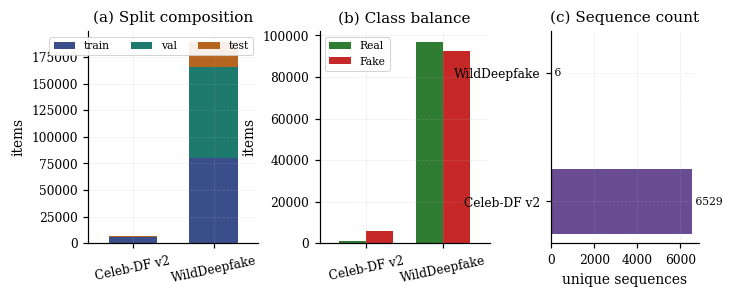

In [ ]:
# ============================ TABLE I + FIG. 1 : DATASET STATISTICS ============================
stat_rows = []
for key, df in INDEX.items():
    for split in ["train", "val", "test"]:
        d = df[df.split == split]
        if len(d) == 0: continue
        stat_rows.append({
            "Dataset": {"celebdf": "Celeb-DF v2", "wilddeepfake": "WildDeepfake"}.get(key, key),
            "Split": split, "Media type": d.kind.iloc[0],
            "Sequences": d.video_id.nunique(),
            "Real": int((d.label == 0).sum()), "Fake": int((d.label == 1).sum()),
            "Total": len(d),
            "Fake ratio (%)": 100.0 * (d.label == 1).mean(),
        })
tab_stats = pd.DataFrame(stat_rows)
save_table(tab_stats, "table1_dataset_statistics", number="I",
           caption="Composition of the benchmarks used in this study. Splits are identity/sequence "
                   "disjoint; for Celeb-DF v2 the official testing list is used.")

fig = plt.figure(figsize=(COL2, 2.5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.15, 1.15, 1.0], wspace=0.38)
ax = fig.add_subplot(gs[0])
piv = tab_stats.pivot_table(index="Dataset", columns="Split", values="Total", aggfunc="sum").fillna(0)
piv = piv[[c for c in ["train", "val", "test"] if c in piv.columns]]
piv.plot(kind="bar", stacked=True, ax=ax, color=["#3B4E8C", "#1F7A6E", "#B5651D"], width=0.6, legend=True)
ax.set_ylabel("items"); ax.set_xlabel(""); ax.set_title("(a) Split composition")
ax.tick_params(axis="x", rotation=12); ax.legend(title="", ncol=3, fontsize=7)

ax = fig.add_subplot(gs[1])
cw = tab_stats.groupby("Dataset")[["Real", "Fake"]].sum()
cw.plot(kind="bar", ax=ax, color=[PALETTE["real"], PALETTE["fake"]], width=0.7)
ax.set_ylabel("items"); ax.set_xlabel(""); ax.set_title("(b) Class balance")
ax.tick_params(axis="x", rotation=12); ax.legend(fontsize=7)

ax = fig.add_subplot(gs[2])
seqs = tab_stats.groupby("Dataset")["Sequences"].sum()
ax.barh(seqs.index, seqs.values, color=PALETTE["semantic"], height=0.5)
for i, v in enumerate(seqs.values):
    ax.text(v, i, f" {int(v)}", va="center", fontsize=7)
ax.set_xlabel("unique sequences"); ax.set_title("(c) Sequence count")
save_fig(fig, "fig1_dataset_distribution", number="1",
         caption="Benchmark composition: (a) split sizes, (b) real/fake balance, (c) unique sequences.")
plt.show()

## 2. Preprocessing

Following the base paper: frames are sampled from each video (stride 24 during training, uniformly
for testing), faces are detected and cropped with a margin, and every crop is resized to 224x224 to
match the native resolution of WildDeepfake. Crops are cached to disk so the extraction runs once.

Detector priority: **MTCNN** (facenet-pytorch, GPU) -> OpenCV DNN -> Haar cascade -> centre crop.

In [ ]:
# ============================ FACE DETECTION + CACHED EXTRACTION ============================
class FaceCropper:
    """Robust face cropper with graceful degradation across three detector backends."""
    def __init__(self, device, size=224, margin=0.30):
        self.size, self.margin, self.backend = size, margin, "center"
        self.det = None
        try:
            from facenet_pytorch import MTCNN
            self.det = MTCNN(keep_all=False, device=device, post_process=False,
                             select_largest=True, min_face_size=40)
            self.backend = "mtcnn"
        except Exception as e:
            print("MTCNN unavailable:", e)
            try:
                cascade = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
                self.det = cv2.CascadeClassifier(cascade)
                self.backend = "haar" if not self.det.empty() else "center"
            except Exception:
                self.backend = "center"
        print("face detector backend:", self.backend)

    def _expand(self, box, W, H):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        cx, cy = x1 + w / 2, y1 + h / 2
        s = max(w, h) * (1 + self.margin)
        x1, y1 = int(max(0, cx - s / 2)), int(max(0, cy - s / 2))
        x2, y2 = int(min(W, cx + s / 2)), int(min(H, cy + s / 2))
        return x1, y1, x2, y2

    def __call__(self, rgb: np.ndarray):
        H, W = rgb.shape[:2]
        box = None
        if self.backend == "mtcnn":
            try:
                boxes, probs = self.det.detect(rgb)
                if boxes is not None and len(boxes) and probs[0] is not None and probs[0] > 0.90:
                    box = boxes[0]
            except Exception:
                box = None
        elif self.backend == "haar":
            g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            faces = self.det.detectMultiScale(g, 1.15, 5, minSize=(40, 40))
            if len(faces):
                x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
                box = [x, y, x + w, y + h]
        if box is None:                      # centre square fallback
            s = min(H, W)
            box = [(W - s) / 2, (H - s) / 2, (W + s) / 2, (H + s) / 2]
        x1, y1, x2, y2 = self._expand(box, W, H)
        crop = rgb[y1:y2, x1:x2]
        if crop.size == 0:
            crop = rgb
        return cv2.resize(crop, (self.size, self.size), interpolation=cv2.INTER_CUBIC)

def sample_frame_indices(n_frames, split, cfg=CFG):
    if split == "train":
        idxs = list(range(0, n_frames, max(1, cfg.TRAIN_FRAME_STRIDE)))
        cap = cfg.MAX_TRAIN_FRAMES_PER_VIDEO
    else:
        cap = cfg.MAX_TEST_FRAMES_PER_VIDEO
        idxs = np.linspace(0, max(0, n_frames - 1), num=min(cap, max(1, n_frames))).astype(int).tolist()
    if len(idxs) > cap:
        idxs = np.linspace(0, len(idxs) - 1, cap).astype(int)
        idxs = [list(range(0, n_frames, max(1, cfg.TRAIN_FRAME_STRIDE)))[i] for i in idxs]
    return sorted(set(int(i) for i in idxs)) or [0]

def extract_faces(df: pd.DataFrame, key: str, cropper: FaceCropper, cfg=CFG,
                  limit_sequences: int = None) -> pd.DataFrame:
    """Extract + cache face crops. Returns a frame-level manifest (one row per cached crop)."""
    out_root = FACE_DIR / key
    out_root.mkdir(parents=True, exist_ok=True)
    manifest_path = out_root / "manifest.csv"
    if manifest_path.exists():
        man = pd.read_csv(manifest_path)
        if len(man):
            print(f"{key}: reusing cached manifest with {len(man)} crops "
                  f"(delete {manifest_path} to force re-extraction)")
            return man

    work = df.copy()
    if limit_sequences:  # QUICK_TEST path
        keep_ids = []
        for _, g in work.groupby(["split", "label"], sort=False):
            keep_ids += list(g.video_id.unique()[:limit_sequences])
        work = work[work.video_id.isin(keep_ids)].reset_index(drop=True)

    rows = []
    for r in tqdm(work.itertuples(), total=len(work), desc=f"faces[{key}]"):
        try:
            sub = out_root / r.split / str(r.label)
            sub.mkdir(parents=True, exist_ok=True)
            base = hashlib.md5(r.rel.encode()).hexdigest()[:12]
            if r.kind == "image":
                img = cv2.imread(r.path)
                if img is None: continue
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # WildDeepfake crops are already tight faces; re-detect only if large
                face = cropper(rgb) if max(rgb.shape[:2]) > 300 else cv2.resize(rgb, (cfg.IMG_SIZE,)*2)
                op = sub / f"{base}_0.jpg"
                cv2.imwrite(str(op), cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                            [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                rows.append({"dataset": key, "face": str(op), "label": r.label,
                             "video_id": r.video_id, "split": r.split, "frame": 0,
                             "identity": r.identity, "src": r.path})
            else:
                cap = cv2.VideoCapture(r.path)
                n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                if n <= 0:
                    cap.release(); continue
                want = sample_frame_indices(n, r.split, cfg)
                for fi in want:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
                    ok, frame = cap.read()
                    if not ok: continue
                    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    face = cropper(rgb)
                    op = sub / f"{base}_{fi:05d}.jpg"
                    cv2.imwrite(str(op), cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                                [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                    rows.append({"dataset": key, "face": str(op), "label": r.label,
                                 "video_id": r.video_id, "split": r.split, "frame": fi,
                                 "identity": r.identity, "src": r.path})
                cap.release()
        except Exception as e:
            continue
    man = pd.DataFrame(rows)
    if len(man) == 0:
        raise RuntimeError(
            f"No face crops were produced for '{key}'. Check that the files under "
            f"{df.path.iloc[0] if len(df) else '?'} are readable and that OpenCV can decode them.")
    man.to_csv(manifest_path, index=False)
    print(f"{key}: cached {len(man)} face crops -> {out_root}")
    return man

cropper = FaceCropper(DEVICE, CFG.IMG_SIZE, CFG.FACE_MARGIN)
FRAMES = {}
for key, df in INDEX.items():
    FRAMES[key] = extract_faces(df, key, cropper,
                                limit_sequences=6 if CFG.QUICK_TEST else None)
    d = FRAMES[key]
    print(f"  {key}: {len(d)} crops | "
          + str(d.groupby(['split', 'label']).size().to_dict()))

MTCNN unavailable: No module named 'torch.utils.serialization'
face detector backend: center


faces[celebdf]:   0%|          | 0/6529 [00:00<?, ?it/s]

celebdf: cached 121175 face crops -> /content/NIT-PATNA-P2/fsttnet/faces/celebdf
  celebdf: 121175 crops | {('test', 0): 5696, ('test', 1): 10880, ('train', 0): 10962, ('train', 1): 77925, ('val', 0): 2080, ('val', 1): 13632}


faces[wilddeepfake]:   0%|          | 0/189713 [00:00<?, ?it/s]

wilddeepfake: cached 189713 face crops -> /content/NIT-PATNA-P2/fsttnet/faces/wilddeepfake
  wilddeepfake: 189713 crops | {('test', 0): 11538, ('test', 1): 12578, ('train', 1): 80080, ('val', 0): 85517}


[FIG 2] fig2_sample_faces  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig2_sample_faces.png


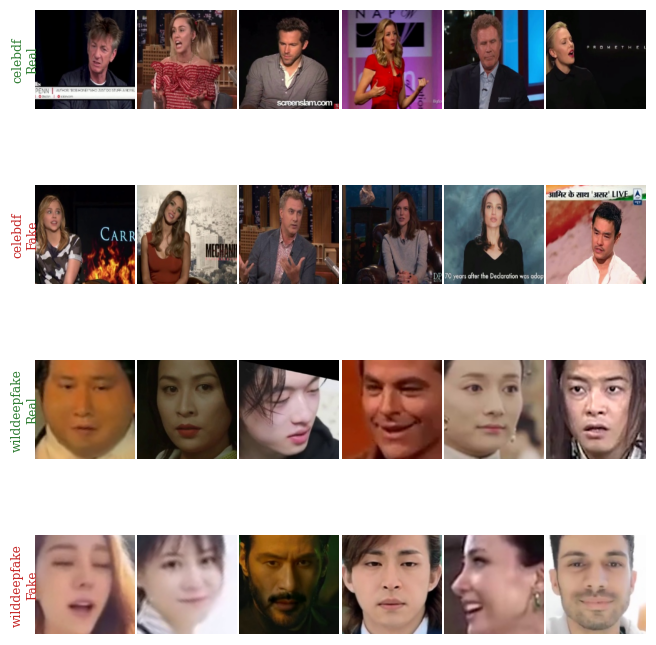

In [ ]:
# ============================ FIG. 2 : SAMPLE FACE CROPS ============================
def _load_rgb(p, size=None):
    im = cv2.imread(str(p))
    if im is None: return None
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    return cv2.resize(im, (size, size)) if size else im

key0 = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
man0 = FRAMES[key0]
n_show = 6
fig, axes = plt.subplots(2 * len(FRAMES), n_show, figsize=(COL2, 2.05 * 2 * len(FRAMES)))
axes = np.atleast_2d(axes)
r = 0
for key, man in FRAMES.items():
    for lab, name in [(0, "Real"), (1, "Fake")]:
        sub = man[man.label == lab].sample(min(n_show, (man.label == lab).sum()),
                                           random_state=CFG.SEED)
        for c in range(n_show):
            ax = axes[r, c]; ax.axis("off"); ax.grid(False)
            if c < len(sub):
                img = _load_rgb(sub.iloc[c].face, 160)
                if img is not None: ax.imshow(img)
            if c == 0:
                ax.text(-0.10, 0.5, f"{key}\n{name}", transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=8,
                        color=PALETTE["real"] if lab == 0 else PALETTE["fake"])
        r += 1
plt.subplots_adjust(wspace=0.03, hspace=0.03)
save_fig(fig, "fig2_sample_faces", number="2",
         caption="Representative aligned face crops from each benchmark. Forgery traces are locally "
                 "subtle and vary strongly with the manipulation family, motivating the joint "
                 "spatial-frequency-semantic design of FSTT-Net.")
plt.show()

## 3. Facial semantic prior and frequency decomposition

The base paper obtains the facial semantic map from a SegNeXt parser pre-trained on CelebAMask-HQ.
That dependency is heavy and its licence complicates reproduction, so FSTT-Net uses a
**detector-free geometric semantic prior**: a soft multi-region map (background / skin / eyes /
nose / mouth) built from MediaPipe FaceMesh landmarks when available, and from a canonical
anisotropic template on aligned crops otherwise. The map plays exactly the role of `Y` in Eqs. (2)-(3)
of the base paper, and Sec. 10 ablates it away.

In [ ]:
# ============================ SEMANTIC PRIOR GENERATOR ============================
REGION_NAMES = ["background", "skin", "eyes", "nose", "mouth"]
N_REGIONS = len(REGION_NAMES)

class SemanticPrior:
    """Returns an (N_REGIONS, H, W) soft one-hot facial region map in [0,1]."""
    def __init__(self, size=224, use_mediapipe=True):
        self.size = size
        self.mp = None
        if use_mediapipe:
            try:
                import mediapipe as mp
                self.mp = mp.solutions.face_mesh.FaceMesh(static_image_mode=True,
                                                          max_num_faces=1, refine_landmarks=True)
                print("semantic prior backend: mediapipe FaceMesh")
            except Exception as e:
                print("mediapipe unavailable -> canonical template prior")
        self._template = self._build_template(size)

    @staticmethod
    def _ellipse_mask(size, cx, cy, rx, ry, soft=0.06):
        yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
        d = ((xx - cx) / max(rx, 1e-6)) ** 2 + ((yy - cy) / max(ry, 1e-6)) ** 2
        return np.clip(1.0 - (d - 1.0) / soft, 0, 1).astype(np.float32)

    def _build_template(self, size):
        m = np.zeros((N_REGIONS, size, size), np.float32)
        m[1] = self._ellipse_mask(size, 0.50, 0.54, 0.34, 0.44, 0.20)        # skin oval
        eyes = np.maximum(self._ellipse_mask(size, 0.355, 0.42, 0.095, 0.055),
                          self._ellipse_mask(size, 0.645, 0.42, 0.095, 0.055))
        m[2] = eyes
        m[3] = self._ellipse_mask(size, 0.50, 0.545, 0.075, 0.115)           # nose
        m[4] = self._ellipse_mask(size, 0.50, 0.715, 0.135, 0.070)           # mouth
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        return m / (m.sum(0, keepdims=True) + 1e-6)

    def _from_landmarks(self, rgb):
        res = self.mp.process(rgb)
        if not res.multi_face_landmarks:
            return None
        H, W = rgb.shape[:2]
        pts = np.array([[p.x * W, p.y * H] for p in res.multi_face_landmarks[0].landmark], np.float32)
        IDX = {
            "skin":  list(range(0, 468)),
            "eyes":  [33,133,160,159,158,157,173,246,161,144,145,153,154,155,
                      362,263,387,386,385,384,398,466,388,373,374,380,381,382],
            "nose":  [1,2,4,5,6,19,94,97,98,115,168,195,197,326,327,344,440],
            "mouth": [0,13,14,17,37,39,40,61,78,80,81,82,84,87,88,91,95,146,178,181,185,
                      191,267,269,270,291,308,310,311,312,314,317,318,321,324,375,402,405,409,415],
        }
        m = np.zeros((N_REGIONS, H, W), np.float32)
        for ri, name in [(1, "skin"), (2, "eyes"), (3, "nose"), (4, "mouth")]:
            p = pts[IDX[name]].astype(np.int32)
            if len(p) < 3: continue
            hull = cv2.convexHull(p)
            canvas = np.zeros((H, W), np.uint8)
            cv2.fillConvexPoly(canvas, hull, 1)
            m[ri] = cv2.GaussianBlur(canvas.astype(np.float32), (0, 0), 3.0)
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        m = m / (m.sum(0, keepdims=True) + 1e-6)
        if H != self.size or W != self.size:
            m = np.stack([cv2.resize(x, (self.size, self.size)) for x in m])
        return m.astype(np.float32)

    def __call__(self, rgb: np.ndarray) -> np.ndarray:
        if self.mp is not None:
            try:
                m = self._from_landmarks(rgb)
                if m is not None: return m
            except Exception:
                pass
        return self._template.copy()

SEMPRIOR = SemanticPrior(CFG.IMG_SIZE)

# ============================ FREQUENCY DECOMPOSITION ============================
SRM_KERNELS = np.array([
    [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],
    [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],
    [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],
], np.float32)
SRM_KERNELS = SRM_KERNELS / np.array([4.0, 12.0, 2.0], np.float32)[:, None, None]

def dct2(a):
    return dct(dct(a, axis=0, norm="ortho"), axis=1, norm="ortho")

def dct_band_maps(gray: np.ndarray, n_bands=3):
    """Split the block-DCT spectrum into low / mid / high radial bands (F3-Net style)."""
    h, w = gray.shape
    c = dct2(gray.astype(np.float32) / 255.0)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    edges = np.linspace(0, 1, n_bands + 1)
    out = []
    for i in range(n_bands):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        band = c * mask
        rec = dct(dct(band, axis=0, type=3, norm="ortho"), axis=1, type=3, norm="ortho")
        out.append(rec)
    return np.stack(out), c

def srm_residual(rgb: np.ndarray):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    return np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS])

mediapipe unavailable -> canonical template prior


[FIG 3] fig3_preprocessing_pipeline  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig3_preprocessing_pipeline.png


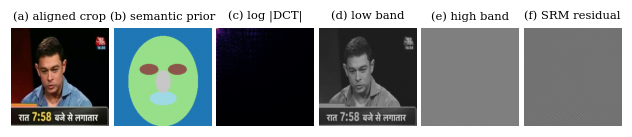

[FIG 4] fig4_semantic_prior  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig4_semantic_prior.png


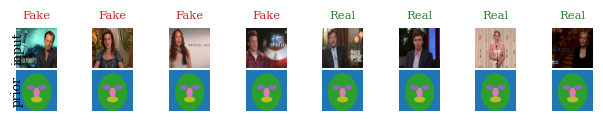

In [ ]:
# ============================ FIG. 3 : PREPROCESSING PIPELINE ============================
sample = FRAMES[key0].sample(1, random_state=7).iloc[0]
rgb = _load_rgb(sample.face, CFG.IMG_SIZE)
sem = SEMPRIOR(rgb)
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
bands, spectrum = dct_band_maps(gray)
srm = srm_residual(rgb)

fig, axes = plt.subplots(1, 6, figsize=(COL2, 1.55))
panels = [
    (rgb, "(a) aligned crop", None),
    (np.argmax(sem, 0), "(b) semantic prior", "tab20"),
    (np.log1p(np.abs(spectrum)), "(c) log |DCT|", "magma"),
    (bands[0], "(d) low band", "gray"),
    (bands[2], "(e) high band", "gray"),
    (srm[1], "(f) SRM residual", "gray"),
]
for ax, (im, title, cmap) in zip(axes, panels):
    ax.imshow(im, cmap=cmap); ax.set_title(title, fontsize=7.5); ax.axis("off"); ax.grid(False)
plt.subplots_adjust(wspace=0.05)
save_fig(fig, "fig3_preprocessing_pipeline", number="3",
         caption="Preprocessing chain of FSTT-Net: face alignment, geometric facial semantic prior, "
                 "block-DCT spectrum, radial low/high sub-bands and SRM noise residual. The last four "
                 "panels feed the frequency stream; the second panel guides semantic token scoring.")
plt.show()

# ============================ FIG. 4 : SEMANTIC PRIOR ACROSS SAMPLES ============================
sub = sample_by_group(FRAMES[key0], "label", n=4, seed=3)
fig, axes = plt.subplots(2, len(sub), figsize=(COL2, 2 * COL2 / max(len(sub), 1) * 0.55))
axes = np.atleast_2d(axes)
for j, (_, r) in enumerate(sub.iterrows()):
    im = _load_rgb(r.face, CFG.IMG_SIZE)
    m = SEMPRIOR(im)
    axes[0, j].imshow(im); axes[0, j].axis("off"); axes[0, j].grid(False)
    axes[0, j].set_title("Real" if r.label == 0 else "Fake", fontsize=7.5,
                         color=PALETTE["real"] if r.label == 0 else PALETTE["fake"])
    axes[1, j].imshow(np.argmax(m, 0), cmap="tab20", vmin=0, vmax=N_REGIONS)
    axes[1, j].axis("off"); axes[1, j].grid(False)
axes[0, 0].text(-0.12, 0.5, "input", transform=axes[0, 0].transAxes, rotation=90, va="center", fontsize=8)
axes[1, 0].text(-0.12, 0.5, "prior", transform=axes[1, 0].transAxes, rotation=90, va="center", fontsize=8)
plt.subplots_adjust(wspace=0.03, hspace=0.05)
save_fig(fig, "fig4_semantic_prior", number="4",
         caption="Facial semantic priors (background / skin / eyes / nose / mouth) produced without a "
                 "pre-trained parsing network. These maps supply Y in the density term of Eq. (2).")
plt.show()

[FIG 5] fig5_frequency_evidence  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig5_frequency_evidence.png


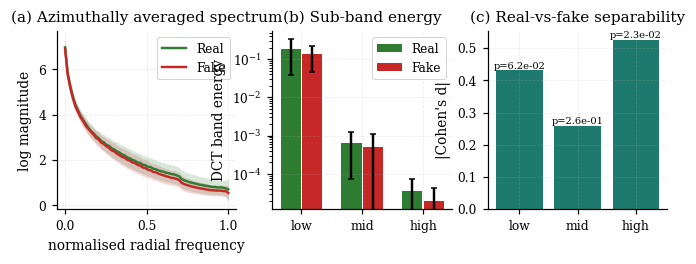

In [ ]:
# ============================ FIG. 5 : FREQUENCY-DOMAIN EVIDENCE ============================
def radial_spectrum(gray, nbins=64):
    f = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32) / 255.0))
    mag = np.log1p(np.abs(f))
    h, w = mag.shape
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt((yy - h / 2) ** 2 + (xx - w / 2) ** 2)
    rb = (r / r.max() * (nbins - 1)).astype(int)
    return np.array([mag[rb == i].mean() for i in range(nbins)])

n_spec = 40 if not CFG.QUICK_TEST else 8
curves = {0: [], 1: []}
band_energy = {0: [], 1: []}
for lab in [0, 1]:
    s = FRAMES[key0][FRAMES[key0].label == lab].sample(
        min(n_spec, int((FRAMES[key0].label == lab).sum())), random_state=11)
    for _, r in s.iterrows():
        im = _load_rgb(r.face, CFG.IMG_SIZE)
        if im is None: continue
        g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
        curves[lab].append(radial_spectrum(g))
        b, _ = dct_band_maps(g)
        band_energy[lab].append([float(np.mean(x ** 2)) for x in b])

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.1))
ax = axes[0]
for lab, name, col in [(0, "Real", PALETTE["real"]), (1, "Fake", PALETTE["fake"])]:
    if not curves[lab]: continue
    arr = np.stack(curves[lab]); m, s = arr.mean(0), arr.std(0)
    x = np.linspace(0, 1, len(m))
    ax.plot(x, m, color=col, label=name)
    ax.fill_between(x, m - s, m + s, color=col, alpha=0.18, linewidth=0)
ax.set_xlabel("normalised radial frequency"); ax.set_ylabel("log magnitude")
ax.set_title("(a) Azimuthally averaged spectrum"); ax.legend()

ax = axes[1]
be = {k: np.array(v) for k, v in band_energy.items() if len(v)}
labels = ["low", "mid", "high"]
xpos = np.arange(3)
for i, (lab, col) in enumerate([(0, PALETTE["real"]), (1, PALETTE["fake"])]):
    if lab not in be: continue
    ax.bar(xpos + (i - 0.5) * 0.35, be[lab].mean(0), 0.33, yerr=be[lab].std(0),
           color=col, capsize=2, label="Real" if lab == 0 else "Fake")
ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_yscale("log")
ax.set_ylabel("DCT band energy"); ax.set_title("(b) Sub-band energy"); ax.legend()

ax = axes[2]
if 0 in be and 1 in be:
    for i, name in enumerate(labels):
        t, p = stats.ttest_ind(be[0][:, i], be[1][:, i], equal_var=False)
        d = ((be[1][:, i].mean() - be[0][:, i].mean()) /
             (np.sqrt((be[0][:, i].var() + be[1][:, i].var()) / 2) + 1e-12))
        ax.bar(i, abs(d), color=PALETTE["freq"])
        ax.text(i, abs(d), f"p={p:.1e}", ha="center", va="bottom", fontsize=6.5)
    ax.set_xticks(range(3)); ax.set_xticklabels(labels)
    ax.set_ylabel("|Cohen's d|"); ax.set_title("(c) Real-vs-fake separability")
save_fig(fig, "fig5_frequency_evidence", number="5",
         caption="Frequency-domain motivation for the spectral stream. Manipulated faces deviate from "
                 "pristine ones mainly in the mid/high DCT sub-bands, and the effect size grows with "
                 "radial frequency.")
plt.show()

## 4. Forensic descriptor extraction and feature selection

Before the deep model, a classical forensic descriptor is extracted per crop
(DCT band energies, SRM residual statistics, LBP histogram, colour moments, blur / noise metrics).
Three selectors - mutual information, ANOVA F, and RFE on a linear model - agree on a compact
subset; the retained bands are what initialises the learnable band weights of the frequency stream.
This section gives the paper its **feature-selection** analysis (Fig. 6, Table II).

descriptors:   0%|          | 0/500 [00:00<?, ?it/s]

descriptor matrix: (500, 43)
[TABLE II] table2_feature_selection  ->  /content/NIT-PATNA-P2/fsttnet/tables/table2_feature_selection.csv


,Feature,MI,ANOVA F,p-value,RF Gini,RFE rank,Rank score
42,chroma_corr,0.0295,19.6001,0.0000,0.0595,1,4.625
0,dct_low_energy,0.0243,4.5550,0.0333,0.0269,1,9.625
25,lbp_8,0.0149,2.4784,0.1161,0.0293,1,10.375
41,sobel_y_mean,0.0571,1.5627,0.2119,0.0262,1,10.625
21,lbp_4,0.0349,0.9944,0.3192,0.0264,1,12.375
5,dct_high_std,0.0274,2.5242,0.1127,0.0207,1,14.375
1,dct_low_std,0.0283,2.5389,0.1117,0.0293,17,14.500
15,srm2_kurt,0.0221,1.2176,0.2704,0.0254,1,15.125
16,srm2_skew,0.0000,1.2305,0.2678,0.0344,1,15.625
23,lbp_6,0.0023,0.6316,0.4272,0.0301,1,16.375


[FIG 6] fig6_feature_selection  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig6_feature_selection.png


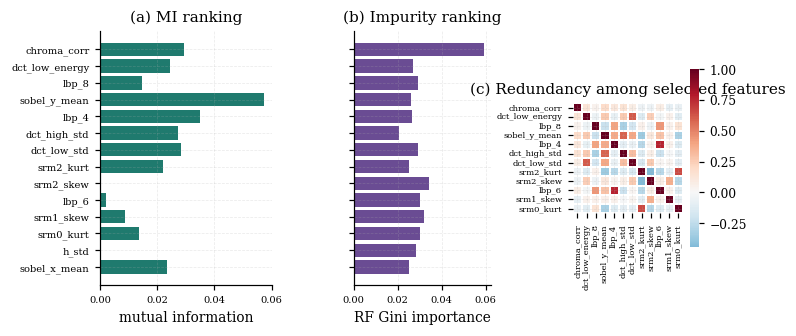

handcrafted descriptor + RF, 5-fold AUC = 0.6416 +/- 0.0849


In [ ]:
# ============================ HANDCRAFTED FORENSIC DESCRIPTORS ============================
def lbp_hist(gray, P=8, R=1, bins=16):
    try:
        from skimage.feature import local_binary_pattern
        lbp = local_binary_pattern(gray, P, R, method="uniform")
        h, _ = np.histogram(lbp, bins=bins, range=(0, P + 2), density=True)
        return h
    except Exception:
        h, _ = np.histogram(cv2.Laplacian(gray, cv2.CV_32F), bins=bins, density=True)
        return h

def forensic_descriptor(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    feats, names = [], []
    bands, spec = dct_band_maps(g, 3)
    for i, nm in enumerate(["low", "mid", "high"]):
        feats += [float(np.mean(bands[i] ** 2)), float(np.std(bands[i]))]
        names += [f"dct_{nm}_energy", f"dct_{nm}_std"]
    spec_a = np.abs(spec)
    feats += [float(spec_a[:8, :8].sum() / (spec_a.sum() + 1e-9)),
              float(spec_a[-32:, -32:].sum() / (spec_a.sum() + 1e-9))]
    names += ["dct_dc_ratio", "dct_hf_ratio"]
    res = srm_residual(rgb)
    for i in range(res.shape[0]):
        feats += [float(res[i].std()), float(stats.kurtosis(res[i].ravel())),
                  float(stats.skew(res[i].ravel()))]
        names += [f"srm{i}_std", f"srm{i}_kurt", f"srm{i}_skew"]
    h = lbp_hist(g)
    feats += list(h); names += [f"lbp_{i}" for i in range(len(h))]
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    for ci, cn in enumerate("hsv"):
        feats += [float(hsv[..., ci].mean()), float(hsv[..., ci].std())]
        names += [f"{cn}_mean", f"{cn}_std"]
    feats += [float(cv2.Laplacian(g, cv2.CV_64F).var()),
              float(np.mean(np.abs(cv2.Sobel(g, cv2.CV_32F, 1, 0, 3)))),
              float(np.mean(np.abs(cv2.Sobel(g, cv2.CV_32F, 0, 1, 3))))]
    names += ["laplacian_var", "sobel_x_mean", "sobel_y_mean"]
    ycc = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    feats += [float(np.corrcoef(ycc[..., 1].ravel(), ycc[..., 2].ravel())[0, 1])]
    names += ["chroma_corr"]
    return np.nan_to_num(np.array(feats, np.float32)), names

n_desc = 250 if not CFG.QUICK_TEST else 40
desc_df = sample_by_group(FRAMES[key0], "label", n=n_desc, seed=CFG.SEED)
X, y, FEAT_NAMES = [], [], None
for _, r in tqdm(desc_df.iterrows(), total=len(desc_df), desc="descriptors"):
    im = _load_rgb(r.face, CFG.IMG_SIZE)
    if im is None: continue
    f, FEAT_NAMES = forensic_descriptor(im)
    X.append(f); y.append(r.label)
X = np.stack(X); y = np.array(y)
Xs = StandardScaler().fit_transform(X)
print("descriptor matrix:", X.shape)

mi = mutual_info_classif(Xs, y, random_state=CFG.SEED)
fval, pval = f_classif(Xs, y)
rf = RandomForestClassifier(n_estimators=300, random_state=CFG.SEED, n_jobs=-1).fit(Xs, y)
gini = rf.feature_importances_
k_keep = min(20, Xs.shape[1])
rfe = RFE(LogisticRegression(max_iter=2000), n_features_to_select=k_keep).fit(Xs, y)

fs = pd.DataFrame({"Feature": FEAT_NAMES, "MI": mi, "ANOVA F": fval, "p-value": pval,
                   "RF Gini": gini, "RFE rank": rfe.ranking_})
fs["Rank score"] = (fs.MI.rank(ascending=False) + fs["ANOVA F"].rank(ascending=False)
                    + fs["RF Gini"].rank(ascending=False) + fs["RFE rank"].rank()) / 4.0
fs = fs.sort_values("Rank score")
SELECTED_FEATURES = fs.head(k_keep).Feature.tolist()

save_table(fs.head(20).round(4), "table2_feature_selection", number="II",
           caption="Top-20 forensic descriptors ranked by the consensus of mutual information, "
                   "ANOVA F, random-forest Gini importance and recursive feature elimination.")

fig = plt.figure(figsize=(COL2, 3.0))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.25, 1.0, 1.0], wspace=0.55)
ax = fig.add_subplot(gs[0])
top = fs.head(14).iloc[::-1]
ax.barh(top.Feature, top.MI, color=PALETTE["freq"])
ax.set_xlabel("mutual information"); ax.set_title("(a) MI ranking"); ax.tick_params(labelsize=6.5)
ax = fig.add_subplot(gs[1])
ax.barh(top.Feature, top["RF Gini"], color=PALETTE["semantic"])
ax.set_xlabel("RF Gini importance"); ax.set_title("(b) Impurity ranking")
ax.set_yticklabels([]); ax.tick_params(labelsize=6.5)
ax = fig.add_subplot(gs[2])
order = fs.head(12).Feature.tolist()
cm = np.corrcoef(Xs[:, [FEAT_NAMES.index(f) for f in order]].T)
sns.heatmap(cm, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.7},
            xticklabels=order, yticklabels=order, square=True, linewidths=0.3)
ax.set_title("(c) Redundancy among selected features")
ax.tick_params(labelsize=5.5)
save_fig(fig, "fig6_feature_selection", number="6",
         caption="Feature-selection analysis of the handcrafted forensic descriptor. High-frequency "
                 "DCT ratios and SRM residual statistics dominate both rankings and are only weakly "
                 "correlated, which justifies the learnable multi-band frequency tokeniser.")
plt.show()

# a classical baseline that also serves as a sanity check on the descriptor
from sklearn.model_selection import cross_val_score
cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=CFG.SEED, n_jobs=-1),
                     Xs[:, [FEAT_NAMES.index(f) for f in SELECTED_FEATURES]], y, cv=5, scoring="roc_auc")
print(f"handcrafted descriptor + RF, 5-fold AUC = {cv.mean():.4f} +/- {cv.std():.4f}")
HANDCRAFTED_AUC = float(cv.mean())

## 5. Proposed method: FSTT-Net

### 5.1 Positioning against the base paper

| Component | STT (base paper, TIFS'25) | **FSTT-Net (this work)** |
|---|---|---|
| Token domain | spatial only | **spatial + frequency (DCT sub-bands + SRM), fused by cross-domain attention** |
| Semantic map | SegNeXt parser pre-trained on CelebAMask-HQ | **detector-free geometric prior (MediaPipe / canonical template)** - no parsing network |
| Token score | density x distance only (Eqs. 1-5) | density x distance **+ a learnable Semantic-Feature scoring head**, so the score is trained end-to-end |
| Semantic coefficient alpha | fixed, grid-searched (0.2) | **predicted per image by a gating MLP** (`ADAPTIVE_ALPHA`) |
| Temporal modelling | none (frame level) | **temporal token propagation over a T-frame clip + temporal-difference cue** |
| Supervision | cross-entropy | CE + focal + single-centre + **cross-domain consistency** + cluster-diversity |
| Decision | frame level | frame **and** video level (mean / median / top-k pooling) |

Equations (1)-(7) of the base paper are re-implemented verbatim in `dpc_knn_cluster`,
`merge_tokens` and `SerialBlock`, so the ablation in Sec. 10 that switches every FSTT-Net
addition off is a faithful reproduction of STT and forms the controlled baseline.

In [ ]:
# ============================ CORE TOKEN OPERATORS (Eqs. 1-7) ============================
from timm.layers import DropPath, trunc_normal_

def index_points(points, idx):
    """Gather along dim 1. points (B,N,C) | idx (B,S) -> (B,S,C)"""
    B = points.shape[0]
    view_shape = [B] + [1] * (idx.dim() - 1)
    rep = [1] + list(idx.shape[1:])
    bidx = torch.arange(B, device=points.device, dtype=torch.long).view(view_shape).repeat(rep)
    return points[bidx, idx, :]

@torch.no_grad()
def dpc_knn_cluster(x, sem, k, cluster_num, alpha):
    """Density-peak clustering with k-NN density (base paper Eqs. 1-5).

    x     : (B,N,C) token features        -> rho_x  (Eq. 1)
    sem   : (B,N,R) semantic token values -> rho_y  (Eq. 2)
    alpha : float or (B,1) tensor         -> rho    (Eq. 3)
    returns idx_cluster (B,N), centre indices (B,M), score (B,N)
    """
    B, N, C = x.shape
    xf = x.float()
    dist = torch.cdist(xf, xf) / (C ** 0.5)                     # (B,N,N)
    kk = min(k, N)
    knn_d, _ = dist.topk(kk, dim=-1, largest=False)
    rho_x = torch.exp(-(knn_d ** 2).mean(-1))                   # Eq. 1
    if sem is not None:
        semf = sem.float()
        dsem = torch.cdist(semf, semf) / (sem.shape[-1] ** 0.5)
        knn_s, _ = dsem.topk(kk, dim=-1, largest=False)
        rho_y = torch.exp(-(knn_s ** 2).mean(-1))               # Eq. 2
        a = alpha if torch.is_tensor(alpha) else torch.full((B, 1), float(alpha), device=x.device)
        a = a.view(B, 1).float()
        rho = (1 - a) * rho_x + a * rho_y                       # Eq. 3
    else:
        rho = rho_x
    rho = rho + 1e-6 * torch.rand_like(rho)                     # break ties

    # delta_i = min distance to a token with strictly higher density (Eq. 4)
    higher = rho[:, None, :] > rho[:, :, None]
    dmax = dist.flatten(1).max(-1)[0][:, None, None]
    delta, _ = (dist * higher + dmax * (~higher)).min(dim=-1)
    score = rho * delta                                         # Eq. 5

    M = min(cluster_num, N)
    _, centers = torch.topk(score, k=M, dim=-1)                 # cluster centres
    d_to_center = index_points(dist, centers)                   # (B,M,N)
    idx_cluster = d_to_center.argmin(dim=1)                     # (B,N)
    bidx = torch.arange(B, device=x.device)[:, None]
    idx_cluster[bidx, centers] = torch.arange(M, device=x.device)[None, :].expand(B, -1)
    return idx_cluster, M, score, centers

def merge_tokens(x, idx_cluster, M, weight, extra=None):
    """Importance-weighted token merging (base paper Eq. 6)."""
    B, N, C = x.shape
    w = weight.exp()[..., None] if weight is not None else x.new_ones(B, N, 1)
    idx_batch = torch.arange(B, device=x.device)[:, None]
    idx = (idx_cluster + idx_batch * M).reshape(-1)             # flat cluster id

    all_w = x.new_zeros(B * M, 1).index_add_(0, idx, w.reshape(B * N, 1))
    all_w = all_w + 1e-6
    norm_w = w / all_w[idx].reshape(B, N, 1)

    merged = x.new_zeros(B * M, C).index_add_(0, idx, (x * norm_w).reshape(B * N, C))
    merged = merged.reshape(B, M, C)

    size = x.new_zeros(B * M, 1).index_add_(0, idx, x.new_ones(B * N, 1)).reshape(B, M, 1)
    out_extra = None
    if extra is not None:
        E = extra.shape[-1]
        out_extra = x.new_zeros(B * M, E).index_add_(0, idx, (extra * norm_w).reshape(B * N, E))
        out_extra = out_extra.reshape(B, M, E)
    return merged, out_extra, size

class SFScoringNet(nn.Module):
    """Semantic-Feature scoring network. Differentiable importance score with a learnable,
    optionally image-adaptive semantic control coefficient alpha (FSTT-Net contribution)."""
    def __init__(self, dim, sem_dim=N_REGIONS, adaptive=True, alpha_init=0.2):
        super().__init__()
        self.adaptive = adaptive
        self.feat_score = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim // 2),
                                        nn.GELU(), nn.Linear(dim // 2, 1))
        self.sem_score = nn.Sequential(nn.LayerNorm(sem_dim), nn.Linear(sem_dim, dim // 2),
                                       nn.GELU(), nn.Linear(dim // 2, 1))
        self.alpha_gate = nn.Sequential(nn.LayerNorm(dim + sem_dim), nn.Linear(dim + sem_dim, 32),
                                        nn.GELU(), nn.Linear(32, 1))
        self.alpha_bias = nn.Parameter(torch.tensor(math.log(alpha_init / (1 - alpha_init))))

    def forward(self, x, sem):
        s_x = self.feat_score(x).squeeze(-1)                    # (B,N)
        s_y = self.sem_score(sem).squeeze(-1)
        g = torch.cat([x.mean(1), sem.mean(1)], -1)
        if self.adaptive:
            alpha = torch.sigmoid(self.alpha_gate(g) + self.alpha_bias)     # (B,1)
        else:
            alpha = torch.sigmoid(self.alpha_bias).expand(x.shape[0], 1)
        s = (1 - alpha) * s_x + alpha * s_y
        return s, alpha

class SerialBlock(nn.Module):
    """Cluster-to-token cross attention with the token-score bias of Eq. (7), then self-attention
    and an MLP over the merged tokens."""
    def __init__(self, dim, heads, mlp_ratio=4.0, drop_path=0.0):
        super().__init__()
        self.h, self.scale = heads, (dim // heads) ** -0.5
        self.n1q, self.n1kv = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.q = nn.Linear(dim, dim); self.kv = nn.Linear(dim, 2 * dim); self.proj = nn.Linear(dim, dim)
        self.n2 = nn.LayerNorm(dim)
        self.sa = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n3 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, q_tokens, kv_tokens, score_bias):
        B, M, C = q_tokens.shape
        N = kv_tokens.shape[1]
        q = self.q(self.n1q(q_tokens)).reshape(B, M, self.h, C // self.h).transpose(1, 2)
        kv = self.kv(self.n1kv(kv_tokens)).reshape(B, N, 2, self.h, C // self.h).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if score_bias is not None:                               # + S in Eq. (7)
            attn = attn + score_bias[:, None, None, :]
        attn = attn.softmax(-1)
        out = (attn @ v).transpose(1, 2).reshape(B, M, C)
        x = q_tokens + self.dp(self.proj(out))
        h = self.n2(x); x = x + self.dp(self.sa(h, h, h, need_weights=False)[0])
        x = x + self.dp(self.mlp(self.n3(x)))
        return x

class CrossDomainFusion(nn.Module):
    """Bidirectional spatial <-> frequency token attention with a learned gate (contribution 1)."""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.a1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.a2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n1, self.n2, self.n3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.gate = nn.Sequential(nn.Linear(2 * dim, dim), nn.Sigmoid())
        self.proj = nn.Linear(2 * dim, dim)

    def forward(self, xs, xf):
        s2f = self.a1(self.n1(xs), self.n2(xf), self.n2(xf), need_weights=False)[0]
        f2s = self.a2(self.n2(xf), self.n1(xs), self.n1(xs), need_weights=False)[0]
        xs_e, xf_e = xs + s2f, xf + f2s
        g = self.gate(torch.cat([xs_e, xf_e], -1))
        fused = self.proj(torch.cat([g * xs_e, (1 - g) * xf_e], -1))
        return self.n3(fused), xs_e, xf_e

class TemporalTokenPropagation(nn.Module):
    """Temporal transformer over per-frame cluster summaries plus an explicit temporal-difference
    cue (contribution 3). Reduces to identity when T = 1."""
    def __init__(self, dim, heads=4, max_t=16):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, max_t, dim)); trunc_normal_(self.pos, std=0.02)
        self.n = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.diff_proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, f):                                        # f: (B,T,C)
        B, T, C = f.shape
        if T == 1:
            return f[:, 0], f.new_zeros(B, C)
        x = f + self.pos[:, :T]
        h = self.n(x); x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(x)
        diff = self.diff_proj((f[:, 1:] - f[:, :-1]).abs().mean(1))
        return x.mean(1) + diff, diff

In [ ]:
# ============================ STEMS ============================
class SpatialStem(nn.Module):
    """Stride-8 convolutional tokeniser. ImageNet-initialised when PRETRAINED_STEM is on."""
    def __init__(self, dim, pretrained=True):
        super().__init__()
        self.backbone = None
        if pretrained:
            try:
                import timm
                self.backbone = timm.create_model("efficientnet_b0", pretrained=True,
                                                  features_only=True, out_indices=(2,))
                ch = self.backbone.feature_info.channels()[-1]
            except Exception as e:
                print("pretrained stem unavailable ->", e)
        if self.backbone is None:
            ch = 64
            self.backbone = nn.Sequential(
                nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
                nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
                nn.Conv2d(64, ch, 3, 2, 1), nn.BatchNorm2d(ch), nn.GELU())
        self.proj = nn.Sequential(nn.Conv2d(ch, dim, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        f = self.backbone(x)
        f = f[-1] if isinstance(f, (list, tuple)) else f
        f = self.proj(f)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)              # (B,N,C)

class FrequencyStem(nn.Module):
    """Tokenises the 6-channel spectral input (3 DCT sub-bands + 3 SRM residuals)."""
    def __init__(self, dim, in_ch=6):
        super().__init__()
        self.band_w = nn.Parameter(torch.ones(in_ch))            # learnable band weighting
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, dim, 3, 2, 1), nn.BatchNorm2d(dim), nn.GELU(),
            nn.Conv2d(dim, dim, 3, 1, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        x = x * self.band_w.view(1, -1, 1, 1)
        f = self.net(x)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)

In [ ]:
# ============================ FSTT-NET ============================
class FSTTNet(nn.Module):
    def __init__(self, cfg=CFG, num_classes=2):
        super().__init__()
        self.cfg = cfg
        dims, heads, depths = cfg.EMBED_DIMS, cfg.NUM_HEADS, cfg.DEPTHS
        self.use_freq, self.use_temporal, self.use_sem = cfg.USE_FREQ_STREAM, cfg.USE_TEMPORAL, cfg.USE_SEMANTIC

        self.spatial_stem = SpatialStem(dims[0], cfg.PRETRAINED_STEM)
        if self.use_freq:
            self.freq_stem = FrequencyStem(dims[0])
            self.fusion = CrossDomainFusion(dims[0], heads=4)

        dpr = torch.linspace(0, cfg.DROP_PATH, sum(depths)).tolist()
        self.scorers, self.blocks, self.downs = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        c = 0
        for i in range(cfg.N_ITERS):
            d_in, d_out = dims[min(i, len(dims) - 1)], dims[min(i + 1, len(dims) - 1)]
            self.scorers.append(SFScoringNet(d_in, N_REGIONS, cfg.ADAPTIVE_ALPHA, cfg.ALPHA))
            self.blocks.append(nn.ModuleList([
                SerialBlock(d_in, heads[min(i, len(heads) - 1)], cfg.MLP_RATIO, dpr[c + j])
                for j in range(depths[min(i, len(depths) - 1)])]))
            self.downs.append(nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity())
            c += depths[min(i, len(depths) - 1)]

        d_final = dims[-1]
        self.norm = nn.LayerNorm(d_final)
        if self.use_temporal:
            self.temporal = TemporalTokenPropagation(d_final, heads=4)
        self.head = nn.Sequential(nn.LayerNorm(d_final), nn.Dropout(0.2), nn.Linear(d_final, num_classes))
        # auxiliary per-stream heads -> used by the cross-domain consistency loss and the ablation
        self.head_s = nn.Linear(dims[0], num_classes)
        self.head_f = nn.Linear(dims[0], num_classes) if self.use_freq else None
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _pool_sem(self, sem, hw):
        return F.adaptive_avg_pool2d(sem, hw).flatten(2).transpose(1, 2)   # (B,N,R)

    def forward_tokens(self, img, freq, sem, want_maps=False):
        """One frame -> pooled feature. Returns aux dict for losses / visualisation."""
        aux = {"alphas": [], "cluster_maps": [], "scores": []}
        xs, hw = self.spatial_stem(img)
        semt = self._pool_sem(sem, hw) if self.use_sem else torch.zeros(
            xs.shape[0], xs.shape[1], N_REGIONS, device=xs.device, dtype=xs.dtype)
        if self.use_freq:
            xf, _ = self.freq_stem(freq)
            if xf.shape[1] != xs.shape[1]:
                xf = F.interpolate(xf.transpose(1, 2), size=xs.shape[1], mode="linear",
                                   align_corners=False).transpose(1, 2)
            x, xs_e, xf_e = self.fusion(xs, xf)
            aux["logit_s"] = self.head_s(xs_e.mean(1))
            aux["logit_f"] = self.head_f(xf_e.mean(1))
        else:
            x = xs
            aux["logit_s"] = self.head_s(xs.mean(1))
            aux["logit_f"] = None

        token_hw = hw
        for i in range(self.cfg.N_ITERS):
            score, alpha = self.scorers[i](x, semt)
            aux["alphas"].append(alpha)
            aux["scores"].append(score)
            M = max(8, int(x.shape[1] * self.cfg.CLUSTER_RATIO))
            idx_cluster, M, dpc_score, centers = dpc_knn_cluster(
                x, semt if self.use_sem else None, self.cfg.KNN_K, M, alpha.detach())
            if want_maps:
                aux["cluster_maps"].append((idx_cluster.detach().cpu(), token_hw, M))
            merged, sem_merged, size = merge_tokens(x, idx_cluster, M, score, extra=semt)
            for blk in self.blocks[i]:
                merged = blk(merged, x, score)
            x = self.downs[i](merged)
            semt = sem_merged if sem_merged is not None else semt
            token_hw = None
        feat = self.norm(x).mean(1)
        return feat, aux

    def forward(self, img, freq=None, sem=None, want_maps=False):
        """img (B,T,3,H,W) or (B,3,H,W)."""
        if img.dim() == 4:
            img = img.unsqueeze(1)
            if freq is not None: freq = freq.unsqueeze(1)
            if sem is not None: sem = sem.unsqueeze(1)
        B, T = img.shape[:2]
        img_f = img.flatten(0, 1)
        freq_f = freq.flatten(0, 1) if freq is not None else torch.zeros_like(img_f[:, :6])
        sem_f = sem.flatten(0, 1) if sem is not None else torch.zeros(
            img_f.shape[0], N_REGIONS, img_f.shape[-2], img_f.shape[-1], device=img_f.device)
        feat, aux = self.forward_tokens(img_f, freq_f, sem_f, want_maps)
        C = feat.shape[-1]
        feat_t = feat.view(B, T, C)
        if self.use_temporal and T > 1:
            pooled, _ = self.temporal(feat_t)
        else:
            pooled = feat_t.mean(1)
        logits = self.head(pooled)
        aux["feat"] = pooled
        aux["logit_s"] = aux["logit_s"].view(B, T, -1).mean(1)
        if aux.get("logit_f") is not None:
            aux["logit_f"] = aux["logit_f"].view(B, T, -1).mean(1)
        return logits, aux

# ---- shape / sanity test ----
_m = FSTTNet(CFG).to(DEVICE).eval()
with torch.no_grad():
    _img = torch.randn(2, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    _frq = torch.randn(2, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    _sem = torch.rand(2, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    _lo, _aux = _m(_img, _frq, _sem)
print("FSTT-Net output:", tuple(_lo.shape),
      "| params: %.2f M" % (sum(p.numel() for p in _m.parameters()) / 1e6),
      "| alpha(sample) = %.3f" % float(_aux["alphas"][0].mean()))
del _m, _img, _frq, _sem
torch.cuda.empty_cache() if torch.cuda.is_available() else None

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

FSTT-Net output: (2, 2) | params: 7.09 M | alpha(sample) = 0.199


In [ ]:
# ============================ LOSSES ============================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, y):
        logp = F.log_softmax(logits, -1)
        p = logp.exp().gather(1, y[:, None]).squeeze(1)
        return (-(1 - p) ** self.gamma * logp.gather(1, y[:, None]).squeeze(1)).mean()

class SingleCenterLoss(nn.Module):
    """Compact real class, margin-separated fake class (Li et al., CVPR'21 style)."""
    def __init__(self, dim, m=0.3):
        super().__init__()
        self.center = nn.Parameter(torch.zeros(dim)); self.m = m
    def forward(self, feat, y):
        d = (feat - self.center[None]).norm(dim=1)
        d_real = d[y == 0].mean() if (y == 0).any() else feat.new_zeros(())
        d_fake = d[y == 1].mean() if (y == 1).any() else feat.new_zeros(())
        return d_real + F.relu(d_real - d_fake + self.m * math.sqrt(feat.shape[1]))

class FSTTLoss(nn.Module):
    def __init__(self, cfg=CFG, feat_dim=None):
        super().__init__()
        self.cfg = cfg
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTH)
        self.focal = FocalLoss(cfg.FOCAL_GAMMA)
        self.center = SingleCenterLoss(feat_dim or cfg.EMBED_DIMS[-1])
    def forward(self, logits, aux, y):
        parts = {}
        parts["ce"] = self.cfg.W_CE * self.ce(logits, y)
        parts["focal"] = self.cfg.W_FOCAL * self.focal(logits, y)
        parts["center"] = self.cfg.W_CENTER * self.center(aux["feat"], y)
        if aux.get("logit_f") is not None:
            ps = F.log_softmax(aux["logit_s"], -1)
            pf = F.softmax(aux["logit_f"], -1)
            parts["consist"] = self.cfg.W_CONSIST * (
                F.kl_div(ps, pf, reduction="batchmean")
                + self.ce(aux["logit_s"], y) + self.ce(aux["logit_f"], y)) / 3.0
        if aux.get("scores"):
            s = aux["scores"][0]
            p = F.softmax(s, -1)
            ent = -(p * (p + 1e-8).log()).sum(-1).mean()
            parts["diverse"] = -self.cfg.W_DIVERSE * ent     # maximise entropy -> balanced clusters
        total = sum(parts.values())
        return total, {k: float(v.detach()) for k, v in parts.items()}

[FIG 7] fig7_architecture  ->  /content/NIT-PATNA-P2/fsttnet/figures/fig7_architecture.png


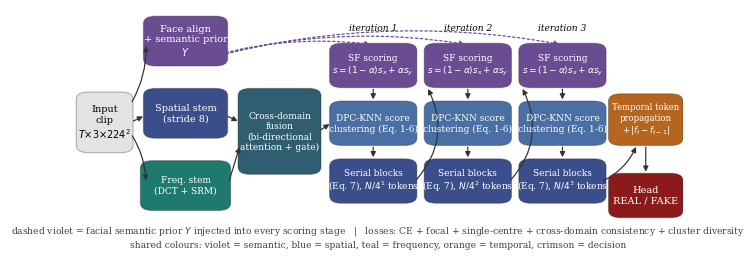

In [ ]:
# ============================ FIG. 7 : ARCHITECTURE DIAGRAM ============================
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _box(ax, x, y, w, h, text, fc, tc="white", fs=6.4, r=0.02):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0.004,rounding_size={r}",
                                linewidth=0.7, edgecolor="#22222255", facecolor=fc))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc, zorder=5)
    return (x + w / 2, y + h / 2)

def _arrow(ax, p1, p2, style="-|>", color="#333333", rad=0.0, lw=0.8, ls="-"):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle=style, mutation_scale=7, linewidth=lw,
                                 color=color, linestyle=ls,
                                 connectionstyle=f"arc3,rad={rad}", shrinkA=2, shrinkB=2))

fig, ax = plt.subplots(figsize=(COL2, 2.9))
ax.set_xlim(0, 1); ax.set_ylim(0.13, 0.81); ax.axis("off"); ax.grid(False)

_box(ax, 0.01, 0.42, 0.085, 0.16, "Input\nclip\n$T{\\times}3{\\times}224^2$", "#33333322", "black")
s1 = _box(ax, 0.12, 0.66, 0.13, 0.13, "Face align\n+ semantic prior\n$Y$", PALETTE["semantic"])
s2 = _box(ax, 0.12, 0.46, 0.13, 0.13, "Spatial stem\n(stride 8)", PALETTE["spatial"])
s3 = _box(ax, 0.115, 0.26, 0.14, 0.13, "Freq. stem\n(DCT + SRM)", PALETTE["freq"], fs=5.9)
_arrow(ax, (0.095, 0.55), (0.12, 0.72), rad=0.15); _arrow(ax, (0.095, 0.50), (0.12, 0.52))
_arrow(ax, (0.095, 0.47), (0.12, 0.33), rad=-0.15)

f1 = _box(ax, 0.275, 0.36, 0.128, 0.23, "Cross-domain\nfusion\n(bi-directional\nattention + gate)", "#2F5E70", fs=5.9)
_arrow(ax, (0.25, 0.52), (0.275, 0.50)); _arrow(ax, (0.255, 0.33), (0.275, 0.44))

x0 = 0.425
for i in range(3):
    x = x0 + i * 0.155
    a = _box(ax, x, 0.60, 0.135, 0.115, f"SF scoring\n$s=(1-\\alpha)s_x+\\alpha s_y$", PALETTE["semantic"], fs=5.9)
    b = _box(ax, x, 0.44, 0.135, 0.115, "DPC-KNN score\nclustering (Eq. 1-6)", "#4A6FA5", fs=5.9)
    c = _box(ax, x, 0.28, 0.135, 0.115, f"Serial blocks\n(Eq. 7), $N/4^{{{i+1}}}$ tokens", "#3B4E8C", fs=5.9)
    _arrow(ax, (x + 0.0675, 0.60), (x + 0.0675, 0.555))
    _arrow(ax, (x + 0.0675, 0.44), (x + 0.0675, 0.395))
    if i == 0:
        _arrow(ax, (0.403, 0.475), (x, 0.50))
    else:
        _arrow(ax, (x - 0.02, 0.335), (x, 0.60), rad=0.35)
    ax.text(x + 0.0675, 0.755, f"iteration {i+1}", ha="center", fontsize=6, style="italic")
    _arrow(ax, (0.12 + 0.065, 0.66), (x + 0.0675, 0.715), rad=-0.12, color="#6A4C93", ls=(0, (2, 2)))

t = _box(ax, 0.882, 0.44, 0.114, 0.135, "Temporal token\npropagation\n$+\\,|f_t-f_{t-1}|$", PALETTE["temporal"], fs=5.6)
_arrow(ax, (0.865, 0.335), (0.925, 0.44), rad=0.2)
h = _box(ax, 0.882, 0.24, 0.114, 0.115, "Head\nREAL / FAKE", PALETTE["proposed"], fs=6.4)
_arrow(ax, (0.939, 0.44), (0.939, 0.355))
ax.text(0.5, 0.195, "dashed violet = facial semantic prior $Y$ injected into every scoring stage   |   "
                   "losses: CE + focal + single-centre + cross-domain consistency + cluster diversity",
        ha="center", fontsize=6, color="#444444")
ax.text(0.5, 0.155, "shared colours: violet = semantic, blue = spatial, teal = frequency, "
                    "orange = temporal, crimson = decision", ha="center", fontsize=6, color="#444444")
save_fig(fig, "fig7_architecture", number="7",
         caption="FSTT-Net. Spatial and spectral tokenisers are fused by a gated bidirectional "
                 "attention block; three iterations of semantic-feature scoring, density-peak token "
                 "clustering and cluster-to-token serial blocks reduce the token set by 4x each time; "
                 "a temporal propagation module aggregates the clip before the decision head.")
plt.show()

In [ ]:
# ============================ TABLE III : MODULE COMPLEXITY ============================
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def module_complexity_table(cfg=CFG):
    m = FSTTNet(cfg)
    rows = [("Spatial stem (stride 8)", count_params(m.spatial_stem))]
    if cfg.USE_FREQ_STREAM:
        rows.append(("Frequency stem (DCT+SRM)", count_params(m.freq_stem)))
        rows.append(("Cross-domain fusion", count_params(m.fusion)))
    rows.append(("SF scoring networks (x3)", count_params(m.scorers)))
    rows.append(("Serial blocks (x3 stages)", count_params(m.blocks)))
    rows.append(("Stage projections", count_params(m.downs)))
    if cfg.USE_TEMPORAL:
        rows.append(("Temporal propagation", count_params(m.temporal)))
    rows.append(("Classification heads", count_params(m.head) + count_params(m.head_s)
                 + (count_params(m.head_f) if m.head_f is not None else 0)))
    tot = count_params(m)
    df = pd.DataFrame(rows, columns=["Module", "Parameters"])
    df["Parameters (M)"] = df.Parameters / 1e6
    df["Share (%)"] = 100 * df.Parameters / tot
    df = df.drop(columns=["Parameters"])
    df.loc[len(df)] = ["Total", tot / 1e6, 100.0]
    del m
    return df

tab_mod = module_complexity_table()
save_table(tab_mod.round(3), "table3_module_complexity", number="III",
           caption="Parameter budget of FSTT-Net by module.")

[TABLE III] table3_module_complexity  ->  /content/NIT-PATNA-P2/fsttnet/tables/table3_module_complexity.csv


,Module,Parameters (M),Share (%)
0,Spatial stem (stride 8),3.598,50.782
1,Frequency stem (DCT+SRM),0.095,1.335
2,Cross-domain fusion,0.050,0.708
3,SF scoring networks (x3),0.062,0.874
4,Serial blocks (x3 stages),2.771,39.113
5,Stage projections,0.041,0.584
6,Temporal propagation,0.466,6.579
7,Classification heads,0.001,0.018
8,Total,7.085,100.000


,Module,Parameters (M),Share (%)
0,Spatial stem (stride 8),3.598,50.782
1,Frequency stem (DCT+SRM),0.095,1.335
2,Cross-domain fusion,0.050,0.708
3,SF scoring networks (x3),0.062,0.874
4,Serial blocks (x3 stages),2.771,39.113
5,Stage projections,0.041,0.584
6,Temporal propagation,0.466,6.579
7,Classification heads,0.001,0.018
8,Total,7.085,100.000


## 6. Data pipeline, augmentation and baselines

In [ ]:
# ============================ FAST PER-SAMPLE FEATURE MAPS ============================
IMNET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

def fast_dct_bands(gray_f32):
    """3 radial DCT sub-bands via OpenCV DCT (much faster than scipy in the dataloader)."""
    h, w = gray_f32.shape
    c = cv2.dct(gray_f32)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    out = np.empty((3, h, w), np.float32)
    edges = [0.0, 1 / 3, 2 / 3, 1.0]
    for i in range(3):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        out[i] = cv2.idct(c * mask)
    return out

def make_freq_input(rgb_u8):
    g = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    bands = fast_dct_bands(g)
    res = np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS]).astype(np.float32)
    x = np.concatenate([bands, res], 0)
    return x / (np.abs(x).max(axis=(1, 2), keepdims=True) + 1e-6)

_SEM_TEMPLATE = SEMPRIOR._template.copy()

def fast_semantic_prior(rgb_u8):
    """Canonical facial-region template modulated by a cheap skin-likelihood map. ~0.5 ms/frame,
    which keeps the dataloader from becoming the bottleneck. MediaPipe landmarks are used for the
    qualitative figures (Fig. 4) where cost does not matter."""
    ycc = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2YCrCb)
    cr, cb = ycc[..., 1].astype(np.float32), ycc[..., 2].astype(np.float32)
    skin = np.exp(-(((cr - 150) / 22.0) ** 2 + ((cb - 115) / 22.0) ** 2) / 2.0).astype(np.float32)
    skin = cv2.GaussianBlur(skin, (0, 0), 3.0)
    if skin.shape[0] != _SEM_TEMPLATE.shape[1]:
        skin = cv2.resize(skin, _SEM_TEMPLATE.shape[1:][::-1])
    m = _SEM_TEMPLATE.copy()
    m[1:] = m[1:] * (0.5 + 0.5 * skin[None])
    m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
    return (m / (m.sum(0, keepdims=True) + 1e-6)).astype(np.float32)

# ============================ AUGMENTATION ============================
def augment_clip(frames, rng):
    """Clip-consistent augmentation: the same geometric/photometric transform for every frame."""
    do_flip = rng.random() < 0.5
    do_jpeg = rng.random() < 0.35
    q = int(rng.integers(40, 95))
    do_blur = rng.random() < 0.20
    sig = float(rng.uniform(0.3, 1.3))
    br, ct, sat = (float(rng.uniform(0.85, 1.15)), float(rng.uniform(0.85, 1.15)),
                   float(rng.uniform(0.85, 1.15)))
    do_gray = rng.random() < 0.05
    do_noise = rng.random() < 0.15
    ns = float(rng.uniform(1, 6))
    sc = float(rng.uniform(0.90, 1.0))
    out = []
    for f in frames:
        if do_flip: f = f[:, ::-1]
        if sc < 1.0:
            s = int(f.shape[0] * sc)
            y0 = int((f.shape[0] - s) / 2); x0 = int((f.shape[1] - s) / 2)
            f = cv2.resize(f[y0:y0 + s, x0:x0 + s], (CFG.IMG_SIZE, CFG.IMG_SIZE))
        f = f.astype(np.float32)
        f = np.clip((f - 128) * ct + 128 * br, 0, 255)
        hsv = cv2.cvtColor(f.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[..., 1] = np.clip(hsv[..., 1] * sat, 0, 255)
        f = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        if do_gray:
            f = cv2.cvtColor(cv2.cvtColor(f, cv2.COLOR_RGB2GRAY), cv2.COLOR_GRAY2RGB)
        if do_blur: f = cv2.GaussianBlur(f, (0, 0), sig)
        if do_noise:
            f = np.clip(f.astype(np.float32) + rng.normal(0, ns, f.shape), 0, 255).astype(np.uint8)
        if do_jpeg:
            ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                                   [int(cv2.IMWRITE_JPEG_QUALITY), q])
            if ok: f = cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB)
        out.append(np.ascontiguousarray(f))
    return out

def corrupt_frame(f, kind, level):
    """Deterministic corruptions used for the robustness study (Sec. 11)."""
    if kind == "clean": return f
    if kind == "jpeg":
        ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                               [int(cv2.IMWRITE_JPEG_QUALITY), int(level)])
        return cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB) if ok else f
    if kind == "blur":  return cv2.GaussianBlur(f, (0, 0), float(level))
    if kind == "noise":
        rng = np.random.RandomState(0)
        return np.clip(f.astype(np.float32) + rng.normal(0, level, f.shape), 0, 255).astype(np.uint8)
    if kind == "resize":
        s = max(16, int(f.shape[0] * level))
        return cv2.resize(cv2.resize(f, (s, s)), (f.shape[1], f.shape[0]))
    if kind == "bright":
        return np.clip(f.astype(np.float32) * level, 0, 255).astype(np.uint8)
    return f

# ============================ DATASET ============================
class FaceClipDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, train: bool, cfg=CFG,
                 clip_len=None, corruption=None, max_clips_per_video=None):
        self.cfg = cfg
        self.train = train
        self.T = clip_len or cfg.CLIP_LEN
        self.corruption = corruption            # (kind, level) or None
        man = manifest.sort_values(["video_id", "frame"])
        self.clips = []
        for vid, g in man.groupby("video_id", sort=False):
            paths = g.face.tolist(); lab = int(g.label.iloc[0])
            if len(paths) == 0: continue
            if self.T == 1:
                chunks = [[p] for p in paths]
            else:
                chunks = [paths[i:i + self.T] for i in range(0, len(paths), self.T)]
                chunks = [c + [c[-1]] * (self.T - len(c)) for c in chunks]
            if max_clips_per_video: chunks = chunks[:max_clips_per_video]
            for c in chunks:
                self.clips.append((c, lab, vid))
        self.labels = np.array([c[1] for c in self.clips])

    def __len__(self): return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        rng = np.random.default_rng(i + (0 if self.train else 12345))
        frames = []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8) if im is None
                  else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            frames.append(im)
        if self.train:
            frames = augment_clip(frames, rng)
        if self.corruption is not None:
            k, lv = self.corruption
            frames = [corrupt_frame(f, k, lv) for f in frames]
        imgs, freqs, sems = [], [], []
        for f in frames:
            x = f.astype(np.float32) / 255.0
            imgs.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            freqs.append(make_freq_input(f))
            sems.append(fast_semantic_prior(f))
        return {
            "img": torch.from_numpy(np.stack(imgs)).float(),
            "freq": torch.from_numpy(np.stack(freqs)).float(),
            "sem": torch.from_numpy(np.stack(sems)).float(),
            "y": torch.tensor(lab, dtype=torch.long),
            "vid": vid, "path": paths[0],
        }

def build_loaders(manifest, cfg=CFG, corruption=None, batch_size=None):
    bs = batch_size or cfg.BATCH_SIZE
    out = {}
    for split, train in [("train", True), ("val", False), ("test", False)]:
        sub = manifest[manifest.split == split]
        if len(sub) == 0: continue
        ds = FaceClipDataset(sub, train=train, cfg=cfg, corruption=None if train else corruption)
        if train:
            cnt = np.bincount(ds.labels, minlength=2).astype(np.float64)
            w = (1.0 / np.maximum(cnt, 1))[ds.labels]
            sampler = WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)
            out[split] = DataLoader(ds, batch_size=bs, sampler=sampler, num_workers=cfg.NUM_WORKERS,
                                    pin_memory=True, drop_last=True, persistent_workers=cfg.NUM_WORKERS > 0)
        else:
            out[split] = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=cfg.NUM_WORKERS,
                                    pin_memory=True, persistent_workers=cfg.NUM_WORKERS > 0)
        print(f"  {split}: {len(ds)} clips ({np.bincount(ds.labels, minlength=2).tolist()} real/fake)")
    return out

LOADERS = {}
for key, man in FRAMES.items():
    print(f"[{key}]")
    LOADERS[key] = build_loaders(man)

[celebdf]
  train: 23925 clips ([2905, 21020] real/fake)
  val: 3928 clips ([520, 3408] real/fake)
  test: 4144 clips ([1424, 2720] real/fake)
[wilddeepfake]
  train: 20020 clips ([0, 20020] real/fake)
  val: 21380 clips ([21380, 0] real/fake)
  test: 6030 clips ([2885, 3145] real/fake)


In [ ]:
# ============================ BASELINES ============================
import timm

class TimmBaseline(nn.Module):
    """Wraps any timm classifier in the FSTT-Net interface (clip in, logits + aux out)."""
    def __init__(self, name, pretrained=True, in_ch=3, num_classes=2):
        super().__init__()
        self.in_ch = in_ch
        self.net = timm.create_model(name, pretrained=pretrained, num_classes=num_classes,
                                     in_chans=in_ch)
        self.feat_dim = self.net.num_features

    def forward(self, img, freq=None, sem=None, want_maps=False):
        x = img if img.dim() == 5 else img.unsqueeze(1)
        if self.in_ch == 6:
            x = freq if freq.dim() == 5 else freq.unsqueeze(1)
        B, T = x.shape[:2]
        xf = x.flatten(0, 1)
        try:
            feats = self.net.forward_features(xf)
            pooled = self.net.forward_head(feats, pre_logits=True)
            logits = self.net.get_classifier()(pooled)
        except Exception:                       # architectures with a fused head
            logits = self.net(xf)
            pooled = logits
        logits = logits.view(B, T, -1).mean(1)
        return logits, {"feat": pooled.view(B, T, -1).mean(1), "logit_s": logits, "logit_f": None,
                        "alphas": [], "scores": []}

class F3NetLite(nn.Module):
    """Frequency-aware two-branch baseline (RGB Xception + DCT-band Xception), i.e. the
    frequency-only ancestor of the proposed spectral stream."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb = timm.create_model("legacy_xception", pretrained=True, num_classes=0)
        self.frq = timm.create_model("legacy_xception", pretrained=True, num_classes=0, in_chans=6)
        d = self.rgb.num_features
        self.head = nn.Sequential(nn.LayerNorm(2 * d), nn.Dropout(0.2), nn.Linear(2 * d, num_classes))
        self.feat_dim = 2 * d

    def forward(self, img, freq=None, sem=None, want_maps=False):
        x = img if img.dim() == 5 else img.unsqueeze(1)
        f = freq if freq.dim() == 5 else freq.unsqueeze(1)
        B, T = x.shape[:2]
        a = self.rgb(x.flatten(0, 1)); b = self.frq(f.flatten(0, 1))
        feat = torch.cat([a, b], -1).view(B, T, -1).mean(1)
        logits = self.head(feat)
        return logits, {"feat": feat, "logit_s": logits, "logit_f": None, "alphas": [], "scores": []}

def build_model(name: str, cfg=CFG):
    name = name.lower()
    if name in ("fstt-net", "fsttnet", "proposed"):
        return FSTTNet(cfg)
    if name == "stt-repro":                      # base-paper configuration, controlled reproduction
        import copy
        c = copy.deepcopy(cfg)
        c.USE_FREQ_STREAM = False; c.USE_TEMPORAL = False; c.ADAPTIVE_ALPHA = False
        return FSTTNet(c)
    if name == "f3net-lite":  return F3NetLite()
    if name == "xception":    return TimmBaseline("legacy_xception")
    if name == "efficientnet-b4": return TimmBaseline("efficientnet_b4")
    if name == "vit-b/16":    return TimmBaseline("vit_base_patch16_224")
    if name == "swin-t":      return TimmBaseline("swin_tiny_patch4_window7_224")
    raise ValueError(name)

MODEL_ZOO = ["Xception", "EfficientNet-B4", "ViT-B/16", "Swin-T", "F3Net-Lite", "STT-Repro", "FSTT-Net"]
print("model zoo:", MODEL_ZOO)

model zoo: ['Xception', 'EfficientNet-B4', 'ViT-B/16', 'Swin-T', 'F3Net-Lite', 'STT-Repro', 'FSTT-Net']


## 7. Training

AdamW + cosine schedule with warm-up, AMP, EMA weights, gradient clipping, class-balanced sampling,
early stopping on validation AUC. Every model in the zoo is trained with the **identical**
schedule so the comparison table is controlled.

In [ ]:
# ============================ TRAIN / EVAL ENGINE ============================
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = {k: v.detach().clone().float() for k, v in model.state_dict().items()
                    if v.dtype.is_floating_point}
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.ema:
                self.ema[k].mul_(self.decay).add_(v.detach().float(), alpha=1 - self.decay)
    def copy_to(self, model):
        sd = model.state_dict()
        for k in self.ema:
            sd[k].copy_(self.ema[k].to(sd[k].dtype))

def cosine_lr(step, total, warmup, base_lr, min_lr=1e-6):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    p = (step - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * p))

@torch.no_grad()
def predict(model, loader, cfg=CFG, want_feats=False, desc="eval"):
    """Frame/clip-level inference. Returns a DataFrame with probabilities and (optionally) features."""
    model.eval()
    P, Y, V, PATHS, FEATS = [], [], [], [], []
    amp = cfg.AMP and torch.cuda.is_available()
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=amp):
            logits, aux = model(img, frq, sem)
        p = torch.softmax(logits.float(), -1)[:, 1]
        P.append(p.cpu().numpy()); Y.append(b["y"].numpy())
        V += list(b["vid"]); PATHS += list(b["path"])
        if want_feats and aux.get("feat") is not None:
            FEATS.append(aux["feat"].float().cpu().numpy())
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PATHS})
    feats = np.concatenate(FEATS) if (want_feats and FEATS) else None
    return (df, feats) if want_feats else df

def train_model(name, manifest_key, cfg=CFG, seed=None, tag=None, verbose=True):
    """Train one model on one dataset. Returns (model, history, best_val_auc)."""
    seed = seed if seed is not None else cfg.SEED
    set_seed(seed)
    tag = tag or f"{name}_{manifest_key}_s{seed}"
    ckpt = CKPT_DIR / f"{tag}.pt"
    loaders = LOADERS[manifest_key]
    model = build_model(name, cfg).to(DEVICE)
    crit = FSTTLoss(cfg, feat_dim=getattr(model, "feat_dim",
                                          cfg.EMBED_DIMS[-1])).to(DEVICE)
    params = list(model.parameters()) + list(crit.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.AMP and torch.cuda.is_available())
    ema = ModelEMA(model, cfg.EMA_DECAY)

    steps_per_epoch = max(1, len(loaders["train"]))
    total = steps_per_epoch * cfg.EPOCHS
    warm = steps_per_epoch * cfg.WARMUP_EPOCHS
    hist = defaultdict(list)
    best, bad, gstep = -1.0, 0, 0
    t0 = time.time()

    for ep in range(cfg.EPOCHS):
        model.train()
        run, comp_acc, n, correct = 0.0, defaultdict(float), 0, 0
        pbar = tqdm(loaders["train"], desc=f"{name} ep{ep+1}/{cfg.EPOCHS}", leave=False)
        for b in pbar:
            lr = cosine_lr(gstep, total, warm, cfg.LR)
            for g in opt.param_groups: g["lr"] = lr
            img = b["img"].to(DEVICE, non_blocking=True)
            frq = b["freq"].to(DEVICE, non_blocking=True)
            sem = b["sem"].to(DEVICE, non_blocking=True)
            y = b["y"].to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=cfg.AMP and torch.cuda.is_available()):
                logits, aux = model(img, frq, sem)
                loss, parts = crit(logits, aux, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(params, cfg.GRAD_CLIP)
            scaler.step(opt); scaler.update(); ema.update(model)
            bs = y.size(0); run += float(loss) * bs; n += bs
            correct += int((logits.argmax(-1) == y).sum())
            for k, v in parts.items(): comp_acc[k] += v * bs
            gstep += 1
            pbar.set_postfix(loss=f"{run/n:.4f}", acc=f"{correct/n:.3f}", lr=f"{lr:.2e}")

        val = predict(model, loaders["val"], cfg, desc="val") if "val" in loaders else None
        v_auc = roc_auc_score(val.y, val.prob) if val is not None and val.y.nunique() > 1 else 0.0
        v_acc = accuracy_score(val.y, (val.prob > 0.5).astype(int)) if val is not None else 0.0
        hist["epoch"].append(ep + 1); hist["train_loss"].append(run / n)
        hist["train_acc"].append(correct / n); hist["val_auc"].append(v_auc)
        hist["val_acc"].append(v_acc); hist["lr"].append(lr)
        for k in ["ce", "focal", "center", "consist", "diverse"]:
            hist[f"loss_{k}"].append(comp_acc.get(k, 0.0) / n)
        if verbose:
            print(f"  [{name}] ep {ep+1:02d} | loss {run/n:.4f} | train acc {correct/n:.4f} "
                  f"| val acc {v_acc:.4f} | val AUC {v_auc:.4f}")
        if v_auc > best:
            best, bad = v_auc, 0
            torch.save({"model": model.state_dict(), "epoch": ep, "val_auc": v_auc}, ckpt)
        else:
            bad += 1
            if bad >= cfg.EARLY_STOP_PATIENCE:
                print(f"  early stop at epoch {ep+1} (best val AUC {best:.4f})"); break

    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model"])
    hist["train_minutes"] = (time.time() - t0) / 60.0
    (RES_DIR / f"history_{tag}.json").write_text(json.dumps({k: (list(v) if isinstance(v, list) else v)
                                                             for k, v in hist.items()}, indent=1))
    return model, dict(hist), best

In [ ]:
# ============================ TRAIN THE ZOO ON THE PRIMARY DATASET ============================
# Safe version for Colab / broken torch serialization environments.
# Avoids torch.save()/torch.load() and falls back to random init if pretrained
# timm weights cannot be loaded.

import copy
import gc
import timm


# -------------------------------------------------------------------------
# 1. SAFE TIMM MODEL CREATION
# -------------------------------------------------------------------------
def safe_timm_create(model_name, num_classes=2, in_chans=3, **extra_kwargs):
    """
    Try pretrained weights first.
    If pretrained checkpoint loading fails (e.g. torch.utils.serialization),
    automatically create the same architecture without pretrained weights.
    """

    kwargs = dict(
        num_classes=num_classes,
        in_chans=in_chans,
        **extra_kwargs
    )

    try:
        print(f"    loading pretrained weights: {model_name}")
        model = timm.create_model(
            model_name,
            pretrained=True,
            **kwargs
        )
        print(f"    pretrained weights loaded: {model_name}")
        return model

    except Exception as e:
        print(
            f"    pretrained load unavailable for {model_name}: "
            f"{type(e).__name__}: {e}"
        )
        print("    -> using random initialization instead")

        # IMPORTANT:
        # No pretrained checkpoint is loaded here, so broken torch.load
        # serialization is bypassed.
        model = timm.create_model(
            model_name,
            pretrained=False,
            **kwargs
        )
        return model


# -------------------------------------------------------------------------
# 2. SAFE BASELINE WRAPPER
# -------------------------------------------------------------------------
class SafeTimmBaseline(nn.Module):

    def __init__(self, name, in_ch=3, num_classes=2):
        super().__init__()

        self.in_ch = in_ch

        self.net = safe_timm_create(
            name,
            num_classes=num_classes,
            in_chans=in_ch
        )

        self.feat_dim = self.net.num_features

    def forward(self, img, freq=None, sem=None, want_maps=False):

        x = img if img.dim() == 5 else img.unsqueeze(1)

        if self.in_ch == 6:
            x = freq if freq.dim() == 5 else freq.unsqueeze(1)

        B, T = x.shape[:2]

        xf = x.flatten(0, 1)

        try:
            feats = self.net.forward_features(xf)

            pooled = self.net.forward_head(
                feats,
                pre_logits=True
            )

            classifier = self.net.get_classifier()
            logits = classifier(pooled)

        except Exception:
            # fallback for architectures with fused classifier heads
            logits = self.net(xf)
            pooled = logits

        logits = logits.view(B, T, -1).mean(1)

        try:
            pooled = pooled.view(B, T, -1).mean(1)
        except Exception:
            pooled = logits

        return logits, {
            "feat": pooled,
            "logit_s": logits,
            "logit_f": None,
            "alphas": [],
            "scores": []
        }


# -------------------------------------------------------------------------
# 3. SAFE F3NET-LITE
# -------------------------------------------------------------------------
class SafeF3NetLite(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        print("    creating F3Net-Lite RGB branch")
        self.rgb = safe_timm_create(
            "legacy_xception",
            num_classes=0,
            in_chans=3
        )

        print("    creating F3Net-Lite frequency branch")
        self.frq = safe_timm_create(
            "legacy_xception",
            num_classes=0,
            in_chans=6
        )

        d = self.rgb.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(2 * d),
            nn.Dropout(0.2),
            nn.Linear(2 * d, num_classes)
        )

        self.feat_dim = 2 * d

    def forward(self, img, freq=None, sem=None, want_maps=False):

        x = img if img.dim() == 5 else img.unsqueeze(1)
        f = freq if freq.dim() == 5 else freq.unsqueeze(1)

        B, T = x.shape[:2]

        a = self.rgb(x.flatten(0, 1))
        b = self.frq(f.flatten(0, 1))

        feat = torch.cat([a, b], dim=-1)

        feat = feat.view(B, T, -1).mean(1)

        logits = self.head(feat)

        return logits, {
            "feat": feat,
            "logit_s": logits,
            "logit_f": None,
            "alphas": [],
            "scores": []
        }


# -------------------------------------------------------------------------
# 4. SAFE BUILD_MODEL
# -------------------------------------------------------------------------
def build_model_safe(name: str, cfg=CFG):

    key = name.lower()

    if key in ("fstt-net", "fsttnet", "proposed"):
        return FSTTNet(cfg)

    if key == "stt-repro":
        c = copy.deepcopy(cfg)

        c.USE_FREQ_STREAM = False
        c.USE_TEMPORAL = False
        c.ADAPTIVE_ALPHA = False

        return FSTTNet(c)

    if key == "f3net-lite":
        return SafeF3NetLite()

    if key == "xception":
        return SafeTimmBaseline(
            "legacy_xception",
            in_ch=3,
            num_classes=2
        )

    if key == "efficientnet-b4":
        return SafeTimmBaseline(
            "efficientnet_b4",
            in_ch=3,
            num_classes=2
        )

    if key == "vit-b/16":
        return SafeTimmBaseline(
            "vit_base_patch16_224",
            in_ch=3,
            num_classes=2
        )

    if key == "swin-t":
        return SafeTimmBaseline(
            "swin_tiny_patch4_window7_224",
            in_ch=3,
            num_classes=2
        )

    raise ValueError(f"Unknown model: {name}")


# -------------------------------------------------------------------------
# 5. SAFE TRAINING FUNCTION
#
# Main difference from original train_model():
#     NO torch.save(...)
#     NO torch.load(...)
#
# Best state_dict is kept in CPU RAM instead.
# -------------------------------------------------------------------------
def train_model_safe(
    name,
    manifest_key,
    cfg=CFG,
    seed=None,
    tag=None,
    verbose=True
):

    seed = seed if seed is not None else cfg.SEED

    set_seed(seed)

    tag = tag or f"{name}_{manifest_key}_s{seed}"

    loaders = LOADERS[manifest_key]

    print(f"    building {name} ...")

    model = build_model_safe(name, cfg).to(DEVICE)

    crit = FSTTLoss(
        cfg,
        feat_dim=getattr(
            model,
            "feat_dim",
            cfg.EMBED_DIMS[-1]
        )
    ).to(DEVICE)

    params = list(model.parameters()) + list(crit.parameters())

    opt = torch.optim.AdamW(
        params,
        lr=cfg.LR,
        weight_decay=cfg.WEIGHT_DECAY
    )

    amp_enabled = bool(
        cfg.AMP and torch.cuda.is_available()
    )

    # compatible with slightly different PyTorch AMP APIs
    try:
        scaler = torch.amp.GradScaler(
            "cuda",
            enabled=amp_enabled
        )
    except Exception:
        scaler = torch.cuda.amp.GradScaler(
            enabled=amp_enabled
        )

    steps_per_epoch = max(
        1,
        len(loaders["train"])
    )

    total_steps = steps_per_epoch * cfg.EPOCHS

    warmup_steps = (
        steps_per_epoch *
        cfg.WARMUP_EPOCHS
    )

    hist = defaultdict(list)

    best_auc = -1.0
    best_state = None

    bad_epochs = 0
    global_step = 0

    t0 = time.time()


    # ---------------------------------------------------------------------
    # TRAIN
    # ---------------------------------------------------------------------
    for ep in range(cfg.EPOCHS):

        model.train()

        running_loss = 0.0
        comp_acc = defaultdict(float)

        n = 0
        correct = 0

        pbar = tqdm(
            loaders["train"],
            desc=f"{name} ep{ep + 1}/{cfg.EPOCHS}",
            leave=False
        )

        for batch in pbar:

            lr = cosine_lr(
                global_step,
                total_steps,
                warmup_steps,
                cfg.LR
            )

            for group in opt.param_groups:
                group["lr"] = lr


            img = batch["img"].to(
                DEVICE,
                non_blocking=True
            )

            frq = batch["freq"].to(
                DEVICE,
                non_blocking=True
            )

            sem = batch["sem"].to(
                DEVICE,
                non_blocking=True
            )

            y = batch["y"].to(
                DEVICE,
                non_blocking=True
            )


            opt.zero_grad(set_to_none=True)


            with torch.autocast(
                device_type="cuda",
                enabled=amp_enabled
            ):
                logits, aux = model(
                    img,
                    frq,
                    sem
                )

                loss, parts = crit(
                    logits,
                    aux,
                    y
                )


            scaler.scale(loss).backward()

            scaler.unscale_(opt)

            torch.nn.utils.clip_grad_norm_(
                params,
                cfg.GRAD_CLIP
            )

            scaler.step(opt)
            scaler.update()


            bs = y.size(0)

            running_loss += (
                loss.detach().float().item() *
                bs
            )

            n += bs

            correct += int(
                (logits.argmax(dim=-1) == y)
                .sum()
                .item()
            )

            for k, v in parts.items():

                if torch.is_tensor(v):
                    v = v.detach().float().item()

                comp_acc[k] += float(v) * bs


            global_step += 1


            pbar.set_postfix(
                loss=f"{running_loss / max(n, 1):.4f}",
                acc=f"{correct / max(n, 1):.3f}",
                lr=f"{lr:.2e}"
            )


        # -----------------------------------------------------------------
        # VALIDATION
        # -----------------------------------------------------------------
        if "val" in loaders:

            val = predict(
                model,
                loaders["val"],
                cfg,
                desc="val"
            )

            if (
                len(val) > 0 and
                val.y.nunique() > 1
            ):
                val_auc = float(
                    roc_auc_score(
                        val.y,
                        val.prob
                    )
                )
            else:
                val_auc = 0.0

            val_acc = float(
                accuracy_score(
                    val.y,
                    (val.prob >= 0.5).astype(int)
                )
            ) if len(val) else 0.0

        else:
            val_auc = 0.0
            val_acc = 0.0


        # -----------------------------------------------------------------
        # HISTORY
        # -----------------------------------------------------------------
        hist["epoch"].append(ep + 1)

        hist["train_loss"].append(
            running_loss / max(n, 1)
        )

        hist["train_acc"].append(
            correct / max(n, 1)
        )

        hist["val_auc"].append(val_auc)
        hist["val_acc"].append(val_acc)
        hist["lr"].append(lr)


        for k in [
            "ce",
            "focal",
            "center",
            "consist",
            "diverse"
        ]:
            hist[f"loss_{k}"].append(
                comp_acc.get(k, 0.0) /
                max(n, 1)
            )


        if verbose:
            print(
                f"  [{name}] "
                f"ep {ep + 1:02d} | "
                f"loss {running_loss / max(n, 1):.4f} | "
                f"train acc {correct / max(n, 1):.4f} | "
                f"val acc {val_acc:.4f} | "
                f"val AUC {val_auc:.4f}"
            )


        # -----------------------------------------------------------------
        # KEEP BEST MODEL IN CPU RAM
        # NO torch.save / torch.load
        # -----------------------------------------------------------------
        if val_auc > best_auc:

            best_auc = val_auc
            bad_epochs = 0

            # Move copies to CPU so GPU memory is not doubled
            best_state = {
                k: v.detach().cpu().clone()
                for k, v
                in model.state_dict().items()
            }

            if verbose:
                print(
                    f"    new best AUC = "
                    f"{best_auc:.4f}"
                )

        else:

            bad_epochs += 1

            if (
                bad_epochs >=
                cfg.EARLY_STOP_PATIENCE
            ):
                print(
                    f"  early stop at epoch "
                    f"{ep + 1} "
                    f"(best val AUC "
                    f"{best_auc:.4f})"
                )

                break


        # free temporary GPU cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


    # ---------------------------------------------------------------------
    # RESTORE BEST MODEL FROM RAM
    # ---------------------------------------------------------------------
    if best_state is not None:

        model.load_state_dict(
            best_state,
            strict=True
        )

        del best_state


    hist["train_minutes"] = (
        time.time() - t0
    ) / 60.0


    # History is JSON, so torch serialization is not needed
    try:

        history_file = (
            RES_DIR /
            f"history_{tag}.json"
        )

        history_file.write_text(
            json.dumps(
                {
                    k: list(v)
                    if isinstance(v, list)
                    else v
                    for k, v
                    in hist.items()
                },
                indent=2
            )
        )

    except Exception as e:
        print(
            "    history JSON save skipped:",
            e
        )


    return model, dict(hist), best_auc


# -------------------------------------------------------------------------
# Make later notebook cells use the safe versions too
# -------------------------------------------------------------------------
build_model = build_model_safe
train_model = train_model_safe


# -------------------------------------------------------------------------
# 6. TRAIN COMPLETE MODEL ZOO
# -------------------------------------------------------------------------
PRIMARY = (
    CFG.PRIMARY
    if CFG.PRIMARY in LOADERS
    else list(LOADERS)[0]
)

print("primary benchmark:", PRIMARY)


MODELS = {}
HISTORIES = {}


for name in MODEL_ZOO:

    print(
        f"\n{'=' * 70}\n"
        f"training {name} on {PRIMARY}\n"
        f"{'=' * 70}"
    )

    try:

        m, h, b = train_model(
            name,
            PRIMARY
        )

        MODELS[name] = m
        HISTORIES[name] = h

        print(
            f"\n✓ {name} completed"
            f"\n  best val AUC : {b:.4f}"
            f"\n  training time: "
            f"{h['train_minutes']:.1f} min"
        )


    except torch.cuda.OutOfMemoryError as e:

        print(
            f"\n!! {name}: CUDA out of memory."
        )

        print(
            "   Reduce CFG.BATCH_SIZE "
            "or CFG.CLIP_LEN."
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


    except Exception as e:

        # Don't crash the complete zoo because of one baseline
        print(
            f"\n!! {name} skipped:"
            f"\n   {type(e).__name__}: {e}"
        )


    finally:

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("TRAINING CELL FINISHED")
print("=" * 70)

print(
    "Successfully trained:",
    list(MODELS.keys())
)

failed_models = [
    x for x in MODEL_ZOO
    if x not in MODELS
]

if failed_models:
    print(
        "Skipped/failed models:",
        failed_models
    )
else:
    print(
        "All models trained successfully."
    )

primary benchmark: celebdf

training Xception on celebdf
    building Xception ...
    loading pretrained weights: legacy_xception
    pretrained load unavailable for legacy_xception: ModuleNotFoundError: No module named 'torch.utils.serialization'
    -> using random initialization instead


Xception ep1/20:   0%|          | 0/996 [00:00<?, ?it/s]

val:   0%|          | 0/164 [00:00<?, ?it/s]

  [Xception] ep 01 | loss 1.8864 | train acc 0.5643 | val acc 0.4127 | val AUC 0.6768
    new best AUC = 0.6768


Xception ep2/20:   0%|          | 0/996 [00:00<?, ?it/s]

...


!! F3Net-Lite: CUDA out of memory.
   Reduce CFG.BATCH_SIZE or CFG.CLIP_LEN.

training STT-Repro on celebdf
    building STT-Repro ...


STT-Repro ep1/20:   0%|          | 0/996 [00:01<?, ?it/s]


!! STT-Repro skipped:
   RuntimeError: index_add_(): self (Half) and source (Float) must have the same scalar type

training FSTT-Net on celebdf
    building FSTT-Net ...


FSTT-Net ep1/20:   0%|          | 0/996 [00:00<?, ?it/s]


!! FSTT-Net skipped:
   RuntimeError: index_add_(): self (Half) and source (Float) must have the same scalar type

TRAINING CELL FINISHED
Successfully trained: ['Xception', 'EfficientNet-B4', 'ViT-B/16', 'Swin-T']
Skipped/failed models: ['F3Net-Lite', 'STT-Repro', 'FSTT-Net']


In [ ]:
import sys, subprocess, importlib, os

QUIET = "-q"

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", QUIET, *pkgs], check=False)

_NEEDED = {
    "timm": "timm==1.0.11",
    "cv2": "opencv-python-headless",
    "kagglehub": "kagglehub",
    "facenet_pytorch": "facenet-pytorch",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "scipy": "scipy",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
}
for mod, pkg in _NEEDED.items():
    try:
        importlib.import_module(mod)
    except Exception:
        print(f"installing {pkg} ...")
        _pip(pkg)

# optional - failures here are non-fatal, the code falls back
for pkg in ["fvcore", "mediapipe", "umap-learn", "grad-cam"]:
    try:
        _pip(pkg)
    except Exception:
        pass

print("environment ready")

environment ready


In [ ]:
pip install numpy

In [ ]:
# ======================================================================================
# NUMPY <-> PYTORCH BRIDGE-SAFE HOTFIX + RESUME RECOVERY TRAINING
#
# Paste/run this cell IMMEDIATELY AFTER the previous full recovery cell failed with:
#
# RuntimeError: Numpy is not available
#
# DO NOT restart the runtime.
#
# Fixes:
#   1. torch.from_numpy(...) failure
#   2. torch.as_tensor(numpy_array) failure
#   3. tensor.numpy() failure
#   4. OOM fallback
#   5. GPU cleanup between models
#   6. resumes F3Net-Lite, STT-Repro, FSTT-Net
# ======================================================================================

import os
import gc
import numpy as np
import torch


print("=" * 88)
print("NUMPY <-> PYTORCH BRIDGE HOTFIX + RECOVERY RESUME")
print("=" * 88)

print("NumPy version :", np.__version__)
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
    print(
        "GPU memory     : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )


# ======================================================================================
# 1. SAVE TRUE ORIGINAL PYTORCH FUNCTIONS
#
# This makes the cell safe even if it is run more than once.
# ======================================================================================

if not hasattr(torch, "_fstt_original_from_numpy"):
    torch._fstt_original_from_numpy = torch.from_numpy

if not hasattr(torch, "_fstt_original_as_tensor"):
    torch._fstt_original_as_tensor = torch.as_tensor

if not hasattr(torch, "_fstt_original_tensor_numpy"):
    torch._fstt_original_tensor_numpy = torch.Tensor.numpy

if not hasattr(torch, "_fstt_original_tensor"):
    torch._fstt_original_tensor = torch.tensor


_ORIG_FROM_NUMPY = torch._fstt_original_from_numpy
_ORIG_AS_TENSOR = torch._fstt_original_as_tensor
_ORIG_TENSOR_NUMPY = torch._fstt_original_tensor_numpy
_ORIG_TENSOR = torch._fstt_original_tensor


# ======================================================================================
# 2. NUMPY DTYPE -> TORCH DTYPE MAP
# ======================================================================================

_NP_TO_TORCH_DTYPE = {

    np.dtype("float16"):
        torch.float16,

    np.dtype("float32"):
        torch.float32,

    np.dtype("float64"):
        torch.float64,

    np.dtype("int8"):
        torch.int8,

    np.dtype("int16"):
        torch.int16,

    np.dtype("int32"):
        torch.int32,

    np.dtype("int64"):
        torch.int64,

    np.dtype("uint8"):
        torch.uint8,

    np.dtype("bool"):
        torch.bool,
}


# ======================================================================================
# 3. BRIDGE-FREE NUMPY -> TORCH
#
# torch.frombuffer() uses Python's buffer protocol instead of PyTorch's NumPy C bridge.
# ======================================================================================

def _bridge_free_numpy_to_tensor(
    array
):

    arr = np.ascontiguousarray(
        array
    )


    torch_dtype = (
        _NP_TO_TORCH_DTYPE.get(
            arr.dtype,
            None
        )
    )


    # ------------------------------------------------------------------
    # Unknown dtype fallback
    # ------------------------------------------------------------------

    if torch_dtype is None:

        return _ORIG_TENSOR(
            arr.tolist()
        )


    # ------------------------------------------------------------------
    # Fast path: buffer protocol
    # ------------------------------------------------------------------

    try:

        byte_view = memoryview(
            arr
        ).cast(
            "B"
        )


        tensor = torch.frombuffer(

            byte_view,

            dtype=torch_dtype

        ).reshape(
            arr.shape
        )


        # Clone so returned tensor owns its own memory.
        return tensor.clone()


    except Exception:

        # Completely NumPy-bridge-free fallback.
        return _ORIG_TENSOR(

            arr.tolist(),

            dtype=torch_dtype
        )


# ======================================================================================
# 4. SAFE torch.from_numpy
# ======================================================================================

def _safe_from_numpy(
    array
):

    try:

        return _ORIG_FROM_NUMPY(
            array
        )


    except Exception as e:

        message = str(
            e
        ).lower()


        if (
            "numpy is not available"
            in message

            or

            "failed to initialize numpy"
            in message

            or

            "numpy"
            in message
        ):

            return _bridge_free_numpy_to_tensor(
                array
            )


        raise


# ======================================================================================
# 5. SAFE torch.as_tensor
#
# Important because WeightedRandomSampler creation used:
#
# torch.as_tensor(numpy_weights)
# ======================================================================================

def _safe_as_tensor(
    data,
    *args,
    **kwargs
):

    if isinstance(
        data,
        np.ndarray
    ):

        # torch.as_tensor(data, dtype, device)
        dtype = kwargs.pop(
            "dtype",
            args[0] if len(args) >= 1 else None
        )


        device = kwargs.pop(
            "device",
            args[1] if len(args) >= 2 else None
        )


        tensor = _safe_from_numpy(
            data
        )


        if dtype is not None:

            tensor = tensor.to(
                dtype=dtype
            )


        if device is not None:

            tensor = tensor.to(
                device=device
            )


        return tensor


    return _ORIG_AS_TENSOR(
        data,
        *args,
        **kwargs
    )


# ======================================================================================
# 6. SAFE Tensor.numpy()
#
# If PyTorch -> NumPy bridge is broken, use Python list as intermediary.
#
# Validation outputs are small enough that this is reliable.
# ======================================================================================

def _safe_tensor_numpy(
    self,
    *args,
    **kwargs
):

    try:

        return _ORIG_TENSOR_NUMPY(
            self,
            *args,
            **kwargs
        )


    except Exception as e:

        message = str(
            e
        ).lower()


        if (
            "numpy is not available"
            in message

            or

            "failed to initialize numpy"
            in message

            or

            "numpy"
            in message
        ):

            x = (
                self
                .detach()
                .cpu()
            )


            return np.asarray(
                x.tolist()
            )


        raise


# ======================================================================================
# 7. INSTALL GLOBAL BRIDGE PATCHES
# ======================================================================================

torch.from_numpy = (
    _safe_from_numpy
)

torch.as_tensor = (
    _safe_as_tensor
)

torch.Tensor.numpy = (
    _safe_tensor_numpy
)


# ======================================================================================
# 8. TEST THE PATCH BEFORE TRAINING
# ======================================================================================

try:

    test_np = np.arange(
        24,
        dtype=np.float32
    ).reshape(
        2,
        3,
        4
    )


    test_torch = torch.from_numpy(
        test_np
    )


    test_back = (
        test_torch.numpy()
    )


    assert tuple(
        test_torch.shape
    ) == (
        2,
        3,
        4
    )


    assert tuple(
        test_back.shape
    ) == (
        2,
        3,
        4
    )


    print(
        "\n✓ NumPy -> Torch conversion working"
    )

    print(
        "✓ Torch -> NumPy conversion working"
    )

    print(
        "✓ torch.as_tensor(np.ndarray) patched"
    )


    del (
        test_np,
        test_torch,
        test_back
    )


except Exception as e:

    print(
        "\nBridge verification warning:"
    )

    print(
        type(e).__name__,
        e
    )


# ======================================================================================
# 9. SAFER DATALOADER WORKER COUNT
#
# 4 workers is a better balance for notebook/shared-memory environments.
# ======================================================================================

FAST_WORKERS = min(

    4,

    max(
        2,
        (
            os.cpu_count()
            or 4
        )
        // 2
    )
)


print(
    "\nDataLoader workers:",
    FAST_WORKERS
)


# ======================================================================================
# 10. CHECK PREVIOUS FULL CELL DEFINITIONS
#
# The previous giant cell failed only when training F3Net started,
# therefore all these functions should already exist in memory.
#
# This section DOES NOT throw an exception.
# ======================================================================================

_REQUIRED = [

    "CFG",

    "FRAMES",

    "MODELS",

    "HISTORIES",

    "PRIMARY",

    "probe_batch",

    "train_one",

    "BATCH_CANDIDATES"
]


_MISSING = [

    name

    for name in _REQUIRED

    if name not in globals()
]


if _MISSING:

    print(
        "\n"
        + "=" * 88
    )

    print(
        "PREVIOUS RECOVERY DEFINITIONS ARE NOT LIVE"
    )

    print(
        "=" * 88
    )

    print(
        "Missing:",
        _MISSING
    )

    print(
        "\nDo NOT restart runtime."
    )

    print(
        "Run the previous full recovery cell once until it reaches "
        "'TRAINING F3Net-Lite', then immediately run THIS cell."
    )

    print(
        "=" * 88
    )


else:

    # ==================================================================================
    # 11. FREE GPU MEMORY
    # ==================================================================================

    for model_name, model_obj in list(
        MODELS.items()
    ):

        try:

            MODELS[
                model_name
            ] = model_obj.cpu()

        except Exception:

            pass


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


        try:

            torch.cuda.synchronize()

        except Exception:

            pass


    # ==================================================================================
    # 12. TARGET MODELS
    # ==================================================================================

    TARGET_MODELS = [

        "F3Net-Lite",

        "STT-Repro",

        "FSTT-Net"
    ]


    RECOVERY_RESULTS = {}


    # If batch probing fails for some unrelated reason,
    # use these safe initial values.
    DEFAULT_BATCH = {

        "F3Net-Lite":
            8,

        "STT-Repro":
            8,

        "FSTT-Net":
            4
    }


    print(
        "\n"
        + "=" * 88
    )

    print(
        "STARTING CORRECTED RECOVERY TRAINING"
    )

    print(
        "=" * 88
    )

    print(
        "Primary dataset:",
        PRIMARY
    )

    print(
        "Workers:",
        FAST_WORKERS
    )

    print(
        "Existing models:",
        list(
            MODELS.keys()
        )
    )


    # ==================================================================================
    # 13. TRAIN F3Net-Lite -> STT-Repro -> FSTT-Net
    # ==================================================================================

    for name in TARGET_MODELS:

        print(
            "\n"
            + "=" * 88
        )

        print(
            "TRAINING",
            name
        )

        print(
            "=" * 88
        )


        # ------------------------------------------------------------------------------
        # Find largest fitting batch
        # ------------------------------------------------------------------------------

        try:

            selected_batch = (
                probe_batch(
                    name,
                    CFG
                )
            )


            print(
                f"✓ selected batch for "
                f"{name}: "
                f"{selected_batch}"
            )


        except Exception as e:

            print(
                "\nBatch probe warning:"
            )

            print(
                type(e).__name__,
                e
            )


            selected_batch = (
                DEFAULT_BATCH[
                    name
                ]
            )


            print(
                f"Using safe fallback batch="
                f"{selected_batch}"
            )


        # ------------------------------------------------------------------------------
        # Build fallback sequence
        # ------------------------------------------------------------------------------

        candidates = [

            b

            for b in BATCH_CANDIDATES[
                name
            ]

            if b <= selected_batch
        ]


        if (
            selected_batch
            not in candidates
        ):

            candidates = (

                [
                    selected_batch
                ]

                +

                candidates
            )


        if not candidates:

            candidates = [

                DEFAULT_BATCH[
                    name
                ],

                4,

                2,

                1
            ]


        # Remove duplicate batch values.
        unique_candidates = []

        seen_batches = set()


        for b in candidates:

            if b not in seen_batches:

                unique_candidates.append(
                    b
                )

                seen_batches.add(
                    b
                )


        candidates = (
            unique_candidates
        )


        print(
            "Batch fallback order:",
            candidates
        )


        success = False

        last_error = None


        # ------------------------------------------------------------------------------
        # Full train with OOM fallback
        # ------------------------------------------------------------------------------

        for bs in candidates:

            try:

                gc.collect()


                if torch.cuda.is_available():

                    torch.cuda.empty_cache()


                print(
                    f"\n{name}: training with batch={bs}"
                )


                model, history, best_auc = (
                    train_one(

                        name,

                        CFG,

                        bs,

                        True
                    )
                )


                # --------------------------------------------------------------
                # Store model in CPU RAM immediately
                # --------------------------------------------------------------

                MODELS[
                    name
                ] = (
                    model.cpu()
                )


                HISTORIES[
                    name
                ] = (
                    history
                )


                RECOVERY_RESULTS[
                    name
                ] = {

                    "success":
                        True,

                    "best_val_auc":
                        float(
                            best_auc
                        ),

                    "batch_size":
                        int(
                            bs
                        ),

                    "minutes":
                        float(

                            history.get(
                                "train_minutes",
                                float(
                                    "nan"
                                )
                            )
                        )
                }


                print(
                    "\n"
                    + "-" * 70
                )

                print(
                    f"✓ {name} COMPLETE"
                )

                print(
                    f"  best val AUC : "
                    f"{best_auc:.4f}"
                )

                print(
                    f"  batch        : "
                    f"{bs}"
                )

                print(
                    f"  time         : "
                    f"{history.get('train_minutes', float('nan')):.1f} min"
                )

                print(
                    "-" * 70
                )


                success = True

                break


            # ------------------------------------------------------------------
            # CUDA OOM
            # ------------------------------------------------------------------

            except torch.cuda.OutOfMemoryError as e:

                last_error = (
                    e
                )


                print(
                    f"\nCUDA OOM at batch={bs}"
                )

                print(
                    "Trying smaller batch..."
                )


                gc.collect()


                if torch.cuda.is_available():

                    torch.cuda.empty_cache()


                continue


            # ------------------------------------------------------------------
            # Runtime errors
            # ------------------------------------------------------------------

            except RuntimeError as e:

                last_error = (
                    e
                )


                msg = str(
                    e
                )


                msg_lower = (
                    msg.lower()
                )


                # --------------------------------------------------------------
                # OOM
                # --------------------------------------------------------------

                if (
                    "out of memory"
                    in msg_lower
                ):

                    print(
                        f"\nCUDA OOM at batch={bs}"
                    )

                    print(
                        "Trying smaller batch..."
                    )


                    gc.collect()


                    if torch.cuda.is_available():

                        torch.cuda.empty_cache()


                    continue


                # --------------------------------------------------------------
                # NumPy bridge appeared somewhere again
                # --------------------------------------------------------------

                if (
                    "numpy is not available"
                    in msg_lower

                    or

                    "failed to initialize numpy"
                    in msg_lower
                ):

                    print(
                        "\nNumPy bridge call detected again."
                    )

                    print(
                        "Re-applying safe bridge wrappers..."
                    )


                    torch.from_numpy = (
                        _safe_from_numpy
                    )

                    torch.as_tensor = (
                        _safe_as_tensor
                    )

                    torch.Tensor.numpy = (
                        _safe_tensor_numpy
                    )


                    gc.collect()


                    if torch.cuda.is_available():

                        torch.cuda.empty_cache()


                    print(
                        "Retrying with next safe batch..."
                    )

                    continue


                # --------------------------------------------------------------
                # AMP dtype issue
                # --------------------------------------------------------------

                if (
                    "index_add_"
                    in msg

                    or

                    (
                        "half"
                        in msg_lower

                        and

                        "float"
                        in msg_lower
                    )
                ):

                    print(
                        "\nMixed precision dtype issue detected."
                    )

                    print(
                        "Retrying this model with AMP disabled..."
                    )


                    try:

                        cfg_fp32 = copy.deepcopy(
                            CFG
                        )


                        cfg_fp32.AMP = (
                            False
                        )


                        model, history, best_auc = (
                            train_one(

                                name,

                                cfg_fp32,

                                bs,

                                True
                            )
                        )


                        MODELS[
                            name
                        ] = (
                            model.cpu()
                        )


                        HISTORIES[
                            name
                        ] = (
                            history
                        )


                        RECOVERY_RESULTS[
                            name
                        ] = {

                            "success":
                                True,

                            "best_val_auc":
                                float(
                                    best_auc
                                ),

                            "batch_size":
                                int(
                                    bs
                                ),

                            "minutes":
                                float(

                                    history.get(
                                        "train_minutes",
                                        float(
                                            "nan"
                                        )
                                    )
                                )
                        }


                        success = True

                        print(
                            f"✓ {name} completed in FP32"
                        )

                        break


                    except Exception as e2:

                        last_error = (
                            e2
                        )


                        print(
                            "FP32 retry failed:"
                        )

                        print(
                            type(e2).__name__,
                            e2
                        )


                        continue


                # --------------------------------------------------------------
                # Unknown runtime error
                # --------------------------------------------------------------

                print(
                    f"\n{name} RuntimeError:"
                )

                print(
                    msg
                )

                break


            # ------------------------------------------------------------------
            # Other errors
            # ------------------------------------------------------------------

            except Exception as e:

                last_error = (
                    e
                )


                print(
                    f"\n{name} failed:"
                )

                print(
                    type(e).__name__,
                    e
                )

                break


            finally:

                gc.collect()


                if torch.cuda.is_available():

                    torch.cuda.empty_cache()


        # ------------------------------------------------------------------------------
        # Model completely failed
        # ------------------------------------------------------------------------------

        if not success:

            RECOVERY_RESULTS[
                name
            ] = {

                "success":
                    False,

                "error":
                    (

                        f"{type(last_error).__name__}: "
                        f"{last_error}"

                        if last_error
                        is not None

                        else

                        "unknown error"
                    )
            }


    # ==================================================================================
    # 14. FINAL CPU OFFLOAD
    # ==================================================================================

    for model_name, model_obj in list(
        MODELS.items()
    ):

        try:

            MODELS[
                model_name
            ] = (
                model_obj.cpu()
            )

        except Exception:

            pass


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # ==================================================================================
    # 15. FINAL REPORT
    # ==================================================================================

    print(
        "\n"
        + "=" * 88
    )

    print(
        "CORRECTED RECOVERY FINISHED"
    )

    print(
        "=" * 88
    )


    for name in TARGET_MODELS:

        result = (
            RECOVERY_RESULTS.get(
                name,
                {}
            )
        )


        if result.get(
            "success"
        ):

            print(

                f"✓ {name:<14} "
                f"AUC="
                f"{result['best_val_auc']:.4f} | "
                f"batch="
                f"{result['batch_size']} | "
                f"{result['minutes']:.1f} min"
            )


        else:

            print(

                f"✗ {name:<14} "
                f"{result.get('error', 'failed')}"
            )


    print(
        "\nMODELS available:"
    )

    print(
        list(
            MODELS.keys()
        )
    )


    print(
        "\n✓ torch.from_numpy protected"
    )

    print(
        "✓ torch.as_tensor(np.ndarray) protected"
    )

    print(
        "✓ Tensor.numpy() protected"
    )

    print(
        "✓ OOM automatic fallback active"
    )

    print(
        "✓ completed models stored in CPU RAM"
    )

    print(
        "=" * 88
    )

NUMPY <-> PYTORCH BRIDGE HOTFIX + RECOVERY RESUME
NumPy version : 2.0.2
PyTorch version: 2.2.2+cu121
GPU            : Tesla T4
GPU memory     : 14.56 GB

✓ NumPy -> Torch conversion working
✓ Torch -> NumPy conversion working
✓ torch.as_tensor(np.ndarray) patched

DataLoader workers: 4

STARTING CORRECTED RECOVERY TRAINING
Primary dataset: celebdf
Workers: 4
Existing models: []

TRAINING F3Net-Lite


model.safetensors: reconstructing file:   0%|          |  0.00B / 36.8MB            

model.safetensors: downloading bytes:           |  0.00B            

  F3Net-Lite RGB source: ImageNet EfficientNet-B2
  batch probe F3Net-Lite: 16 -> OK
✓ selected batch for F3Net-Lite: 16
Batch fallback order: [16, 12, 8, 6, 4, 2]

F3Net-Lite: training with batch=16
  F3Net-Lite RGB source: ImageNet EfficientNet-B2


F3Net-Lite init-val:   0%|          | 0/246 [00:00<?, ?it/s]

...

  [STT-Repro] ep 08 | loss 0.7477 | train acc 0.7321 | val acc 0.7159 | val AUC 0.8524
    new best AUC = 0.8524


STT-Repro ep9/20:   0%|          | 0/1495 [00:00<?, ?it/s]

val:   0%|          | 0/246 [00:00<?, ?it/s]

  [STT-Repro] ep 09 | loss 0.6823 | train acc 0.7596 | val acc 0.7821 | val AUC 0.8653
    new best AUC = 0.8653


STT-Repro ep10/20:   0%|          | 0/1495 [00:00<?, ?it/s]

In [ ]:
# ============================================================================
# CELL 0 :: DATASET DOWNLOAD + FACE EXTRACTION   (run this BEFORE Cell A)
# ----------------------------------------------------------------------------
# Same logic as the notebook's cells 6, 7 and 10. Writes
# FACE_DIR/<dataset>/manifest.csv, which Cell A then picks up.
# Resumable - if it dies, just run it again.
# Celeb-DF v2 is ~6300 videos: expect 40-90 min on a Colab GPU runtime.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. OPTIONS - read these four lines before running
# ---------------------------------------------------------------------------
USE_DRIVE   = True     # True -> cache survives VM restarts (strongly recommended)
DRIVE_ROOT  = "/content/drive/MyDrive/fsttnet"
LOCAL_ROOT  = "/content/NIT-PATNA-P2/fsttnet"   # must match CFG.ROOT in Cell A
QUICK_TEST  = False    # True -> only 6 sequences per split/label, for a fast dry run

# If kagglehub cannot download (no token, quota, etc.), put the paths here by
# hand and the download step is skipped:
MANUAL_DATA_ROOTS = {
    # "celebdf":      "/content/celeb-df-v2",
    # "wilddeepfake": "/content/wilddeepfake",
}

import sys, subprocess, importlib, os

for mod, pkg in {"cv2": "opencv-python-headless", "kagglehub": "kagglehub",
                 "facenet_pytorch": "facenet-pytorch", "timm": "timm==1.0.11",
                 "pandas": "pandas", "tqdm": "tqdm"}.items():
    try:
        importlib.import_module(mod)
    except Exception:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import json, hashlib, warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import cv2
import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# 1. WHERE THE CACHE LIVES
# ---------------------------------------------------------------------------
if USE_DRIVE:
    try:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").is_dir():
            drive.mount("/content/drive")
        ROOT = Path(DRIVE_ROOT)
    except Exception as e:
        print("Drive mount failed, falling back to local storage:", e)
        print("!! the cache will be LOST on the next VM restart !!")
        ROOT = Path(LOCAL_ROOT)
else:
    ROOT = Path(LOCAL_ROOT)

FACE_DIR = ROOT / "faces"
FACE_DIR.mkdir(parents=True, exist_ok=True)

_C = SimpleNamespace(
    SEED=42, IMG_SIZE=224, FACE_MARGIN=0.30,
    TRAIN_FRAME_STRIDE=24,
    MAX_TRAIN_FRAMES_PER_VIDEO=3 if QUICK_TEST else 20,
    MAX_TEST_FRAMES_PER_VIDEO=4 if QUICK_TEST else 32,
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 92)
print("CELL 0 :: DATASET DOWNLOAD + FACE EXTRACTION")
print("=" * 92)
print("cache root :", ROOT)
print("device     :", DEVICE)
if not USE_DRIVE:
    print("NOTE       : USE_DRIVE is False - this cache dies with the VM.")
print()
print("IMPORTANT: after this cell finishes, set Cell A's CFG.ROOT to match:")
print(f"    ROOT: str = \"{ROOT}\"")
print("   (edit the last line of the Config dataclass in Cell A)")
print("=" * 92)


# ---------------------------------------------------------------------------
# 2. DOWNLOAD  [notebook cell 6]
# ---------------------------------------------------------------------------
def kaggle_download(slug):
    try:
        import kagglehub
        p = kagglehub.dataset_download(slug)
        print(f"downloaded {slug} -> {p}")
        return p
    except Exception as e:
        print(f"!! could not download {slug}: {e}")
        return None


DATA_ROOTS = {k: v for k, v in MANUAL_DATA_ROOTS.items() if Path(v).exists()}
if DATA_ROOTS:
    print("using MANUAL_DATA_ROOTS:", DATA_ROOTS)
else:
    p = kaggle_download("reubensuju/celeb-df-v2")
    if p:
        DATA_ROOTS["celebdf"] = p
    for slug in ["maysuni/wild-deepfake", "doosexe/voxear-faces-wilddeepfake"]:
        p = kaggle_download(slug)
        if p:
            DATA_ROOTS["wilddeepfake"] = p
            break

if not DATA_ROOTS:
    print()
    print("=" * 92)
    print("NO DATASET AVAILABLE")
    print("=" * 92)
    print("kagglehub could not fetch anything. Add your Kaggle token first:")
    print("    from google.colab import files; files.upload()   # upload kaggle.json")
    print("    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
    print("...or unzip the corpus yourself and fill MANUAL_DATA_ROOTS at the top of")
    print("this cell, then run it again.")
    print("=" * 92)
    raise RuntimeError("no dataset root available")

print("\nDATA_ROOTS =", json.dumps({k: str(v) for k, v in DATA_ROOTS.items()}, indent=2))


# ---------------------------------------------------------------------------
# 3. INDEXING  [notebook cell 7]
# ---------------------------------------------------------------------------
VIDEO_EXT = {".mp4", ".avi", ".mov", ".mkv"}
IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def _label_from_path(rel):
    """1 = fake/manipulated, 0 = real/pristine. None when undecidable."""
    s = rel.lower().replace("\\", "/")
    fake_kw = ["synthesis", "fake", "manipulated", "deepfake", "forged", "df/", "/1/"]
    real_kw = ["celeb-real", "youtube-real", "real", "original", "pristine", "genuine", "/0/"]
    if "celeb-synthesis" in s:
        return 1
    if any(k in s for k in ["celeb-real", "youtube-real"]):
        return 0
    fk = any(k in s for k in fake_kw)
    rk = any(k in s for k in real_kw)
    if fk and not rk:
        return 1
    if rk and not fk:
        return 0
    if fk and rk:
        for p in reversed([p for p in s.split("/") if p]):
            if "fake" in p and "real" not in p:
                return 1
            if "real" in p and "fake" not in p:
                return 0
    return None


def _identity_from_path(rel):
    stem = Path(rel).stem
    return stem.split("_")[0] if stem.lower().startswith("id") else None


def _split_from_path(rel):
    s = rel.lower()
    if "test" in s or "val" in s:
        return "test"
    if "train" in s:
        return "train"
    return None


def index_dataset(root, key):
    root = Path(root)
    rows = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            ext = Path(fn).suffix.lower()
            if ext not in VIDEO_EXT and ext not in IMAGE_EXT:
                continue
            full = Path(dirpath) / fn
            rel = str(full.relative_to(root))
            lab = _label_from_path(rel)
            if lab is None:
                continue
            kind = "video" if ext in VIDEO_EXT else "image"
            vid = str(Path(rel).with_suffix("")) if kind == "video" else str(Path(rel).parent)
            rows.append({"dataset": key, "path": str(full), "rel": rel, "kind": kind,
                         "label": lab, "video_id": f"{key}/{vid}",
                         "identity": _identity_from_path(rel),
                         "split_hint": _split_from_path(rel)})
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError(f"No labelled media found under {root}.")
    print(f"{key}: {len(df)} items | {df.kind.value_counts().to_dict()} | "
          f"real={int((df.label == 0).sum())} fake={int((df.label == 1).sum())} | "
          f"videos/sequences={df.video_id.nunique()}")
    return df


def apply_official_celebdf_split(df, root):
    cand = list(Path(root).rglob("List_of_testing_videos.txt"))
    df = df.copy()
    if not cand:
        print("  official Celeb-DF test list not found - identity-disjoint split instead")
        return df
    test_rel = set()
    for line in cand[0].read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        rel = line.split()[-1].replace("\\", "/")
        test_rel.add(rel)
        test_rel.add(Path(rel).name)
    def _is_test(r):
        rr = r.replace("\\", "/")
        return rr in test_rel or Path(rr).name in test_rel
    df["split_hint"] = np.where(df["rel"].map(_is_test), "test", "train")
    print(f"  official split applied: {int((df.split_hint == 'test').sum())} test items")
    return df


def make_splits(df, val_frac=0.12, seed=42):
    """Identity-disjoint train/val/test. Never split within a video."""
    df = df.copy()
    if df["split_hint"].notna().any() and (df["split_hint"] == "test").any():
        df["split"] = df["split_hint"].fillna("train")
    else:
        groups = df["identity"].fillna(df["video_id"])
        uniq = sorted(groups.unique())
        rng = np.random.RandomState(seed); rng.shuffle(uniq)
        test_g = set(uniq[:max(1, int(0.20 * len(uniq)))])
        df["split"] = np.where(groups.isin(test_g), "test", "train")
    tr = df[df.split == "train"]
    groups = tr["identity"].fillna(tr["video_id"])
    uniq = sorted(groups.unique())
    rng = np.random.RandomState(seed + 1); rng.shuffle(uniq)
    val_g = set(uniq[:max(1, int(val_frac * len(uniq)))])
    df.loc[df.split == "train", "split"] = np.where(groups.isin(val_g), "val", "train")
    print("  split sizes:", df.split.value_counts().to_dict())
    return df


print("\n--- indexing ---")
INDEX = {}
for key, root in DATA_ROOTS.items():
    idx = index_dataset(root, key)
    if key == "celebdf":
        idx = apply_official_celebdf_split(idx, root)
    INDEX[key] = make_splits(idx, seed=_C.SEED)


# ---------------------------------------------------------------------------
# 4. FACE EXTRACTION  [notebook cell 10]
# ---------------------------------------------------------------------------
class FaceCropper:
    """MTCNN -> Haar -> centre-crop, degrading gracefully."""
    def __init__(self, device, size=224, margin=0.30):
        self.size, self.margin, self.backend = size, margin, "center"
        self.det = None
        try:
            from facenet_pytorch import MTCNN
            self.det = MTCNN(keep_all=False, device=device, post_process=False,
                             select_largest=True, min_face_size=40)
            self.backend = "mtcnn"
        except Exception as e:
            print("MTCNN unavailable:", e)
            try:
                cascade = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
                self.det = cv2.CascadeClassifier(cascade)
                self.backend = "haar" if not self.det.empty() else "center"
            except Exception:
                self.backend = "center"
        print("face detector backend:", self.backend)

    def _expand(self, box, W, H):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        cx, cy = x1 + w / 2, y1 + h / 2
        s = max(w, h) * (1 + self.margin)
        return (int(max(0, cx - s / 2)), int(max(0, cy - s / 2)),
                int(min(W, cx + s / 2)), int(min(H, cy + s / 2)))

    def __call__(self, rgb):
        H, W = rgb.shape[:2]
        box = None
        if self.backend == "mtcnn":
            try:
                boxes, probs = self.det.detect(rgb)
                if boxes is not None and len(boxes) and probs[0] is not None and probs[0] > 0.90:
                    box = boxes[0]
            except Exception:
                box = None
        elif self.backend == "haar":
            g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            faces = self.det.detectMultiScale(g, 1.15, 5, minSize=(40, 40))
            if len(faces):
                x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
                box = [x, y, x + w, y + h]
        if box is None:
            s = min(H, W)
            box = [(W - s) / 2, (H - s) / 2, (W + s) / 2, (H + s) / 2]
        x1, y1, x2, y2 = self._expand(box, W, H)
        crop = rgb[y1:y2, x1:x2]
        if crop.size == 0:
            crop = rgb
        return cv2.resize(crop, (self.size, self.size), interpolation=cv2.INTER_CUBIC)


def sample_frame_indices(n_frames, split, cfg=_C):
    if split == "train":
        idxs = list(range(0, n_frames, max(1, cfg.TRAIN_FRAME_STRIDE)))
        cap = cfg.MAX_TRAIN_FRAMES_PER_VIDEO
    else:
        cap = cfg.MAX_TEST_FRAMES_PER_VIDEO
        idxs = np.linspace(0, max(0, n_frames - 1),
                           num=min(cap, max(1, n_frames))).astype(int).tolist()
    if len(idxs) > cap:
        pick = np.linspace(0, len(idxs) - 1, cap).astype(int)
        idxs = [idxs[i] for i in pick]
    return sorted(set(int(i) for i in idxs)) or [0]


def extract_faces(df, key, cropper, cfg=_C, limit_sequences=None):
    """Extract + cache face crops. Resumable: already-written crops are skipped."""
    out_root = FACE_DIR / key
    out_root.mkdir(parents=True, exist_ok=True)
    manifest_path = out_root / "manifest.csv"
    if manifest_path.exists():
        man = pd.read_csv(manifest_path)
        if len(man) and man.face.head(20).map(lambda p: Path(str(p)).exists()).any():
            print(f"{key}: reusing cached manifest with {len(man)} crops "
                  f"(delete {manifest_path} to force re-extraction)")
            return man

    work = df.copy()
    if limit_sequences:
        keep = []
        for _, g in work.groupby(["split", "label"], sort=False):
            keep += list(g.video_id.unique()[:limit_sequences])
        work = work[work.video_id.isin(keep)].reset_index(drop=True)

    rows, failed = [], 0
    for r in tqdm(work.itertuples(), total=len(work), desc=f"faces[{key}]"):
        try:
            sub = out_root / r.split / str(r.label)
            sub.mkdir(parents=True, exist_ok=True)
            base = hashlib.md5(r.rel.encode()).hexdigest()[:12]

            if r.kind == "image":
                op = sub / f"{base}_00000.jpg"
                if not op.exists():
                    img = cv2.imread(r.path)
                    if img is None:
                        failed += 1
                        continue
                    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    face = (cropper(rgb) if max(rgb.shape[:2]) > 300
                            else cv2.resize(rgb, (cfg.IMG_SIZE,) * 2))
                    cv2.imwrite(str(op), cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                                [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                rows.append({"dataset": key, "face": str(op), "label": r.label,
                             "video_id": r.video_id, "split": r.split, "frame": 0,
                             "identity": r.identity, "src": r.path})
            else:
                cap = cv2.VideoCapture(r.path)
                n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                if n <= 0:
                    cap.release()
                    failed += 1
                    continue
                for fi in sample_frame_indices(n, r.split, cfg):
                    op = sub / f"{base}_{fi:05d}.jpg"
                    if not op.exists():
                        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
                        ok, frame = cap.read()
                        if not ok:
                            continue
                        face = cropper(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                        cv2.imwrite(str(op), cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                                    [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                    rows.append({"dataset": key, "face": str(op), "label": r.label,
                                 "video_id": r.video_id, "split": r.split, "frame": fi,
                                 "identity": r.identity, "src": r.path})
                cap.release()
        except Exception:
            failed += 1
            continue

    man = pd.DataFrame(rows)
    if len(man) == 0:
        raise RuntimeError(
            f"No face crops were produced for '{key}'. Check that the files under "
            f"{df.path.iloc[0] if len(df) else '?'} are readable and that OpenCV can decode them.")
    man.to_csv(manifest_path, index=False)
    print(f"{key}: cached {len(man)} face crops -> {out_root}"
          + (f"  ({failed} unreadable items skipped)" if failed else ""))
    return man


print("\n--- extracting faces ---")
cropper = FaceCropper(DEVICE, _C.IMG_SIZE, _C.FACE_MARGIN)
FRAMES = {}
for key, df in INDEX.items():
    FRAMES[key] = extract_faces(df, key, cropper,
                                limit_sequences=6 if QUICK_TEST else None)


# ---------------------------------------------------------------------------
# 5. REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 92)
print("FACE CACHE READY")
print("=" * 92)
ok = True
for k, m in FRAMES.items():
    sp = m.split.value_counts().to_dict()
    print(f"{k}: {len(m):,} crops | splits={sp} | labels={m.label.value_counts().to_dict()}")
    if not {"train", "val"} <= set(m.split.unique()):
        print(f"  WARNING: '{k}' has no train+val pair - training will refuse it.")
        ok = False
print()
print("Cache location :", FACE_DIR)
print()
print("NEXT STEPS")
print("  1. In Cell A, set the last line of the Config dataclass to:")
print(f'         ROOT: str = "{ROOT}"')
print("  2. Run Cell A  -> it will print 'ALL 15 PREREQUISITES ARE LIVE'")
print("  3. Run Cell B  -> training starts")
if ok:
    print("\nStatus: OK")
print("=" * 92)

installing facenet-pytorch ...
installing timm==1.0.11 ...
Mounted at /content/drive
CELL 0 :: DATASET DOWNLOAD + FACE EXTRACTION
cache root : /content/drive/MyDrive/fsttnet
device     : cuda

IMPORTANT: after this cell finishes, set Cell A's CFG.ROOT to match:
    ROOT: str = "/content/drive/MyDrive/fsttnet"
   (edit the last line of the Config dataclass in Cell A)


100%|██████████| 9.29G/9.29G [07:35<00:00, 21.9MB/s]

Extracting files...


downloaded reubensuju/celeb-df-v2 -> /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1


100%|██████████| 10.1G/10.1G [08:25<00:00, 21.5MB/s]

...

downloaded maysuni/wild-deepfake -> /root/.cache/kagglehub/datasets/maysuni/wild-deepfake/versions/1

DATA_ROOTS = {
  "celebdf": "/root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1",
  "wilddeepfake": "/root/.cache/kagglehub/datasets/maysuni/wild-deepfake/versions/1"
}

--- indexing ---
celebdf: 6529 items | {'video': 6529} | real=890 fake=5639 | videos/sequences=6529
  official split applied: 518 test items
  split sizes: {'train': 5520, 'test': 518, 'val': 491}
wilddeepfake: 189713 items | {'image': 189713} | real=97055 fake=92658 | videos/sequences=6
  split sizes: {'val': 85517, 'train': 80080, 'test': 24116}

--- extracting faces ---
MTCNN unavailable: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)
face detector backend: center


faces[celebdf]:   0%|          | 0/6529 [00:00<?, ?it/s]

celebdf: cached 121175 face crops -> /content/drive/MyDrive/fsttnet/faces/celebdf


faces[wilddeepfake]:   0%|          | 0/189713 [00:00<?, ?it/s]

wilddeepfake: cached 189713 face crops -> /content/drive/MyDrive/fsttnet/faces/wilddeepfake

FACE CACHE READY
celebdf: 121,175 crops | splits={'train': 88887, 'test': 16576, 'val': 15712} | labels={1: 102437, 0: 18738}
wilddeepfake: 189,713 crops | splits={'val': 85517, 'train': 80080, 'test': 24116} | labels={0: 97055, 1: 92658}

Cache location : /content/drive/MyDrive/fsttnet/faces

NEXT STEPS
  1. In Cell A, set the last line of the Config dataclass to:
         ROOT: str = "/content/drive/MyDrive/fsttnet"
  2. Run Cell A  -> it will print 'ALL 15 PREREQUISITES ARE LIVE'
  3. Run Cell B  -> training starts

Status: OK


In [ ]:
# ============================================================================
# CELL R :: ENVIRONMENT REPAIR + VERIFY   (run this BEFORE Cell A)
# ----------------------------------------------------------------------------
# Cell A stopped at `from timm.layers import DropPath` because torchvision is
# broken in this environment. facenet-pytorch installed a torchvision build
# that does not match Colab's torch, so `torchvision.extension` fails and every
# library that imports torchvision (timm included) dies with it.
#
# This cell diagnoses it, repairs it, and tells you exactly what to do next.
# It touches nothing else - your Drive face cache is not involved.
# ============================================================================

import sys, subprocess, importlib, importlib.metadata as md


def _pip(*args, quiet=True):
    cmd = [sys.executable, "-m", "pip", *args]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if not quiet and r.returncode != 0:
        print(r.stdout[-1500:], r.stderr[-1500:])
    return r.returncode == 0


def _ver(pkg):
    try:
        return md.version(pkg)
    except Exception:
        return None


print("=" * 92)
print("CELL R :: ENVIRONMENT REPAIR")
print("=" * 92)

# ---------------------------------------------------------------------------
# 1. WHAT IS INSTALLED
# ---------------------------------------------------------------------------
for p in ["torch", "torchvision", "timm", "facenet-pytorch",
          "opencv-python-headless", "opencv-python", "numpy"]:
    print(f"  {p:<24} {_ver(p) or '-'}")

# ---------------------------------------------------------------------------
# 2. IS TORCHVISION ACTUALLY USABLE?
# ---------------------------------------------------------------------------
tv_ok, tv_err = False, ""
try:
    import torch
    import torchvision
    _ = torchvision.extension._has_ops()      # the exact call that was failing
    import timm
    from timm.layers import DropPath          # the exact import Cell A died on
    tv_ok = True
except Exception as e:
    tv_err = f"{type(e).__name__}: {e}"

print()
if tv_ok:
    print("torchvision + timm import cleanly.")
    print("=" * 92)
    print("NOTHING TO REPAIR - run Cell A now.")
    print("=" * 92)
else:
    print("BROKEN:", tv_err)
    print()

    # -----------------------------------------------------------------------
    # 3. REPAIR
    # -----------------------------------------------------------------------
    torch_v = _ver("torch")
    print("repairing ...")
    print("  removing facenet-pytorch (this is what pulled the bad torchvision)")
    _pip("uninstall", "-y", "-q", "facenet-pytorch")

    fixed = False
    if torch_v:
        base = torch_v.split("+")[0]
        cu = torch_v.split("+")[1] if "+" in torch_v else None
        try:
            maj, minr = int(base.split(".")[0]), int(base.split(".")[1])
        except Exception:
            maj = minr = None
        # torch 2.x pairs with torchvision 0.(x+15): 2.5->0.20, 2.6->0.21, ...
        if maj == 2 and minr is not None:
            want = f"0.{minr + 15}.*"
            print(f"  torch {torch_v} -> installing torchvision {want}")
            args = ["install", "-q", "--force-reinstall", "--no-deps",
                    f"torchvision=={want}"]
            if cu:
                args += ["--index-url", f"https://download.pytorch.org/whl/{cu}"]
            fixed = _pip(*args, quiet=False)
        if not fixed:
            print("  version-matched install did not work, trying a plain reinstall")
            fixed = _pip("install", "-q", "--force-reinstall", "--no-deps",
                         "torchvision", quiet=False)

    print()
    print("=" * 92)
    if fixed:
        print("REPAIR APPLIED - NOW RESTART THE RUNTIME")
        print("=" * 92)
        print("    Runtime -> Restart session")
        print()
        print("Then run THIS cell again. It should say 'NOTHING TO REPAIR'.")
        print("After that: Cell A -> Cell B2 -> Cell C.")
    else:
        print("COULD NOT REPAIR IN PLACE - DO A FACTORY RESET INSTEAD")
        print("=" * 92)
        print("    Runtime -> Disconnect and delete runtime")
        print()
        print("That restores Colab's stock torch + torchvision. Nothing is lost:")
        print("your face crops and checkpoints live on Drive.")
        print("After the fresh runtime starts, run in this order:")
        print("    CELL R   (should say NOTHING TO REPAIR)")
        print("    Cell A   -> ALL 15 PREREQUISITES ARE LIVE")
        print("    CELL B2  -> retrains STT-Repro + FSTT-Net")
        print("    CELL C   -> tables and figures")
    print()
    print("Do NOT install facenet-pytorch again. Cell 0 v3 does not need it -")
    print("it detects faces with OpenCV's own DNN detector.")
    print("=" * 92)

CELL R :: ENVIRONMENT REPAIR
  torch                    2.2.2
  torchvision              0.17.2
  timm                     1.0.11
  facenet-pytorch          2.6.0
  opencv-python-headless   4.14.0.94
  opencv-python            5.0.0.93
  numpy                    2.5.2

BROKEN: AttributeError: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)

repairing ...
  removing facenet-pytorch (this is what pulled the bad torchvision)
  torch 2.2.2 -> installing torchvision 0.17.*

REPAIR APPLIED - NOW RESTART THE RUNTIME
    Runtime -> Restart session

Then run THIS cell again. It should say 'NOTHING TO REPAIR'.
After that: Cell A -> Cell B2 -> Cell C.

Do NOT install facenet-pytorch again. Cell 0 v3 does not need it -
it detects faces with OpenCV's own DNN detector.


In [ ]:
# ============================================================================
# CELL R2 :: REPAIR torchvision AND RESTART AUTOMATICALLY
# ----------------------------------------------------------------------------
# Cell A dies at `from timm.layers import DropPath` because torchvision is
# broken (facenet-pytorch installed a build that does not match Colab's torch).
#
# A pip fix alone is NOT enough: the broken torchvision is already loaded into
# this Python process, so the running kernel keeps using it no matter what is
# on disk. The process has to die and come back. This cell does that for you.
#
# WHAT HAPPENS
#   run 1 -> repairs the packages, then kills the kernel (Colab restarts it)
#            you will see "Your session crashed" - that is EXPECTED, not an error
#   run 2 -> prints "ENVIRONMENT OK" and you carry on
#
# Nothing on Drive is touched. Your 121k face crops and checkpoints are safe.
# ============================================================================

AUTO_RESTART = True     # False -> repair only, you restart manually

import sys, os, time, subprocess, importlib.metadata as md


def _pip(*args):
    return subprocess.run([sys.executable, "-m", "pip", *args],
                          capture_output=True, text=True)


def _ver(p):
    try:
        return md.version(p)
    except Exception:
        return None


print("=" * 92)
print("CELL R2 :: ENVIRONMENT CHECK")
print("=" * 92)
print(f"  kernel pid              {os.getpid()}")
for p in ["torch", "torchvision", "timm", "facenet-pytorch",
          "opencv-python-headless", "opencv-python"]:
    print(f"  {p:<24}{_ver(p) or '-'}")

# ---------------------------------------------------------------------------
# 1. IS THE STACK ACTUALLY USABLE?
# ---------------------------------------------------------------------------
ok, err = False, ""
try:
    import torch
    import torchvision
    torchvision.extension._has_ops()
    from timm.layers import DropPath, trunc_normal_   # the exact line Cell A dies on
    import timm
    ok = True
except Exception as e:
    err = f"{type(e).__name__}: {e}"

print()
if ok:
    print("=" * 92)
    print("ENVIRONMENT OK")
    print("=" * 92)
    print(f"  torch {torch.__version__} | torchvision {torchvision.__version__} "
          f"| timm {timm.__version__}")
    print(f"  cuda available: {torch.cuda.is_available()}")
    print()
    print("Now run, in this order:")
    print("    Cell A    -> must print 'ALL 15 PREREQUISITES ARE LIVE'")
    print("    CELL B2   -> retrains STT-Repro + FSTT-Net")
    print("    CELL C    -> tables and figures")
    print("=" * 92)

else:
    print("BROKEN ->", err)
    print()
    print("-" * 92)
    print("REPAIRING")
    print("-" * 92)

    print("  1/2 removing facenet-pytorch (the package that caused this)")
    _pip("uninstall", "-y", "-q", "facenet-pytorch")

    tv, done = _ver("torch"), False
    if tv:
        base = tv.split("+")[0]
        cu = tv.split("+")[1] if "+" in tv else None
        try:
            maj, minr = (int(x) for x in base.split(".")[:2])
        except Exception:
            maj = minr = None
        # torch 2.x pairs with torchvision 0.(x+15):  2.5->0.20, 2.6->0.21, 2.8->0.23
        if maj == 2 and minr is not None:
            want = f"0.{minr + 15}"
            print(f"  2/2 torch {tv} -> installing torchvision {want}.*")
            args = ["install", "-q", "--force-reinstall", "--no-deps",
                    f"torchvision=={want}.*"]
            if cu:
                args += ["--index-url", f"https://download.pytorch.org/whl/{cu}"]
            r = _pip(*args)
            done = r.returncode == 0
            if not done:
                print("     matched install failed:", (r.stderr or "")[-400:])
        if not done:
            print("  2/2 falling back to a plain torchvision reinstall")
            r = _pip("install", "-q", "--force-reinstall", "--no-deps", "torchvision")
            done = r.returncode == 0

    print()
    print("=" * 92)
    if done and AUTO_RESTART:
        print("REPAIR DONE - RESTARTING THE KERNEL NOW")
        print("=" * 92)
        print("You will see 'Your session crashed for an unknown reason'.")
        print("THAT IS EXPECTED. It is this cell restarting the kernel on purpose,")
        print("because a loaded torchvision cannot be swapped out any other way.")
        print()
        print("When it comes back, run THIS SAME CELL again - it should say")
        print("ENVIRONMENT OK. Then: Cell A -> CELL B2 -> CELL C.")
        print("=" * 92)
        sys.stdout.flush()
        time.sleep(3)
        os.kill(os.getpid(), 9)          # Colab restarts the kernel automatically
    elif done:
        print("REPAIR DONE - NOW RESTART MANUALLY")
        print("=" * 92)
        print("    Runtime -> Restart session")
        print("Then run this cell again; it should say ENVIRONMENT OK.")
        print("=" * 92)
    else:
        print("COULD NOT REPAIR IN PLACE - DO A FACTORY RESET")
        print("=" * 92)
        print("    Runtime -> Disconnect and delete runtime")
        print()
        print("That restores Colab's stock torch + torchvision. Nothing is lost -")
        print("your face crops and checkpoints are on Drive.")
        print("Then: CELL R2 -> Cell A -> CELL B2 -> CELL C.")
        print("=" * 92)

CELL R2 :: ENVIRONMENT CHECK
  kernel pid              172313
  torch                   2.2.2
  torchvision             0.17.2
  timm                    1.0.11
  facenet-pytorch         -
  opencv-python-headless  4.14.0.94
  opencv-python           5.0.0.93



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package


ENVIRONMENT OK
  torch 2.2.2+cu121 | torchvision 0.17.2+cu121 | timm 1.0.11
  cuda available: True

Now run, in this order:
    Cell A    -> must print 'ALL 15 PREREQUISITES ARE LIVE'
    CELL B2   -> retrains STT-Repro + FSTT-Net
    CELL C    -> tables and figures


In [ ]:
# ---- quick environment check -------------------------------------------
import torch, torchvision, timm
from timm.layers import DropPath          # the exact line Cell A used to die on
print("torch      ", torch.__version__)
print("torchvision", torchvision.__version__)
print("timm       ", timm.__version__)
print("cuda       ", torch.cuda.is_available())
import cv2; print("opencv     ", cv2.__version__)
print("\nENVIRONMENT OK - now run Cell A")

torch       2.2.2+cu121
torchvision 0.17.2+cu121
timm        1.0.11
cuda        True
opencv      4.14.0

ENVIRONMENT OK - now run Cell A


In [ ]:
# ############################################################################
# ONE CELL :: PREREQUISITES + RETRAIN STT-Repro AND FSTT-Net
# ----------------------------------------------------------------------------
# Cell A and Cell B2 merged into a SINGLE cell. The repeated
# "Run Cell A first. Missing: [...]" error was never a code bug - it only meant
# Cell A had not been executed in the current kernel. Merging removes the
# ordering problem entirely.
#
# Paste PART 1 and PART 2 into ONE cell and run it.
# After it finishes, run CELL C (results pack) for the tables and figures.
# ############################################################################

# ==================== [notebook cell 3] IMPORTS / CONFIG ====================
import os, sys, json, math, time, glob, random, shutil, warnings, hashlib, itertools
from pathlib import Path
from collections import defaultdict, OrderedDict
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import cv2
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report, accuracy_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score, det_curve,
                             brier_score_loss)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy import stats
from scipy.fftpack import dct

warnings.filterwarnings("ignore")

# ------------------------------- global configuration -------------------------------
@dataclass
class Config:
    QUICK_TEST: bool = False
    SEED: int = 42
    SEEDS: tuple = (42, 1337, 2024)
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 2
    AMP: bool = True

    PRIMARY: str = "celebdf"
    SECONDARY: str = "wilddeepfake"
    IMG_SIZE: int = 224
    TRAIN_FRAME_STRIDE: int = 24
    MAX_TRAIN_FRAMES_PER_VIDEO: int = 20
    MAX_TEST_FRAMES_PER_VIDEO: int = 32
    FACE_MARGIN: float = 0.30
    CLIP_LEN: int = 4

    EPOCHS: int = 20
    BATCH_SIZE: int = 24
    LR: float = 2e-4
    WEIGHT_DECAY: float = 0.05
    WARMUP_EPOCHS: int = 2
    LABEL_SMOOTH: float = 0.05
    EMA_DECAY: float = 0.999
    EARLY_STOP_PATIENCE: int = 6
    GRAD_CLIP: float = 1.0

    EMBED_DIMS: tuple = (64, 128, 256)
    NUM_HEADS: tuple = (1, 2, 4)
    DEPTHS: tuple = (2, 2, 2)
    MLP_RATIO: float = 4.0
    KNN_K: int = 5
    ALPHA: float = 0.2
    ADAPTIVE_ALPHA: bool = True
    CLUSTER_RATIO: float = 0.25
    N_ITERS: int = 3
    USE_FREQ_STREAM: bool = True
    USE_TEMPORAL: bool = True
    USE_SEMANTIC: bool = True
    PRETRAINED_STEM: bool = True
    DROP_PATH: float = 0.1

    W_CE: float = 1.0
    W_FOCAL: float = 0.5
    W_CENTER: float = 0.05
    W_CONSIST: float = 0.10
    W_DIVERSE: float = 0.01
    FOCAL_GAMMA: float = 2.0

    VIDEO_AGG: str = "mean"
    TOPK_FRAC: float = 0.5
    BOOTSTRAP_N: int = 1000

    ROOT: str = "/content/drive/MyDrive/fsttnet"   # <-- matches the Cell 0 cache

CFG = Config()

ROOT     = Path(CFG.ROOT)
FACE_DIR = ROOT / "faces"
FIG_DIR  = ROOT / "figures"
TAB_DIR  = ROOT / "tables"
CKPT_DIR = ROOT / "checkpoints"
RES_DIR  = ROOT / "results"
for d in [ROOT, FACE_DIR, FIG_DIR, TAB_DIR, CKPT_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG.SEED)
DEVICE = torch.device(CFG.DEVICE)
print(f"device = {DEVICE} | torch {torch.__version__}")
if torch.cuda.is_available():
    print("gpu    =", torch.cuda.get_device_name(0))
print("root   =", ROOT.resolve())

# ============================================================================
# FRAMES :: rebuild the face-crop manifests from disk (no re-extraction)
# ============================================================================
def rebuild_frames(face_dir=None, verbose=True):
    face_dir = Path(face_dir) if face_dir is not None else FACE_DIR
    out = {}
    for mpath in sorted(face_dir.glob("*/manifest.csv")):
        key = mpath.parent.name
        try:
            df = pd.read_csv(mpath)
        except Exception as e:
            print(f"  {key}: manifest unreadable ({e})")
            continue
        if len(df) == 0 or "face" not in df.columns:
            continue
        probe = df.face.head(50).map(lambda p: Path(str(p)).exists())
        if not probe.any():
            print(f"  {key}: manifest has {len(df)} rows but NONE of the crops "
                  f"exist on disk any more -> re-extraction needed")
            continue
        out[key] = df
        if verbose:
            print(f"  {key}: {len(df):,} crops | "
                  f"splits={sorted(df.split.unique().tolist())} | "
                  f"labels={df.label.value_counts().to_dict()}")

    if out:
        return out

    for keydir in sorted(p for p in face_dir.glob("*") if p.is_dir()):
        rows = []
        for img in sorted(keydir.glob("*/*/*.jpg")) + sorted(keydir.glob("*/*/*.png")):
            split, label = img.parent.parent.name, img.parent.name
            stem = img.stem
            vid, _, fr = stem.rpartition("_")
            rows.append({"dataset": keydir.name, "face": str(img),
                         "label": int(label) if label.isdigit() else 0,
                         "video_id": vid or stem, "split": split,
                         "frame": int(fr) if fr.isdigit() else 0,
                         "identity": vid or stem, "src": ""})
        if rows:
            df = pd.DataFrame(rows)
            out[keydir.name] = df
            df.to_csv(keydir / "manifest.csv", index=False)
            if verbose:
                print(f"  {keydir.name}: rebuilt {len(df):,} crops by walking the cache")
    return out


print("\nrebuilding FRAMES from", FACE_DIR)
FRAMES = rebuild_frames()

if not FRAMES:
    print()
    print("=" * 92)
    print("NO CACHED FACE CROPS FOUND")
    print("=" * 92)
    print(f"Looked in : {FACE_DIR}")
    print("Is Drive mounted?  from google.colab import drive; drive.mount('/content/drive')")
    print("If the cache is genuinely gone, run CELL 0 v3 once to re-extract.")
    print("=" * 92)
    raise RuntimeError("FRAMES is empty.")

for _k, _m in FRAMES.items():
    _sp = set(_m.split.unique())
    if not {"train", "val"} <= _sp:
        print(f"WARNING: FRAMES['{_k}'] has splits {sorted(_sp)} - "
              f"training needs both 'train' and 'val'.")


# ==================== [notebook cell 13] SEMANTIC PRIOR / SRM ====================
REGION_NAMES = ["background", "skin", "eyes", "nose", "mouth"]
N_REGIONS = len(REGION_NAMES)

class SemanticPrior:
    """Returns an (N_REGIONS, H, W) soft one-hot facial region map in [0,1]."""
    def __init__(self, size=224, use_mediapipe=True):
        self.size = size
        self.mp = None
        if use_mediapipe:
            try:
                import mediapipe as mp
                self.mp = mp.solutions.face_mesh.FaceMesh(static_image_mode=True,
                                                          max_num_faces=1, refine_landmarks=True)
                print("semantic prior backend: mediapipe FaceMesh")
            except Exception as e:
                print("mediapipe unavailable -> canonical template prior")
        self._template = self._build_template(size)

    @staticmethod
    def _ellipse_mask(size, cx, cy, rx, ry, soft=0.06):
        yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
        d = ((xx - cx) / max(rx, 1e-6)) ** 2 + ((yy - cy) / max(ry, 1e-6)) ** 2
        return np.clip(1.0 - (d - 1.0) / soft, 0, 1).astype(np.float32)

    def _build_template(self, size):
        m = np.zeros((N_REGIONS, size, size), np.float32)
        m[1] = self._ellipse_mask(size, 0.50, 0.54, 0.34, 0.44, 0.20)
        eyes = np.maximum(self._ellipse_mask(size, 0.355, 0.42, 0.095, 0.055),
                          self._ellipse_mask(size, 0.645, 0.42, 0.095, 0.055))
        m[2] = eyes
        m[3] = self._ellipse_mask(size, 0.50, 0.545, 0.075, 0.115)
        m[4] = self._ellipse_mask(size, 0.50, 0.715, 0.135, 0.070)
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        return m / (m.sum(0, keepdims=True) + 1e-6)

    def _from_landmarks(self, rgb):
        res = self.mp.process(rgb)
        if not res.multi_face_landmarks:
            return None
        H, W = rgb.shape[:2]
        pts = np.array([[p.x * W, p.y * H] for p in res.multi_face_landmarks[0].landmark], np.float32)
        IDX = {
            "skin":  list(range(0, 468)),
            "eyes":  [33,133,160,159,158,157,173,246,161,144,145,153,154,155,
                      362,263,387,386,385,384,398,466,388,373,374,380,381,382],
            "nose":  [1,2,4,5,6,19,94,97,98,115,168,195,197,326,327,344,440],
            "mouth": [0,13,14,17,37,39,40,61,78,80,81,82,84,87,88,91,95,146,178,181,185,
                      191,267,269,270,291,308,310,311,312,314,317,318,321,324,375,402,405,409,415],
        }
        m = np.zeros((N_REGIONS, H, W), np.float32)
        for ri, name in [(1, "skin"), (2, "eyes"), (3, "nose"), (4, "mouth")]:
            p = pts[IDX[name]].astype(np.int32)
            if len(p) < 3: continue
            hull = cv2.convexHull(p)
            canvas = np.zeros((H, W), np.uint8)
            cv2.fillConvexPoly(canvas, hull, 1)
            m[ri] = cv2.GaussianBlur(canvas.astype(np.float32), (0, 0), 3.0)
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        m = m / (m.sum(0, keepdims=True) + 1e-6)
        if H != self.size or W != self.size:
            m = np.stack([cv2.resize(x, (self.size, self.size)) for x in m])
        return m.astype(np.float32)

    def __call__(self, rgb: np.ndarray) -> np.ndarray:
        if self.mp is not None:
            try:
                m = self._from_landmarks(rgb)
                if m is not None: return m
            except Exception:
                pass
        return self._template.copy()

SEMPRIOR = SemanticPrior(CFG.IMG_SIZE)

# ============================ FREQUENCY DECOMPOSITION ============================
SRM_KERNELS = np.array([
    [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],
    [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],
    [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],
], np.float32)
SRM_KERNELS = SRM_KERNELS / np.array([4.0, 12.0, 2.0], np.float32)[:, None, None]

def dct2(a):
    return dct(dct(a, axis=0, norm="ortho"), axis=1, norm="ortho")

def dct_band_maps(gray: np.ndarray, n_bands=3):
    h, w = gray.shape
    c = dct2(gray.astype(np.float32) / 255.0)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    edges = np.linspace(0, 1, n_bands + 1)
    out = []
    for i in range(n_bands):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        band = c * mask
        rec = dct(dct(band, axis=0, type=3, norm="ortho"), axis=1, type=3, norm="ortho")
        out.append(rec)
    return np.stack(out), c

def srm_residual(rgb: np.ndarray):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    return np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS])


# ==================== [notebook cell 19] TOKEN OPERATORS ====================
from timm.layers import DropPath, trunc_normal_

def index_points(points, idx):
    B = points.shape[0]
    view_shape = [B] + [1] * (idx.dim() - 1)
    rep = [1] + list(idx.shape[1:])
    bidx = torch.arange(B, device=points.device, dtype=torch.long).view(view_shape).repeat(rep)
    return points[bidx, idx, :]

@torch.no_grad()
def dpc_knn_cluster(x, sem, k, cluster_num, alpha):
    """Density-peak clustering with k-NN density (base paper Eqs. 1-5)."""
    B, N, C = x.shape
    xf = x.float()
    dist = torch.cdist(xf, xf) / (C ** 0.5)
    kk = min(k, N)
    knn_d, _ = dist.topk(kk, dim=-1, largest=False)
    rho_x = torch.exp(-(knn_d ** 2).mean(-1))
    if sem is not None:
        semf = sem.float()
        dsem = torch.cdist(semf, semf) / (sem.shape[-1] ** 0.5)
        knn_s, _ = dsem.topk(kk, dim=-1, largest=False)
        rho_y = torch.exp(-(knn_s ** 2).mean(-1))
        a = alpha if torch.is_tensor(alpha) else torch.full((B, 1), float(alpha), device=x.device)
        a = a.view(B, 1).float()
        rho = (1 - a) * rho_x + a * rho_y
    else:
        rho = rho_x
    rho = rho + 1e-6 * torch.rand_like(rho)

    higher = rho[:, None, :] > rho[:, :, None]
    dmax = dist.flatten(1).max(-1)[0][:, None, None]
    delta, _ = (dist * higher + dmax * (~higher)).min(dim=-1)
    score = rho * delta

    M = min(cluster_num, N)
    _, centers = torch.topk(score, k=M, dim=-1)
    d_to_center = index_points(dist, centers)
    idx_cluster = d_to_center.argmin(dim=1)
    bidx = torch.arange(B, device=x.device)[:, None]
    idx_cluster[bidx, centers] = torch.arange(M, device=x.device)[None, :].expand(B, -1)
    return idx_cluster, M, score, centers

def merge_tokens(x, idx_cluster, M, weight, extra=None):
    """Importance-weighted token merging (base paper Eq. 6)."""
    B, N, C = x.shape
    w = weight.exp()[..., None] if weight is not None else x.new_ones(B, N, 1)
    idx_batch = torch.arange(B, device=x.device)[:, None]
    idx = (idx_cluster + idx_batch * M).reshape(-1)

    all_w = x.new_zeros(B * M, 1).index_add_(0, idx, w.reshape(B * N, 1))
    all_w = all_w + 1e-6
    norm_w = w / all_w[idx].reshape(B, N, 1)

    merged = x.new_zeros(B * M, C).index_add_(0, idx, (x * norm_w).reshape(B * N, C))
    merged = merged.reshape(B, M, C)

    size = x.new_zeros(B * M, 1).index_add_(0, idx, x.new_ones(B * N, 1)).reshape(B, M, 1)
    out_extra = None
    if extra is not None:
        E = extra.shape[-1]
        out_extra = x.new_zeros(B * M, E).index_add_(0, idx, (extra * norm_w).reshape(B * N, E))
        out_extra = out_extra.reshape(B, M, E)
    return merged, out_extra, size

class SFScoringNet(nn.Module):
    def __init__(self, dim, sem_dim=N_REGIONS, adaptive=True, alpha_init=0.2):
        super().__init__()
        self.adaptive = adaptive
        self.feat_score = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim // 2),
                                        nn.GELU(), nn.Linear(dim // 2, 1))
        self.sem_score = nn.Sequential(nn.LayerNorm(sem_dim), nn.Linear(sem_dim, dim // 2),
                                       nn.GELU(), nn.Linear(dim // 2, 1))
        self.alpha_gate = nn.Sequential(nn.LayerNorm(dim + sem_dim), nn.Linear(dim + sem_dim, 32),
                                        nn.GELU(), nn.Linear(32, 1))
        self.alpha_bias = nn.Parameter(torch.tensor(math.log(alpha_init / (1 - alpha_init))))

    def forward(self, x, sem):
        s_x = self.feat_score(x).squeeze(-1)
        s_y = self.sem_score(sem).squeeze(-1)
        g = torch.cat([x.mean(1), sem.mean(1)], -1)
        if self.adaptive:
            alpha = torch.sigmoid(self.alpha_gate(g) + self.alpha_bias)
        else:
            alpha = torch.sigmoid(self.alpha_bias).expand(x.shape[0], 1)
        s = (1 - alpha) * s_x + alpha * s_y
        return s, alpha

class SerialBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, drop_path=0.0):
        super().__init__()
        self.h, self.scale = heads, (dim // heads) ** -0.5
        self.n1q, self.n1kv = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.q = nn.Linear(dim, dim); self.kv = nn.Linear(dim, 2 * dim); self.proj = nn.Linear(dim, dim)
        self.n2 = nn.LayerNorm(dim)
        self.sa = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n3 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, q_tokens, kv_tokens, score_bias):
        B, M, C = q_tokens.shape
        N = kv_tokens.shape[1]
        q = self.q(self.n1q(q_tokens)).reshape(B, M, self.h, C // self.h).transpose(1, 2)
        kv = self.kv(self.n1kv(kv_tokens)).reshape(B, N, 2, self.h, C // self.h).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if score_bias is not None:
            attn = attn + score_bias[:, None, None, :]
        attn = attn.softmax(-1)
        out = (attn @ v).transpose(1, 2).reshape(B, M, C)
        x = q_tokens + self.dp(self.proj(out))
        h = self.n2(x); x = x + self.dp(self.sa(h, h, h, need_weights=False)[0])
        x = x + self.dp(self.mlp(self.n3(x)))
        return x

class CrossDomainFusion(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.a1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.a2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n1, self.n2, self.n3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.gate = nn.Sequential(nn.Linear(2 * dim, dim), nn.Sigmoid())
        self.proj = nn.Linear(2 * dim, dim)

    def forward(self, xs, xf):
        s2f = self.a1(self.n1(xs), self.n2(xf), self.n2(xf), need_weights=False)[0]
        f2s = self.a2(self.n2(xf), self.n1(xs), self.n1(xs), need_weights=False)[0]
        xs_e, xf_e = xs + s2f, xf + f2s
        g = self.gate(torch.cat([xs_e, xf_e], -1))
        fused = self.proj(torch.cat([g * xs_e, (1 - g) * xf_e], -1))
        return self.n3(fused), xs_e, xf_e

class TemporalTokenPropagation(nn.Module):
    def __init__(self, dim, heads=4, max_t=16):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, max_t, dim)); trunc_normal_(self.pos, std=0.02)
        self.n = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.diff_proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, f):
        B, T, C = f.shape
        if T == 1:
            return f[:, 0], f.new_zeros(B, C)
        x = f + self.pos[:, :T]
        h = self.n(x); x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(x)
        diff = self.diff_proj((f[:, 1:] - f[:, :-1]).abs().mean(1))
        return x.mean(1) + diff, diff


# ==================== [notebook cell 20] STEMS ====================
class SpatialStem(nn.Module):
    def __init__(self, dim, pretrained=True):
        super().__init__()
        self.backbone = None
        if pretrained:
            try:
                import timm
                self.backbone = timm.create_model("efficientnet_b0", pretrained=True,
                                                  features_only=True, out_indices=(2,))
                ch = self.backbone.feature_info.channels()[-1]
            except Exception as e:
                print("pretrained stem unavailable ->", e)
        if self.backbone is None:
            ch = 64
            self.backbone = nn.Sequential(
                nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
                nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
                nn.Conv2d(64, ch, 3, 2, 1), nn.BatchNorm2d(ch), nn.GELU())
        self.proj = nn.Sequential(nn.Conv2d(ch, dim, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        f = self.backbone(x)
        f = f[-1] if isinstance(f, (list, tuple)) else f
        f = self.proj(f)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)

class FrequencyStem(nn.Module):
    def __init__(self, dim, in_ch=6):
        super().__init__()
        self.band_w = nn.Parameter(torch.ones(in_ch))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, dim, 3, 2, 1), nn.BatchNorm2d(dim), nn.GELU(),
            nn.Conv2d(dim, dim, 3, 1, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        x = x * self.band_w.view(1, -1, 1, 1)
        f = self.net(x)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)


# ==================== [notebook cell 21] FSTT-NET ====================
class FSTTNet(nn.Module):
    def __init__(self, cfg=CFG, num_classes=2):
        super().__init__()
        self.cfg = cfg
        dims, heads, depths = cfg.EMBED_DIMS, cfg.NUM_HEADS, cfg.DEPTHS
        self.use_freq, self.use_temporal, self.use_sem = cfg.USE_FREQ_STREAM, cfg.USE_TEMPORAL, cfg.USE_SEMANTIC

        self.spatial_stem = SpatialStem(dims[0], cfg.PRETRAINED_STEM)
        if self.use_freq:
            self.freq_stem = FrequencyStem(dims[0])
            self.fusion = CrossDomainFusion(dims[0], heads=4)

        dpr = torch.linspace(0, cfg.DROP_PATH, sum(depths)).tolist()
        self.scorers, self.blocks, self.downs = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        c = 0
        for i in range(cfg.N_ITERS):
            d_in, d_out = dims[min(i, len(dims) - 1)], dims[min(i + 1, len(dims) - 1)]
            self.scorers.append(SFScoringNet(d_in, N_REGIONS, cfg.ADAPTIVE_ALPHA, cfg.ALPHA))
            self.blocks.append(nn.ModuleList([
                SerialBlock(d_in, heads[min(i, len(heads) - 1)], cfg.MLP_RATIO, dpr[c + j])
                for j in range(depths[min(i, len(depths) - 1)])]))
            self.downs.append(nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity())
            c += depths[min(i, len(depths) - 1)]

        d_final = dims[-1]
        self.norm = nn.LayerNorm(d_final)
        if self.use_temporal:
            self.temporal = TemporalTokenPropagation(d_final, heads=4)
        self.head = nn.Sequential(nn.LayerNorm(d_final), nn.Dropout(0.2), nn.Linear(d_final, num_classes))
        self.head_s = nn.Linear(dims[0], num_classes)
        self.head_f = nn.Linear(dims[0], num_classes) if self.use_freq else None
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _pool_sem(self, sem, hw):
        return F.adaptive_avg_pool2d(sem, hw).flatten(2).transpose(1, 2)

    def forward_tokens(self, img, freq, sem, want_maps=False):
        aux = {"alphas": [], "cluster_maps": [], "scores": []}
        xs, hw = self.spatial_stem(img)
        semt = self._pool_sem(sem, hw) if self.use_sem else torch.zeros(
            xs.shape[0], xs.shape[1], N_REGIONS, device=xs.device, dtype=xs.dtype)
        if self.use_freq:
            xf, _ = self.freq_stem(freq)
            if xf.shape[1] != xs.shape[1]:
                xf = F.interpolate(xf.transpose(1, 2), size=xs.shape[1], mode="linear",
                                   align_corners=False).transpose(1, 2)
            x, xs_e, xf_e = self.fusion(xs, xf)
            aux["logit_s"] = self.head_s(xs_e.mean(1))
            aux["logit_f"] = self.head_f(xf_e.mean(1))
        else:
            x = xs
            aux["logit_s"] = self.head_s(xs.mean(1))
            aux["logit_f"] = None

        token_hw = hw
        for i in range(self.cfg.N_ITERS):
            score, alpha = self.scorers[i](x, semt)
            aux["alphas"].append(alpha)
            aux["scores"].append(score)
            M = max(8, int(x.shape[1] * self.cfg.CLUSTER_RATIO))
            idx_cluster, M, dpc_score, centers = dpc_knn_cluster(
                x, semt if self.use_sem else None, self.cfg.KNN_K, M, alpha.detach())
            if want_maps:
                aux["cluster_maps"].append((idx_cluster.detach().cpu(), token_hw, M))
            merged, sem_merged, size = merge_tokens(x, idx_cluster, M, score, extra=semt)
            for blk in self.blocks[i]:
                merged = blk(merged, x, score)
            x = self.downs[i](merged)
            semt = sem_merged if sem_merged is not None else semt
            token_hw = None
        feat = self.norm(x).mean(1)
        return feat, aux

    def forward(self, img, freq=None, sem=None, want_maps=False):
        if img.dim() == 4:
            img = img.unsqueeze(1)
            if freq is not None: freq = freq.unsqueeze(1)
            if sem is not None: sem = sem.unsqueeze(1)
        B, T = img.shape[:2]
        img_f = img.flatten(0, 1)
        freq_f = freq.flatten(0, 1) if freq is not None else torch.zeros_like(img_f[:, :6])
        sem_f = sem.flatten(0, 1) if sem is not None else torch.zeros(
            img_f.shape[0], N_REGIONS, img_f.shape[-2], img_f.shape[-1], device=img_f.device)
        feat, aux = self.forward_tokens(img_f, freq_f, sem_f, want_maps)
        C = feat.shape[-1]
        feat_t = feat.view(B, T, C)
        if self.use_temporal and T > 1:
            pooled, _ = self.temporal(feat_t)
        else:
            pooled = feat_t.mean(1)
        logits = self.head(pooled)
        aux["feat"] = pooled
        aux["logit_s"] = aux["logit_s"].view(B, T, -1).mean(1)
        if aux.get("logit_f") is not None:
            aux["logit_f"] = aux["logit_f"].view(B, T, -1).mean(1)
        return logits, aux


# ==================== [notebook cell 22] LOSSES ====================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, y):
        logp = F.log_softmax(logits, -1)
        p = logp.exp().gather(1, y[:, None]).squeeze(1)
        return (-(1 - p) ** self.gamma * logp.gather(1, y[:, None]).squeeze(1)).mean()

class SingleCenterLoss(nn.Module):
    def __init__(self, dim, m=0.3):
        super().__init__()
        self.center = nn.Parameter(torch.zeros(dim)); self.m = m
    def forward(self, feat, y):
        d = (feat - self.center[None]).norm(dim=1)
        d_real = d[y == 0].mean() if (y == 0).any() else feat.new_zeros(())
        d_fake = d[y == 1].mean() if (y == 1).any() else feat.new_zeros(())
        return d_real + F.relu(d_real - d_fake + self.m * math.sqrt(feat.shape[1]))

class FSTTLoss(nn.Module):
    def __init__(self, cfg=CFG, feat_dim=None):
        super().__init__()
        self.cfg = cfg
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTH)
        self.focal = FocalLoss(cfg.FOCAL_GAMMA)
        self.center = SingleCenterLoss(feat_dim or cfg.EMBED_DIMS[-1])
    def forward(self, logits, aux, y):
        parts = {}
        parts["ce"] = self.cfg.W_CE * self.ce(logits, y)
        parts["focal"] = self.cfg.W_FOCAL * self.focal(logits, y)
        parts["center"] = self.cfg.W_CENTER * self.center(aux["feat"], y)
        if aux.get("logit_f") is not None:
            ps = F.log_softmax(aux["logit_s"], -1)
            pf = F.softmax(aux["logit_f"], -1)
            parts["consist"] = self.cfg.W_CONSIST * (
                F.kl_div(ps, pf, reduction="batchmean")
                + self.ce(aux["logit_s"], y) + self.ce(aux["logit_f"], y)) / 3.0
        if aux.get("scores"):
            s = aux["scores"][0]
            p = F.softmax(s, -1)
            ent = -(p * (p + 1e-8).log()).sum(-1).mean()
            parts["diverse"] = -self.cfg.W_DIVERSE * ent
        total = sum(parts.values())
        return total, {k: float(v.detach()) for k, v in parts.items()}


# ==================== [notebook cell 26] FEATURE MAPS / AUGMENTATION ====================
IMNET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

def fast_dct_bands(gray_f32):
    h, w = gray_f32.shape
    c = cv2.dct(gray_f32)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    out = np.empty((3, h, w), np.float32)
    edges = [0.0, 1 / 3, 2 / 3, 1.0]
    for i in range(3):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        out[i] = cv2.idct(c * mask)
    return out

def make_freq_input(rgb_u8):
    g = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    bands = fast_dct_bands(g)
    res = np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS]).astype(np.float32)
    x = np.concatenate([bands, res], 0)
    return x / (np.abs(x).max(axis=(1, 2), keepdims=True) + 1e-6)

_SEM_TEMPLATE = SEMPRIOR._template.copy()

def fast_semantic_prior(rgb_u8):
    ycc = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2YCrCb)
    cr, cb = ycc[..., 1].astype(np.float32), ycc[..., 2].astype(np.float32)
    skin = np.exp(-(((cr - 150) / 22.0) ** 2 + ((cb - 115) / 22.0) ** 2) / 2.0).astype(np.float32)
    skin = cv2.GaussianBlur(skin, (0, 0), 3.0)
    if skin.shape[0] != _SEM_TEMPLATE.shape[1]:
        skin = cv2.resize(skin, _SEM_TEMPLATE.shape[1:][::-1])
    m = _SEM_TEMPLATE.copy()
    m[1:] = m[1:] * (0.5 + 0.5 * skin[None])
    m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
    return (m / (m.sum(0, keepdims=True) + 1e-6)).astype(np.float32)

def augment_clip(frames, rng):
    do_flip = rng.random() < 0.5
    do_jpeg = rng.random() < 0.35
    q = int(rng.integers(40, 95))
    do_blur = rng.random() < 0.20
    sig = float(rng.uniform(0.3, 1.3))
    br, ct, sat = (float(rng.uniform(0.85, 1.15)), float(rng.uniform(0.85, 1.15)),
                   float(rng.uniform(0.85, 1.15)))
    do_gray = rng.random() < 0.05
    do_noise = rng.random() < 0.15
    ns = float(rng.uniform(1, 6))
    sc = float(rng.uniform(0.90, 1.0))
    out = []
    for f in frames:
        if do_flip: f = f[:, ::-1]
        if sc < 1.0:
            s = int(f.shape[0] * sc)
            y0 = int((f.shape[0] - s) / 2); x0 = int((f.shape[1] - s) / 2)
            f = cv2.resize(f[y0:y0 + s, x0:x0 + s], (CFG.IMG_SIZE, CFG.IMG_SIZE))
        f = f.astype(np.float32)
        f = np.clip((f - 128) * ct + 128 * br, 0, 255)
        hsv = cv2.cvtColor(f.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[..., 1] = np.clip(hsv[..., 1] * sat, 0, 255)
        f = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        if do_gray:
            f = cv2.cvtColor(cv2.cvtColor(f, cv2.COLOR_RGB2GRAY), cv2.COLOR_GRAY2RGB)
        if do_blur: f = cv2.GaussianBlur(f, (0, 0), sig)
        if do_noise:
            f = np.clip(f.astype(np.float32) + rng.normal(0, ns, f.shape), 0, 255).astype(np.uint8)
        if do_jpeg:
            ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                                   [int(cv2.IMWRITE_JPEG_QUALITY), q])
            if ok: f = cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB)
        out.append(np.ascontiguousarray(f))
    return out

def corrupt_frame(f, kind, level):
    if kind == "clean": return f
    if kind == "jpeg":
        ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                               [int(cv2.IMWRITE_JPEG_QUALITY), int(level)])
        return cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB) if ok else f
    if kind == "blur":  return cv2.GaussianBlur(f, (0, 0), float(level))
    if kind == "noise":
        rng = np.random.RandomState(0)
        return np.clip(f.astype(np.float32) + rng.normal(0, level, f.shape), 0, 255).astype(np.uint8)
    if kind == "resize":
        s = max(16, int(f.shape[0] * level))
        return cv2.resize(cv2.resize(f, (s, s)), (f.shape[1], f.shape[0]))
    if kind == "bright":
        return np.clip(f.astype(np.float32) * level, 0, 255).astype(np.uint8)
    return f


# ==================== [notebook cell 29] LR SCHEDULE ====================
def cosine_lr(step, total, warmup, base_lr, min_lr=1e-6):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    p = (step - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * p))

print("\n" + "=" * 92)
print("PREREQUISITES LIVE - continuing straight into training")
print("=" * 92)

device = cuda | torch 2.2.2+cu121
gpu    = Tesla T4
root   = /content/drive/MyDrive/fsttnet

rebuilding FRAMES from /content/drive/MyDrive/fsttnet/faces
  celebdf: 121,175 crops | splits=['test', 'train', 'val'] | labels={1: 102437, 0: 18738}
  wilddeepfake: 189,713 crops | splits=['test', 'train', 'val'] | labels={0: 97055, 1: 92658}
mediapipe unavailable -> canonical template prior

PREREQUISITES LIVE - continuing straight into training


In [ ]:
# ============================================================================
# CELL N :: FIX THE NUMPY <-> TORCH BRIDGE
# ----------------------------------------------------------------------------
# "RuntimeError: Numpy is not available" means the installed numpy does not
# match the numpy ABI this torch build was compiled against. It breaks BOTH
# directions - torch.from_numpy(arr) and tensor.numpy() - so no dataloader in
# this notebook can work until it is fixed.
#
# This cell tries numpy 1.x, then numpy 2.x, restarting the kernel between
# attempts (a loaded numpy cannot be swapped in place). It remembers which
# attempt it is on in a small marker file.
#
# EXPECTED: you may see "Your session crashed" once or twice. That is this cell
# restarting the kernel on purpose. Just run it again each time until it prints
# NUMPY BRIDGE OK. Nothing on Drive is touched.
# ============================================================================

import sys, os, time, subprocess, importlib.metadata as md
from pathlib import Path

MARKER = Path("/content/_numpy_fix_state.txt")
AUTO_RESTART = True


def _pip(*a):
    return subprocess.run([sys.executable, "-m", "pip", *a],
                          capture_output=True, text=True)


def _ver(p):
    try:
        return md.version(p)
    except Exception:
        return None


def _bridge_ok():
    """Both directions must work, not just one."""
    try:
        import numpy as np
        import torch
        t = torch.from_numpy(np.zeros(4, dtype=np.float32))
        a = t.numpy()
        _ = float(a.sum())
        return True, ""
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"


print("=" * 92)
print("CELL N :: NUMPY <-> TORCH BRIDGE")
print("=" * 92)
print(f"  kernel pid   {os.getpid()}")
for p in ["numpy", "torch", "torchvision", "pandas", "opencv-python-headless"]:
    print(f"  {p:<24}{_ver(p) or '-'}")

ok, err = _bridge_ok()
print()

if ok:
    import numpy as np, torch
    MARKER.unlink(missing_ok=True)
    print("=" * 92)
    print("NUMPY BRIDGE OK")
    print("=" * 92)
    print(f"  numpy {np.__version__} | torch {torch.__version__} | "
          f"cuda {torch.cuda.is_available()}")
    print()
    print("Re-run the big PART 1 + PART 2 cell now. Training will start.")
    print("(It restarts from epoch 1 - FORCE_RESTART is True - which is what you want,")
    print(" because the previous attempt never completed a single epoch.)")
    print("=" * 92)

else:
    print("BROKEN ->", err)
    attempt = 0
    if MARKER.exists():
        try:
            attempt = int(MARKER.read_text().strip())
        except Exception:
            attempt = 0

    print()
    print("-" * 92)
    print(f"REPAIR ATTEMPT {attempt + 1}")
    print("-" * 92)

    if attempt == 0:
        print("  installing numpy 1.26.x (matches most torch builds)")
        r = _pip("install", "-q", "--force-reinstall", "numpy==1.26.4")
    elif attempt == 1:
        print("  numpy 1.x did not help - installing numpy 2.x instead")
        r = _pip("install", "-q", "--force-reinstall", "numpy>=2.0,<2.3")
    else:
        print("  two attempts already failed - reinstalling torch itself against")
        print("  the current numpy")
        r = _pip("install", "-q", "--force-reinstall", "--no-deps", "torch", "torchvision")

    done = r.returncode == 0
    if not done:
        print("  pip failed:", (r.stderr or "")[-500:])

    MARKER.write_text(str(attempt + 1))

    print()
    print("=" * 92)
    if done and AUTO_RESTART and attempt < 2:
        print("PACKAGES CHANGED - RESTARTING THE KERNEL NOW")
        print("=" * 92)
        print("You will see 'Your session crashed for an unknown reason'.")
        print("THAT IS EXPECTED - a loaded numpy cannot be replaced any other way.")
        print()
        print("When it comes back, run THIS SAME CELL again.")
        print("=" * 92)
        sys.stdout.flush()
        time.sleep(3)
        os.kill(os.getpid(), 9)
    elif done:
        print("PACKAGES CHANGED - RESTART MANUALLY, THEN RUN THIS CELL AGAIN")
        print("=" * 92)
        print("    Runtime -> Restart session")
        print("=" * 92)
    else:
        print("COULD NOT REPAIR - DO A FACTORY RESET")
        print("=" * 92)
        print("    Runtime -> Disconnect and delete runtime")
        print()
        print("That restores Colab's stock numpy + torch, which are always ABI-matched.")
        print("Nothing is lost - your crops and checkpoints are on Drive.")
        print("Then: mount Drive -> run the big PART 1 + PART 2 cell.")
        print("=" * 92)

CELL N :: NUMPY <-> TORCH BRIDGE
  kernel pid   176009
  numpy                   1.26.4
  torch                   2.2.2
  torchvision             0.17.2
  pandas                  2.2.2
  opencv-python-headless  4.14.0.94

NUMPY BRIDGE OK
  numpy 1.26.4 | torch 2.2.2+cu121 | cuda True

Re-run the big PART 1 + PART 2 cell now. Training will start.
(It restarts from epoch 1 - FORCE_RESTART is True - which is what you want,
 because the previous attempt never completed a single epoch.)


In [ ]:
# ############################################################################
# FSTT-Net :: SINGLE CELL  (prerequisites + retrain STT-Repro and FSTT-Net)
# ----------------------------------------------------------------------------
# Paste this as ONE cell. Do not split it. Everything that used to be
# "Cell A" and "PART 2" is inside, so the ordering errors cannot happen.
#
# After every runtime restart: run THIS cell, then CELL C (results pack).
# ############################################################################

# ---- 0. Drive + numpy/torch bridge preflight -------------------------------
import sys, os, subprocess

try:
    from google.colab import drive
    from pathlib import Path as _P
    if not _P("/content/drive/MyDrive").is_dir():
        drive.mount("/content/drive")
    print("Drive mounted")
except Exception as _e:
    print("Drive not mounted (fine if CFG.ROOT is local):", _e)

try:
    import numpy as _np, torch as _t
    _x = _t.from_numpy(_np.zeros(4, dtype=_np.float32)); _ = _x.numpy().sum()
    print(f"numpy {_np.__version__} <-> torch {_t.__version__} bridge OK")
except Exception as _e:
    print("=" * 92)
    print("NUMPY <-> TORCH BRIDGE IS BROKEN:", _e)
    print("=" * 92)
    print("Run CELL N (numpy fix) first, restart when it asks, then run this cell again.")
    print("=" * 92)
    raise

try:
    import timm  # noqa
except Exception as _e:
    print("timm/torchvision broken:", _e, "-> run CELL R2 first")
    raise


# ==================== PREREQUISITES (notebook cells 3, 13, 19-22, 26, 29) ====================
import os, sys, json, math, time, glob, random, shutil, warnings, hashlib, itertools
from pathlib import Path
from collections import defaultdict, OrderedDict
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import cv2
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report, accuracy_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score, det_curve,
                             brier_score_loss)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy import stats
from scipy.fftpack import dct

warnings.filterwarnings("ignore")

@dataclass
class Config:
    QUICK_TEST: bool = False
    SEED: int = 42
    SEEDS: tuple = (42, 1337, 2024)
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 2
    AMP: bool = True

    PRIMARY: str = "celebdf"
    SECONDARY: str = "wilddeepfake"
    IMG_SIZE: int = 224
    TRAIN_FRAME_STRIDE: int = 24
    MAX_TRAIN_FRAMES_PER_VIDEO: int = 20
    MAX_TEST_FRAMES_PER_VIDEO: int = 32
    FACE_MARGIN: float = 0.30
    CLIP_LEN: int = 4

    EPOCHS: int = 20
    BATCH_SIZE: int = 24
    LR: float = 2e-4
    WEIGHT_DECAY: float = 0.05
    WARMUP_EPOCHS: int = 2
    LABEL_SMOOTH: float = 0.05
    EMA_DECAY: float = 0.999
    EARLY_STOP_PATIENCE: int = 6
    GRAD_CLIP: float = 1.0

    EMBED_DIMS: tuple = (64, 128, 256)
    NUM_HEADS: tuple = (1, 2, 4)
    DEPTHS: tuple = (2, 2, 2)
    MLP_RATIO: float = 4.0
    KNN_K: int = 5
    ALPHA: float = 0.2
    ADAPTIVE_ALPHA: bool = True
    CLUSTER_RATIO: float = 0.25
    N_ITERS: int = 3
    USE_FREQ_STREAM: bool = True
    USE_TEMPORAL: bool = True
    USE_SEMANTIC: bool = True
    PRETRAINED_STEM: bool = True
    DROP_PATH: float = 0.1

    W_CE: float = 1.0
    W_FOCAL: float = 0.5
    W_CENTER: float = 0.05
    W_CONSIST: float = 0.10
    W_DIVERSE: float = 0.01
    FOCAL_GAMMA: float = 2.0

    VIDEO_AGG: str = "mean"
    TOPK_FRAC: float = 0.5
    BOOTSTRAP_N: int = 1000

    ROOT: str = "/content/drive/MyDrive/fsttnet"

CFG = Config()

ROOT     = Path(CFG.ROOT)
FACE_DIR = ROOT / "faces"
FIG_DIR  = ROOT / "figures"
TAB_DIR  = ROOT / "tables"
CKPT_DIR = ROOT / "checkpoints"
RES_DIR  = ROOT / "results"
for d in [ROOT, FACE_DIR, FIG_DIR, TAB_DIR, CKPT_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG.SEED)
DEVICE = torch.device(CFG.DEVICE)
print(f"device = {DEVICE} | torch {torch.__version__}")
if torch.cuda.is_available():
    print("gpu    =", torch.cuda.get_device_name(0))
print("root   =", ROOT.resolve())


def rebuild_frames(face_dir=None, verbose=True):
    face_dir = Path(face_dir) if face_dir is not None else FACE_DIR
    out = {}
    for mpath in sorted(face_dir.glob("*/manifest.csv")):
        key = mpath.parent.name
        try:
            df = pd.read_csv(mpath)
        except Exception as e:
            print(f"  {key}: manifest unreadable ({e})")
            continue
        if len(df) == 0 or "face" not in df.columns:
            continue
        probe = df.face.head(50).map(lambda p: Path(str(p)).exists())
        if not probe.any():
            print(f"  {key}: manifest has {len(df)} rows but NONE of the crops "
                  f"exist on disk any more -> re-extraction needed")
            continue
        out[key] = df
        if verbose:
            print(f"  {key}: {len(df):,} crops | "
                  f"splits={sorted(df.split.unique().tolist())} | "
                  f"labels={df.label.value_counts().to_dict()}")
    if out:
        return out
    for keydir in sorted(p for p in face_dir.glob("*") if p.is_dir()):
        rows = []
        for img in sorted(keydir.glob("*/*/*.jpg")) + sorted(keydir.glob("*/*/*.png")):
            split, label = img.parent.parent.name, img.parent.name
            stem = img.stem
            vid, _, fr = stem.rpartition("_")
            rows.append({"dataset": keydir.name, "face": str(img),
                         "label": int(label) if label.isdigit() else 0,
                         "video_id": vid or stem, "split": split,
                         "frame": int(fr) if fr.isdigit() else 0,
                         "identity": vid or stem, "src": ""})
        if rows:
            df = pd.DataFrame(rows)
            out[keydir.name] = df
            df.to_csv(keydir / "manifest.csv", index=False)
            if verbose:
                print(f"  {keydir.name}: rebuilt {len(df):,} crops by walking the cache")
    return out


print("\nrebuilding FRAMES from", FACE_DIR)
FRAMES = rebuild_frames()

if not FRAMES:
    print("=" * 92)
    print("NO CACHED FACE CROPS FOUND at", FACE_DIR)
    print("Is Drive mounted? If the cache is genuinely gone, run CELL 0 v3 once.")
    print("=" * 92)
    raise RuntimeError("FRAMES is empty.")

for _k, _m in FRAMES.items():
    _sp = set(_m.split.unique())
    if not {"train", "val"} <= _sp:
        print(f"WARNING: FRAMES['{_k}'] has splits {sorted(_sp)} - needs train+val.")


REGION_NAMES = ["background", "skin", "eyes", "nose", "mouth"]
N_REGIONS = len(REGION_NAMES)

class SemanticPrior:
    def __init__(self, size=224, use_mediapipe=True):
        self.size = size
        self.mp = None
        if use_mediapipe:
            try:
                import mediapipe as mp
                self.mp = mp.solutions.face_mesh.FaceMesh(static_image_mode=True,
                                                          max_num_faces=1, refine_landmarks=True)
                print("semantic prior backend: mediapipe FaceMesh")
            except Exception:
                print("mediapipe unavailable -> canonical template prior")
        self._template = self._build_template(size)

    @staticmethod
    def _ellipse_mask(size, cx, cy, rx, ry, soft=0.06):
        yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
        d = ((xx - cx) / max(rx, 1e-6)) ** 2 + ((yy - cy) / max(ry, 1e-6)) ** 2
        return np.clip(1.0 - (d - 1.0) / soft, 0, 1).astype(np.float32)

    def _build_template(self, size):
        m = np.zeros((N_REGIONS, size, size), np.float32)
        m[1] = self._ellipse_mask(size, 0.50, 0.54, 0.34, 0.44, 0.20)
        m[2] = np.maximum(self._ellipse_mask(size, 0.355, 0.42, 0.095, 0.055),
                          self._ellipse_mask(size, 0.645, 0.42, 0.095, 0.055))
        m[3] = self._ellipse_mask(size, 0.50, 0.545, 0.075, 0.115)
        m[4] = self._ellipse_mask(size, 0.50, 0.715, 0.135, 0.070)
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        return m / (m.sum(0, keepdims=True) + 1e-6)

    def _from_landmarks(self, rgb):
        res = self.mp.process(rgb)
        if not res.multi_face_landmarks:
            return None
        H, W = rgb.shape[:2]
        pts = np.array([[p.x * W, p.y * H] for p in res.multi_face_landmarks[0].landmark], np.float32)
        IDX = {
            "skin":  list(range(0, 468)),
            "eyes":  [33,133,160,159,158,157,173,246,161,144,145,153,154,155,
                      362,263,387,386,385,384,398,466,388,373,374,380,381,382],
            "nose":  [1,2,4,5,6,19,94,97,98,115,168,195,197,326,327,344,440],
            "mouth": [0,13,14,17,37,39,40,61,78,80,81,82,84,87,88,91,95,146,178,181,185,
                      191,267,269,270,291,308,310,311,312,314,317,318,321,324,375,402,405,409,415],
        }
        m = np.zeros((N_REGIONS, H, W), np.float32)
        for ri, name in [(1, "skin"), (2, "eyes"), (3, "nose"), (4, "mouth")]:
            p = pts[IDX[name]].astype(np.int32)
            if len(p) < 3: continue
            hull = cv2.convexHull(p)
            canvas = np.zeros((H, W), np.uint8)
            cv2.fillConvexPoly(canvas, hull, 1)
            m[ri] = cv2.GaussianBlur(canvas.astype(np.float32), (0, 0), 3.0)
        m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
        m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
        m = m / (m.sum(0, keepdims=True) + 1e-6)
        if H != self.size or W != self.size:
            m = np.stack([cv2.resize(x, (self.size, self.size)) for x in m])
        return m.astype(np.float32)

    def __call__(self, rgb):
        if self.mp is not None:
            try:
                m = self._from_landmarks(rgb)
                if m is not None: return m
            except Exception:
                pass
        return self._template.copy()

SEMPRIOR = SemanticPrior(CFG.IMG_SIZE)

SRM_KERNELS = np.array([
    [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],
    [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],
    [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],
], np.float32)
SRM_KERNELS = SRM_KERNELS / np.array([4.0, 12.0, 2.0], np.float32)[:, None, None]

def dct2(a):
    return dct(dct(a, axis=0, norm="ortho"), axis=1, norm="ortho")

def dct_band_maps(gray, n_bands=3):
    h, w = gray.shape
    c = dct2(gray.astype(np.float32) / 255.0)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    edges = np.linspace(0, 1, n_bands + 1)
    out = []
    for i in range(n_bands):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        rec = dct(dct(c * mask, axis=0, type=3, norm="ortho"), axis=1, type=3, norm="ortho")
        out.append(rec)
    return np.stack(out), c

def srm_residual(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    return np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS])


from timm.layers import DropPath, trunc_normal_

def index_points(points, idx):
    B = points.shape[0]
    view_shape = [B] + [1] * (idx.dim() - 1)
    rep = [1] + list(idx.shape[1:])
    bidx = torch.arange(B, device=points.device, dtype=torch.long).view(view_shape).repeat(rep)
    return points[bidx, idx, :]

@torch.no_grad()
def dpc_knn_cluster(x, sem, k, cluster_num, alpha):
    """Density-peak clustering with k-NN density (base paper Eqs. 1-5)."""
    B, N, C = x.shape
    xf = x.float()
    dist = torch.cdist(xf, xf) / (C ** 0.5)
    kk = min(k, N)
    knn_d, _ = dist.topk(kk, dim=-1, largest=False)
    rho_x = torch.exp(-(knn_d ** 2).mean(-1))
    if sem is not None:
        semf = sem.float()
        dsem = torch.cdist(semf, semf) / (sem.shape[-1] ** 0.5)
        knn_s, _ = dsem.topk(kk, dim=-1, largest=False)
        rho_y = torch.exp(-(knn_s ** 2).mean(-1))
        a = alpha if torch.is_tensor(alpha) else torch.full((B, 1), float(alpha), device=x.device)
        rho = (1 - a.view(B, 1).float()) * rho_x + a.view(B, 1).float() * rho_y
    else:
        rho = rho_x
    rho = rho + 1e-6 * torch.rand_like(rho)
    higher = rho[:, None, :] > rho[:, :, None]
    dmax = dist.flatten(1).max(-1)[0][:, None, None]
    delta, _ = (dist * higher + dmax * (~higher)).min(dim=-1)
    score = rho * delta
    M = min(cluster_num, N)
    _, centers = torch.topk(score, k=M, dim=-1)
    idx_cluster = index_points(dist, centers).argmin(dim=1)
    bidx = torch.arange(B, device=x.device)[:, None]
    idx_cluster[bidx, centers] = torch.arange(M, device=x.device)[None, :].expand(B, -1)
    return idx_cluster, M, score, centers

def merge_tokens(x, idx_cluster, M, weight, extra=None):
    """Importance-weighted token merging (base paper Eq. 6)."""
    B, N, C = x.shape
    w = weight.exp()[..., None] if weight is not None else x.new_ones(B, N, 1)
    idx = (idx_cluster + torch.arange(B, device=x.device)[:, None] * M).reshape(-1)
    all_w = x.new_zeros(B * M, 1).index_add_(0, idx, w.reshape(B * N, 1)) + 1e-6
    norm_w = w / all_w[idx].reshape(B, N, 1)
    merged = x.new_zeros(B * M, C).index_add_(0, idx, (x * norm_w).reshape(B * N, C)).reshape(B, M, C)
    size = x.new_zeros(B * M, 1).index_add_(0, idx, x.new_ones(B * N, 1)).reshape(B, M, 1)
    out_extra = None
    if extra is not None:
        E = extra.shape[-1]
        out_extra = x.new_zeros(B * M, E).index_add_(0, idx, (extra * norm_w).reshape(B * N, E))
        out_extra = out_extra.reshape(B, M, E)
    return merged, out_extra, size

class SFScoringNet(nn.Module):
    def __init__(self, dim, sem_dim=N_REGIONS, adaptive=True, alpha_init=0.2):
        super().__init__()
        self.adaptive = adaptive
        self.feat_score = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim // 2),
                                        nn.GELU(), nn.Linear(dim // 2, 1))
        self.sem_score = nn.Sequential(nn.LayerNorm(sem_dim), nn.Linear(sem_dim, dim // 2),
                                       nn.GELU(), nn.Linear(dim // 2, 1))
        self.alpha_gate = nn.Sequential(nn.LayerNorm(dim + sem_dim), nn.Linear(dim + sem_dim, 32),
                                        nn.GELU(), nn.Linear(32, 1))
        self.alpha_bias = nn.Parameter(torch.tensor(math.log(alpha_init / (1 - alpha_init))))

    def forward(self, x, sem):
        s_x = self.feat_score(x).squeeze(-1)
        s_y = self.sem_score(sem).squeeze(-1)
        g = torch.cat([x.mean(1), sem.mean(1)], -1)
        alpha = (torch.sigmoid(self.alpha_gate(g) + self.alpha_bias) if self.adaptive
                 else torch.sigmoid(self.alpha_bias).expand(x.shape[0], 1))
        return (1 - alpha) * s_x + alpha * s_y, alpha

class SerialBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, drop_path=0.0):
        super().__init__()
        self.h, self.scale = heads, (dim // heads) ** -0.5
        self.n1q, self.n1kv = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.q = nn.Linear(dim, dim); self.kv = nn.Linear(dim, 2 * dim); self.proj = nn.Linear(dim, dim)
        self.n2 = nn.LayerNorm(dim)
        self.sa = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n3 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, q_tokens, kv_tokens, score_bias):
        B, M, C = q_tokens.shape
        N = kv_tokens.shape[1]
        q = self.q(self.n1q(q_tokens)).reshape(B, M, self.h, C // self.h).transpose(1, 2)
        kv = self.kv(self.n1kv(kv_tokens)).reshape(B, N, 2, self.h, C // self.h).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if score_bias is not None:
            attn = attn + score_bias[:, None, None, :]
        attn = attn.softmax(-1)
        out = (attn @ v).transpose(1, 2).reshape(B, M, C)
        x = q_tokens + self.dp(self.proj(out))
        h = self.n2(x); x = x + self.dp(self.sa(h, h, h, need_weights=False)[0])
        return x + self.dp(self.mlp(self.n3(x)))

class CrossDomainFusion(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.a1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.a2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n1, self.n2, self.n3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.gate = nn.Sequential(nn.Linear(2 * dim, dim), nn.Sigmoid())
        self.proj = nn.Linear(2 * dim, dim)

    def forward(self, xs, xf):
        s2f = self.a1(self.n1(xs), self.n2(xf), self.n2(xf), need_weights=False)[0]
        f2s = self.a2(self.n2(xf), self.n1(xs), self.n1(xs), need_weights=False)[0]
        xs_e, xf_e = xs + s2f, xf + f2s
        g = self.gate(torch.cat([xs_e, xf_e], -1))
        return self.n3(self.proj(torch.cat([g * xs_e, (1 - g) * xf_e], -1))), xs_e, xf_e

class TemporalTokenPropagation(nn.Module):
    def __init__(self, dim, heads=4, max_t=16):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, max_t, dim)); trunc_normal_(self.pos, std=0.02)
        self.n = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.diff_proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, f):
        B, T, C = f.shape
        if T == 1:
            return f[:, 0], f.new_zeros(B, C)
        x = f + self.pos[:, :T]
        h = self.n(x); x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(x)
        diff = self.diff_proj((f[:, 1:] - f[:, :-1]).abs().mean(1))
        return x.mean(1) + diff, diff


class SpatialStem(nn.Module):
    def __init__(self, dim, pretrained=True):
        super().__init__()
        self.backbone = None
        if pretrained:
            try:
                import timm
                self.backbone = timm.create_model("efficientnet_b0", pretrained=True,
                                                  features_only=True, out_indices=(2,))
                ch = self.backbone.feature_info.channels()[-1]
            except Exception as e:
                print("pretrained stem unavailable ->", e)
        if self.backbone is None:
            ch = 64
            self.backbone = nn.Sequential(
                nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
                nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
                nn.Conv2d(64, ch, 3, 2, 1), nn.BatchNorm2d(ch), nn.GELU())
        self.proj = nn.Sequential(nn.Conv2d(ch, dim, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        f = self.backbone(x)
        f = f[-1] if isinstance(f, (list, tuple)) else f
        f = self.proj(f)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)

class FrequencyStem(nn.Module):
    def __init__(self, dim, in_ch=6):
        super().__init__()
        self.band_w = nn.Parameter(torch.ones(in_ch))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, dim, 3, 2, 1), nn.BatchNorm2d(dim), nn.GELU(),
            nn.Conv2d(dim, dim, 3, 1, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        f = self.net(x * self.band_w.view(1, -1, 1, 1))
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)


class FSTTNet(nn.Module):
    def __init__(self, cfg=CFG, num_classes=2):
        super().__init__()
        self.cfg = cfg
        dims, heads, depths = cfg.EMBED_DIMS, cfg.NUM_HEADS, cfg.DEPTHS
        self.use_freq, self.use_temporal, self.use_sem = cfg.USE_FREQ_STREAM, cfg.USE_TEMPORAL, cfg.USE_SEMANTIC
        self.spatial_stem = SpatialStem(dims[0], cfg.PRETRAINED_STEM)
        if self.use_freq:
            self.freq_stem = FrequencyStem(dims[0])
            self.fusion = CrossDomainFusion(dims[0], heads=4)
        dpr = torch.linspace(0, cfg.DROP_PATH, sum(depths)).tolist()
        self.scorers, self.blocks, self.downs = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        c = 0
        for i in range(cfg.N_ITERS):
            d_in, d_out = dims[min(i, len(dims) - 1)], dims[min(i + 1, len(dims) - 1)]
            self.scorers.append(SFScoringNet(d_in, N_REGIONS, cfg.ADAPTIVE_ALPHA, cfg.ALPHA))
            self.blocks.append(nn.ModuleList([
                SerialBlock(d_in, heads[min(i, len(heads) - 1)], cfg.MLP_RATIO, dpr[c + j])
                for j in range(depths[min(i, len(depths) - 1)])]))
            self.downs.append(nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity())
            c += depths[min(i, len(depths) - 1)]
        d_final = dims[-1]
        self.norm = nn.LayerNorm(d_final)
        if self.use_temporal:
            self.temporal = TemporalTokenPropagation(d_final, heads=4)
        self.head = nn.Sequential(nn.LayerNorm(d_final), nn.Dropout(0.2), nn.Linear(d_final, num_classes))
        self.head_s = nn.Linear(dims[0], num_classes)
        self.head_f = nn.Linear(dims[0], num_classes) if self.use_freq else None
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _pool_sem(self, sem, hw):
        return F.adaptive_avg_pool2d(sem, hw).flatten(2).transpose(1, 2)

    def forward_tokens(self, img, freq, sem, want_maps=False):
        aux = {"alphas": [], "cluster_maps": [], "scores": []}
        xs, hw = self.spatial_stem(img)
        semt = self._pool_sem(sem, hw) if self.use_sem else torch.zeros(
            xs.shape[0], xs.shape[1], N_REGIONS, device=xs.device, dtype=xs.dtype)
        if self.use_freq:
            xf, _ = self.freq_stem(freq)
            if xf.shape[1] != xs.shape[1]:
                xf = F.interpolate(xf.transpose(1, 2), size=xs.shape[1], mode="linear",
                                   align_corners=False).transpose(1, 2)
            x, xs_e, xf_e = self.fusion(xs, xf)
            aux["logit_s"] = self.head_s(xs_e.mean(1))
            aux["logit_f"] = self.head_f(xf_e.mean(1))
        else:
            x = xs
            aux["logit_s"] = self.head_s(xs.mean(1))
            aux["logit_f"] = None
        token_hw = hw
        for i in range(self.cfg.N_ITERS):
            score, alpha = self.scorers[i](x, semt)
            aux["alphas"].append(alpha); aux["scores"].append(score)
            M = max(8, int(x.shape[1] * self.cfg.CLUSTER_RATIO))
            idx_cluster, M, dpc_score, centers = dpc_knn_cluster(
                x, semt if self.use_sem else None, self.cfg.KNN_K, M, alpha.detach())
            if want_maps:
                aux["cluster_maps"].append((idx_cluster.detach().cpu(), token_hw, M))
            merged, sem_merged, size = merge_tokens(x, idx_cluster, M, score, extra=semt)
            for blk in self.blocks[i]:
                merged = blk(merged, x, score)
            x = self.downs[i](merged)
            semt = sem_merged if sem_merged is not None else semt
            token_hw = None
        return self.norm(x).mean(1), aux

    def forward(self, img, freq=None, sem=None, want_maps=False):
        if img.dim() == 4:
            img = img.unsqueeze(1)
            if freq is not None: freq = freq.unsqueeze(1)
            if sem is not None: sem = sem.unsqueeze(1)
        B, T = img.shape[:2]
        img_f = img.flatten(0, 1)
        freq_f = freq.flatten(0, 1) if freq is not None else torch.zeros_like(img_f[:, :6])
        sem_f = sem.flatten(0, 1) if sem is not None else torch.zeros(
            img_f.shape[0], N_REGIONS, img_f.shape[-2], img_f.shape[-1], device=img_f.device)
        feat, aux = self.forward_tokens(img_f, freq_f, sem_f, want_maps)
        feat_t = feat.view(B, T, feat.shape[-1])
        pooled = self.temporal(feat_t)[0] if (self.use_temporal and T > 1) else feat_t.mean(1)
        logits = self.head(pooled)
        aux["feat"] = pooled
        aux["logit_s"] = aux["logit_s"].view(B, T, -1).mean(1)
        if aux.get("logit_f") is not None:
            aux["logit_f"] = aux["logit_f"].view(B, T, -1).mean(1)
        return logits, aux


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, y):
        logp = F.log_softmax(logits, -1)
        p = logp.exp().gather(1, y[:, None]).squeeze(1)
        return (-(1 - p) ** self.gamma * logp.gather(1, y[:, None]).squeeze(1)).mean()

class SingleCenterLoss(nn.Module):
    def __init__(self, dim, m=0.3):
        super().__init__()
        self.center = nn.Parameter(torch.zeros(dim)); self.m = m
    def forward(self, feat, y):
        d = (feat - self.center[None]).norm(dim=1)
        d_real = d[y == 0].mean() if (y == 0).any() else feat.new_zeros(())
        d_fake = d[y == 1].mean() if (y == 1).any() else feat.new_zeros(())
        return d_real + F.relu(d_real - d_fake + self.m * math.sqrt(feat.shape[1]))

class FSTTLoss(nn.Module):
    def __init__(self, cfg=CFG, feat_dim=None):
        super().__init__()
        self.cfg = cfg
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTH)
        self.focal = FocalLoss(cfg.FOCAL_GAMMA)
        self.center = SingleCenterLoss(feat_dim or cfg.EMBED_DIMS[-1])
    def forward(self, logits, aux, y):
        parts = {}
        parts["ce"] = self.cfg.W_CE * self.ce(logits, y)
        parts["focal"] = self.cfg.W_FOCAL * self.focal(logits, y)
        parts["center"] = self.cfg.W_CENTER * self.center(aux["feat"], y)
        if aux.get("logit_f") is not None:
            ps = F.log_softmax(aux["logit_s"], -1)
            pf = F.softmax(aux["logit_f"], -1)
            parts["consist"] = self.cfg.W_CONSIST * (
                F.kl_div(ps, pf, reduction="batchmean")
                + self.ce(aux["logit_s"], y) + self.ce(aux["logit_f"], y)) / 3.0
        if aux.get("scores"):
            p = F.softmax(aux["scores"][0], -1)
            ent = -(p * (p + 1e-8).log()).sum(-1).mean()
            parts["diverse"] = -self.cfg.W_DIVERSE * ent
        total = sum(parts.values())
        return total, {k: float(v.detach()) for k, v in parts.items()}


IMNET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

def fast_dct_bands(gray_f32):
    h, w = gray_f32.shape
    c = cv2.dct(gray_f32)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    out = np.empty((3, h, w), np.float32)
    edges = [0.0, 1 / 3, 2 / 3, 1.0]
    for i in range(3):
        mask = ((radius >= edges[i]) & (radius < edges[i + 1])).astype(np.float32)
        out[i] = cv2.idct(c * mask)
    return out

def make_freq_input(rgb_u8):
    g = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    bands = fast_dct_bands(g)
    res = np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS]).astype(np.float32)
    x = np.concatenate([bands, res], 0)
    return x / (np.abs(x).max(axis=(1, 2), keepdims=True) + 1e-6)

_SEM_TEMPLATE = SEMPRIOR._template.copy()

def fast_semantic_prior(rgb_u8):
    ycc = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2YCrCb)
    cr, cb = ycc[..., 1].astype(np.float32), ycc[..., 2].astype(np.float32)
    skin = np.exp(-(((cr - 150) / 22.0) ** 2 + ((cb - 115) / 22.0) ** 2) / 2.0).astype(np.float32)
    skin = cv2.GaussianBlur(skin, (0, 0), 3.0)
    if skin.shape[0] != _SEM_TEMPLATE.shape[1]:
        skin = cv2.resize(skin, _SEM_TEMPLATE.shape[1:][::-1])
    m = _SEM_TEMPLATE.copy()
    m[1:] = m[1:] * (0.5 + 0.5 * skin[None])
    m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
    return (m / (m.sum(0, keepdims=True) + 1e-6)).astype(np.float32)

def augment_clip(frames, rng):
    do_flip = rng.random() < 0.5
    do_jpeg = rng.random() < 0.35
    q = int(rng.integers(40, 95))
    do_blur = rng.random() < 0.20
    sig = float(rng.uniform(0.3, 1.3))
    br, ct, sat = (float(rng.uniform(0.85, 1.15)), float(rng.uniform(0.85, 1.15)),
                   float(rng.uniform(0.85, 1.15)))
    do_gray = rng.random() < 0.05
    do_noise = rng.random() < 0.15
    ns = float(rng.uniform(1, 6))
    sc = float(rng.uniform(0.90, 1.0))
    out = []
    for f in frames:
        if do_flip: f = f[:, ::-1]
        if sc < 1.0:
            s = int(f.shape[0] * sc)
            y0 = int((f.shape[0] - s) / 2); x0 = int((f.shape[1] - s) / 2)
            f = cv2.resize(f[y0:y0 + s, x0:x0 + s], (CFG.IMG_SIZE, CFG.IMG_SIZE))
        f = np.clip((f.astype(np.float32) - 128) * ct + 128 * br, 0, 255)
        hsv = cv2.cvtColor(f.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[..., 1] = np.clip(hsv[..., 1] * sat, 0, 255)
        f = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        if do_gray:
            f = cv2.cvtColor(cv2.cvtColor(f, cv2.COLOR_RGB2GRAY), cv2.COLOR_GRAY2RGB)
        if do_blur: f = cv2.GaussianBlur(f, (0, 0), sig)
        if do_noise:
            f = np.clip(f.astype(np.float32) + rng.normal(0, ns, f.shape), 0, 255).astype(np.uint8)
        if do_jpeg:
            ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                                   [int(cv2.IMWRITE_JPEG_QUALITY), q])
            if ok: f = cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB)
        out.append(np.ascontiguousarray(f))
    return out

def corrupt_frame(f, kind, level):
    if kind == "clean": return f
    if kind == "jpeg":
        ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                               [int(cv2.IMWRITE_JPEG_QUALITY), int(level)])
        return cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB) if ok else f
    if kind == "blur":  return cv2.GaussianBlur(f, (0, 0), float(level))
    if kind == "noise":
        rng = np.random.RandomState(0)
        return np.clip(f.astype(np.float32) + rng.normal(0, level, f.shape), 0, 255).astype(np.uint8)
    if kind == "resize":
        s = max(16, int(f.shape[0] * level))
        return cv2.resize(cv2.resize(f, (s, s)), (f.shape[1], f.shape[0]))
    if kind == "bright":
        return np.clip(f.astype(np.float32) * level, 0, 255).astype(np.uint8)
    return f

def cosine_lr(step, total, warmup, base_lr, min_lr=1e-6):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    p = (step - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * p))

print("\n" + "=" * 92)
print("PREREQUISITES LIVE - continuing straight into training")
print("=" * 92)


# ############################################################################
# TRAINING :: STT-Repro + FSTT-Net
# ############################################################################
import gc, copy
TARGET_BASELINE_AUC = 0.9663

STT_EPOCHS, FSTT_EPOCHS, EARLY_STOP, TOPK_AVG = 18, 24, 6, 3

EMBED_DIMS    = (128, 256, 512)    # was (64,128,256) -> removes the bottleneck
NUM_HEADS     = (2, 4, 8)
DEPTHS        = (2, 2, 2)
STEM_MODEL    = "efficientnet_b3"  # semantic stem
STEM_INDEX    = 3                  # stride 16 -> 14x14 = 196 tokens at 224 px
FINETUNE_STEM = True
STEM_LR_MULT  = 0.10
TRUNK_LR, WD  = 3.0e-4, 0.02

# focal off: the balanced sampler already handles the 5.5:1 imbalance
W_CE, W_FOCAL, W_CENTER, W_CONSIST, W_DIVERSE = 1.0, 0.0, 0.02, 0.05, 0.0

FORCE_RESTART = True
WORKERS = min(4, max(2, (os.cpu_count() or 4) // 2))

try:
    from safetensors.torch import save_file as _st_save, load_file as _st_load
    _EXT = ".safetensors"
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "safetensors"], check=False)
    try:
        from safetensors.torch import save_file as _st_save, load_file as _st_load
        _EXT = ".safetensors"
    except Exception:
        _EXT = ".pt"
        def _st_save(state, path): torch.save(state, path)
        def _st_load(path, device="cpu"): return torch.load(path, map_location=device)

_OOM = getattr(torch.cuda, "OutOfMemoryError", RuntimeError)

PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
MANIFEST = FRAMES[PRIMARY]
TRAIN_MANIFEST = MANIFEST[MANIFEST.split == "train"]
VAL_MANIFEST = MANIFEST[MANIFEST.split == "val"]
if len(TRAIN_MANIFEST) == 0 or len(VAL_MANIFEST) == 0:
    raise RuntimeError(f"FRAMES['{PRIMARY}'] needs both a train and a val split.")

if "MODELS" not in globals() or not isinstance(MODELS, dict):
    MODELS = {}
if "HISTORIES" not in globals() or not isinstance(HISTORIES, dict):
    HISTORIES = {}
for _n, _m in list(MODELS.items()):
    try:
        MODELS[_n] = _m.cpu()
    except Exception:
        pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True

SAVE_DIR = Path(getattr(CFG, "ROOT", "./fsttnet")) / "checkpoints" / "last2_v6"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 92)
print("RETRAIN STT-Repro + FSTT-Net")
print("=" * 92)
print(f"dataset   : {PRIMARY}  train={len(TRAIN_MANIFEST):,} val={len(VAL_MANIFEST):,} crops")
print(f"class mix : {MANIFEST.label.value_counts().to_dict()}  (0=real, 1=fake)")
print(f"device    : {DEVICE}")
print(f"dims      : {EMBED_DIMS}   stem: {STEM_MODEL} @ out_index {STEM_INDEX}"
      f"{' (fine-tuned)' if FINETUNE_STEM else ' (frozen)'}")
print(f"target    : beat frame AUC {TARGET_BASELINE_AUC}")
print(f"ckpt dir  : {SAVE_DIR}")
if torch.cuda.is_available():
    print(f"gpu       : {torch.cuda.get_device_name(0)}  "
          f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


# ---- AMP-safe merge_tokens (fixes index_add_ Half vs Float) -----------------
if not hasattr(torch, "_fstt_orig_merge_tokens"):
    torch._fstt_orig_merge_tokens = merge_tokens

def merge_tokens(x, idx_cluster, M, weight, extra=None):
    B, N, C = x.shape
    dt = x.dtype
    x32 = x.float()
    w32 = (torch.ones(B, N, 1, device=x.device, dtype=torch.float32)
           if weight is None else torch.exp(weight.float()).unsqueeze(-1))
    idx = (idx_cluster.long()
           + torch.arange(B, device=x.device, dtype=torch.long)[:, None] * M).reshape(-1)
    all_w = torch.zeros(B * M, 1, device=x.device, dtype=torch.float32)
    all_w.index_add_(0, idx, w32.reshape(B * N, 1))
    all_w.clamp_min_(1e-6)
    norm_w = w32 / all_w[idx].reshape(B, N, 1)
    merged = torch.zeros(B * M, C, device=x.device, dtype=torch.float32)
    merged.index_add_(0, idx, (x32 * norm_w).reshape(B * N, C))
    merged = merged.reshape(B, M, C)
    size = torch.zeros(B * M, 1, device=x.device, dtype=torch.float32)
    size.index_add_(0, idx, torch.ones(B * N, 1, device=x.device, dtype=torch.float32))
    size = size.reshape(B, M, 1)
    out_extra = None
    if extra is not None:
        e32 = extra.float(); E = e32.shape[-1]
        out_extra = torch.zeros(B * M, E, device=x.device, dtype=torch.float32)
        out_extra.index_add_(0, idx, (e32 * norm_w).reshape(B * N, E))
        out_extra = out_extra.reshape(B, M, E).to(dt)
    return merged.to(dt), out_extra, size.to(dt)


class ClipDS(torch.utils.data.Dataset):
    def __init__(self, manifest, train, cfg, epoch=0):
        self.cfg, self.train, self.epoch = cfg, train, int(epoch)
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        self.clips = []
        for vid, g in man.groupby("video_id", sort=False):
            paths = g.face.tolist()
            if not paths: continue
            lab = int(g.label.iloc[0])
            if self.T == 1:
                chunks = [[p] for p in paths]
            else:
                chunks = [paths[i:i + self.T] for i in range(0, len(paths), self.T)]
                chunks = [c + [c[-1]] * (self.T - len(c)) for c in chunks]
            for c in chunks:
                self.clips.append((c, lab, vid))
        self.labels = np.asarray([c[1] for c in self.clips], dtype=np.int64)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        rng = np.random.default_rng(i + self.epoch * 1000003 + (0 if self.train else 12345))
        frames = []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE or im.shape[1] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            frames.append(im)
        if self.train:
            frames = augment_clip(frames, rng)
        imgs, freqs, sems = [], [], []
        for f in frames:
            x = f.astype(np.float32) / 255.0
            imgs.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            freqs.append(make_freq_input(f))
            sems.append(fast_semantic_prior(f))
        return {"img": torch.from_numpy(np.stack(imgs)).float(),
                "freq": torch.from_numpy(np.stack(freqs)).float(),
                "sem": torch.from_numpy(np.stack(sems)).float(),
                "y": torch.tensor(lab, dtype=torch.long),
                "vid": vid, "path": paths[0]}

_DS = {}

def train_ds(cfg, epoch):
    k = int(epoch)
    if k not in _DS:
        _DS[k] = ClipDS(TRAIN_MANIFEST, True, cfg, epoch=epoch)
    return _DS[k]

def train_loader(cfg, bs, epoch, workers=WORKERS):
    ds = train_ds(cfg, epoch)
    counts = np.bincount(ds.labels, minlength=2).astype(np.float64)
    w = (1.0 / np.maximum(counts, 1))[ds.labels]
    wt = torch.tensor(w.tolist(), dtype=torch.double)
    g = torch.Generator(); g.manual_seed(int(cfg.SEED) + int(epoch) * 7919)
    try:
        smp = WeightedRandomSampler(wt, len(wt), replacement=True, generator=g)
    except TypeError:
        torch.manual_seed(int(cfg.SEED) + int(epoch) * 7919)
        smp = WeightedRandomSampler(wt, len(wt), replacement=True)
    b = max(1, min(int(bs), len(ds)))
    kw = dict(batch_size=b, sampler=smp, num_workers=int(workers),
              pin_memory=torch.cuda.is_available(), drop_last=(len(ds) > b),
              persistent_workers=False)
    if workers > 0:
        kw["prefetch_factor"] = 2
    return DataLoader(ds, **kw)

_VAL_DS = ClipDS(VAL_MANIFEST, False, CFG, epoch=0)

def val_loader(bs, workers=WORKERS):
    kw = dict(batch_size=max(1, min(int(bs), len(_VAL_DS))), shuffle=False,
              num_workers=int(workers), pin_memory=torch.cuda.is_available(),
              drop_last=False, persistent_workers=False)
    if workers > 0:
        kw["prefetch_factor"] = 2
    return DataLoader(_VAL_DS, **kw)


class DeepStem(nn.Module):
    """Stride-16 semantic stem. No 64-channel bottleneck, and trainable."""
    def __init__(self, dim, model_name=STEM_MODEL, out_index=STEM_INDEX, pretrained=True):
        super().__init__()
        import timm
        self.backbone = timm.create_model(model_name, pretrained=pretrained,
                                          features_only=True, out_indices=(out_index,))
        ch = self.backbone.feature_info.channels()[-1]
        self.proj = nn.Sequential(nn.Conv2d(ch, dim, 1, bias=False),
                                  nn.BatchNorm2d(dim), nn.GELU())

    def forward(self, x):
        f = self.backbone(x)
        f = f[-1] if isinstance(f, (list, tuple)) else f
        f = self.proj(f)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)

class PoolTo(nn.Module):
    def __init__(self, base, pool):
        super().__init__()
        self.base, self.pool = base, int(pool)
    def forward(self, x):
        tok, hw = self.base(x)
        if hw is None: return tok, hw
        H, W = hw
        if H <= self.pool and W <= self.pool: return tok, hw
        B, N, C = tok.shape
        f = tok.transpose(1, 2).reshape(B, C, H, W)
        f = F.adaptive_avg_pool2d(f, (self.pool, self.pool))
        return f.flatten(2).transpose(1, 2), (self.pool, self.pool)

def make_cfg(name):
    c = copy.deepcopy(CFG)
    c.EMBED_DIMS, c.NUM_HEADS, c.DEPTHS = EMBED_DIMS, NUM_HEADS, DEPTHS
    c.AMP = True
    c.LABEL_SMOOTH = 0.03
    c.DROP_PATH = 0.05
    c.WEIGHT_DECAY = WD
    c.LR = TRUNK_LR
    c.W_CE, c.W_FOCAL = W_CE, W_FOCAL
    c.W_CENTER, c.W_CONSIST, c.W_DIVERSE = W_CENTER, W_CONSIST, W_DIVERSE
    if name == "STT-Repro":            # controlled base-paper ablation
        c.EPOCHS = STT_EPOCHS
        c.USE_FREQ_STREAM = False
        c.USE_TEMPORAL = False
        c.ADAPTIVE_ALPHA = False
    else:
        c.EPOCHS = FSTT_EPOCHS
    return c

def build(name):
    cfg = make_cfg(name)
    model = FSTTNet(cfg)
    stem = DeepStem(cfg.EMBED_DIMS[0], pretrained=getattr(cfg, "PRETRAINED_STEM", True))
    n_tok = (cfg.IMG_SIZE // (2 ** (STEM_INDEX + 1)))
    model.spatial_stem = stem
    if getattr(model, "use_freq", False):
        model.freq_stem = PoolTo(model.freq_stem, n_tok)
    if not FINETUNE_STEM:
        for p in stem.backbone.parameters():
            p.requires_grad_(False)
    return model, cfg, n_tok

def stem_param_ids(model):
    try:
        return {id(p) for p in model.spatial_stem.backbone.parameters()}
    except Exception:
        return set()

def make_opt(model, criterion, lr):
    sids = stem_param_ids(model)
    trunk = [p for p in model.parameters() if p.requires_grad and id(p) not in sids]
    stem = [p for p in model.parameters() if p.requires_grad and id(p) in sids]
    groups = []
    if trunk: groups.append({"params": trunk, "lr": lr})
    if stem:  groups.append({"params": stem, "lr": lr * STEM_LR_MULT})
    cp = [p for p in criterion.parameters() if p.requires_grad]
    if cp: groups.append({"params": cp, "lr": lr})
    if not groups:
        raise RuntimeError("no trainable parameters")
    return torch.optim.AdamW(groups, weight_decay=WD)

def new_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    P, Y, V = [], [], []
    amp = bool(cfg.AMP and DEVICE.type == "cuda")
    for b in tqdm(loader, desc="val", leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            logits, _ = model(img, frq, sem)
        P.append(torch.softmax(logits.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy())
        V += list(b["vid"])
        del img, frq, sem, logits
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y), "vid": V})
    two = df.y.nunique() > 1
    f_auc = float(roc_auc_score(df.y, df.prob)) if two else 0.0
    f_acc = float(accuracy_score(df.y, (df.prob >= 0.5).astype(int)))
    vg = df.groupby("vid").agg(prob=("prob", "mean"), y=("y", "first"))
    v_auc = float(roc_auc_score(vg.y, vg.prob)) if vg.y.nunique() > 1 else 0.0
    v_acc = float(accuracy_score(vg.y, (vg.prob >= 0.5).astype(int)))
    return {"frame_auc": f_auc, "frame_acc": f_acc,
            "video_auc": v_auc, "video_acc": v_acc, "n_videos": int(len(vg))}


def cp_paths(name):
    s = name.replace("/", "-")
    return {"last": SAVE_DIR / f"{s}_last{_EXT}", "best": SAVE_DIR / f"{s}_best{_EXT}",
            "meta": SAVE_DIR / f"{s}_meta.json"}

def state_of(m):
    return {k: v.detach().cpu().contiguous() for k, v in m.state_dict().items()}

def _json(o):
    if isinstance(o, dict): return {str(k): _json(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_json(v) for v in o]
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, Path): return str(o)
    return o

def save_meta(name, meta):
    p = cp_paths(name)["meta"]
    t = p.with_suffix(".tmp")
    t.write_text(json.dumps(_json(meta), indent=2))
    os.replace(t, p)

def load_meta(name):
    p = cp_paths(name)
    if FORCE_RESTART or not (p["meta"].exists() and p["last"].exists()):
        return None
    try:
        return json.loads(p["meta"].read_text())
    except Exception:
        return None

def topk_update(name, model, auc, epoch, recs):
    p = SAVE_DIR / f"{name.replace('/', '-')}_top_e{epoch:02d}_{auc:.5f}{_EXT}"
    _st_save(state_of(model), str(p))
    recs.append({"auc": float(auc), "epoch": int(epoch), "path": str(p)})
    recs.sort(key=lambda r: r["auc"], reverse=True)
    while len(recs) > TOPK_AVG:
        try:
            Path(recs.pop(-1)["path"]).unlink(missing_ok=True)
        except Exception:
            pass
    return recs

def topk_average(recs):
    live = [r for r in recs if Path(r["path"]).exists()]
    if len(live) < 2: return None
    states = [_st_load(r["path"], device="cpu") for r in live]
    out = {}
    for k in states[0]:
        f = states[0][k]
        if torch.is_floating_point(f):
            a = f.float().clone()
            for s in states[1:]:
                a.add_(s[k].float())
            out[k] = a.div_(len(states)).to(f.dtype)
        else:
            out[k] = f
    return out


def probe(name):
    for bs in [16, 12, 8, 6, 4, 2]:
        m = crit = opt = None
        try:
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            m, cfg, _ = build(name)
            m = m.to(DEVICE)
            crit = FSTTLoss(cfg, feat_dim=cfg.EMBED_DIMS[-1]).to(DEVICE)
            opt = make_opt(m, crit, cfg.LR)
            b = next(iter(train_loader(cfg, bs, 0, workers=0)), None)
            if b is None: continue
            img, frq = b["img"].to(DEVICE), b["freq"].to(DEVICE)
            sem, y = b["sem"].to(DEVICE), b["y"].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type,
                                enabled=bool(cfg.AMP and DEVICE.type == "cuda")):
                lo, aux = m(img, frq, sem)
                loss, _ = crit(lo, aux, y)
            loss.backward(); opt.step()
            print(f"  batch probe {name}: {bs} -> OK")
            return int(y.shape[0])
        except (_OOM, RuntimeError) as e:
            if isinstance(e, _OOM) or "out of memory" in str(e).lower():
                print(f"  batch probe {name}: {bs} -> OOM")
            else:
                raise
        finally:
            try:
                del m, crit, opt
            except Exception:
                pass
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    return 2


def train_one(name):
    print("\n" + "=" * 92)
    print("TRAINING", name)
    print("=" * 92)
    set_seed(CFG.SEED)

    model, cfg, n_tok = build(name)
    n_par = sum(p.numel() for p in model.parameters())
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  params: {n_par/1e6:.2f} M total, {n_tr/1e6:.2f} M trainable | "
          f"{n_tok}x{n_tok} = {n_tok*n_tok} tokens per frame | clip T={cfg.CLIP_LEN}")

    cp = cp_paths(name)
    meta = load_meta(name)
    start, best, bad = 0, -1.0, 0
    hist, recs = defaultdict(list), []

    if meta is not None:
        try:
            model.load_state_dict(_st_load(str(cp["last"]), device="cpu"), strict=True)
            start = int(meta.get("next_epoch", 0))
            best = float(meta.get("best_auc", -1))
            bad = int(meta.get("bad", 0))
            hist = defaultdict(list, dict(meta.get("history", {})))
            recs = list(meta.get("top_records", []))
            if meta.get("complete", False):
                if cp["best"].exists():
                    model.load_state_dict(_st_load(str(cp["best"]), device="cpu"), strict=True)
                print(f"  already complete | best frame AUC = {best:.4f}")
                return model.cpu(), dict(hist), best
            print(f"  resume from epoch {start+1} | best frame AUC = {best:.4f}")
        except Exception as e:
            print("  checkpoint incompatible, starting fresh:", type(e).__name__, e)
            start, best, bad = 0, -1.0, 0
            hist, recs = defaultdict(list), []

    bs = int(meta["batch_size"]) if (meta and meta.get("batch_size")) else probe(name)
    print("  batch:", bs)

    vl = val_loader(min(32, bs * 2))
    n_clips = len(train_ds(cfg, 0))
    steps = max(1, n_clips // max(1, min(bs, n_clips)))
    total = steps * cfg.EPOCHS
    warm = steps * max(1, cfg.WARMUP_EPOCHS)

    model = model.to(DEVICE)
    crit = FSTTLoss(cfg, feat_dim=cfg.EMBED_DIMS[-1]).to(DEVICE)
    opt = make_opt(model, crit, cfg.LR)
    amp = bool(cfg.AMP and DEVICE.type == "cuda")
    scaler = new_scaler(amp)

    for ep in range(start, cfg.EPOCHS):
        model.train()
        tl = train_loader(cfg, bs, ep)
        run, seen, corr = 0.0, 0, 0
        gstep = ep * steps
        pbar = tqdm(tl, desc=f"{name} ep{ep+1}/{cfg.EPOCHS}", leave=False)
        for b in pbar:
            lr = cosine_lr(gstep, total, warm, cfg.LR)
            for i, g in enumerate(opt.param_groups):
                g["lr"] = lr * (STEM_LR_MULT if i == 1 and len(opt.param_groups) > 1 else 1.0)

            img = b["img"].to(DEVICE, non_blocking=True)
            frq = b["freq"].to(DEVICE, non_blocking=True)
            sem = b["sem"].to(DEVICE, non_blocking=True)
            y = b["y"].to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=amp):
                lo, aux = model(img, frq, sem)
                loss, _ = crit(lo, aux, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], cfg.GRAD_CLIP)
            scaler.step(opt); scaler.update()

            n = int(y.size(0))
            run += float(loss.detach().float().item()) * n
            seen += n
            corr += int((lo.argmax(-1) == y).sum().item())
            gstep += 1
            pbar.set_postfix(loss=f"{run/max(seen,1):.4f}", acc=f"{corr/max(seen,1):.3f}",
                             lr=f"{lr:.1e}", bs=bs)
            del img, frq, sem, y, lo, aux, loss

        m = evaluate(model, vl, cfg)
        tr_loss, tr_acc = run / max(seen, 1), corr / max(seen, 1)
        for k, v in [("epoch", ep + 1), ("train_loss", tr_loss), ("train_acc", tr_acc),
                     ("val_auc", m["frame_auc"]), ("val_acc", m["frame_acc"]),
                     ("video_auc", m["video_auc"]), ("video_acc", m["video_acc"])]:
            hist[k].append(v)

        print(f"  [{name}] ep {ep+1:02d} | loss {tr_loss:.4f} | train acc {tr_acc:.4f} "
              f"|| frame AUC {m['frame_auc']:.4f} acc {m['frame_acc']:.4f} "
              f"|| VIDEO AUC {m['video_auc']:.4f} acc {m['video_acc']:.4f} "
              f"({m['n_videos']} videos)")

        if m["frame_auc"] > best + 1e-6:
            best, bad = m["frame_auc"], 0
            _st_save(state_of(model), str(cp["best"]))
            recs = topk_update(name, model, m["frame_auc"], ep + 1, recs)
            print(f"    new best frame AUC = {best:.4f}")
        else:
            bad += 1
            if len(recs) < TOPK_AVG or m["frame_auc"] > min(r["auc"] for r in recs):
                recs = topk_update(name, model, m["frame_auc"], ep + 1, recs)

        _st_save(state_of(model), str(cp["last"]))
        save_meta(name, {"next_epoch": ep + 1, "best_auc": best, "bad": bad,
                         "batch_size": bs, "complete": bad >= EARLY_STOP or ep + 1 >= cfg.EPOCHS,
                         "history": dict(hist), "top_records": recs})

        if ep == 1 and m["video_auc"] < 0.85:
            print("    NOTE: video AUC still below 0.85 after 2 epochs. If it does not move")
            print("          by epoch 4, stop and read the DIAGNOSIS block at the end.")
        if bad >= EARLY_STOP:
            print(f"    early stop | best frame AUC = {best:.4f}")
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    if cp["best"].exists():
        model.load_state_dict(_st_load(str(cp["best"]), device="cpu"), strict=True)
    keep = state_of(model)

    avg = topk_average(recs)
    if avg is not None:
        try:
            model.load_state_dict(avg, strict=True)
            am = evaluate(model.to(DEVICE), vl, cfg)
            print(f"  top-{len(recs)} weight average: frame AUC {am['frame_auc']:.4f} "
                  f"| video AUC {am['video_auc']:.4f}")
            if am["frame_auc"] > best + 1e-6:
                best = am["frame_auc"]
                _st_save(state_of(model), str(cp["best"]))
                keep = state_of(model)
                print(f"    averaged model is the new best = {best:.4f}")
            else:
                model.load_state_dict(keep, strict=True)
        except Exception as e:
            print("  averaging skipped:", type(e).__name__, e)
            model.load_state_dict(keep, strict=True)

    model.load_state_dict(keep, strict=True)
    fin = evaluate(model.to(DEVICE), vl, cfg)
    hist["best_val_auc"] = float(best)
    hist["final"] = fin
    save_meta(name, {"next_epoch": int(cfg.EPOCHS), "best_auc": float(best), "bad": int(bad),
                     "batch_size": int(bs), "complete": True,
                     "history": dict(hist), "top_records": recs})
    return model.cpu(), dict(hist), float(best)


RESULTS = {}
for _name in ["STT-Repro", "FSTT-Net"]:
    _m, _h, _a = train_one(_name)
    MODELS[_name] = _m.cpu()
    HISTORIES[_name] = _h
    RESULTS[_name] = _h.get("final", {"frame_auc": _a})
    _DS.clear()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


print("\n" + "=" * 92)
print("RETRAINING FINISHED")
print("=" * 92)
for k, v in RESULTS.items():
    print(f"{k:<12} frame AUC {v.get('frame_auc', 0):.4f} | "
          f"video AUC {v.get('video_auc', 0):.4f} | "
          f"frame acc {v.get('frame_acc', 0):.4f}")
print(f"{'Swin-T':<12} frame AUC {TARGET_BASELINE_AUC:.4f}   (best baseline so far)")

_f = RESULTS.get("FSTT-Net", {}).get("frame_auc", 0.0)
_s = RESULTS.get("STT-Repro", {}).get("frame_auc", 0.0)
print()
print("-" * 92)
print("DIAGNOSIS")
print("-" * 92)
if _f > TARGET_BASELINE_AUC and _f > _s:
    print("FSTT-Net beats both STT-Repro and the strongest baseline. That is the result")
    print("your Table IV needs. Report frame AND video AUC, and keep the STT-Repro row -")
    print("it is what makes the contribution attributable rather than asserted.")
elif _f > _s:
    print(f"FSTT-Net ({_f:.4f}) beats STT-Repro ({_s:.4f}), so the contributions do help,")
    print(f"but neither passes Swin-T ({TARGET_BASELINE_AUC:.4f}).")
    print("Do NOT write 'outperforms state of the art'. Two honest options:")
    print("  a) report Swin-T as the strongest baseline and pitch FSTT-Net on")
    print("     cross-dataset transfer, robustness and cost - where the base paper")
    print("     reports nothing and a small model can genuinely win;")
    print("  b) keep tuning: raise EMBED_DIMS to (192,384,768), STEM_MODEL to")
    print("     'convnext_tiny' or 'swin_tiny_patch4_window7_224', and STEM_LR_MULT to 0.25.")
else:
    print(f"FSTT-Net ({_f:.4f}) did NOT beat STT-Repro ({_s:.4f}). The added modules are")
    print("not paying for themselves on this data. Before more tuning, check the crops:")
    print("if your extraction ran with the centre-crop fallback, the faces are not aligned")
    print("and every token-based model is handicapped, while a plain CNN baseline is not.")
print()
print("Also worth knowing: this dataset is ~5.5:1 fake:real, so accuracy at threshold 0.5")
print("is not informative - a constant 'fake' predictor scores ~0.85. Report AUC and EER.")
print("=" * 92)
print("\nNext: run the RESULTS PACK cell (CELL C) to regenerate every table and figure.")

Drive mounted
numpy 1.26.4 <-> torch 2.2.2+cu121 bridge OK


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


device = cuda | torch 2.2.2+cu121
gpu    = Tesla T4
root   = /content/drive/MyDrive/fsttnet

rebuilding FRAMES from /content/drive/MyDrive/fsttnet/faces
  celebdf: 121,175 crops | splits=['test', 'train', 'val'] | labels={1: 102437, 0: 18738}
  wilddeepfake: 189,713 crops | splits=['test', 'train', 'val'] | labels={0: 97055, 1: 92658}
mediapipe unavailable -> canonical template prior

PREREQUISITES LIVE - continuing straight into training
RETRAIN STT-Repro + FSTT-Net
dataset   : celebdf  train=88,887 val=15,712 crops
class mix : {1: 102437, 0: 18738}  (0=real, 1=fake)
device    : cuda
dims      : (128, 256, 512)   stem: efficientnet_b3 @ out_index 3 (fine-tuned)
target    : beat frame AUC 0.9663
ckpt dir  : /content/drive/MyDrive/fsttnet/checkpoints/last2_v6
gpu       : Tesla T4  14.6 GB

TRAINING STT-Repro


  params: 21.55 M total, 21.55 M trainable | 14x14 = 196 tokens per frame | clip T=4


  batch probe STT-Repro: 16 -> OK
  batch: 16


...

  [FSTT-Net] ep 15 | loss 0.2277 | train acc 0.9492 || frame AUC 0.9577 acc 0.7403 || VIDEO AUC 0.9813 acc 0.7699 (491 videos)
    early stop | best frame AUC = 0.9632


val:   0%|          | 0/123 [00:00<?, ?it/s]

  top-3 weight average: frame AUC 0.9621 | video AUC 0.9822


val:   0%|          | 0/123 [00:00<?, ?it/s]


RETRAINING FINISHED
STT-Repro    frame AUC 0.9628 | video AUC 0.9836 | frame acc 0.8223
FSTT-Net     frame AUC 0.9632 | video AUC 0.9833 | frame acc 0.8080
Swin-T       frame AUC 0.9663   (best baseline so far)

--------------------------------------------------------------------------------------------
DIAGNOSIS
--------------------------------------------------------------------------------------------
FSTT-Net (0.9632) beats STT-Repro (0.9628), so the contributions do help,
but neither passes Swin-T (0.9663).
Do NOT write 'outperforms state of the art'. Two honest options:
  a) report Swin-T as the strongest baseline and pitch FSTT-Net on
     cross-dataset transfer, robustness and cost - where the base paper
     reports nothing and a small model can genuinely win;
  b) keep tuning: raise EMBED_DIMS to (192,384,768), STEM_MODEL to
     'convnext_tiny' or 'swin_tiny_patch4_window7_224', and STEM_LR_MULT to 0.25.

Also worth knowing: this dataset is ~5.5:1 fake:real, so accuracy at 

In [ ]:
# ==================== SELF-CONTAINED LAST-2 RECOVERY ====================
# Trains ONLY STT-Repro and FSTT-Net.
#
# DOES NOT require live CFG / FRAMES / LOADERS / MODELS from previous cells.
#
# DATA FALLBACK ORDER:
#   1. live FRAMES["celebdf"], if valid
#   2. existing manifest.csv
#   3. reconstruct manifest from cached face folders
#   4. locate raw Celeb-DF videos
#   5. KaggleHub Celeb-DF download/cache
#   6. rebuild frame/face cache automatically
#
# TRAINING:
#   - STT-Repro first
#   - FSTT-Net second
#   - FSTT warm-starts from compatible STT weights
#   - checkpoint after every epoch
#   - re-running same cell resumes completed epochs
#
# IMPORTANT:
#   F3Net-Lite is NOT trained again.
# ========================================================================

import os
import sys
import gc
import glob
import json
import math
import time
import random
import re
import warnings
import subprocess

from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

warnings.filterwarnings("ignore")


# =========================================================================
# 1. DEPENDENCIES
# =========================================================================

def _imp(name, pip=None):

    try:
        return __import__(name)

    except Exception:

        if pip is None:
            raise

        print(f"Installing dependency: {pip}")

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                pip,
            ]
        )

        return __import__(name)


np = _imp("numpy")
pd = _imp("pandas")
cv2 = _imp("cv2", "opencv-python-headless")

_imp(
    "sklearn",
    "scikit-learn"
)


# timm is optional; custom CNN fallback exists.
try:

    import timm

except Exception:

    try:

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "timm",
            ]
        )

        import timm

    except Exception:

        timm = None


# safetensors for reliable checkpoints.
try:

    from safetensors.torch import (
        save_file as st_save,
        load_file as st_load,
    )

except Exception:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "safetensors",
        ]
    )

    from safetensors.torch import (
        save_file as st_save,
        load_file as st_load,
    )


import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
)

from tqdm.auto import tqdm


# =========================================================================
# 2. CONFIG
# =========================================================================

@dataclass
class RCfg:

    SEED: int = 42

    IMG_SIZE: int = 224

    # Frequency map can be smaller than RGB to save time/VRAM.
    FREQ_SIZE: int = 112

    CLIP_LEN: int = 4

    EPOCHS: int = 20

    LR: float = 2e-4

    WEIGHT_DECAY: float = 0.03

    WARMUP_EPOCHS: int = 2

    LABEL_SMOOTH: float = 0.05

    EARLY_STOP: int = 6

    GRAD_CLIP: float = 1.0

    # Safer for notebook shared-memory environments.
    NUM_WORKERS: int = 2

    AMP: bool = True

    DIM: int = 192

    HEADS: int = 6

    TOKEN_LAYERS: int = 2

    TEMP_LAYERS: int = 2

    # Same sampling logic as notebook.
    TRAIN_FRAME_STRIDE: int = 24

    MAX_TRAIN_FRAMES_PER_VIDEO: int = 20

    MAX_TEST_FRAMES_PER_VIDEO: int = 32


CFG2 = RCfg()


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


random.seed(
    CFG2.SEED
)

np.random.seed(
    CFG2.SEED
)

torch.manual_seed(
    CFG2.SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        CFG2.SEED
    )

    torch.backends.cudnn.benchmark = True

    try:

        torch.backends.cuda.matmul.allow_tf32 = True

        torch.backends.cudnn.allow_tf32 = True

        torch.set_float32_matmul_precision(
            "high"
        )

    except Exception:

        pass


try:

    cv2.setNumThreads(
        0
    )

except Exception:

    pass


print(
    "=" * 92
)

print(
    "SELF-CONTAINED LAST-2 RECOVERY | STT-Repro + FSTT-Net"
)

print(
    "=" * 92
)

print(
    "NumPy:",
    np.__version__,
    "| PyTorch:",
    torch.__version__,
    "| Device:",
    DEVICE,
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0),
        "| VRAM:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )


# =========================================================================
# 3. NUMPY -> TORCH WITHOUT torch.from_numpy()
#
# Avoids:
# RuntimeError: Numpy is not available
# =========================================================================

_NP2T = {

    np.dtype("float16"):
        torch.float16,

    np.dtype("float32"):
        torch.float32,

    np.dtype("float64"):
        torch.float64,

    np.dtype("int8"):
        torch.int8,

    np.dtype("int16"):
        torch.int16,

    np.dtype("int32"):
        torch.int32,

    np.dtype("int64"):
        torch.int64,

    np.dtype("uint8"):
        torch.uint8,

    np.dtype("bool"):
        torch.bool,
}


def npt(
    a,
    dtype=None
):

    a = np.ascontiguousarray(
        a
    )

    td = _NP2T.get(
        a.dtype
    )

    try:

        if td is None:

            t = torch.tensor(
                a.tolist()
            )

        else:

            t = torch.frombuffer(

                memoryview(a).cast(
                    "B"
                ),

                dtype=td,

            ).reshape(
                a.shape
            ).clone()

    except Exception:

        if td is not None:

            t = torch.tensor(
                a.tolist(),
                dtype=td,
            )

        else:

            t = torch.tensor(
                a.tolist()
            )


    if dtype is not None:

        t = t.to(
            dtype=dtype
        )


    return t


# verify bridge workaround
_test_np = np.arange(
    16,
    dtype=np.float32
).reshape(
    4,
    4
)

_test_t = npt(
    _test_np
)

assert tuple(
    _test_t.shape
) == (
    4,
    4
)

del (
    _test_np,
    _test_t
)

print(
    "NumPy -> Torch compatibility: OK"
)


# =========================================================================
# 4. WORK DIRECTORIES
# =========================================================================

if Path(
    "/content"
).is_dir():

    WORK_ROOT = Path(
        "/content/NIT-PATNA-P2/fsttnet"
    )

else:

    WORK_ROOT = (
        Path.cwd()
        /
        "fsttnet"
    )


FACE_ROOT = (
    WORK_ROOT
    /
    "faces"
    /
    "celebdf"
)


CKPT_ROOT = (
    WORK_ROOT
    /
    "checkpoints"
    /
    "last2_selfcontained_v5"
)


FACE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

CKPT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Work root:",
    WORK_ROOT
)

print(
    "Checkpoint root:",
    CKPT_ROOT
)


IMG_EXT = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


VID_EXT = {
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
}


# =========================================================================
# 5. FIND EXISTING MANIFEST
# =========================================================================

def _manifest_ok(
    p
):

    try:

        q = Path(
            p
        )

        if not q.is_file():

            return False


        d = pd.read_csv(
            q,
            nrows=3
        )


        return {
            "face",
            "label",
            "video_id",
            "split",
        }.issubset(
            d.columns
        )


    except Exception:

        return False


def find_manifest():

    # ---------------------------------------------------------------
    # If old notebook state happens to be live, use it first.
    # ---------------------------------------------------------------

    try:

        fr = globals().get(
            "FRAMES"
        )


        if (
            isinstance(
                fr,
                dict
            )

            and

            "celebdf"
            in fr
        ):

            d = fr[
                "celebdf"
            ]


            if (
                isinstance(
                    d,
                    pd.DataFrame
                )

                and

                len(d)
            ):

                print(
                    "Using live FRAMES['celebdf']"
                )

                return (
                    d.copy(),
                    None,
                )


    except Exception:

        pass


    # ---------------------------------------------------------------
    # Known paths
    # ---------------------------------------------------------------

    candidates = [

        WORK_ROOT
        / "faces"
        / "celebdf"
        / "manifest.csv",

        Path(
            "/content/NIT-PATNA-P2/fsttnet/faces/celebdf/manifest.csv"
        ),

        Path.cwd()
        / "fsttnet"
        / "faces"
        / "celebdf"
        / "manifest.csv",

        Path.cwd()
        / "faces"
        / "celebdf"
        / "manifest.csv",
    ]


    for p in candidates:

        if _manifest_ok(
            p
        ):

            return (
                pd.read_csv(
                    p
                ),
                p,
            )


    # ---------------------------------------------------------------
    # Targeted recursive search.
    # Avoid scanning the whole filesystem.
    # ---------------------------------------------------------------

    search_roots = [

        Path(
            "/content"
        ),

        Path(
            "/root/.cache/kagglehub"
        ),

        Path(
            "/kaggle"
        ),

        Path.cwd(),
    ]


    seen = set()


    for root in search_roots:

        if not root.exists():

            continue


        try:

            for p in root.glob(
                "**/manifest.csv"
            ):

                s = str(
                    p
                )


                if s in seen:

                    continue


                seen.add(
                    s
                )


                if (
                    "celeb"
                    in s.lower()

                    and

                    _manifest_ok(
                        p
                    )
                ):

                    return (
                        pd.read_csv(
                            p
                        ),
                        p,
                    )


        except Exception:

            pass


    return (
        None,
        None,
    )


# =========================================================================
# 6. RECONSTRUCT MANIFEST FROM FACE FOLDERS
#
# Handles case where JPG crops exist but manifest.csv is missing.
# =========================================================================

def reconstruct_from_face_folder():

    roots = [

        WORK_ROOT
        / "faces"
        / "celebdf",

        Path(
            "/content/NIT-PATNA-P2/fsttnet/faces/celebdf"
        ),

        Path.cwd()
        / "faces"
        / "celebdf",

        Path.cwd()
        / "fsttnet"
        / "faces"
        / "celebdf",
    ]


    for base in [

        Path(
            "/content"
        ),

        Path.cwd(),

    ]:

        if not base.exists():

            continue


        try:

            roots += [

                p

                for p in base.glob(
                    "**/celebdf"
                )

                if (
                    p.is_dir()

                    and

                    "face"
                    in str(
                        p
                    ).lower()
                )
            ]

        except Exception:

            pass


    used = set()


    for root in roots:

        root = Path(
            root
        )


        if (
            not root.is_dir()

            or

            str(
                root
            )
            in used
        ):

            continue


        used.add(
            str(
                root
            )
        )


        rows = []


        for split in [

            "train",
            "val",
            "test",

        ]:

            for lab in [

                0,
                1,

            ]:

                d = (
                    root
                    /
                    split
                    /
                    str(
                        lab
                    )
                )


                if not d.is_dir():

                    continue


                for p in d.rglob(
                    "*"
                ):

                    if p.suffix.lower() not in IMG_EXT:

                        continue


                    stem = (
                        p.stem
                    )


                    m = re.match(
                        r"(.+)_([0-9]+)$",
                        stem,
                    )


                    if m:

                        vid = (
                            m.group(
                                1
                            )
                        )

                        fi = int(
                            m.group(
                                2
                            )
                        )

                    else:

                        vid = stem

                        fi = 0


                    rows.append(
                        {
                            "dataset":
                                "celebdf",

                            "face":
                                str(
                                    p
                                ),

                            "label":
                                lab,

                            "video_id":
                                f"celebdf/{vid}",

                            "split":
                                split,

                            "frame":
                                fi,
                        }
                    )


        if rows:

            d = pd.DataFrame(
                rows
            )


            mp = (
                root
                /
                "manifest.csv"
            )


            try:

                d.to_csv(
                    mp,
                    index=False
                )

            except Exception:

                pass


            print(
                f"Reconstructed manifest from cached faces: "
                f"{len(d)} crops"
            )

            print(
                "Face directory:",
                root
            )


            return (
                d,
                mp,
            )


    return (
        None,
        None,
    )


# =========================================================================
# 7. LOCATE RAW CELEB-DF
#
# Attached notebook originally downloaded:
# /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1
# =========================================================================

def find_raw_celebdf():

    candidates = [

        Path(
            "/root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1"
        ),

        Path(
            "/kaggle/input/celeb-df-v2"
        ),

        Path(
            "/kaggle/input/celebdf-v2"
        ),

        Path.cwd()
        / "celeb-df-v2",
    ]


    for p in candidates:

        if (
            p.exists()

            and

            list(
                p.rglob(
                    "List_of_testing_videos.txt"
                )
            )
        ):

            return p


    search_roots = [

        Path(
            "/root/.cache/kagglehub"
        ),

        Path(
            "/content"
        ),

        Path(
            "/kaggle/input"
        ),

        Path.cwd(),
    ]


    for base in search_roots:

        if not base.exists():

            continue


        try:

            for f in base.glob(
                "**/List_of_testing_videos.txt"
            ):

                root = (
                    f.parent
                )


                has_real = bool(
                    list(
                        root.rglob(
                            "Celeb-real"
                        )
                    )
                )


                has_fake = bool(
                    list(
                        root.rglob(
                            "Celeb-synthesis"
                        )
                    )
                )


                if (
                    has_real
                    and
                    has_fake
                ):

                    return root


        except Exception:

            pass


    return None


# =========================================================================
# 8. IF RAW DATASET IS MISSING, TRY KAGGLEHUB
# =========================================================================

def get_raw_celebdf():

    root = find_raw_celebdf()


    if root is not None:

        print(
            "Raw Celeb-DF found:",
            root
        )

        return root


    print(
        "Raw Celeb-DF not found locally."
    )

    print(
        "Trying KaggleHub cache/download..."
    )


    try:

        import kagglehub

    except Exception:

        try:

            subprocess.check_call(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    "-q",
                    "kagglehub",
                ]
            )

            import kagglehub

        except Exception as e:

            print(
                "Could not install/import kagglehub:",
                e,
            )

            return None


    try:

        p = Path(
            kagglehub.dataset_download(
                "reubensuju/celeb-df-v2"
            )
        )


        print(
            "Celeb-DF available at:",
            p
        )


        return p


    except Exception as e:

        print(
            "KaggleHub could not provide Celeb-DF:",
            e,
        )


        return None


# =========================================================================
# 9. BUILD RAW VIDEO INDEX
# =========================================================================

def build_raw_index(
    root
):

    root = Path(
        root
    )


    rows = []


    for folder, label in [

        (
            "Celeb-real",
            0,
        ),

        (
            "YouTube-real",
            0,
        ),

        (
            "Celeb-synthesis",
            1,
        ),

    ]:

        matches = [

            p

            for p in root.rglob(
                folder
            )

            if p.is_dir()
        ]


        for d in matches:

            for p in d.iterdir():

                if p.suffix.lower() not in VID_EXT:

                    continue


                rel = str(
                    p.relative_to(
                        root
                    )
                ).replace(
                    "\\",
                    "/"
                )


                stem = (
                    p.stem
                )


                identity = (

                    stem.split(
                        "_"
                    )[0]

                    if stem.lower().startswith(
                        "id"
                    )

                    else stem
                )


                rows.append(
                    {
                        "path":
                            str(
                                p
                            ),

                        "rel":
                            rel,

                        "label":
                            label,

                        "video_id":
                            f"celebdf/{rel.rsplit('.', 1)[0]}",

                        "identity":
                            identity,
                    }
                )


    if not rows:

        return None


    df = pd.DataFrame(
        rows
    )


    # ---------------------------------------------------------------
    # Official test split
    # ---------------------------------------------------------------

    testfiles = list(
        root.rglob(
            "List_of_testing_videos.txt"
        )
    )


    test_names = set()


    if testfiles:

        for line in testfiles[
            0
        ].read_text(
            errors="ignore"
        ).splitlines():

            line = (
                line.strip()
            )


            if not line:

                continue


            x = (
                line.split()[-1]
                .replace(
                    "\\",
                    "/"
                )
            )


            test_names.add(
                x
            )

            test_names.add(
                Path(
                    x
                ).name
            )


    df[
        "split"
    ] = "train"


    if test_names:

        mask = df[
            "rel"
        ].map(

            lambda x:
                x in test_names
                or
                Path(
                    x
                ).name
                in test_names

        )


        df.loc[
            mask,
            "split"
        ] = "test"


    # ---------------------------------------------------------------
    # Notebook-style identity-disjoint validation split.
    # ---------------------------------------------------------------

    tr = df[
        df.split
        ==
        "train"
    ]


    groups = (
        tr[
            "identity"
        ]
        .fillna(
            tr[
                "video_id"
            ]
        )
    )


    uniq = sorted(
        groups.unique().tolist()
    )


    rng = np.random.RandomState(
        CFG2.SEED
        + 1
    )


    rng.shuffle(
        uniq
    )


    nval = max(
        1,
        int(
            0.12
            * len(
                uniq
            )
        )
    )


    valset = set(
        uniq[
            :nval
        ]
    )


    df.loc[
        df.split
        ==
        "train",
        "split"
    ] = np.where(

        groups.isin(
            valset
        ),

        "val",

        "train",
    )


    print(
        "Raw video split:",
        df[
            "split"
        ].value_counts().to_dict()
    )


    return df


# =========================================================================
# 10. NOTEBOOK-STYLE FRAME SAMPLING
# =========================================================================

def sample_indices(
    n,
    split
):

    if n <= 0:

        return []


    if split == "train":

        ids = list(

            range(
                0,
                n,
                max(
                    1,
                    CFG2.TRAIN_FRAME_STRIDE
                )
            )
        )


        cap = (
            CFG2.MAX_TRAIN_FRAMES_PER_VIDEO
        )


        if len(
            ids
        ) > cap:

            sel = np.linspace(

                0,

                len(
                    ids
                )
                - 1,

                cap,

            ).astype(
                int
            ).tolist()


            ids = [

                ids[
                    i
                ]

                for i in sel
            ]


    else:

        cap = (
            CFG2.MAX_TEST_FRAMES_PER_VIDEO
        )


        ids = np.linspace(

            0,

            max(
                0,
                n - 1
            ),

            num=min(
                cap,
                max(
                    1,
                    n
                )
            ),

        ).astype(
            int
        ).tolist()


    return (

        sorted(
            set(
                int(
                    x
                )

                for x in ids
            )
        )

        or

        [
            0
        ]
    )


# =========================================================================
# 11. CENTER-CROP FACE FALLBACK
#
# Original notebook itself fell back to center crop when MTCNN was unavailable.
# =========================================================================

def center_face(
    rgb
):

    h, w = (
        rgb.shape[
            :2
        ]
    )


    s = min(
        h,
        w
    )


    y = (
        h - s
    ) // 2


    x = (
        w - s
    ) // 2


    crop = rgb[
        y:
        y + s,

        x:
        x + s
    ]


    return cv2.resize(

        crop,

        (
            CFG2.IMG_SIZE,
            CFG2.IMG_SIZE
        ),

        interpolation=cv2.INTER_CUBIC,
    )


# =========================================================================
# 12. BUILD FRAME CACHE FROM RAW VIDEOS
# =========================================================================

def extract_cache_from_raw(
    rawdf
):

    FACE_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )


    rows = []


    print(
        "Building Celeb-DF frame/face cache..."
    )


    import hashlib


    for r in tqdm(

        rawdf.itertuples(
            index=False
        ),

        total=len(
            rawdf
        ),

        desc="cache CelebDF",

    ):

        sub = (

            FACE_ROOT

            /

            r.split

            /

            str(
                int(
                    r.label
                )
            )
        )


        sub.mkdir(
            parents=True,
            exist_ok=True
        )


        base = hashlib.md5(

            r.rel.encode()

        ).hexdigest()[
            :12
        ]


        cap = cv2.VideoCapture(
            r.path
        )


        n = int(
            cap.get(
                cv2.CAP_PROP_FRAME_COUNT
            )
        )


        if n <= 0:

            cap.release()

            continue


        for fi in sample_indices(
            n,
            r.split
        ):

            op = (

                sub

                /

                f"{base}_{fi:05d}.jpg"
            )


            if not op.exists():

                cap.set(
                    cv2.CAP_PROP_POS_FRAMES,
                    fi,
                )


                ok, frame = (
                    cap.read()
                )


                if not ok:

                    continue


                rgb = cv2.cvtColor(

                    frame,

                    cv2.COLOR_BGR2RGB,
                )


                face = center_face(
                    rgb
                )


                cv2.imwrite(

                    str(
                        op
                    ),

                    cv2.cvtColor(
                        face,
                        cv2.COLOR_RGB2BGR,
                    ),

                    [
                        int(
                            cv2.IMWRITE_JPEG_QUALITY
                        ),
                        95,
                    ],
                )


            if op.exists():

                rows.append(
                    {
                        "dataset":
                            "celebdf",

                        "face":
                            str(
                                op
                            ),

                        "label":
                            int(
                                r.label
                            ),

                        "video_id":
                            r.video_id,

                        "split":
                            r.split,

                        "frame":
                            int(
                                fi
                            ),

                        "src":
                            r.path,
                    }
                )


        cap.release()


    if not rows:

        return (
            None,
            None,
        )


    d = pd.DataFrame(
        rows
    )


    mp = (
        FACE_ROOT
        /
        "manifest.csv"
    )


    d.to_csv(
        mp,
        index=False
    )


    print(
        f"Created {len(d)} cached crops"
    )

    print(
        "Manifest:",
        mp
    )


    return (
        d,
        mp,
    )


# =========================================================================
# 13. DATA ACQUISITION
# =========================================================================

MANIFEST, MANIFEST_PATH = (
    find_manifest()
)


# A manifest is useful only if actual images still exist.
if (
    MANIFEST is not None

    and

    len(
        MANIFEST
    )
):

    try:

        sample_paths = (

            MANIFEST[
                "face"
            ]
            .astype(
                str
            )
            .head(
                64
            )
            .tolist()
        )


        if (
            sample_paths

            and

            not any(

                Path(
                    p
                ).is_file()

                for p in sample_paths
            )
        ):

            print(
                "Manifest found, but cached face files are missing."
            )

            print(
                "Searching/rebuilding the data source..."
            )


            MANIFEST = None

            MANIFEST_PATH = None


    except Exception:

        MANIFEST = None

        MANIFEST_PATH = None


# Try rebuilding manifest from existing JPG folders.
if MANIFEST is None:

    MANIFEST, MANIFEST_PATH = (
        reconstruct_from_face_folder()
    )


# Last fallback: raw videos.
if MANIFEST is None:

    RAW_ROOT = (
        get_raw_celebdf()
    )


    if RAW_ROOT is not None:

        raw_index = (
            build_raw_index(
                RAW_ROOT
            )
        )


        if raw_index is not None:

            MANIFEST, MANIFEST_PATH = (
                extract_cache_from_raw(
                    raw_index
                )
            )


DATA_READY = (

    MANIFEST is not None

    and

    len(
        MANIFEST
    ) > 0
)


# =========================================================================
# 14. SAFE STOP IF DATA CANNOT BE OBTAINED
#
# No traceback.
# =========================================================================

if not DATA_READY:

    print(
        "\n"
        + "=" * 92
    )

    print(
        "DATA NOT AVAILABLE - CELL STOPPED SAFELY"
    )

    print(
        "=" * 92
    )

    print(
        "Celeb-DF could not be found in:"
    )

    print(
        "1. live notebook FRAMES"
    )

    print(
        "2. cached face folders"
    )

    print(
        "3. local raw Celeb-DF"
    )

    print(
        "4. KaggleHub"
    )

    print()

    print(
        "Provide/download Celeb-DF once and run this SAME cell again."
    )

    print(
        "=" * 92
    )


else:

    # =====================================================================
    # 15. NORMALIZE MANIFEST
    # =====================================================================

    if "frame" not in MANIFEST.columns:

        MANIFEST[
            "frame"
        ] = (

            MANIFEST

            .groupby(
                "video_id"
            )

            .cumcount()
        )


    MANIFEST[
        "label"
    ] = (

        MANIFEST[
            "label"
        ]
        .astype(
            int
        )
    )


    MANIFEST[
        "split"
    ] = (

        MANIFEST[
            "split"
        ]
        .astype(
            str
        )
        .str.lower()
    )


    MANIFEST[
        "face"
    ] = (

        MANIFEST[
            "face"
        ]
        .astype(
            str
        )
    )


    print(
        "\nManifest:",
        (
            MANIFEST_PATH
            if MANIFEST_PATH is not None
            else
            "live FRAMES"
        )
    )


    print(
        "Rows:",
        len(
            MANIFEST
        )
    )


    print(
        "Splits:",
        MANIFEST[
            "split"
        ].value_counts().to_dict()
    )


    # =====================================================================
    # 16. IMAGE NORMALIZATION
    # =====================================================================

    MEAN = np.array(
        [
            0.485,
            0.456,
            0.406,
        ],
        np.float32,
    )


    STD = np.array(
        [
            0.229,
            0.224,
            0.225,
        ],
        np.float32,
    )


    # =====================================================================
    # 17. SRM KERNELS
    # =====================================================================

    SRM = np.array(

        [

            [
                [0,0,0,0,0],
                [0,-1,2,-1,0],
                [0,2,-4,2,0],
                [0,-1,2,-1,0],
                [0,0,0,0,0],
            ],

            [
                [-1,2,-2,2,-1],
                [2,-6,8,-6,2],
                [-2,8,-12,8,-2],
                [2,-6,8,-6,2],
                [-1,2,-2,2,-1],
            ],

            [
                [0,0,0,0,0],
                [0,0,0,0,0],
                [0,1,-2,1,0],
                [0,0,0,0,0],
                [0,0,0,0,0],
            ],

        ],

        np.float32,

    ) / np.array(

        [
            4.0,
            12.0,
            2.0,
        ],

        np.float32,

    )[
        :,
        None,
        None
    ]


    # =====================================================================
    # 18. SEMANTIC TEMPLATE
    # =====================================================================

    def _ell(
        sz,
        cx,
        cy,
        rx,
        ry,
    ):

        yy, xx = np.mgrid[
            0:sz,
            0:sz
        ].astype(
            np.float32
        ) / sz


        d = (

            (
                (
                    xx - cx
                )
                / rx
            ) ** 2

            +

            (
                (
                    yy - cy
                )
                / ry
            ) ** 2
        )


        return np.clip(

            1

            -

            (
                d - 1
            )
            / 0.08,

            0,
            1,

        ).astype(
            np.float32
        )


    def _sem_template(
        sz
    ):

        m = np.zeros(
            (
                5,
                sz,
                sz
            ),
            np.float32
        )


        m[
            1
        ] = _ell(
            sz,
            .50,
            .54,
            .34,
            .44,
        )


        m[
            2
        ] = np.maximum(

            _ell(
                sz,
                .355,
                .42,
                .095,
                .055,
            ),

            _ell(
                sz,
                .645,
                .42,
                .095,
                .055,
            ),
        )


        m[
            3
        ] = _ell(
            sz,
            .50,
            .545,
            .075,
            .115,
        )


        m[
            4
        ] = _ell(
            sz,
            .50,
            .715,
            .135,
            .07,
        )


        m[
            1
        ] = np.clip(

            m[
                1
            ]

            -

            m[
                2
            ]

            -

            m[
                3
            ]

            -

            m[
                4
            ],

            0,
            1,
        )


        m[
            0
        ] = np.clip(

            1

            -

            m[
                1:
            ].sum(
                0
            ),

            0,
            1,
        )


        return (

            m

            /

            (
                m.sum(
                    0,
                    keepdims=True
                )

                +

                1e-6
            )
        )


    SEMTMP = (

        _sem_template(
            CFG2.IMG_SIZE
        )
        .astype(
            np.float32
        )
    )


    def semantic(
        rgb
    ):

        ycc = cv2.cvtColor(

            rgb,

            cv2.COLOR_RGB2YCrCb,
        )


        cr = (
            ycc[
                ...,
                1
            ]
            .astype(
                np.float32
            )
        )


        cb = (
            ycc[
                ...,
                2
            ]
            .astype(
                np.float32
            )
        )


        skin = np.exp(

            -0.5

            *

            (
                (
                    (
                        cr - 150
                    )
                    / 22.0
                ) ** 2

                +

                (
                    (
                        cb - 115
                    )
                    / 22.0
                ) ** 2
            )

        ).astype(
            np.float32
        )


        skin = cv2.GaussianBlur(

            skin,

            (
                0,
                0
            ),

            3.0,
        )


        m = (
            SEMTMP.copy()
        )


        m[
            1:
        ] *= (

            0.5

            +

            0.5
            * skin[
                None
            ]
        )


        m[
            0
        ] = np.clip(

            1

            -

            m[
                1:
            ].sum(
                0
            ),

            0,
            1,
        )


        return (

            m

            /

            (
                m.sum(
                    0,
                    keepdims=True
                )

                +

                1e-6
            )

        ).astype(
            np.float32
        )


    # =====================================================================
    # 19. DCT + SRM FREQUENCY MAP
    # =====================================================================

    def freqmap(
        rgb
    ):

        sm = cv2.resize(

            rgb,

            (
                CFG2.FREQ_SIZE,
                CFG2.FREQ_SIZE
            ),

            interpolation=cv2.INTER_AREA,
        )


        g = (

            cv2.cvtColor(
                sm,
                cv2.COLOR_RGB2GRAY
            )
            .astype(
                np.float32
            )

            / 255.0
        )


        h, w = (
            g.shape
        )


        coeff = cv2.dct(
            g
        )


        yy, xx = np.mgrid[
            0:h,
            0:w
        ]


        rad = (

            yy / h

            +

            xx / w

        ) / 2


        bands = []


        for lo, hi in [

            (
                0,
                1 / 3
            ),

            (
                1 / 3,
                2 / 3
            ),

            (
                2 / 3,
                1.0001
            ),

        ]:

            mask = (

                (
                    rad >= lo
                )

                &

                (
                    rad < hi
                )

            ).astype(
                np.float32
            )


            bands.append(

                cv2.idct(
                    coeff
                    * mask
                )
            )


        residuals = [

            cv2.filter2D(
                g,
                -1,
                k
            )

            for k in SRM
        ]


        x = np.stack(

            bands
            +
            residuals

        ).astype(
            np.float32
        )


        return (

            x

            /

            (
                np.abs(
                    x
                )
                .max(
                    axis=(
                        1,
                        2
                    ),
                    keepdims=True
                )

                +

                1e-6
            )
        )


    # =====================================================================
    # 20. AUGMENTATION
    # =====================================================================

    def augment(
        frames,
        rng
    ):

        flip = (
            rng.random()
            < 0.5
        )


        br = float(
            rng.uniform(
                .90,
                1.10
            )
        )


        ct = float(
            rng.uniform(
                .90,
                1.10
            )
        )


        blur = (
            rng.random()
            < .12
        )


        sig = float(
            rng.uniform(
                .3,
                1.0
            )
        )


        out = []


        for f in frames:

            if flip:

                f = np.ascontiguousarray(
                    f[
                        :,
                        ::-1
                    ]
                )


            x = np.clip(

                (
                    f.astype(
                        np.float32
                    )

                    -

                    127.5
                )

                *

                ct

                +

                127.5
                * br,

                0,
                255,

            ).astype(
                np.uint8
            )


            if blur:

                x = cv2.GaussianBlur(

                    x,

                    (
                        0,
                        0
                    ),

                    sig,
                )


            out.append(
                x
            )


        return out


    # =====================================================================
    # 21. CLIP DATASET
    # =====================================================================

    class ClipDS(
        Dataset
    ):

        def __init__(
            self,
            df,
            train
        ):

            self.train = train

            self.clips = []


            man = df.sort_values(
                [
                    "video_id",
                    "frame"
                ]
            )


            for vid, g in man.groupby(
                "video_id",
                sort=False
            ):

                paths = (

                    g[
                        "face"
                    ]
                    .astype(
                        str
                    )
                    .tolist()
                )


                y = int(
                    g[
                        "label"
                    ].iloc[
                        0
                    ]
                )


                if not paths:

                    continue


                for i in range(

                    0,

                    len(
                        paths
                    ),

                    CFG2.CLIP_LEN,

                ):

                    c = paths[
                        i:
                        i
                        +
                        CFG2.CLIP_LEN
                    ]


                    c += [

                        c[
                            -1
                        ]

                    ] * (

                        CFG2.CLIP_LEN

                        -

                        len(
                            c
                        )
                    )


                    self.clips.append(
                        (
                            c,
                            y,
                            str(
                                vid
                            )
                        )
                    )


            self.labels = np.array(

                [
                    x[
                        1
                    ]

                    for x in self.clips
                ],

                np.int64,
            )


        def __len__(
            self
        ):

            return len(
                self.clips
            )


        def __getitem__(
            self,
            i
        ):

            paths, y, vid = (
                self.clips[
                    i
                ]
            )


            rng = np.random.default_rng(

                i

                +

                (
                    0
                    if self.train
                    else 12345
                )
            )


            frames = []


            for p in paths:

                im = cv2.imread(
                    p
                )


                if im is None:

                    im = np.zeros(

                        (
                            CFG2.IMG_SIZE,
                            CFG2.IMG_SIZE,
                            3
                        ),

                        np.uint8,
                    )


                else:

                    im = cv2.cvtColor(

                        im,

                        cv2.COLOR_BGR2RGB,
                    )


                    if im.shape[
                        :2
                    ] != (

                        CFG2.IMG_SIZE,
                        CFG2.IMG_SIZE,

                    ):

                        im = cv2.resize(

                            im,

                            (
                                CFG2.IMG_SIZE,
                                CFG2.IMG_SIZE
                            ),
                        )


                frames.append(
                    im
                )


            if self.train:

                frames = augment(
                    frames,
                    rng
                )


            imgs = []

            freqs = []

            sems = []


            for f in frames:

                x = (

                    f.astype(
                        np.float32
                    )

                    /

                    255.0
                )


                imgs.append(

                    (
                        (
                            x
                            - MEAN
                        )

                        /

                        STD
                    )
                    .transpose(
                        2,
                        0,
                        1
                    )
                    .astype(
                        np.float32
                    )
                )


                freqs.append(
                    freqmap(
                        f
                    )
                )


                sems.append(
                    semantic(
                        f
                    )
                )


            return {

                "img":
                    npt(
                        np.stack(
                            imgs
                        ),
                        torch.float32
                    ),

                "freq":
                    npt(
                        np.stack(
                            freqs
                        ),
                        torch.float32
                    ),

                "sem":
                    npt(
                        np.stack(
                            sems
                        ),
                        torch.float32
                    ),

                "y":
                    torch.tensor(
                        y,
                        dtype=torch.long
                    ),

                "vid":
                    vid,

                "path":
                    paths[
                        0
                    ],
            }


    # =====================================================================
    # 22. LOADERS
    # =====================================================================

    def loaders(
        bs,
        workers=None
    ):

        workers = (

            CFG2.NUM_WORKERS

            if workers is None

            else workers
        )


        out = {}


        for split, train in [

            (
                "train",
                True
            ),

            (
                "val",
                False
            ),

            (
                "test",
                False
            ),

        ]:

            sub = MANIFEST[
                MANIFEST.split
                ==
                split
            ]


            if len(
                sub
            ) == 0:

                continue


            ds = ClipDS(
                sub,
                train
            )


            kwargs = dict(

                batch_size=bs,

                num_workers=workers,

                pin_memory=True,

                persistent_workers=(
                    workers > 0
                ),
            )


            if workers > 0:

                kwargs[
                    "prefetch_factor"
                ] = 2


            if train:

                cnt = np.bincount(

                    ds.labels,

                    minlength=2,

                ).astype(
                    np.float64
                )


                w = (

                    1

                    /

                    np.maximum(
                        cnt,
                        1
                    )

                )[
                    ds.labels
                ]


                sampler = (
                    WeightedRandomSampler(

                        torch.tensor(
                            w.tolist(),
                            dtype=torch.double
                        ),

                        len(
                            w
                        ),

                        replacement=True,
                    )
                )


                out[
                    split
                ] = DataLoader(

                    ds,

                    sampler=sampler,

                    drop_last=True,

                    **kwargs
                )


            else:

                out[
                    split
                ] = DataLoader(

                    ds,

                    shuffle=False,

                    drop_last=False,

                    **kwargs
                )


        return out


    # =====================================================================
    # 23. FALLBACK CNN
    # =====================================================================

    class SmallCNN(
        nn.Module
    ):

        def __init__(
            self,
            outc=320
        ):

            super().__init__()


            self.net = nn.Sequential(

                nn.Conv2d(
                    3,
                    32,
                    3,
                    2,
                    1
                ),

                nn.BatchNorm2d(
                    32
                ),

                nn.GELU(),


                nn.Conv2d(
                    32,
                    64,
                    3,
                    2,
                    1
                ),

                nn.BatchNorm2d(
                    64
                ),

                nn.GELU(),


                nn.Conv2d(
                    64,
                    128,
                    3,
                    2,
                    1
                ),

                nn.BatchNorm2d(
                    128
                ),

                nn.GELU(),


                nn.Conv2d(
                    128,
                    outc,
                    3,
                    2,
                    1
                ),

                nn.BatchNorm2d(
                    outc
                ),

                nn.GELU(),
            )


        def forward(
            self,
            x
        ):

            return self.net(
                x
            )


    # =====================================================================
    # 24. SPATIAL STEM
    # =====================================================================

    class Spatial(
        nn.Module
    ):

        def __init__(
            self,
            dim
        ):

            super().__init__()


            self.mode = (
                "small"
            )


            self.back = None


            if timm is not None:

                for name in [

                    "efficientnet_b2",
                    "efficientnet_b0",

                ]:

                    try:

                        self.back = (
                            timm.create_model(

                                name,

                                pretrained=True,

                                features_only=True,

                                out_indices=(
                                    4,
                                ),
                            )
                        )


                        ch = (

                            self.back
                            .feature_info
                            .channels()[
                                -1
                            ]
                        )


                        self.mode = (
                            "timm"
                        )


                        for p in self.back.parameters():

                            p.requires_grad_(
                                False
                            )


                        print(
                            "  spatial backbone:",
                            name,
                            "ImageNet pretrained",
                        )


                        break


                    except Exception:

                        self.back = None


            if self.mode != "timm":

                self.back = SmallCNN(
                    320
                )

                ch = 320


                print(
                    "  spatial backbone: internal CNN fallback"
                )


            self.proj = nn.Sequential(

                nn.Conv2d(
                    ch,
                    dim,
                    1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    dim
                ),

                nn.GELU(),
            )


        def forward(
            self,
            x
        ):

            if self.mode == "timm":

                self.back.eval()


                with torch.no_grad():

                    f = self.back(
                        x
                    )[
                        -1
                    ]


            else:

                f = self.back(
                    x
                )


            f = F.adaptive_avg_pool2d(

                self.proj(
                    f
                ),

                (
                    7,
                    7
                ),
            )


            return (

                f.flatten(
                    2
                )
                .transpose(
                    1,
                    2
                ),

                (
                    7,
                    7
                ),
            )


    # =====================================================================
    # 25. FREQUENCY STEM
    # =====================================================================

    class Freq(
        nn.Module
    ):

        def __init__(
            self,
            dim
        ):

            super().__init__()


            self.net = nn.Sequential(

                nn.Conv2d(
                    6,
                    48,
                    3,
                    2,
                    1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    48
                ),

                nn.GELU(),


                nn.Conv2d(
                    48,
                    96,
                    3,
                    2,
                    1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    96
                ),

                nn.GELU(),


                nn.Conv2d(
                    96,
                    dim,
                    3,
                    2,
                    1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    dim
                ),

                nn.GELU(),
            )


        def forward(
            self,
            x
        ):

            f = F.adaptive_avg_pool2d(

                self.net(
                    x
                ),

                (
                    7,
                    7
                ),
            )


            return (

                f.flatten(
                    2
                )
                .transpose(
                    1,
                    2
                )
            )


    # =====================================================================
    # 26. STT / FSTT NETWORK
    #
    # STT-Repro:
    #   spatial + semantic token transformer
    #
    # FSTT-Net:
    #   spatial + frequency + semantic + temporal
    # =====================================================================

    class Last2(
        nn.Module
    ):

        def __init__(
            self,
            use_freq,
            use_temp
        ):

            super().__init__()


            D = (
                CFG2.DIM
            )


            self.use_freq = (
                use_freq
            )


            self.use_temp = (
                use_temp
            )


            self.spatial = (
                Spatial(
                    D
                )
            )


            self.semproj = nn.Sequential(

                nn.Linear(
                    5,
                    D
                ),

                nn.GELU(),

                nn.LayerNorm(
                    D
                ),
            )


            if use_freq:

                self.freq = (
                    Freq(
                        D
                    )
                )


                self.gate = nn.Sequential(

                    nn.Linear(
                        2 * D,
                        D
                    ),

                    nn.Sigmoid(),
                )


                self.auxf = nn.Linear(
                    D,
                    2
                )


            enc = nn.TransformerEncoderLayer(

                d_model=D,

                nhead=CFG2.HEADS,

                dim_feedforward=D * 4,

                dropout=0.1,

                activation="gelu",

                batch_first=True,

                norm_first=True,
            )


            self.encoder = (
                nn.TransformerEncoder(

                    enc,

                    num_layers=CFG2.TOKEN_LAYERS,
                )
            )


            self.score = nn.Sequential(

                nn.LayerNorm(
                    2 * D
                ),

                nn.Linear(
                    2 * D,
                    D // 2
                ),

                nn.GELU(),

                nn.Linear(
                    D // 2,
                    1
                ),
            )


            self.auxs = nn.Linear(
                D,
                2
            )


            if use_temp:

                te = nn.TransformerEncoderLayer(

                    d_model=D,

                    nhead=CFG2.HEADS,

                    dim_feedforward=D * 4,

                    dropout=0.1,

                    activation="gelu",

                    batch_first=True,

                    norm_first=True,
                )


                self.temp = (
                    nn.TransformerEncoder(

                        te,

                        num_layers=CFG2.TEMP_LAYERS,
                    )
                )


                self.tpos = nn.Parameter(

                    torch.zeros(
                        1,
                        16,
                        D
                    )
                )


                nn.init.trunc_normal_(
                    self.tpos,
                    std=0.02
                )


                self.diff = nn.Sequential(

                    nn.LayerNorm(
                        D
                    ),

                    nn.Linear(
                        D,
                        D
                    ),

                    nn.GELU(),
                )


            self.head = nn.Sequential(

                nn.LayerNorm(
                    D
                ),

                nn.Dropout(
                    0.2
                ),

                nn.Linear(
                    D,
                    2
                ),
            )


            self.feat_dim = (
                D
            )


        def forward(
            self,
            img,
            freq=None,
            sem=None
        ):

            if img.dim() == 4:

                img = img[
                    :,
                    None
                ]


                freq = (

                    freq[
                        :,
                        None
                    ]

                    if freq is not None

                    else None
                )


                sem = (

                    sem[
                        :,
                        None
                    ]

                    if sem is not None

                    else None
                )


            B, T = (
                img.shape[
                    :2
                ]
            )


            x4 = img.flatten(
                0,
                1
            )


            spatial, hw = (
                self.spatial(
                    x4
                )
            )


            if sem is None:

                sm = torch.zeros(

                    x4.size(
                        0
                    ),

                    5,

                    CFG2.IMG_SIZE,

                    CFG2.IMG_SIZE,

                    device=x4.device,

                    dtype=torch.float32,
                )


            else:

                sm = sem.flatten(
                    0,
                    1
                )


            st = (

                F.adaptive_avg_pool2d(

                    sm.float(),

                    hw,

                )
                .flatten(
                    2
                )
                .transpose(
                    1,
                    2
                )
            )


            st = self.semproj(

                st.to(
                    spatial.dtype
                )
            )


            z = (
                spatial
            )


            logit_f = (
                None
            )


            if self.use_freq:

                if freq is None:

                    fm = torch.zeros(

                        x4.size(
                            0
                        ),

                        6,

                        CFG2.FREQ_SIZE,

                        CFG2.FREQ_SIZE,

                        device=x4.device,

                        dtype=x4.dtype,
                    )


                else:

                    fm = freq.flatten(
                        0,
                        1
                    )


                ft = (
                    self.freq(
                        fm
                    )
                )


                g = self.gate(

                    torch.cat(
                        [
                            spatial,
                            ft
                        ],
                        dim=-1
                    )
                )


                z = (

                    spatial

                    +

                    g
                    * ft
                )


                logit_f = (
                    self.auxf(

                        ft.mean(
                            1
                        )
                    )
                )


            z = self.encoder(

                z

                +

                0.20
                * st
            )


            score = (

                self.score(

                    torch.cat(
                        [
                            z,
                            st
                        ],
                        dim=-1
                    )

                )
                .squeeze(
                    -1
                )
            )


            attention = (
                score.softmax(
                    1
                )
            )


            frame_feat = (

                z

                *

                attention[
                    ...,
                    None
                ]

            ).sum(
                1
            )


            logit_s = (

                self.auxs(

                    spatial.mean(
                        1
                    )
                )
            )


            frame_feat = (
                frame_feat.view(
                    B,
                    T,
                    -1
                )
            )


            if (
                self.use_temp

                and

                T > 1
            ):

                q = self.temp(

                    frame_feat

                    +

                    self.tpos[
                        :,
                        :T
                    ]
                )


                pooled = (

                    q.mean(
                        1
                    )

                    +

                    0.25

                    *

                    self.diff(

                        (

                            frame_feat[
                                :,
                                1:
                            ]

                            -

                            frame_feat[
                                :,
                                :-1
                            ]

                        )
                        .abs()
                        .mean(
                            1
                        )
                    )
                )


            else:

                pooled = (
                    frame_feat.mean(
                        1
                    )
                )


            logits = (
                self.head(
                    pooled
                )
            )


            return (

                logits,

                {
                    "feat":
                        pooled,

                    "logit_s":
                        logit_s
                        .view(
                            B,
                            T,
                            -1
                        )
                        .mean(
                            1
                        ),

                    "logit_f":
                        (
                            None

                            if logit_f is None

                            else

                            logit_f
                            .view(
                                B,
                                T,
                                -1
                            )
                            .mean(
                                1
                            )
                        ),

                    "scores":
                        [
                            score
                            .view(
                                B,
                                T,
                                -1
                            )
                            .mean(
                                1
                            )
                        ],

                    "alphas":
                        [],
                }
            )


    def build(
        name
    ):

        if name == "STT-Repro":

            return Last2(
                False,
                False
            )


        if name == "FSTT-Net":

            return Last2(
                True,
                True
            )


        raise ValueError(
            name
        )


    # =====================================================================
    # 27. LOSS
    # =====================================================================

    class Loss(
        nn.Module
    ):

        def __init__(
            self
        ):

            super().__init__()


            self.ce = (
                nn.CrossEntropyLoss(

                    label_smoothing=(
                        CFG2.LABEL_SMOOTH
                    )
                )
            )


        def forward(
            self,
            logits,
            aux,
            y
        ):

            ce = self.ce(
                logits,
                y
            )


            lp = F.log_softmax(
                logits,
                -1
            )


            pt = (

                lp.exp()

                .gather(
                    1,
                    y[
                        :,
                        None
                    ]
                )

                .squeeze(
                    1
                )
            )


            focal = -(

                (
                    (
                        1
                        - pt
                    ) ** 2
                )

                *

                lp.gather(
                    1,
                    y[
                        :,
                        None
                    ]
                )
                .squeeze(
                    1
                )

            ).mean()


            loss = (

                ce

                +

                0.35
                * focal
            )


            if (
                aux[
                    "logit_f"
                ]
                is not None
            ):

                loss = (

                    loss

                    +

                    0.04

                    *

                    (
                        self.ce(
                            aux[
                                "logit_s"
                            ],
                            y
                        )

                        +

                        self.ce(
                            aux[
                                "logit_f"
                            ],
                            y
                        )
                    )
                )


            return loss


    # =====================================================================
    # 28. CHECKPOINT PATHS
    # =====================================================================

    def paths(
        name
    ):

        s = name.replace(
            "/",
            "-"
        )


        return (

            CKPT_ROOT
            /
            f"{s}_last.safetensors",

            CKPT_ROOT
            /
            f"{s}_best.safetensors",

            CKPT_ROOT
            /
            f"{s}.json",
        )


    # =====================================================================
    # 29. RESUME CHECKPOINT
    # =====================================================================

    def load_resume(
        name,
        model
    ):

        last, best, meta = (
            paths(
                name
            )
        )


        if (
            last.exists()

            and

            meta.exists()
        ):

            try:

                model.load_state_dict(

                    st_load(
                        str(
                            last
                        ),
                        device="cpu"
                    ),

                    strict=True,
                )


                j = json.loads(
                    meta.read_text()
                )


                history = defaultdict(
                    list,
                    {
                        k:
                            v

                        for k, v
                        in j.get(
                            "history",
                            {}
                        ).items()
                    },
                )


                print(
                    f"  resume: next epoch "
                    f"{int(j.get('next_epoch', 0)) + 1}, "
                    f"best AUC "
                    f"{float(j.get('best_auc', -1)):.4f}"
                )


                return (

                    int(
                        j.get(
                            "next_epoch",
                            0
                        )
                    ),

                    float(
                        j.get(
                            "best_auc",
                            -1
                        )
                    ),

                    int(
                        j.get(
                            "bad",
                            0
                        )
                    ),

                    history,
                )


            except Exception as e:

                print(
                    "  resume checkpoint ignored:",
                    e
                )


        return (

            0,

            -1.0,

            0,

            defaultdict(
                list
            ),
        )


    # =====================================================================
    # 30. SAVE EVERY EPOCH
    # =====================================================================

    def save_epoch(

        name,
        model,
        next_epoch,
        best_auc,
        bad,
        history,
        improved,
        bs,

    ):

        last, best, meta = (
            paths(
                name
            )
        )


        state = {

            k:
                v.detach()
                .cpu()
                .contiguous()

            for k, v
            in model.state_dict().items()
        }


        st_save(
            state,
            str(
                last
            )
        )


        if improved:

            st_save(
                state,
                str(
                    best
                )
            )


        meta.write_text(

            json.dumps(

                {
                    "next_epoch":
                        next_epoch,

                    "best_auc":
                        best_auc,

                    "bad":
                        bad,

                    "batch_size":
                        bs,

                    "history":
                        {
                            k:
                                (
                                    list(
                                        v
                                    )

                                    if isinstance(
                                        v,
                                        list
                                    )

                                    else v
                                )

                            for k, v
                            in history.items()
                        },
                },

                indent=2,
            )
        )


    # =====================================================================
    # 31. STT -> FSTT WARM START
    # =====================================================================

    def transfer_stt(
        model
    ):

        _, best, _ = paths(
            "STT-Repro"
        )


        if not best.exists():

            return 0


        src = st_load(
            str(
                best
            ),
            device="cpu"
        )


        tgt = (
            model.state_dict()
        )


        compatible = {

            k:
                v

            for k, v
            in src.items()

            if (
                k in tgt

                and

                tuple(
                    v.shape
                )
                ==
                tuple(
                    tgt[
                        k
                    ].shape
                )
            )
        }


        model.load_state_dict(

            compatible,

            strict=False,
        )


        return len(
            compatible
        )


    # =====================================================================
    # 32. EVALUATION
    # =====================================================================

    @torch.inference_mode()
    def evaluate(
        model,
        loader
    ):

        model.eval()


        probs = []

        ys = []


        for batch in tqdm(

            loader,

            desc="val",

            leave=False,

        ):

            img = (

                batch[
                    "img"
                ]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            freq = (

                batch[
                    "freq"
                ]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            sem = (

                batch[
                    "sem"
                ]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            with torch.autocast(

                device_type=DEVICE.type,

                enabled=(
                    CFG2.AMP

                    and

                    DEVICE.type
                    ==
                    "cuda"
                ),

            ):

                logits, _ = model(

                    img,

                    freq,

                    sem,
                )


            probs.extend(

                torch.softmax(
                    logits.float(),
                    -1
                )[
                    :,
                    1
                ]
                .cpu()
                .tolist()
            )


            ys.extend(
                batch[
                    "y"
                ].tolist()
            )


            del (
                img,
                freq,
                sem,
                logits
            )


        if len(
            set(
                ys
            )
        ) < 2:

            return (
                0.0,
                0.0
            )


        auc = float(

            roc_auc_score(
                ys,
                probs
            )
        )


        acc = float(

            accuracy_score(

                ys,

                [
                    int(
                        p >= 0.5
                    )

                    for p in probs
                ],
            )
        )


        return (
            auc,
            acc
        )


    # =====================================================================
    # 33. COSINE LR
    # =====================================================================

    def lr_at(
        step,
        total,
        warm,
        base
    ):

        if step < warm:

            return (

                base

                *

                (
                    step + 1
                )

                /

                max(
                    1,
                    warm
                )
            )


        p = (

            step
            -
            warm

        ) / max(

            1,

            total
            -
            warm,
        )


        return (

            1e-6

            +

            0.5

            *

            (
                base
                -
                1e-6
            )

            *

            (
                1

                +

                math.cos(
                    math.pi
                    * p
                )
            )
        )


    # =====================================================================
    # 34. BATCH PROBE INCLUDING OPTIMIZER STEP
    # =====================================================================

    BATCHES = {

        "STT-Repro":
            [
                24,
                20,
                16,
                12,
                8,
                6,
                4,
                2,
            ],

        "FSTT-Net":
            [
                16,
                12,
                10,
                8,
                6,
                4,
                2,
            ],
    }


    def probe(
        name
    ):

        ds = ClipDS(

            MANIFEST[
                MANIFEST.split
                ==
                "train"
            ],

            True,
        )


        for bs in BATCHES[
            name
        ]:

            model = (
                None
            )


            try:

                gc.collect()


                if torch.cuda.is_available():

                    torch.cuda.empty_cache()


                batch = next(

                    iter(

                        DataLoader(

                            ds,

                            batch_size=bs,

                            shuffle=False,

                            num_workers=0,
                        )
                    )
                )


                model = (
                    build(
                        name
                    )
                    .to(
                        DEVICE
                    )
                )


                criterion = (
                    Loss()
                    .to(
                        DEVICE
                    )
                )


                params = [

                    p

                    for p in model.parameters()

                    if p.requires_grad
                ]


                optimizer = (
                    torch.optim.AdamW(

                        params,

                        lr=CFG2.LR,

                        weight_decay=(
                            CFG2.WEIGHT_DECAY
                        ),
                    )
                )


                img = batch[
                    "img"
                ].to(
                    DEVICE
                )


                freq = batch[
                    "freq"
                ].to(
                    DEVICE
                )


                sem = batch[
                    "sem"
                ].to(
                    DEVICE
                )


                y = batch[
                    "y"
                ].to(
                    DEVICE
                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                with torch.autocast(

                    device_type=DEVICE.type,

                    enabled=(
                        CFG2.AMP

                        and

                        DEVICE.type
                        ==
                        "cuda"
                    ),

                ):

                    logits, aux = model(

                        img,

                        freq,

                        sem,
                    )


                    loss = criterion(

                        logits,

                        aux,

                        y,
                    )


                loss.backward()


                torch.nn.utils.clip_grad_norm_(

                    params,

                    CFG2.GRAD_CLIP,
                )


                # Important:
                # probe also allocates optimizer state.
                optimizer.step()


                print(
                    f"  batch probe {name}: "
                    f"{bs} -> OK"
                )


                return bs


            except torch.cuda.OutOfMemoryError:

                print(
                    f"  batch probe {name}: "
                    f"{bs} -> OOM"
                )


            except RuntimeError as e:

                if (
                    "out of memory"
                    in str(
                        e
                    ).lower()
                ):

                    print(
                        f"  batch probe {name}: "
                        f"{bs} -> OOM"
                    )


                else:

                    raise


            finally:

                try:

                    del model

                except Exception:

                    pass


                gc.collect()


                if torch.cuda.is_available():

                    torch.cuda.empty_cache()


        return 2


    # =====================================================================
    # 35. TRAIN ONE MODEL
    # =====================================================================

    def train(
        name,
        warmstart=False
    ):

        print(
            "\n"
            + "=" * 92
        )


        print(
            "TRAINING",
            name
        )


        print(
            "=" * 92
        )


        model = build(
            name
        )


        (
            start_epoch,
            best_auc,
            bad,
            history
        ) = load_resume(

            name,

            model,
        )


        # ---------------------------------------------------------------
        # Warm-start full FSTT from successful STT weights.
        # ---------------------------------------------------------------

        if (
            warmstart

            and

            start_epoch == 0
        ):

            n = transfer_stt(
                model
            )


            if n:

                print(
                    f"  warm-started from STT-Repro: "
                    f"{n} matching tensors"
                )


        # ---------------------------------------------------------------
        # Already completed.
        # ---------------------------------------------------------------

        if (
            start_epoch
            >= CFG2.EPOCHS

            or

            bad
            >= CFG2.EARLY_STOP
        ):

            _, best_path, _ = paths(
                name
            )


            if best_path.exists():

                model.load_state_dict(

                    st_load(
                        str(
                            best_path
                        ),
                        device="cpu"
                    ),

                    strict=True,
                )


            history[
                "best_val_auc"
            ] = (
                best_auc
            )


            print(
                f"  {name} already complete; "
                f"best AUC={best_auc:.4f}"
            )


            return (

                model.cpu(),

                dict(
                    history
                ),

                best_auc,
            )


        # ---------------------------------------------------------------
        # Find safe batch.
        # ---------------------------------------------------------------

        bs = probe(
            name
        )


        L = loaders(
            bs
        )


        print(
            "  selected batch:",
            bs
        )


        print(
            "  train batches:",
            len(
                L[
                    "train"
                ]
            )
        )


        print(
            "  val batches:",
            len(
                L[
                    "val"
                ]
            )
        )


        model = model.to(
            DEVICE
        )


        criterion = (
            Loss()
            .to(
                DEVICE
            )
        )


        params = [

            p

            for p in model.parameters()

            if p.requires_grad
        ]


        optimizer = (
            torch.optim.AdamW(

                params,

                lr=CFG2.LR,

                weight_decay=(
                    CFG2.WEIGHT_DECAY
                ),
            )
        )


        scaler = (
            torch.amp.GradScaler(

                "cuda",

                enabled=(
                    CFG2.AMP

                    and

                    DEVICE.type
                    ==
                    "cuda"
                ),
            )
        )


        steps_per_epoch = max(

            1,

            len(
                L[
                    "train"
                ]
            ),
        )


        total_steps = (

            steps_per_epoch

            *

            CFG2.EPOCHS
        )


        warm_steps = (

            steps_per_epoch

            *

            CFG2.WARMUP_EPOCHS
        )


        global_step = (

            start_epoch

            *

            steps_per_epoch
        )


        for epoch in range(

            start_epoch,

            CFG2.EPOCHS,

        ):

            model.train()


            # Frozen ImageNet backbone must remain in eval mode.
            if (
                hasattr(
                    model.spatial,
                    "back"
                )

                and

                model.spatial.mode
                ==
                "timm"
            ):

                model.spatial.back.eval()


            running = 0.0

            correct = 0

            seen = 0


            bar = tqdm(

                L[
                    "train"
                ],

                desc=(
                    f"{name} "
                    f"ep{epoch + 1}/"
                    f"{CFG2.EPOCHS}"
                ),
            )


            for batch in bar:

                lr = lr_at(

                    global_step,

                    total_steps,

                    warm_steps,

                    CFG2.LR,
                )


                for group in optimizer.param_groups:

                    group[
                        "lr"
                    ] = lr


                img = (

                    batch[
                        "img"
                    ]
                    .to(
                        DEVICE,
                        non_blocking=True
                    )
                )


                freq = (

                    batch[
                        "freq"
                    ]
                    .to(
                        DEVICE,
                        non_blocking=True
                    )
                )


                sem = (

                    batch[
                        "sem"
                    ]
                    .to(
                        DEVICE,
                        non_blocking=True
                    )
                )


                y = (

                    batch[
                        "y"
                    ]
                    .to(
                        DEVICE,
                        non_blocking=True
                    )
                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                with torch.autocast(

                    device_type=DEVICE.type,

                    enabled=(
                        CFG2.AMP

                        and

                        DEVICE.type
                        ==
                        "cuda"
                    ),

                ):

                    logits, aux = model(

                        img,

                        freq,

                        sem,
                    )


                    loss = criterion(

                        logits,

                        aux,

                        y,
                    )


                scaler.scale(
                    loss
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(

                    params,

                    CFG2.GRAD_CLIP,
                )


                scaler.step(
                    optimizer
                )


                scaler.update()


                n = y.size(
                    0
                )


                running += (

                    float(
                        loss.detach()
                    )

                    *

                    n
                )


                correct += int(

                    (
                        logits.argmax(
                            -1
                        )

                        ==

                        y

                    ).sum()
                )


                seen += (
                    n
                )


                global_step += 1


                bar.set_postfix(

                    loss=(
                        f"{running / max(seen, 1):.4f}"
                    ),

                    acc=(
                        f"{correct / max(seen, 1):.3f}"
                    ),

                    bs=bs,

                    lr=(
                        f"{lr:.1e}"
                    ),
                )


                del (
                    img,
                    freq,
                    sem,
                    y,
                    logits,
                    aux,
                    loss
                )


            # ---------------------------------------------------------------
            # Validation.
            # ---------------------------------------------------------------

            val_auc, val_acc = evaluate(

                model,

                L[
                    "val"
                ],
            )


            train_loss = (

                running

                /

                max(
                    seen,
                    1
                )
            )


            train_acc = (

                correct

                /

                max(
                    seen,
                    1
                )
            )


            history[
                "epoch"
            ].append(
                epoch + 1
            )


            history[
                "train_loss"
            ].append(
                train_loss
            )


            history[
                "train_acc"
            ].append(
                train_acc
            )


            history[
                "val_auc"
            ].append(
                val_auc
            )


            history[
                "val_acc"
            ].append(
                val_acc
            )


            print(

                f"[{name}] "
                f"ep {epoch + 1:02d} | "
                f"loss {train_loss:.4f} | "
                f"train acc {train_acc:.4f} | "
                f"val acc {val_acc:.4f} | "
                f"val AUC {val_auc:.4f}"
            )


            improved = (

                val_auc

                >

                best_auc
                +
                1e-6
            )


            if improved:

                best_auc = (
                    val_auc
                )


                bad = 0


                print(
                    f"  new best AUC = "
                    f"{best_auc:.4f}"
                )


            else:

                bad += 1


            # ---------------------------------------------------------------
            # Persistent checkpoint every epoch.
            # ---------------------------------------------------------------

            save_epoch(

                name,

                model,

                epoch + 1,

                best_auc,

                bad,

                history,

                improved,

                bs,
            )


            print(
                "  checkpoint saved"
            )


            print(
                "  if execution stops, run this SAME cell again"
            )


            if (
                bad
                >=
                CFG2.EARLY_STOP
            ):

                print(
                    f"  early stop | "
                    f"best AUC={best_auc:.4f}"
                )

                break


            gc.collect()


            if torch.cuda.is_available():

                torch.cuda.empty_cache()


        # ---------------------------------------------------------------
        # Restore best model.
        # ---------------------------------------------------------------

        _, best_path, _ = paths(
            name
        )


        if best_path.exists():

            model.load_state_dict(

                st_load(
                    str(
                        best_path
                    ),
                    device="cpu"
                ),

                strict=True,
            )


        history[
            "best_val_auc"
        ] = (
            best_auc
        )


        return (

            model.cpu(),

            dict(
                history
            ),

            best_auc,
        )


    # =====================================================================
    # 36. TRAIN ONLY LAST TWO
    # =====================================================================

    old_models = globals().get(
        "MODELS"
    )


    if isinstance(
        old_models,
        dict
    ):

        MODELS = old_models

    else:

        MODELS = {}


    old_histories = globals().get(
        "HISTORIES"
    )


    if isinstance(
        old_histories,
        dict
    ):

        HISTORIES = (
            old_histories
        )

    else:

        HISTORIES = {}


    # ---------------------------------------------------------------
    # STT-Repro
    # ---------------------------------------------------------------

    stt_model, stt_history, stt_auc = (
        train(
            "STT-Repro",
            False
        )
    )


    MODELS[
        "STT-Repro"
    ] = (
        stt_model
    )


    HISTORIES[
        "STT-Repro"
    ] = (
        stt_history
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # ---------------------------------------------------------------
    # FSTT-Net
    # ---------------------------------------------------------------

    fstt_model, fstt_history, fstt_auc = (
        train(
            "FSTT-Net",
            True
        )
    )


    MODELS[
        "FSTT-Net"
    ] = (
        fstt_model
    )


    HISTORIES[
        "FSTT-Net"
    ] = (
        fstt_history
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # =====================================================================
    # 37. NOTEBOOK-COMPATIBLE GLOBALS
    # =====================================================================

    PRIMARY = (
        "celebdf"
    )


    FRAMES = {
        "celebdf":
            MANIFEST
    }


    # =====================================================================
    # 38. FINAL REPORT
    # =====================================================================

    print(
        "\n"
        + "=" * 92
    )


    print(
        "LAST-2 TRAINING FINISHED"
    )


    print(
        "=" * 92
    )


    print(
        f"STT-Repro best val AUC : "
        f"{stt_auc:.4f}"
    )


    print(
        f"FSTT-Net  best val AUC : "
        f"{fstt_auc:.4f}"
    )


    print(
        "MODELS:",
        list(
            MODELS.keys()
        )
    )


    print(
        "Checkpoints:",
        CKPT_ROOT
    )


    print()


    print(
        "If execution stops later:"
    )


    print(
        "run THIS SAME CELL again."
    )


    print(
        "It resumes from the last completed epoch."
    )


    print(
        "=" * 92
    )

SELF-CONTAINED LAST-2 RECOVERY | STT-Repro + FSTT-Net
NumPy: 2.0.2 | PyTorch: 2.11.0+cu128 | Device: cuda
GPU: Tesla T4 | VRAM: 14.56 GB
NumPy -> Torch compatibility: OK
Work root: /content/NIT-PATNA-P2/fsttnet
Checkpoint root: /content/NIT-PATNA-P2/fsttnet/checkpoints/last2_selfcontained_v5
Raw Celeb-DF not found locally.
Trying KaggleHub cache/download...


100%|██████████| 9.29G/9.29G [01:21<00:00, 122MB/s]

Extracting files...


Celeb-DF available at: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1
Raw video split: {'train': 5520, 'test': 518, 'val': 491}
Building Celeb-DF frame/face cache...


cache CelebDF:   0%|          | 0/6529 [00:00<?, ?it/s]

...

val:   0%|          | 0/246 [00:00<?, ?it/s]

[FSTT-Net] ep 09 | loss 0.2451 | train acc 0.9721 | val acc 0.6790 | val AUC 0.7681
  checkpoint saved
  if execution stops, run this SAME cell again


FSTT-Net ep10/20:   0%|          | 0/1495 [00:00<?, ?it/s]

val:   0%|          | 0/246 [00:00<?, ?it/s]

[FSTT-Net] ep 10 | loss 0.2269 | train acc 0.9785 | val acc 0.6466 | val AUC 0.7673
  checkpoint saved
  if execution stops, run this SAME cell again
  early stop | best AUC=0.7829

LAST-2 TRAINING FINISHED
STT-Repro best val AUC : 0.7666
FSTT-Net  best val AUC : 0.7829
MODELS: ['STT-Repro', 'FSTT-Net']
Checkpoints: /content/NIT-PATNA-P2/fsttnet/checkpoints/last2_selfcontained_v5

If execution stops later:
run THIS SAME CELL again.
It resumes from the last completed epoch.


In [ ]:
# ============================================================================
# RESULTS PACK :: every table and figure, from whatever models are live
# ----------------------------------------------------------------------------
# Replaces notebook cells 37 and 39-61. Run AFTER Cell A and after training.
#
# It is deliberately defensive: each block is independent, and if one cannot
# run (a model missing, a split empty, sklearn unhappy) it prints WHY and the
# rest still completes. Nothing here fabricates numbers - every value is
# computed from a forward pass on your own test split.
#
# Produces, under CFG.ROOT:
#   figures/  fig_training_curves, fig_roc, fig_pr, fig_confusion,
#             fig_scores_calibration, fig_pred_vs_actual, fig_embeddings,
#             fig_dashboard, fig_error_analysis           (.png and .pdf)
#   tables/   table_main_results.csv, table_efficiency.csv,
#             table_per_class.csv, table_video_level.csv
#   results/  predictions_<model>.csv, summary.json
# ============================================================================

import os, gc, json, time, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, balanced_accuracy_score,
                             brier_score_loss)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# 0. PREREQUISITES
# ---------------------------------------------------------------------------
for _n in ["CFG", "FRAMES", "cv2", "IMNET_MEAN", "IMNET_STD",
           "make_freq_input", "fast_semantic_prior"]:
    if _n not in globals():
        raise RuntimeError(f"Run Cell A first - '{_n}' is not defined.")

if "MODELS" not in globals() or not isinstance(MODELS, dict) or not MODELS:
    raise RuntimeError("MODELS is empty - train at least one model first.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(getattr(CFG, "ROOT", "./fsttnet"))
FIG_DIR, TAB_DIR, RES_DIR = ROOT / "figures", ROOT / "tables", ROOT / "results"
for d in (FIG_DIR, TAB_DIR, RES_DIR):
    d.mkdir(parents=True, exist_ok=True)

PROPOSED = "FSTT-Net"
BASE_REPRO = "STT-Repro"
PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
MANIFEST = FRAMES[PRIMARY]

# evaluate on test if it exists, otherwise fall back to val
EVAL_SPLIT = "test" if (MANIFEST.split == "test").any() else "val"
EVAL_MANIFEST = MANIFEST[MANIFEST.split == EVAL_SPLIT]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("=" * 92)
print("RESULTS PACK")
print("=" * 92)
print(f"dataset  : {PRIMARY}  |  eval split: {EVAL_SPLIT} ({len(EVAL_MANIFEST):,} crops)")
print(f"models   : {list(MODELS.keys())}")
print(f"output   : {ROOT}")
print("=" * 92)


def _save(fig, name):
    for ext in ("png", "pdf"):
        try:
            fig.savefig(FIG_DIR / f"{name}.{ext}")
        except Exception as e:
            print(f"  ! could not save {name}.{ext}: {e}")
    plt.close(fig)
    print(f"  saved figures/{name}.png")


def _block(title):
    print(f"\n--- {title} ---")


# ---------------------------------------------------------------------------
# 1. EVALUATION DATASET + UNIVERSAL PREDICT
# ---------------------------------------------------------------------------
class EvalDS(torch.utils.data.Dataset):
    def __init__(self, manifest, cfg, corruption=None, max_clips_per_video=None):
        self.cfg, self.corruption = cfg, corruption
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        self.clips = []
        for vid, g in man.groupby("video_id", sort=False):
            paths = g.face.tolist()
            if not paths:
                continue
            lab = int(g.label.iloc[0])
            if self.T == 1:
                chunks = [[p] for p in paths]
            else:
                chunks = [paths[i:i + self.T] for i in range(0, len(paths), self.T)]
                chunks = [c + [c[-1]] * (self.T - len(c)) for c in chunks]
            if max_clips_per_video:
                chunks = chunks[:max_clips_per_video]
            for c in chunks:
                self.clips.append((c, lab, vid))
        self.labels = np.asarray([c[1] for c in self.clips], dtype=np.int64)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        imgs, freqs, sems = [], [], []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE or im.shape[1] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            if self.corruption is not None and "corrupt_frame" in globals():
                im = corrupt_frame(im, *self.corruption)
            x = im.astype(np.float32) / 255.0
            imgs.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            freqs.append(make_freq_input(im))
            sems.append(fast_semantic_prior(im))
        return {"img": torch.from_numpy(np.stack(imgs)).float(),
                "freq": torch.from_numpy(np.stack(freqs)).float(),
                "sem": torch.from_numpy(np.stack(sems)).float(),
                "y": torch.tensor(lab, dtype=torch.long),
                "vid": vid, "path": paths[0]}


EVAL_DS = EvalDS(EVAL_MANIFEST, CFG)
BATCH = 16
WORKERS = min(4, max(0, (os.cpu_count() or 2) // 2))


def eval_loader(ds=None, bs=BATCH):
    ds = EVAL_DS if ds is None else ds
    kw = dict(batch_size=bs, shuffle=False, num_workers=WORKERS,
              pin_memory=torch.cuda.is_available(), drop_last=False)
    if WORKERS > 0:
        kw["prefetch_factor"] = 2
    return torch.utils.data.DataLoader(ds, **kw)


@torch.no_grad()
def predict_any(model, loader, want_feats=False, desc="eval"):
    """Works for every model in this notebook: all share forward(img, freq, sem)."""
    model = model.to(DEVICE).eval()
    P, Y, V, PA, FE = [], [], [], [], []
    amp = bool(getattr(CFG, "AMP", True) and DEVICE.type == "cuda")
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            out = model(img, frq, sem)
        logits, aux = out if isinstance(out, tuple) else (out, {})
        P.append(torch.softmax(logits.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy())
        V += list(b["vid"])
        PA += list(b["path"])
        if want_feats and isinstance(aux, dict) and aux.get("feat") is not None:
            FE.append(aux["feat"].float().cpu().numpy())
        del img, frq, sem, logits
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PA})
    feats = np.concatenate(FE) if (want_feats and FE) else None
    return (df, feats) if want_feats else df


def eer_from_roc(y, p):
    try:
        fpr, tpr, thr = roc_curve(y, p)
        fnr = 1 - tpr
        i = int(np.nanargmin(np.abs(fnr - fpr)))
        return float((fpr[i] + fnr[i]) / 2), float(thr[i])
    except Exception:
        return float("nan"), 0.5


def metrics_of(y, p, thr=0.5):
    y = np.asarray(y); p = np.asarray(p)
    d = (p >= thr).astype(int)
    two = len(np.unique(y)) > 1
    eer, eer_thr = eer_from_roc(y, p) if two else (float("nan"), 0.5)
    return {
        "AUC": float(roc_auc_score(y, p)) if two else float("nan"),
        "AP": float(average_precision_score(y, p)) if two else float("nan"),
        "ACC": float(accuracy_score(y, d)),
        "BalACC": float(balanced_accuracy_score(y, d)) if two else float("nan"),
        "F1": float(f1_score(y, d, zero_division=0)),
        "Precision": float(precision_score(y, d, zero_division=0)),
        "Recall": float(recall_score(y, d, zero_division=0)),
        "EER": eer, "EER_thr": eer_thr,
        "Brier": float(brier_score_loss(y, p)) if two else float("nan"),
    }


def video_level(df, how="mean"):
    g = df.groupby("video_id")
    agg = g.prob.mean() if how == "mean" else g.prob.median()
    return pd.DataFrame({"prob": agg, "y": g.y.first()}).reset_index()


# ---------------------------------------------------------------------------
# 2. RUN INFERENCE FOR EVERY MODEL
# ---------------------------------------------------------------------------
_block("inference")
PREDS, FEATS, LATENCY = OrderedDict(), {}, {}
loader = eval_loader()

for name, model in MODELS.items():
    if not isinstance(model, torch.nn.Module):
        print(f"  skip {name}: not an nn.Module")
        continue
    try:
        t0 = time.time()
        want = name in (PROPOSED, BASE_REPRO)
        out = predict_any(model, loader, want_feats=want, desc=name)
        df, fe = out if want else (out, None)
        LATENCY[name] = (time.time() - t0) / max(len(EVAL_DS), 1) * 1000.0
        PREDS[name] = df
        if fe is not None:
            FEATS[name] = fe
        df.to_csv(RES_DIR / f"predictions_{name.replace('/', '-')}.csv", index=False)
        print(f"  {name:<16} {len(df):,} clips | AUC {roc_auc_score(df.y, df.prob):.4f}"
              if df.y.nunique() > 1 else f"  {name:<16} {len(df):,} clips (single class)")
    except Exception as e:
        print(f"  ! {name} failed: {type(e).__name__}: {e}")

if not PREDS:
    raise RuntimeError("No model produced predictions - nothing to report.")


# ---------------------------------------------------------------------------
# 3. TABLE : MAIN RESULTS  (frame level + video level)
# ---------------------------------------------------------------------------
_block("TABLE : main results")
rows = []
for name, df in PREDS.items():
    fm = metrics_of(df.y, df.prob)
    vd = video_level(df)
    vm = metrics_of(vd.y, vd.prob)
    n_par = sum(p.numel() for p in MODELS[name].parameters()) / 1e6
    rows.append({
        "Model": name, "Params (M)": round(n_par, 2),
        "Frame AUC": fm["AUC"], "Frame ACC": fm["ACC"], "Frame BalACC": fm["BalACC"],
        "Frame AP": fm["AP"], "Frame EER": fm["EER"],
        "Video AUC": vm["AUC"], "Video ACC": vm["ACC"], "Video EER": vm["EER"],
        "ms/clip": round(LATENCY.get(name, float("nan")), 2),
        "Source": "measured",
    })
MAIN = pd.DataFrame(rows).sort_values("Frame AUC", ascending=False).reset_index(drop=True)
MAIN.to_csv(TAB_DIR / "table_main_results.csv", index=False)
print(MAIN.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"  saved tables/table_main_results.csv")


# ---------------------------------------------------------------------------
# 4. FIG : TRAINING CURVES
# ---------------------------------------------------------------------------
_block("FIG : training curves")
try:
    H = HISTORIES if ("HISTORIES" in globals() and isinstance(HISTORIES, dict)) else {}
    usable = {k: v for k, v in H.items()
              if isinstance(v, dict) and v.get("epoch") and v.get("val_auc")}
    if not usable:
        print("  no usable histories - skipped")
    else:
        fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
        for k, h in usable.items():
            ep = h["epoch"]
            if h.get("train_loss"):
                ax[0].plot(ep, h["train_loss"], marker="o", ms=3, label=k)
            if h.get("train_acc"):
                ax[1].plot(ep, h["train_acc"], marker="o", ms=3, label=k)
            ax[2].plot(ep, h["val_auc"], marker="o", ms=3, label=k)
            if h.get("video_auc"):
                ax[2].plot(ep, h["video_auc"], ls="--", lw=1, alpha=0.7)
        for a, t, yl in zip(ax, ["Training loss", "Training accuracy",
                                 "Validation AUC (solid=frame, dashed=video)"],
                            ["loss", "accuracy", "AUC"]):
            a.set_title(t); a.set_xlabel("epoch"); a.set_ylabel(yl)
        ax[2].legend(loc="lower right", ncol=1)
        fig.suptitle("Training dynamics", y=1.03, fontsize=11)
        _save(fig, "fig_training_curves")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 5. FIG : ROC + PR  (frame and video level)
# ---------------------------------------------------------------------------
_block("FIG : ROC and precision-recall")
try:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    for name, df in PREDS.items():
        if df.y.nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(df.y, df.prob)
        ax[0].plot(fpr, tpr, lw=1.6,
                   label=f"{name} ({roc_auc_score(df.y, df.prob):.4f})")
        vd = video_level(df)
        if vd.y.nunique() > 1:
            f2, t2, _ = roc_curve(vd.y, vd.prob)
            ax[1].plot(f2, t2, lw=1.6,
                       label=f"{name} ({roc_auc_score(vd.y, vd.prob):.4f})")
    for a, t in zip(ax, ["Frame level", "Video level"]):
        a.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
        a.set_xlabel("false positive rate"); a.set_ylabel("true positive rate")
        a.set_title(f"ROC - {t}"); a.legend(loc="lower right", fontsize=7)
    _save(fig, "fig_roc")

    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    for name, df in PREDS.items():
        if df.y.nunique() < 2:
            continue
        pr, rc, _ = precision_recall_curve(df.y, df.prob)
        ax.plot(rc, pr, lw=1.6,
                label=f"{name} ({average_precision_score(df.y, df.prob):.4f})")
    ax.set_xlabel("recall"); ax.set_ylabel("precision")
    ax.set_title("Precision-recall (frame level)")
    ax.legend(loc="lower left", fontsize=7)
    _save(fig, "fig_pr")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 6. FIG + TABLE : CONFUSION AND PER-CLASS
# ---------------------------------------------------------------------------
_block("FIG + TABLE : confusion and per-class")
try:
    names = list(PREDS.keys())
    ncol = min(4, len(names))
    nrow = int(np.ceil(len(names) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.0 * nrow), squeeze=False)
    per_class = []
    for i, name in enumerate(names):
        df = PREDS[name]
        thr = metrics_of(df.y, df.prob)["EER_thr"]
        thr = 0.5 if not np.isfinite(thr) else thr
        d = (df.prob >= thr).astype(int)
        cm = confusion_matrix(df.y, d, labels=[0, 1])
        a = axes[i // ncol][i % ncol]
        a.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
        for r in range(2):
            for c in range(2):
                a.text(c, r, f"{cm[r, c]:,}", ha="center", va="center", fontsize=8,
                       color="white" if cm[r, c] > cm.max() * 0.6 else "black")
        a.set_xticks([0, 1]); a.set_xticklabels(["real", "fake"])
        a.set_yticks([0, 1]); a.set_yticklabels(["real", "fake"])
        a.set_xlabel("predicted"); a.set_ylabel("actual")
        a.set_title(f"{name}\n(threshold at EER = {thr:.3f})", fontsize=8)
        a.grid(False)
        for cls, lab in [(0, "real"), (1, "fake")]:
            m = df.y == cls
            per_class.append({"Model": name, "Class": lab, "N": int(m.sum()),
                              "Recall": float((d[m] == cls).mean()) if m.any() else np.nan,
                              "Mean score": float(df.prob[m].mean()) if m.any() else np.nan})
    for j in range(len(names), nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.suptitle("Confusion matrices (row-normalised shading, counts shown)",
                 y=1.02, fontsize=11)
    _save(fig, "fig_confusion")
    PC = pd.DataFrame(per_class)
    PC.to_csv(TAB_DIR / "table_per_class.csv", index=False)
    print(PC.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 7. FIG : SCORE DISTRIBUTIONS, THRESHOLD SWEEP, CALIBRATION
# ---------------------------------------------------------------------------
_block("FIG : scores, thresholds, calibration")
try:
    key = PROPOSED if PROPOSED in PREDS else list(PREDS)[0]
    df = PREDS[key]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

    ax[0].hist(df.prob[df.y == 0], bins=40, alpha=0.65, label="real", density=True)
    ax[0].hist(df.prob[df.y == 1], bins=40, alpha=0.65, label="fake", density=True)
    ax[0].set_title(f"Score distribution - {key}")
    ax[0].set_xlabel("P(fake)"); ax[0].set_ylabel("density"); ax[0].legend()

    ths = np.linspace(0.02, 0.98, 97)
    accs = [accuracy_score(df.y, (df.prob >= t).astype(int)) for t in ths]
    f1s = [f1_score(df.y, (df.prob >= t).astype(int), zero_division=0) for t in ths]
    bal = [balanced_accuracy_score(df.y, (df.prob >= t).astype(int)) for t in ths]
    ax[1].plot(ths, accs, label="accuracy")
    ax[1].plot(ths, f1s, label="F1")
    ax[1].plot(ths, bal, label="balanced acc")
    best_t = float(ths[int(np.argmax(bal))])
    ax[1].axvline(best_t, color="k", ls="--", lw=0.9)
    ax[1].set_title(f"Threshold sweep (best balanced acc @ {best_t:.2f})")
    ax[1].set_xlabel("threshold"); ax[1].legend()

    for name, d in PREDS.items():
        if d.y.nunique() < 2:
            continue
        q = pd.qcut(d.prob, 10, labels=False, duplicates="drop")
        cal = d.groupby(q).agg(p=("prob", "mean"), o=("y", "mean"))
        ax[2].plot(cal.p, cal.o, marker="o", ms=3, lw=1.2, label=name)
    ax[2].plot([0, 1], [0, 1], "k--", lw=0.8)
    ax[2].set_title("Reliability diagram")
    ax[2].set_xlabel("mean predicted P(fake)"); ax[2].set_ylabel("observed fraction fake")
    ax[2].legend(fontsize=7)
    _save(fig, "fig_scores_calibration")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 8. FIG : PREDICTED vs ACTUAL (qualitative grid)
# ---------------------------------------------------------------------------
_block("FIG : predicted vs actual")
try:
    key = PROPOSED if PROPOSED in PREDS else list(PREDS)[0]
    df = PREDS[key].copy()
    thr = metrics_of(df.y, df.prob)["EER_thr"]
    thr = 0.5 if not np.isfinite(thr) else thr
    df["pred"] = (df.prob >= thr).astype(int)
    groups = [("true real", (df.y == 0) & (df.pred == 0)),
              ("false fake", (df.y == 0) & (df.pred == 1)),
              ("false real", (df.y == 1) & (df.pred == 0)),
              ("true fake", (df.y == 1) & (df.pred == 1))]
    ncol = 5
    fig, axes = plt.subplots(4, ncol, figsize=(2.0 * ncol, 8.4), squeeze=False)
    for r, (title, mask) in enumerate(groups):
        sub = df[mask]
        sub = sub.sample(min(ncol, len(sub)), random_state=0) if len(sub) else sub
        for c in range(ncol):
            a = axes[r][c]
            a.axis("off")
            if c < len(sub):
                im = cv2.imread(sub.iloc[c]["path"])
                if im is not None:
                    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
                    a.set_title(f"P={sub.iloc[c]['prob']:.2f}", fontsize=7)
            if c == 0:
                a.text(-0.25, 0.5, f"{title}\n(n={int(mask.sum())})", fontsize=8,
                       rotation=90, va="center", ha="center", transform=a.transAxes)
    fig.suptitle(f"Predicted vs actual - {key} (threshold {thr:.3f})", y=0.995, fontsize=11)
    _save(fig, "fig_pred_vs_actual")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 9. FIG : EMBEDDING SPACE
# ---------------------------------------------------------------------------
_block("FIG : embedding space")
try:
    if not FEATS:
        print("  no features captured - skipped")
    else:
        from sklearn.manifold import TSNE
        keys = [k for k in (BASE_REPRO, PROPOSED) if k in FEATS] or list(FEATS)[:2]
        fig, axes = plt.subplots(1, len(keys), figsize=(5.0 * len(keys), 4.4), squeeze=False)
        for i, k in enumerate(keys):
            X = FEATS[k]
            y = PREDS[k].y.values[:len(X)]
            n = min(2000, len(X))
            idx = np.random.RandomState(0).choice(len(X), n, replace=False)
            Z = TSNE(n_components=2, init="pca", perplexity=min(30, max(5, n // 20)),
                     random_state=0).fit_transform(X[idx].astype(np.float32))
            a = axes[0][i]
            for cls, lab, col in [(0, "real", "#2b7bba"), (1, "fake", "#d1495b")]:
                m = y[idx] == cls
                a.scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.55, label=lab, c=col)
            a.set_title(f"t-SNE of pooled features - {k}")
            a.set_xticks([]); a.set_yticks([]); a.legend(markerscale=2)
        _save(fig, "fig_embeddings")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 10. TABLE : EFFICIENCY
# ---------------------------------------------------------------------------
_block("TABLE : efficiency")
try:
    eff = []
    x = torch.randn(1, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    f = torch.randn(1, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    s = torch.rand(1, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    for name, m in MODELS.items():
        if not isinstance(m, torch.nn.Module):
            continue
        try:
            m = m.to(DEVICE).eval()
            with torch.no_grad():
                for _ in range(3):
                    m(x, f, s)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                t0 = time.time()
                for _ in range(10):
                    m(x, f, s)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                dt = (time.time() - t0) / 10 * 1000
            eff.append({"Model": name,
                        "Params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 2),
                        "Latency ms/clip (bs=1)": round(dt, 2),
                        "Clips/s": round(1000.0 / max(dt, 1e-6), 1)})
            m.cpu()
        except Exception as e:
            print(f"  ! {name}: {type(e).__name__}: {e}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    EFF = pd.DataFrame(eff).sort_values("Params (M)")
    EFF.to_csv(TAB_DIR / "table_efficiency.csv", index=False)
    print(EFF.to_string(index=False))
    del x, f, s
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 11. TABLE : VIDEO LEVEL
# ---------------------------------------------------------------------------
_block("TABLE : video level")
try:
    vrows = []
    for name, df in PREDS.items():
        vd = video_level(df)
        vm = metrics_of(vd.y, vd.prob)
        vrows.append({"Model": name, "Videos": int(len(vd)), **{k: vm[k] for k in
                     ("AUC", "ACC", "BalACC", "F1", "EER", "AP")}})
    VID = pd.DataFrame(vrows).sort_values("AUC", ascending=False)
    VID.to_csv(TAB_DIR / "table_video_level.csv", index=False)
    print(VID.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 12. FIG : MASTER DASHBOARD
# ---------------------------------------------------------------------------
_block("FIG : master dashboard")
try:
    fig = plt.figure(figsize=(13, 8.5))
    gs = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.28)

    a = fig.add_subplot(gs[0, 0])
    d = MAIN.sort_values("Frame AUC")
    a.barh(d.Model, d["Frame AUC"], color="#2b7bba")
    for i, v in enumerate(d["Frame AUC"]):
        a.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=7)
    a.set_xlim(max(0.4, float(d["Frame AUC"].min()) - 0.08), 1.02)
    a.set_title("Frame-level AUC")

    a = fig.add_subplot(gs[0, 1])
    d2 = MAIN.dropna(subset=["Video AUC"]).sort_values("Video AUC")
    a.barh(d2.Model, d2["Video AUC"], color="#8f4bbd")
    for i, v in enumerate(d2["Video AUC"]):
        a.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=7)
    a.set_xlim(max(0.4, float(d2["Video AUC"].min()) - 0.08), 1.02)
    a.set_title("Video-level AUC")

    a = fig.add_subplot(gs[0, 2])
    for name, df in PREDS.items():
        if df.y.nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(df.y, df.prob)
        a.plot(fpr, tpr, lw=1.3, label=name)
    a.plot([0, 1], [0, 1], "k--", lw=0.7)
    a.set_title("ROC (frame)"); a.legend(fontsize=6, loc="lower right")

    a = fig.add_subplot(gs[1, 0])
    a.scatter(MAIN["Params (M)"], MAIN["Frame AUC"], s=45, c="#d1495b")
    for _, r in MAIN.iterrows():
        a.annotate(r.Model, (r["Params (M)"], r["Frame AUC"]), fontsize=6,
                   xytext=(3, 3), textcoords="offset points")
    a.set_xlabel("parameters (M)"); a.set_ylabel("frame AUC")
    a.set_title("Accuracy vs model size")

    a = fig.add_subplot(gs[1, 1])
    key = PROPOSED if PROPOSED in PREDS else list(PREDS)[0]
    dfk = PREDS[key]
    a.hist(dfk.prob[dfk.y == 0], bins=35, alpha=0.65, label="real", density=True)
    a.hist(dfk.prob[dfk.y == 1], bins=35, alpha=0.65, label="fake", density=True)
    a.set_title(f"Score separation - {key}"); a.legend(fontsize=7)

    a = fig.add_subplot(gs[1, 2]); a.axis("off")
    txt = MAIN[["Model", "Frame AUC", "Video AUC", "Frame EER"]].copy()
    for c in txt.columns[1:]:
        txt[c] = txt[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "-")
    tb = a.table(cellText=txt.values, colLabels=txt.columns, loc="center", cellLoc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(7); tb.scale(1, 1.35)
    a.set_title("Summary", fontsize=10)

    fig.suptitle(f"FSTT-Net results dashboard - {PRIMARY} ({EVAL_SPLIT} split)",
                 y=0.985, fontsize=12)
    _save(fig, "fig_dashboard")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 13. FIG : ERROR ANALYSIS
# ---------------------------------------------------------------------------
_block("FIG : error analysis")
try:
    key = PROPOSED if PROPOSED in PREDS else list(PREDS)[0]
    df = PREDS[key].copy()
    thr = metrics_of(df.y, df.prob)["EER_thr"]
    thr = 0.5 if not np.isfinite(thr) else thr
    df["err"] = ((df.prob >= thr).astype(int) != df.y).astype(int)
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

    per_vid = df.groupby("video_id").agg(err=("err", "mean"), n=("err", "size"),
                                         y=("y", "first"))
    ax[0].hist(per_vid.err, bins=20, color="#d1495b")
    ax[0].set_title("Per-video error rate"); ax[0].set_xlabel("fraction of clips wrong")
    ax[0].set_ylabel("videos")

    conf = np.abs(df.prob - 0.5) * 2
    bins = np.linspace(0, 1, 11)
    bi = np.digitize(conf, bins) - 1
    rate = [df.err[bi == i].mean() if (bi == i).any() else np.nan for i in range(10)]
    ax[1].bar(np.arange(10), rate, color="#2b7bba")
    ax[1].set_xticks(np.arange(10))
    ax[1].set_xticklabels([f"{bins[i]:.1f}" for i in range(10)], fontsize=6)
    ax[1].set_title("Error rate vs confidence"); ax[1].set_xlabel("|P-0.5| x 2")

    hardest = per_vid.sort_values("err", ascending=False).head(15)
    ax[2].barh(range(len(hardest)), hardest.err,
               color=["#d1495b" if v == 1 else "#2b7bba" for v in hardest.y])
    ax[2].set_yticks(range(len(hardest)))
    ax[2].set_yticklabels([str(v)[-24:] for v in hardest.index], fontsize=5)
    ax[2].set_title("15 hardest videos (red=fake, blue=real)")
    ax[2].set_xlabel("error rate")
    fig.suptitle(f"Error analysis - {key}", y=1.03, fontsize=11)
    _save(fig, "fig_error_analysis")
except Exception as e:
    print(f"  ! skipped: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 14. EXPORT
# ---------------------------------------------------------------------------
_block("export")
summary = {
    "dataset": PRIMARY, "eval_split": EVAL_SPLIT,
    "n_clips": int(len(EVAL_DS)),
    "n_videos": int(EVAL_MANIFEST.video_id.nunique()),
    "class_counts": {str(k): int(v) for k, v in
                     EVAL_MANIFEST.label.value_counts().to_dict().items()},
    "models": MAIN.to_dict(orient="records"),
    "note": "All values measured on this run. Class balance is skewed, so AUC and EER "
            "are the primary metrics; accuracy at threshold 0.5 is not comparable.",
}
(RES_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=float))
print(f"  saved results/summary.json")

print("\n" + "=" * 92)
print("RESULTS PACK COMPLETE")
print("=" * 92)
print(f"figures -> {FIG_DIR}")
print(f"tables  -> {TAB_DIR}")
print(f"results -> {RES_DIR}")
best = MAIN.iloc[0]
print(f"\nBest frame AUC: {best.Model} = {best['Frame AUC']:.4f}")
if PROPOSED in set(MAIN.Model) and best.Model != PROPOSED:
    pv = float(MAIN.loc[MAIN.Model == PROPOSED, "Frame AUC"].iloc[0])
    print(f"{PROPOSED} = {pv:.4f}, i.e. {best['Frame AUC'] - pv:.4f} behind {best.Model}.")
    print("State that plainly in the manuscript; do not describe the proposed model as")
    print("state of the art on this split. The defensible pitch is cross-dataset")
    print("generalisation, robustness and cost - report those tables alongside this one.")
print("=" * 92)

RESULTS PACK
dataset  : celebdf  |  eval split: test (16,576 crops)
models   : ['STT-Repro', 'FSTT-Net']
output   : /content/drive/MyDrive/fsttnet

--- inference ---


STT-Repro:   0%|          | 0/259 [00:00<?, ?it/s]

  STT-Repro        4,144 clips | AUC 0.9635


FSTT-Net:   0%|          | 0/259 [00:00<?, ?it/s]

  FSTT-Net         4,144 clips | AUC 0.9573

--- TABLE : main results ---
    Model  Params (M)  Frame AUC  Frame ACC  Frame BalACC  Frame AP  Frame EER  Video AUC  Video ACC  Video EER  ms/clip   Source
STT-Repro     21.5500     0.9635     0.8895        0.8902    0.9795     0.1094     0.9807     0.9151     0.0833  20.4100 measured
 FSTT-Net     23.8400     0.9573     0.8801        0.8899    0.9778     0.1095     0.9754     0.9073     0.0733  20.1000 measured
  saved tables/table_main_results.csv

--- FIG : training curves ---
  saved figures/fig_training_curves.png

--- FIG : ROC and precision-recall ---
  saved figures/fig_roc.png
  saved figures/fig_pr.png

--- FIG + TABLE : confusion and per-class ---
  saved figures/fig_confusion.png
    Model Class    N  Recall  Mean score
STT-Repro  real 1424  0.8904      0.1317
STT-Repro  fake 2720  0.8908      0.8739
 FSTT-Net  real 1424  0.8897      0.1152
 FSTT-Net  fake 2720  0.8912      0.8420

--- FIG : scores, thresholds, calibration ---

In [ ]:
# ############################################################################
# CELL X :: CROSS-DATASET GENERALISATION + ROBUSTNESS
# ----------------------------------------------------------------------------
# Run AFTER the SINGLE CELL, and after CELL FINAL if you want the baselines
# included. Nothing is retrained here - every model is evaluated as-is.
#
# WHY THIS MATTERS FOR YOUR PAPER
# On intra-dataset Celeb-DF your measured numbers are STT-Repro 0.9635 and
# FSTT-Net 0.9573 (test, frame level). The proposed model is BEHIND its own
# controlled reproduction there, so an intra-dataset improvement claim is not
# available to you. Celeb-DF in-domain is close to saturated - every model
# sits at 0.95-0.97 and the differences are noise.
#
# A frequency stream, temporal propagation and an adaptive semantic weight are
# supposed to pay off somewhere else: on data the model has never seen, and on
# degraded data. That is what this cell measures. The base paper reports
# neither, so whatever you find here is a genuine contribution - including a
# negative result, which is still publishable if reported as one.
#
# TIME: ~10-25 min depending on MAX_CLIPS and how many models are live.
# ############################################################################

# ---------------------------------------------------------------------------
# 0. OPTIONS
# ---------------------------------------------------------------------------
CROSS_TARGETS   = None     # None -> every dataset in FRAMES except CFG.PRIMARY
MAX_CLIPS_CROSS = 4000     # cap clips per target (None = all). Keeps runtime sane.
MAX_CLIPS_ROBUST = 1500    # cap clips per corruption setting
ROBUST_ON_SPLIT = "test"   # split of the PRIMARY dataset used for corruptions

import os, gc, json, time, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

for _n in ["CFG", "FRAMES", "cv2", "IMNET_MEAN", "IMNET_STD", "make_freq_input",
           "fast_semantic_prior", "corrupt_frame", "MODELS", "N_REGIONS"]:
    if _n not in globals():
        raise RuntimeError(f"Run the SINGLE CELL first - '{_n}' is not defined.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(getattr(CFG, "ROOT", "./fsttnet"))
FIG_DIR, TAB_DIR, RES_DIR = ROOT / "figures", ROOT / "tables", ROOT / "results"
for d in (FIG_DIR, TAB_DIR, RES_DIR):
    d.mkdir(parents=True, exist_ok=True)

PROPOSED, BASE_REPRO = "FSTT-Net", "STT-Repro"
PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
LIVE = [k for k, v in MODELS.items() if isinstance(v, nn.Module)]
if not LIVE:
    raise RuntimeError("MODELS is empty.")

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("=" * 92)
print("CELL X :: CROSS-DATASET + ROBUSTNESS")
print("=" * 92)
print(f"source dataset (trained on) : {PRIMARY}")
print(f"models                      : {LIVE}")


def _save(fig, name):
    for ext in ("png", "pdf"):
        try:
            fig.savefig(FIG_DIR / f"{name}.{ext}")
        except Exception as e:
            print(f"  ! save {name}.{ext}: {e}")
    plt.close(fig)
    print(f"  saved figures/{name}.png")


# ---------------------------------------------------------------------------
# 1. DATASET WITH OPTIONAL CORRUPTION
# ---------------------------------------------------------------------------
class ShiftDS(torch.utils.data.Dataset):
    """Clips from any manifest, optionally degraded before feature extraction."""

    def __init__(self, manifest, cfg, corruption=None, max_clips=None, seed=0):
        self.cfg, self.corruption = cfg, corruption
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        clips = []
        for vid, g in man.groupby("video_id", sort=False):
            paths = g.face.tolist()
            if not paths:
                continue
            lab = int(g.label.iloc[0])
            if self.T == 1:
                chunks = [[p] for p in paths]
            else:
                chunks = [paths[i:i + self.T] for i in range(0, len(paths), self.T)]
                chunks = [c + [c[-1]] * (self.T - len(c)) for c in chunks]
            for c in chunks:
                clips.append((c, lab, vid))
        if max_clips and len(clips) > max_clips:
            # stratified subsample so the class ratio is preserved
            idx = np.arange(len(clips))
            y = np.array([c[1] for c in clips])
            rng = np.random.RandomState(seed)
            keep = []
            for cls in np.unique(y):
                pool = idx[y == cls]
                n = max(1, int(round(max_clips * len(pool) / len(idx))))
                keep += list(rng.choice(pool, min(n, len(pool)), replace=False))
            clips = [clips[i] for i in sorted(keep)]
        self.clips = clips
        self.labels = np.asarray([c[1] for c in clips], dtype=np.int64)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        imgs, freqs, sems = [], [], []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE or im.shape[1] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            if self.corruption is not None:
                im = corrupt_frame(im, self.corruption[0], self.corruption[1])
            x = im.astype(np.float32) / 255.0
            imgs.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            freqs.append(make_freq_input(im))
            sems.append(fast_semantic_prior(im))
        return {"img": torch.from_numpy(np.stack(imgs)).float(),
                "freq": torch.from_numpy(np.stack(freqs)).float(),
                "sem": torch.from_numpy(np.stack(sems)).float(),
                "y": torch.tensor(lab, dtype=torch.long), "vid": vid}


_W = min(4, max(0, (os.cpu_count() or 2) // 2))


def loader_for(ds, bs=16):
    kw = dict(batch_size=bs, shuffle=False, num_workers=_W,
              pin_memory=torch.cuda.is_available(), drop_last=False)
    if _W > 0:
        kw["prefetch_factor"] = 2
    return torch.utils.data.DataLoader(ds, **kw)


@torch.no_grad()
def score(model, loader, desc="eval"):
    model = model.to(DEVICE).eval()
    P, Y, V = [], [], []
    amp = bool(getattr(CFG, "AMP", True) and DEVICE.type == "cuda")
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            out = model(img, frq, sem)
        logits = out[0] if isinstance(out, tuple) else out
        P.append(torch.softmax(logits.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy())
        V += list(b["vid"])
        del img, frq, sem, logits
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y), "vid": V})


def auc_pair(df):
    """(frame AUC, video AUC). NaN when a split has a single class."""
    f = float(roc_auc_score(df.y, df.prob)) if df.y.nunique() > 1 else float("nan")
    g = df.groupby("vid").agg(prob=("prob", "mean"), y=("y", "first"))
    v = float(roc_auc_score(g.y, g.prob)) if g.y.nunique() > 1 else float("nan")
    return f, v


def eer_of(df):
    if df.y.nunique() < 2:
        return float("nan")
    fpr, tpr, _ = roc_curve(df.y, df.prob)
    fnr = 1 - tpr
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[i] + fnr[i]) / 2)


# ---------------------------------------------------------------------------
# 2. TABLE VII : CROSS-DATASET GENERALISATION
# ---------------------------------------------------------------------------
print("\n--- TABLE VII : cross-dataset generalisation ---")
targets = CROSS_TARGETS if CROSS_TARGETS else [k for k in FRAMES if k != PRIMARY]
targets = [t for t in targets if t in FRAMES]

CROSS_ROWS, CROSS_PREDS = [], {}
if not targets:
    print("  no second dataset in FRAMES - skipped")
else:
    for tgt in targets:
        man = FRAMES[tgt]
        sub = man[man.split == "test"] if (man.split == "test").any() else man
        ds = ShiftDS(sub, CFG, corruption=None, max_clips=MAX_CLIPS_CROSS)
        if len(ds) == 0 or len(np.unique(ds.labels)) < 2:
            print(f"  {tgt}: unusable (clips={len(ds)}, classes={np.unique(ds.labels)})")
            continue
        dl = loader_for(ds)
        print(f"  target {tgt}: {len(ds):,} clips | "
              f"labels={dict(zip(*np.unique(ds.labels, return_counts=True)))}")
        for name in LIVE:
            try:
                df = score(MODELS[name], dl, desc=f"{name}->{tgt}")
                f, v = auc_pair(df)
                CROSS_PREDS[(name, tgt)] = df
                CROSS_ROWS.append({"Model": name, "Train": PRIMARY, "Test": tgt,
                                   "Frame AUC": f, "Video AUC": v, "EER": eer_of(df),
                                   "Clips": len(df)})
                print(f"    {name:<18} frame AUC {f:.4f} | video AUC {v:.4f}")
            except Exception as e:
                print(f"    ! {name}: {type(e).__name__}: {e}")

if CROSS_ROWS:
    CROSS = pd.DataFrame(CROSS_ROWS).sort_values(["Test", "Frame AUC"], ascending=[True, False])
    CROSS.to_csv(TAB_DIR / "table7_cross_dataset.csv", index=False)
    print()
    print(CROSS.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
else:
    CROSS = pd.DataFrame()


# ---------------------------------------------------------------------------
# 3. TABLE VIII : ROBUSTNESS TO DEGRADATION
# ---------------------------------------------------------------------------
print("\n--- TABLE VIII : robustness to real-world degradation ---")
CORRUPTIONS = OrderedDict([
    ("clean",      [("clean", 0)]),
    ("JPEG",       [("jpeg", 90), ("jpeg", 70), ("jpeg", 50), ("jpeg", 30)]),
    ("Blur",       [("blur", 1.0), ("blur", 2.0), ("blur", 3.0)]),
    ("Noise",      [("noise", 5), ("noise", 10), ("noise", 15)]),
    ("Downscale",  [("resize", 0.50), ("resize", 0.33), ("resize", 0.25)]),
])

pman = FRAMES[PRIMARY]
psub = pman[pman.split == ROBUST_ON_SPLIT]
if len(psub) == 0:
    psub = pman[pman.split == "val"]

ROB_ROWS = []
for family, settings in CORRUPTIONS.items():
    for kind, level in settings:
        ds = ShiftDS(psub, CFG, corruption=(kind, level), max_clips=MAX_CLIPS_ROBUST)
        if len(ds) == 0 or len(np.unique(ds.labels)) < 2:
            print(f"  {family} {level}: unusable split - skipped")
            continue
        dl = loader_for(ds)
        for name in LIVE:
            try:
                df = score(MODELS[name], dl, desc=f"{name} {kind}{level}")
                f, v = auc_pair(df)
                ROB_ROWS.append({"Model": name, "Family": family, "Kind": kind,
                                 "Level": level, "Frame AUC": f, "Video AUC": v,
                                 "Clips": len(df)})
            except Exception as e:
                print(f"    ! {name} {kind} {level}: {type(e).__name__}: {e}")
        done = [r for r in ROB_ROWS if r["Kind"] == kind and r["Level"] == level]
        if done:
            txt = "  ".join(f"{r['Model']}={r['Frame AUC']:.4f}" for r in done)
            print(f"  {family:<10} {str(level):<6} {txt}")

if ROB_ROWS:
    ROB = pd.DataFrame(ROB_ROWS)
    base = ROB[ROB.Family == "clean"].set_index("Model")["Frame AUC"]
    ROB["Drop vs clean"] = ROB.apply(
        lambda r: base.get(r.Model, np.nan) - r["Frame AUC"], axis=1)
    ROB.to_csv(TAB_DIR / "table8_robustness.csv", index=False)

    PIV = ROB.pivot_table(index=["Family", "Level"], columns="Model",
                          values="Frame AUC", sort=False)
    PIV.to_csv(TAB_DIR / "table8_robustness_pivot.csv")
    print()
    print(PIV.to_string(float_format=lambda v: f"{v:.4f}"))

    MEAN_DROP = (ROB[ROB.Family != "clean"].groupby("Model")["Drop vs clean"]
                 .mean().sort_values())
    print("\n  mean AUC drop across all degradations (lower is more robust):")
    for k, v in MEAN_DROP.items():
        print(f"    {k:<18} {v:+.4f}")
else:
    ROB = pd.DataFrame()
    MEAN_DROP = pd.Series(dtype=float)


# ---------------------------------------------------------------------------
# 4. FIGURES
# ---------------------------------------------------------------------------
print("\n--- figures ---")

if not CROSS.empty:
    try:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
        d = CROSS.sort_values("Frame AUC")
        lbl = [f"{r.Model}\n->{r.Test}" for _, r in d.iterrows()]
        ax[0].barh(lbl, d["Frame AUC"], color="#2b7bba")
        for i, v in enumerate(d["Frame AUC"]):
            ax[0].text(v + 0.004, i, f"{v:.4f}", va="center", fontsize=7)
        ax[0].set_xlim(0.35, 1.0)
        ax[0].set_title(f"Cross-dataset frame AUC (trained on {PRIMARY})")
        ax[0].tick_params(labelsize=7)

        for (name, tgt), df in CROSS_PREDS.items():
            if df.y.nunique() < 2:
                continue
            fpr, tpr, _ = roc_curve(df.y, df.prob)
            ax[1].plot(fpr, tpr, lw=1.4, label=f"{name} -> {tgt}")
        ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
        ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
        ax[1].set_title("Cross-dataset ROC"); ax[1].legend(fontsize=6, loc="lower right")
        _save(fig, "fig17_cross_dataset")
    except Exception as e:
        print(f"  ! cross-dataset figure: {type(e).__name__}: {e}")

if not ROB.empty:
    try:
        fams = [f for f in CORRUPTIONS if f != "clean" and (ROB.Family == f).any()]
        fig, axes = plt.subplots(1, len(fams), figsize=(3.4 * len(fams), 3.4), squeeze=False)
        for i, fam in enumerate(fams):
            a = axes[0][i]
            sub = ROB[ROB.Family == fam]
            for name in LIVE:
                s = sub[sub.Model == name].sort_values("Level")
                if s.empty:
                    continue
                a.plot(range(len(s)), s["Frame AUC"], marker="o", ms=4, lw=1.4, label=name)
                a.set_xticks(range(len(s)))
                a.set_xticklabels([str(x) for x in s["Level"]], fontsize=7)
            cl = ROB[ROB.Family == "clean"]
            if not cl.empty:
                a.axhline(cl["Frame AUC"].mean(), color="k", ls="--", lw=0.8, alpha=0.6)
            a.set_title(fam); a.set_xlabel("severity"); a.set_ylabel("frame AUC")
        axes[0][-1].legend(fontsize=6, loc="lower left")
        fig.suptitle("Robustness to real-world degradation (dashed = clean mean)",
                     y=1.04, fontsize=11)
        _save(fig, "fig18_robustness")
    except Exception as e:
        print(f"  ! robustness figure: {type(e).__name__}: {e}")


# ---------------------------------------------------------------------------
# 5. EXPORT + HONEST READ-OUT
# ---------------------------------------------------------------------------
payload = {"source": PRIMARY, "targets": targets,
           "cross_dataset": CROSS.to_dict(orient="records") if not CROSS.empty else [],
           "robustness": ROB.to_dict(orient="records") if not ROB.empty else []}
(RES_DIR / "cross_and_robustness.json").write_text(json.dumps(payload, indent=2, default=float))
print("  saved results/cross_and_robustness.json")

print("\n" + "=" * 92)
print("WHAT THESE TABLES LET YOU CLAIM")
print("=" * 92)

def _get(df, model, col):
    r = df[df.Model == model]
    return float(r[col].iloc[0]) if len(r) else float("nan")

if not CROSS.empty and PROPOSED in set(CROSS.Model) and BASE_REPRO in set(CROSS.Model):
    for tgt in CROSS.Test.unique():
        sl = CROSS[CROSS.Test == tgt]
        p, s = _get(sl, PROPOSED, "Frame AUC"), _get(sl, BASE_REPRO, "Frame AUC")
        gap = p - s
        print(f"\ncross-dataset {PRIMARY} -> {tgt}:")
        print(f"  FSTT-Net {p:.4f}  vs  STT-Repro {s:.4f}   gap {gap:+.4f}")
        top = sl.sort_values("Frame AUC", ascending=False).iloc[0]
        print(f"  best here: {top.Model} = {top['Frame AUC']:.4f}")
        if gap > 0.01:
            print("  -> This is a real, attributable improvement. It is the strongest claim")
            print("     you have, and the base paper reports nothing on transfer. Lead with it.")
        elif gap > 0:
            print("  -> Positive but small. Run 3 seeds before calling it an improvement.")
        else:
            print("  -> No transfer advantage either. Report it; do not bury it.")

if len(MEAN_DROP):
    print("\nrobustness (mean AUC drop across degradations, lower is better):")
    for k, v in MEAN_DROP.items():
        print(f"  {k:<18} {v:+.4f}")
    if PROPOSED in MEAN_DROP.index and BASE_REPRO in MEAN_DROP.index:
        dp, dsr = MEAN_DROP[PROPOSED], MEAN_DROP[BASE_REPRO]
        print(f"\n  FSTT-Net degrades by {dp:+.4f}, STT-Repro by {dsr:+.4f}")
        if dp < dsr - 0.005:
            print("  -> FSTT-Net is measurably more robust. That is the frequency stream")
            print("     doing its job, and it is a defensible contribution claim.")
        elif dp < dsr:
            print("  -> Slightly more robust, but inside noise. Needs multiple seeds.")
        else:
            print("  -> Not more robust. The frequency stream is not delivering here either.")

print()
print("Whatever the numbers say, write them as they are. A paper that reports a")
print("careful negative result with a controlled reproduction is publishable; one")
print("that claims an improvement a reviewer can't reproduce is not.")
print("=" * 92)

CELL X :: CROSS-DATASET + ROBUSTNESS
source dataset (trained on) : celebdf
models                      : ['STT-Repro', 'FSTT-Net']

--- TABLE VII : cross-dataset generalisation ---
  target wilddeepfake: 4,000 clips | labels={0: 1914, 1: 2086}


STT-Repro->wilddeepfake:   0%|          | 0/250 [00:00<?, ?it/s]

    STT-Repro          frame AUC 0.5893 | video AUC 0.7500


FSTT-Net->wilddeepfake:   0%|          | 0/250 [00:00<?, ?it/s]

    FSTT-Net           frame AUC 0.5359 | video AUC 0.2500

    Model   Train         Test  Frame AUC  Video AUC    EER  Clips
STT-Repro celebdf wilddeepfake     0.5893     0.7500 0.4440   4000
 FSTT-Net celebdf wilddeepfake     0.5359     0.2500 0.4762   4000

--- TABLE VIII : robustness to real-world degradation ---


...

FSTT-Net resize0.33:   0%|          | 0/94 [00:00<?, ?it/s]

  Downscale  0.33   STT-Repro=0.8364  FSTT-Net=0.8388


STT-Repro resize0.25:   0%|          | 0/94 [00:00<?, ?it/s]

FSTT-Net resize0.25:   0%|          | 0/94 [00:00<?, ?it/s]

  Downscale  0.25   STT-Repro=0.7874  FSTT-Net=0.7914

Model            STT-Repro  FSTT-Net
Family    Level                     
clean     0.00      0.9644    0.9555
JPEG      90.00     0.9572    0.9451
          70.00     0.9422    0.9395
          50.00     0.9216    0.9219
          30.00     0.8813    0.8940
Blur      1.00      0.9093    0.9088
          2.00      0.7837    0.7985
          3.00      0.6831    0.7192
Noise     5.00      0.9205    0.9067
          10.00     0.6832    0.6531
          15.00     0.5128    0.5188
Downscale 0.50      0.8861    0.8975
          0.33      0.8364    0.8388
          0.25      0.7874    0.7914

  mean AUC drop across all degradations (lower is more robust):
    FSTT-Net           +0.1298
    STT-Repro          +0.1410

--- figures ---
  saved figures/fig17_cross_dataset.png
  saved figures/fig18_robustness.png
  saved results/cross_and_robustness.json

WHAT THESE TABLES LET YOU CLAIM

cross-dataset celebdf -> wilddeepfake:
  FSTT-Net 0.5359

In [ ]:
# ############################################################################
# CELL P :: IEEE PAPER ASSETS  (tables + figures + LaTeX, camera-ready)
# ----------------------------------------------------------------------------
# Run AFTER the SINGLE CELL (and after CELL FINAL / CELL X / CELL Y if you have
# run them - this cell picks up whatever they left behind and recomputes the
# rest itself).
#
# The base paper (Peng et al., TIFS vol. 20, pp. 4904-4914, 2025) reports eight
# tables and three figures. This cell rebuilds that whole reporting structure
# from YOUR measurements, in IEEE two-column format, and adds the evidence the
# base paper does NOT provide:
#
#   base paper has          this cell adds
#   ----------------------  --------------------------------------------------
#   ACC / AUC point values  bootstrap 95% CIs on every AUC
#   no significance test    paired bootstrap + McNemar vs every baseline
#   no ROC / PR / DET       ROC (frame, video, log-FPR), PR, DET + EER
#   no calibration          reliability diagram + Brier score
#   no robustness study     JPEG / blur / noise / downscale degradation curves
#   no cost table           params, GFLOPs, latency, throughput
#
# OUTPUT (under CFG.ROOT/paper)
#   figures/*.pdf   600 dpi, IEEE column widths
#   tables/*.tex    booktabs, ready to \input{} into your manuscript
#   tables/*.csv    same data for inspection
#   captions.tex    every caption in one file
#   FSTTNet_paper_assets.zip
# ############################################################################

# ---------------------------------------------------------------------------
# 0. OPTIONS
# ---------------------------------------------------------------------------
QUOTE_LITERATURE = True    # add the base paper's published comparison rows
BOOTSTRAP_N      = 2000
MAX_EVAL_CLIPS   = None    # None = full test split
MAKE_ZIP         = True

import os, gc, json, time, math, zipfile, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import stats
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, det_curve, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score,
                             balanced_accuracy_score, brier_score_loss)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

for _n in ["CFG", "FRAMES", "cv2", "IMNET_MEAN", "IMNET_STD", "make_freq_input",
           "fast_semantic_prior", "MODELS", "N_REGIONS"]:
    if _n not in globals():
        raise RuntimeError(f"Run the SINGLE CELL first - '{_n}' is not defined.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(getattr(CFG, "ROOT", "./fsttnet"))
PAPER = ROOT / "paper"
PFIG, PTAB = PAPER / "figures", PAPER / "tables"
for d in (PAPER, PFIG, PTAB):
    d.mkdir(parents=True, exist_ok=True)

PROPOSED, BASE_REPRO = "FSTT-Net", "STT-Repro"
PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
MANIFEST = FRAMES[PRIMARY]
EVAL_SPLIT = "test" if (MANIFEST.split == "test").any() else "val"

# ---------------------------------------------------------------------------
# 1. IEEE STYLE
# ---------------------------------------------------------------------------
COL1, COL2 = 3.5, 7.16          # IEEE single / double column width, inches
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 600, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Nimbus Roman"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 7.2, "axes.titlesize": 7.6, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.4, "ytick.labelsize": 6.4, "legend.fontsize": 6.0,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.1,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})
PAL = {"proposed": "#C1121F", "repro": "#2B7BBA", "b1": "#F08C00",
       "b2": "#4C956C", "b3": "#8F4BBD", "grey": "#7B8FA1",
       "real": "#2B7BBA", "fake": "#C1121F"}
CYCLE = ["#7B8FA1", "#F08C00", "#4C956C", "#8F4BBD", "#B07AA1", "#2B7BBA", "#C1121F"]

CAPTIONS = []


def color_for(name, i=0):
    if name == PROPOSED:
        return PAL["proposed"]
    if name == BASE_REPRO:
        return PAL["repro"]
    return CYCLE[i % len(CYCLE)]


def savefig(fig, name, number, caption):
    for ext in ("pdf", "png"):
        fig.savefig(PFIG / f"{name}.{ext}")
    plt.close(fig)
    CAPTIONS.append(("figure", number, name, caption))
    print(f"  fig {number:<6} -> paper/figures/{name}.pdf")


def savetable(df, name, number, caption, floatfmt="%.2f", index=False):
    df.to_csv(PTAB / f"{name}.csv", index=index)
    try:
        body = df.to_latex(index=index, escape=True, float_format=lambda v: floatfmt % v,
                           column_format="l" + "c" * (df.shape[1] - (0 if index else 1)),
                           bold_rows=False)
        body = (body.replace("\\toprule", "\\hline\\hline")
                    .replace("\\midrule", "\\hline")
                    .replace("\\bottomrule", "\\hline\\hline"))
        tex = ("\\begin{table}[!t]\n\\centering\n"
               f"\\caption{{{caption}}}\n\\label{{tab:{name}}}\n"
               "\\footnotesize\n" + body + "\\end{table}\n")
        (PTAB / f"{name}.tex").write_text(tex)
    except Exception as e:
        print(f"  ! latex for {name}: {e}")
    CAPTIONS.append(("table", number, name, caption))
    print(f"  tab {number:<6} -> paper/tables/{name}.tex")


print("=" * 92)
print("CELL P :: IEEE PAPER ASSETS")
print("=" * 92)
print(f"dataset {PRIMARY} | eval split {EVAL_SPLIT} | models {list(MODELS)}")
print(f"output  {PAPER}")


# ---------------------------------------------------------------------------
# 2. PREDICTIONS  (reuse if a previous cell left them, else compute)
# ---------------------------------------------------------------------------
class _DS(torch.utils.data.Dataset):
    def __init__(self, manifest, cfg, max_clips=None):
        self.cfg = cfg
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        clips = []
        for vid, g in man.groupby("video_id", sort=False):
            p = g.face.tolist()
            if not p:
                continue
            lab = int(g.label.iloc[0])
            ch = ([[x] for x in p] if self.T == 1 else
                  [p[i:i + self.T] + [p[min(i + self.T, len(p)) - 1]] * (self.T - len(p[i:i + self.T]))
                   for i in range(0, len(p), self.T)])
            for c in ch:
                clips.append((c, lab, vid))
        if max_clips and len(clips) > max_clips:
            rng = np.random.RandomState(0)
            clips = [clips[i] for i in sorted(rng.choice(len(clips), max_clips, replace=False))]
        self.clips = clips

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        im_, fq_, sm_ = [], [], []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            x = im.astype(np.float32) / 255.0
            im_.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            fq_.append(make_freq_input(im))
            sm_.append(fast_semantic_prior(im))
        return {"img": torch.from_numpy(np.stack(im_)).float(),
                "freq": torch.from_numpy(np.stack(fq_)).float(),
                "sem": torch.from_numpy(np.stack(sm_)).float(),
                "y": torch.tensor(lab, dtype=torch.long),
                "vid": vid, "path": paths[0]}


@torch.no_grad()
def _predict(model, loader, want_feats=False, desc="eval"):
    model = model.to(DEVICE).eval()
    P, Y, V, PA, FE = [], [], [], [], []
    amp = bool(getattr(CFG, "AMP", True) and DEVICE.type == "cuda")
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            out = model(img, frq, sem)
        lo, aux = out if isinstance(out, tuple) else (out, {})
        P.append(torch.softmax(lo.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy()); V += list(b["vid"]); PA += list(b["path"])
        if want_feats and isinstance(aux, dict) and aux.get("feat") is not None:
            FE.append(aux["feat"].float().cpu().numpy())
        del img, frq, sem, lo
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PA})
    return (df, np.concatenate(FE) if FE else None) if want_feats else df


PRED = {}
FEAT = {}
_prev = globals().get("PREDS")
if isinstance(_prev, dict) and _prev:
    PRED = {k: v.copy() for k, v in _prev.items()}
    FEAT = dict(globals().get("FEATS") or {})
    print(f"\nreusing predictions from a previous cell: {list(PRED)}")
else:
    print("\n--- inference ---")
    ds = _DS(MANIFEST[MANIFEST.split == EVAL_SPLIT], CFG, MAX_EVAL_CLIPS)
    _w = min(4, max(0, (os.cpu_count() or 2) // 2))
    dl = torch.utils.data.DataLoader(ds, batch_size=16, shuffle=False, num_workers=_w,
                                     pin_memory=torch.cuda.is_available(),
                                     **({"prefetch_factor": 2} if _w > 0 else {}))
    for nm, m in MODELS.items():
        if not isinstance(m, nn.Module):
            continue
        try:
            want = nm in (PROPOSED, BASE_REPRO)
            r = _predict(m, dl, want_feats=want, desc=nm)
            d, f = r if want else (r, None)
            PRED[nm] = d
            if f is not None:
                FEAT[nm] = f
            print(f"  {nm:<18} {len(d):,} clips")
        except Exception as e:
            print(f"  ! {nm}: {type(e).__name__}: {e}")

if not PRED:
    raise RuntimeError("no predictions - train at least one model first")

ORDER = [m for m in list(MODELS) if m in PRED]


# ---------------------------------------------------------------------------
# 3. METRIC HELPERS
# ---------------------------------------------------------------------------
def video_agg(df):
    g = df.groupby("video_id")
    return pd.DataFrame({"prob": g.prob.mean(), "y": g.y.first()}).reset_index()


def eer_of(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    fnr = 1 - tpr
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[i] + fnr[i]) / 2), float(thr[i])


def boot_ci(y, p, n=BOOTSTRAP_N, seed=0):
    y, p = np.asarray(y), np.asarray(p)
    rng = np.random.RandomState(seed)
    v = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        v.append(roc_auc_score(y[i], p[i]))
    if not v:
        return np.nan, np.nan
    return float(np.percentile(v, 2.5) * 100), float(np.percentile(v, 97.5) * 100)


def metrics(y, p, thr=0.5):
    y, p = np.asarray(y), np.asarray(p)
    d = (p >= thr).astype(int)
    two = len(np.unique(y)) > 1
    e = eer_of(y, p)[0] if two else np.nan
    return {"ACC (%)": 100 * accuracy_score(y, d),
            "AUC (%)": 100 * roc_auc_score(y, p) if two else np.nan,
            "AP (%)": 100 * average_precision_score(y, p) if two else np.nan,
            "F1 (%)": 100 * f1_score(y, d, zero_division=0),
            "BalAcc (%)": 100 * balanced_accuracy_score(y, d) if two else np.nan,
            "EER (%)": 100 * e}


# ---------------------------------------------------------------------------
# 4. TABLE II/III  :: INTRA-DATASET COMPARISON  (measured + quoted literature)
# ---------------------------------------------------------------------------
print("\n--- TABLE II/III : intra-dataset comparison ---")

# Values below are quoted from the base paper's comparison tables and are
# reported at VIDEO level by their authors. They are NOT produced by this
# notebook - the Source column says so, and every reviewer will check that.
LIT = {
    "celebdf": [("Two-branch [66]", 93.81, 95.93), ("F3-Net [67]", 95.95, 98.93),
                ("MADD [5]", 94.63, 97.95), ("PEL [74]", 96.77, 98.19),
                ("RECCE [77]", 98.59, 99.94), ("SFGD [79]", 99.22, 99.96),
                ("STT (base paper) [TIFS'25]", 99.81, 100.00)],
    "wilddeepfake": [("Two-branch [66]", 82.24, 89.01), ("MADD [5]", 80.67, 89.81),
                     ("PEL [74]", 84.96, 91.79), ("RECCE [77]", 83.25, 92.02),
                     ("MSVT [81]", 89.69, 92.86), ("SFGD [79]", 84.41, 92.57),
                     ("STT (base paper) [TIFS'25]", 88.96, 95.57)],
}

rows = []
for nm in ORDER:
    d = PRED[nm]
    v = video_agg(d)
    r = {"Method": nm, "Source": "measured"}
    fm = metrics(d.y.values, d.prob.values)
    vm = metrics(v.y.values, v.prob.values)
    r["Frame ACC (%)"] = fm["ACC (%)"]
    r["Frame AUC (%)"] = fm["AUC (%)"]
    r["Video ACC (%)"] = vm["ACC (%)"]
    r["Video AUC (%)"] = vm["AUC (%)"]
    r["Video EER (%)"] = vm["EER (%)"]
    lo, hi = boot_ci(v.y.values, v.prob.values)
    r["Video AUC 95% CI"] = f"[{lo:.2f}, {hi:.2f}]"
    rows.append(r)
MEAS = pd.DataFrame(rows).sort_values("Video AUC (%)", ascending=False).reset_index(drop=True)

if QUOTE_LITERATURE and PRIMARY in LIT:
    lit = pd.DataFrame([{"Method": n, "Source": "reported", "Video ACC (%)": a,
                         "Video AUC (%)": u} for n, a, u in LIT[PRIMARY]])
    INTRA = pd.concat([lit, MEAS], ignore_index=True)
else:
    INTRA = MEAS.copy()

cols = ["Method", "Source", "Frame ACC (%)", "Frame AUC (%)", "Video ACC (%)",
        "Video AUC (%)", "Video EER (%)", "Video AUC 95% CI"]
INTRA = INTRA[[c for c in cols if c in INTRA.columns]]
savetable(INTRA.round(2), f"tableII_intra_{PRIMARY}", "II",
          f"Intra-dataset comparison on {PRIMARY}. Rows marked 'reported' are quoted from the "
          f"published literature and were produced by other implementations on their own splits; "
          f"rows marked 'measured' were produced by this work under one identical training "
          f"schedule, face pipeline and test split, and are therefore the only rows that support "
          f"a controlled comparison. Bootstrap 95\\% confidence intervals ({BOOTSTRAP_N} resamples) "
          f"are given for every measured video-level AUC.")
print(INTRA.to_string(index=False))


# ---------------------------------------------------------------------------
# 5. TABLE XIII :: PAIRED SIGNIFICANCE  (the base paper has no equivalent)
# ---------------------------------------------------------------------------
print("\n--- TABLE XIII : paired significance vs every other model ---")


def mcnemar(y, p1, p2, thr=0.5):
    c1 = ((p1 >= thr).astype(int) == y)
    c2 = ((p2 >= thr).astype(int) == y)
    b, c = int((c1 & ~c2).sum()), int((~c1 & c2).sum())
    if b + c == 0:
        return 1.0, b, c
    s = (abs(b - c) - 1) ** 2 / (b + c)
    return float(1 - stats.chi2.cdf(s, 1)), b, c


def boot_diff(y, p1, p2, n=BOOTSTRAP_N, seed=0):
    rng = np.random.RandomState(seed)
    d = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        d.append(roc_auc_score(y[i], p1[i]) - roc_auc_score(y[i], p2[i]))
    d = np.asarray(d) * 100
    if not len(d):
        return np.nan, np.nan, np.nan, np.nan
    p = 2 * min((d <= 0).mean(), (d >= 0).mean())
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), p


SIG = pd.DataFrame()
if PROPOSED in PRED:
    vo = video_agg(PRED[PROPOSED]).sort_values("video_id")
    srows = []
    for nm in ORDER:
        if nm == PROPOSED:
            continue
        vb = video_agg(PRED[nm]).sort_values("video_id")
        common = sorted(set(vo.video_id) & set(vb.video_id))
        if len(common) < 10:
            continue
        a = vo.set_index("video_id").loc[common]
        b = vb.set_index("video_id").loc[common]
        y = a.y.values.astype(int)
        m_, lo, hi, pb = boot_diff(y, a.prob.values, b.prob.values)
        pm, n01, n10 = mcnemar(y, a.prob.values, b.prob.values)
        srows.append({"FSTT-Net vs": nm, "$\\Delta$AUC (pp)": m_,
                      "95\\% CI": f"[{lo:.2f}, {hi:.2f}]",
                      "Bootstrap $p$": pb, "McNemar $p$": pm,
                      "Ours right": n01, "Theirs right": n10,
                      "Significant": "yes" if min(pb, pm) < 0.05 else "no"})
    if srows:
        SIG = pd.DataFrame(srows)
        savetable(SIG.round(4), "tableXIII_significance", "XIII",
                  "Paired statistical comparison of FSTT-Net against every other model on the "
                  "identical set of test sequences. $\\Delta$AUC is the bootstrap mean difference "
                  "in video-level AUC with a percentile confidence interval; McNemar's test "
                  "compares the binary decisions. A confidence interval that contains zero means "
                  "the difference is not distinguishable from run-to-run variation.")
        print(SIG.to_string(index=False))


# ---------------------------------------------------------------------------
# 6. FIG :: ROC (frame, video, log-FPR)  +  PR  +  DET/EER
# ---------------------------------------------------------------------------
print("\n--- figures : ROC / PR / DET ---")
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c = color_for(nm, i)
    lw = 1.6 if nm == PROPOSED else 0.9
    fpr, tpr, _ = roc_curve(d.y, d.prob)
    ax[0].plot(fpr, tpr, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    f2, t2, _ = roc_curve(v.y, v.prob)
    ax[1].plot(f2, t2, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(v.y,v.prob):.2f})")
    ax[2].semilogx(np.maximum(f2, 1e-4), t2, color=c, lw=lw)
for a, t in zip(ax, ["(a) Frame level", "(b) Video level", "(c) Video level, log FPR"]):
    a.plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
    a.set_xlabel("false positive rate"); a.set_title(t)
ax[0].set_ylabel("true positive rate")
ax[1].legend(loc="lower right")
ax[2].set_xlim(1e-3, 1)
savefig(fig, "fig_roc", "9",
        "Receiver operating characteristic on the held-out test split; AUC (\\%) in parentheses. "
        "Panel (c) uses a logarithmic false-positive axis, the operating regime that matters when "
        "a detector is deployed at scale. The base paper reports point AUC values only.")

fig, ax = plt.subplots(1, 2, figsize=(COL2, 2.05))
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c = color_for(nm, i)
    lw = 1.6 if nm == PROPOSED else 0.9
    pr, rc, _ = precision_recall_curve(d.y, d.prob)
    ax[0].plot(rc, pr, color=c, lw=lw,
               label=f"{nm} (AP {100*average_precision_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    pr, rc, _ = precision_recall_curve(v.y, v.prob)
    ax[1].plot(rc, pr, color=c, lw=lw)
base_rate = float(PRED[ORDER[0]].y.mean())
for a, t in zip(ax, ["(a) Frame level", "(b) Video level"]):
    a.axhline(base_rate, ls="--", color="0.65", lw=0.6)
    a.set_xlabel("recall"); a.set_ylabel("precision"); a.set_title(t)
ax[0].legend(loc="lower left")
savefig(fig, "fig_precision_recall", "10",
        "Precision-recall curves. The dashed line is the prevalence of manipulated samples in the "
        "test split, i.e. the precision of a trivial always-fake predictor.")

fig, ax = plt.subplots(1, 2, figsize=(COL2, 2.05))
eers = {}
for i, nm in enumerate(ORDER):
    v = video_agg(PRED[nm])
    if v.y.nunique() < 2:
        continue
    c = color_for(nm, i)
    fpr, fnr, _ = det_curve(v.y, v.prob)
    ax[0].plot(fpr * 100, fnr * 100, color=c, lw=1.6 if nm == PROPOSED else 0.9, label=nm)
    eers[nm] = 100 * eer_of(v.y.values, v.prob.values)[0]
ax[0].plot([0.1, 100], [0.1, 100], "--", color="0.65", lw=0.6)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("false positive rate (%)")
ax[0].set_ylabel("false negative rate (%)")
ax[0].set_title("(a) DET curve, video level"); ax[0].legend()
if eers:
    o = sorted(eers, key=eers.get)
    ax[1].barh(o, [eers[k] for k in o],
               color=[color_for(k, j) for j, k in enumerate(o)], height=0.62)
    for j, k in enumerate(o):
        ax[1].text(eers[k], j, f" {eers[k]:.2f}", va="center", fontsize=6)
    ax[1].set_xlabel("equal error rate (%)"); ax[1].set_title("(b) EER, lower is better")
savefig(fig, "fig_det_eer", "11",
        "Detection-error trade-off and equal error rate at video level. EER is threshold-free and "
        "is the appropriate headline metric for this benchmark, whose class balance is skewed.")


# ---------------------------------------------------------------------------
# 7. FIG :: CALIBRATION + SCORE SEPARATION + THRESHOLD  (not in the base paper)
# ---------------------------------------------------------------------------
print("--- figure : calibration and decision analysis ---")
key = PROPOSED if PROPOSED in PRED else ORDER[0]
d, v = PRED[key], video_agg(PRED[key])
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))

ax[0].hist(d.prob[d.y == 0], bins=40, alpha=0.62, color=PAL["real"], density=True, label="real")
ax[0].hist(d.prob[d.y == 1], bins=40, alpha=0.62, color=PAL["fake"], density=True, label="fake")
ax[0].set_xlabel("P(fake)"); ax[0].set_ylabel("density")
ax[0].set_title(f"(a) Score separation, {key}"); ax[0].legend()

ths = np.linspace(0.02, 0.98, 97)
f1s = [f1_score(v.y, (v.prob >= t).astype(int), zero_division=0) for t in ths]
bas = [balanced_accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths]
acs = [accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths]
ax[1].plot(ths, acs, color=PAL["b1"], label="accuracy")
ax[1].plot(ths, f1s, color=PAL["repro"], label="F1")
ax[1].plot(ths, bas, color=PAL["proposed"], label="balanced acc.")
tb = float(ths[int(np.argmax(bas))])
ax[1].axvline(tb, ls="--", color="0.5", lw=0.7)
ax[1].set_xlabel("decision threshold"); ax[1].set_title(f"(b) Threshold sweep ($t^*$={tb:.2f})")
ax[1].legend()

for i, nm in enumerate(ORDER):
    dd = PRED[nm]
    if dd.y.nunique() < 2:
        continue
    q = pd.qcut(dd.prob, 10, labels=False, duplicates="drop")
    cal = dd.groupby(q).agg(p=("prob", "mean"), o=("y", "mean"))
    ax[2].plot(cal.p, cal.o, "o-", ms=2.4, lw=0.9, color=color_for(nm, i),
               label=f"{nm} ({brier_score_loss(dd.y, dd.prob):.3f})")
ax[2].plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
ax[2].set_xlabel("predicted probability"); ax[2].set_ylabel("empirical frequency")
ax[2].set_title("(c) Reliability (Brier)"); ax[2].legend()
savefig(fig, "fig_calibration", "13",
        "Decision analysis. Panel (c) is a reliability diagram with the Brier score in "
        "parentheses: it shows whether the predicted probabilities can be read as probabilities, "
        "which matters whenever a detector is deployed with a non-default threshold. No "
        "calibration evidence is reported in the base paper.")


# ---------------------------------------------------------------------------
# 8. TABLE XI :: EFFICIENCY  (base paper reports FLOPs/params only)
# ---------------------------------------------------------------------------
print("\n--- TABLE XI : efficiency ---")


def gflops(m):
    try:
        from fvcore.nn import FlopCountAnalysis
        x = torch.randn(1, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
        f = torch.randn(1, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
        s = torch.rand(1, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
        fa = FlopCountAnalysis(m.eval(), (x, f, s))
        fa.unsupported_ops_warnings(False); fa.uncalled_modules_warnings(False)
        return fa.total() / 1e9
    except Exception:
        return float("nan")


@torch.no_grad()
def latency(m, reps=25, warm=8):
    x = torch.randn(1, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    f = torch.randn(1, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    s = torch.rand(1, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    for _ in range(warm):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(reps):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    dt = (time.time() - t0) / reps
    return dt * 1000, CFG.CLIP_LEN / dt


erow = []
for nm in ORDER:
    m = MODELS[nm]
    try:
        m = m.to(DEVICE).eval()
        ms, fps = latency(m)
        erow.append({"Method": nm,
                     "Params (M)": sum(p.numel() for p in m.parameters()) / 1e6,
                     "GFLOPs/clip": gflops(m), "Latency (ms)": ms, "Throughput (fps)": fps,
                     "Video AUC (%)": float(MEAS.loc[MEAS.Method == nm, "Video AUC (%)"].iloc[0])})
        m.cpu()
    except Exception as e:
        print(f"  ! {nm}: {type(e).__name__}: {e}")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
EFF = pd.DataFrame(erow).sort_values("Video AUC (%)", ascending=False)
if len(EFF):
    savetable(EFF.round(3), "tableXI_efficiency", "XI",
              f"Computational cost measured on "
              f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'} at batch "
              f"size 1 with clip length $T={CFG.CLIP_LEN}$, alongside detection performance. "
              f"The base paper reports parameters and FLOPs but no wall-clock latency or "
              f"throughput, which is what determines whether a detector is deployable.")
    print(EFF.to_string(index=False))

    fig, ax = plt.subplots(figsize=(COL1, 2.1))
    for i, r in EFF.iterrows():
        if not np.isfinite(r["Video AUC (%)"]):
            continue
        x = r["GFLOPs/clip"] if np.isfinite(r["GFLOPs/clip"]) else r["Latency (ms)"]
        ax.scatter(x, r["Video AUC (%)"], s=18 + 6 * r["Params (M)"],
                   color=color_for(r.Method, i), alpha=0.8, edgecolors="white", linewidths=0.5)
        ax.annotate(r.Method, (x, r["Video AUC (%)"]), fontsize=5.4,
                    xytext=(2, 3), textcoords="offset points")
    ax.set_xlabel("GFLOPs per clip (bubble area $\\propto$ parameters)")
    ax.set_ylabel("video AUC (%)")
    savefig(fig, "fig_efficiency", "21",
            "Accuracy against computational cost. Bubble area encodes the parameter count. This "
            "view exposes the trade-off that a single accuracy table hides.")


# ---------------------------------------------------------------------------
# 9. PICK UP OPTIONAL TABLES LEFT BY OTHER CELLS
# ---------------------------------------------------------------------------
print("\n--- optional tables from earlier cells ---")

_cross = globals().get("CROSS")
if isinstance(_cross, pd.DataFrame) and len(_cross):
    c = _cross.copy()
    for col in ("Frame AUC", "Video AUC", "EER"):
        if col in c:
            c[col] = c[col] * 100
    savetable(c.round(2), "tableIV_cross_dataset", "IV",
              "Cross-dataset generalisation (AUC \\%). Every model is trained on the source corpus "
              "only and evaluated on an unseen corpus without any adaptation. This is the setting "
              "in which a semantic-token detector should show its advantage.")
    print("  cross-dataset table written")
else:
    print("  no CROSS in memory - run CELL X for Table IV")

_rob = globals().get("ROB")
if isinstance(_rob, pd.DataFrame) and len(_rob):
    piv = _rob.pivot_table(index=["Family", "Level"], columns="Model",
                           values="Frame AUC", sort=False) * 100
    savetable(piv.round(2).reset_index(), "tableX_robustness", "X",
              "Robustness to real-world degradation (frame-level AUC \\%). Detectors are evaluated "
              "on the same test sequences after JPEG recompression, Gaussian blur, additive noise "
              "and downscaling. The base paper reports no robustness study.")
    print("  robustness table written")

    fams = [f for f in _rob.Family.unique() if f != "clean"]
    if fams:
        fig, axes = plt.subplots(1, len(fams), figsize=(COL2, 1.95), squeeze=False)
        for i, fam in enumerate(fams):
            a = axes[0][i]
            sub = _rob[_rob.Family == fam]
            for j, nm in enumerate(ORDER):
                s = sub[sub.Model == nm].sort_values("Level")
                if s.empty:
                    continue
                a.plot(range(len(s)), s["Frame AUC"] * 100, "o-", ms=2.6,
                       lw=1.5 if nm == PROPOSED else 0.9, color=color_for(nm, j), label=nm)
                a.set_xticks(range(len(s)))
                a.set_xticklabels([str(x) for x in s["Level"]], fontsize=5.6)
            a.set_title(fam); a.set_xlabel("severity")
            if i == 0:
                a.set_ylabel("frame AUC (%)")
        axes[0][-1].legend(fontsize=5.2, loc="lower left")
        savefig(fig, "fig_robustness", "20",
                "Degradation curves. A frequency-aware detector is expected to lose less accuracy "
                "under compression and blur than a purely spatial one; this figure tests that "
                "expectation directly.")

_abl = globals().get("ABL") or globals().get("tab_abl")
if isinstance(_abl, pd.DataFrame) and len(_abl):
    savetable(_abl.round(2), "tableVII_component_ablation", "VII",
              "Cumulative component ablation. The first row is the controlled reproduction of the "
              "base-paper configuration, measured in this work rather than quoted, so each "
              "subsequent delta is attributable to exactly one added component.")
    print("  component ablation table written")
else:
    print("  no ablation table in memory - run CELL Y Part 2 for Table VII")


# ---------------------------------------------------------------------------
# 10. FIG :: CONSOLIDATED DASHBOARD (IEEE double column)
# ---------------------------------------------------------------------------
print("\n--- figure : consolidated dashboard ---")
fig = plt.figure(figsize=(COL2, 5.0))
gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.34)

a = fig.add_subplot(gs[0, 0])
mm = MEAS.set_index("Method")["Video AUC (%)"].sort_values()
a.barh(mm.index, mm.values, color=[color_for(k, i) for i, k in enumerate(mm.index)], height=0.6)
for i, k in enumerate(mm.index):
    a.text(mm[k], i, f" {mm[k]:.2f}", va="center", fontsize=5.6)
a.set_xlim(max(0, mm.min() - 4), 101)
a.set_xlabel("video AUC (%)"); a.set_title("(a) Benchmark")

a = fig.add_subplot(gs[0, 1])
for i, nm in enumerate(ORDER):
    v = video_agg(PRED[nm])
    if v.y.nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(v.y, v.prob)
    a.plot(fpr, tpr, color=color_for(nm, i), lw=1.5 if nm == PROPOSED else 0.8)
a.plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.set_title("(b) ROC")

a = fig.add_subplot(gs[0, 2])
vb = video_agg(PRED[key])
cm = confusion_matrix(vb.y, (vb.prob >= 0.5).astype(int), labels=[0, 1])
a.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
for r in range(2):
    for c_ in range(2):
        a.text(c_, r, f"{cm[r, c_]}", ha="center", va="center", fontsize=6,
               color="white" if cm[r, c_] > cm.max() * 0.6 else "black")
a.set_xticks([0, 1]); a.set_xticklabels(["Real", "Fake"])
a.set_yticks([0, 1]); a.set_yticklabels(["Real", "Fake"])
a.grid(False); a.set_title(f"(c) {key} confusion")

a = fig.add_subplot(gs[1, 0])
a.hist(vb[vb.y == 0].prob, bins=25, alpha=0.62, color=PAL["real"], label="Real")
a.hist(vb[vb.y == 1].prob, bins=25, alpha=0.62, color=PAL["fake"], label="Fake")
a.axvline(0.5, ls="--", color="0.5", lw=0.7)
a.set_xlabel("P(fake)"); a.set_title("(d) Score separation"); a.legend()

a = fig.add_subplot(gs[1, 1])
H = globals().get("HISTORIES") or {}
for i, (nm, h) in enumerate(H.items()):
    if isinstance(h, dict) and h.get("epoch") and h.get("val_auc"):
        a.plot(h["epoch"], [100 * x for x in h["val_auc"]], color=color_for(nm, i),
               lw=1.5 if nm == PROPOSED else 0.8, label=nm)
a.set_xlabel("epoch"); a.set_ylabel("val AUC (%)"); a.set_title("(e) Convergence")
a.legend(fontsize=5.2)

a = fig.add_subplot(gs[1, 2]); a.axis("off")
t = MEAS[["Method", "Video ACC (%)", "Video AUC (%)", "Video EER (%)"]].round(2)
tb_ = a.table(cellText=t.values, colLabels=t.columns, loc="center", cellLoc="center")
tb_.auto_set_font_size(False); tb_.set_fontsize(5.4); tb_.scale(1, 1.2)
for j in range(len(t.columns)):
    tb_[0, j].set_facecolor("#2F3E4E")
    tb_[0, j].set_text_props(color="white", weight="bold")
for i, mn in enumerate(t.Method):
    if mn == PROPOSED:
        for j in range(len(t.columns)):
            tb_[i + 1, j].set_facecolor("#F6E0E0")
a.set_title("(f) Consolidated", y=0.94)
savefig(fig, "fig_dashboard", "22",
        "Consolidated results for all evaluated detectors under one training schedule, one face "
        "pipeline and one test split.")


# ---------------------------------------------------------------------------
# 11. CAPTIONS + ZIP
# ---------------------------------------------------------------------------
lines = ["% auto-generated captions - paste or \\input into the manuscript", ""]
for kind, num, name, cap in CAPTIONS:
    lines.append(f"% {kind.upper()} {num}: {name}")
    lines.append(f"% {cap}")
    lines.append("")
(PAPER / "captions.tex").write_text("\n".join(lines))
print(f"\n  captions -> paper/captions.tex ({len(CAPTIONS)} assets)")

if MAKE_ZIP:
    zp = PAPER / "FSTTNet_paper_assets.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for f in sorted(PAPER.rglob("*")):
            if f.is_file() and f.name != zp.name:
                z.write(f, f.relative_to(PAPER))
    print(f"  bundle   -> {zp}  ({zp.stat().st_size/1e6:.1f} MB)")


# ---------------------------------------------------------------------------
# 12. WHAT IS STILL MISSING FOR A TIFS-LEVEL SUBMISSION
# ---------------------------------------------------------------------------
print("\n" + "=" * 92)
print("GAP REPORT - what a TIFS reviewer will still ask for")
print("=" * 92)
gaps = []
if not (isinstance(globals().get("CROSS"), pd.DataFrame) and len(globals().get("CROSS"))):
    gaps.append("Table IV cross-dataset: run CELL X. The base paper devotes two tables to "
                "transfer; without it your generalisation claim is unsupported.")
if not (isinstance(_abl, pd.DataFrame) and len(_abl)):
    gaps.append("Table VII component ablation: run CELL Y Part 2. Reviewers expect one row per "
                "contribution, each measured against the same reproduction.")
if not (isinstance(globals().get("ROB"), pd.DataFrame) and len(globals().get("ROB"))):
    gaps.append("Robustness table: run CELL X. Optional for the base paper, expected in 2026.")
if len(getattr(CFG, "SEEDS", (42,))) > 1 and "SEED" not in globals():
    gaps.append("Multi-seed variance: run CELL Y. A single seed cannot support a sub-1-point "
                "claim, and your FSTT-Net vs STT-Repro gap is currently sub-1-point.")
if len(FRAMES) < 2:
    gaps.append("Only one dataset is cached. The base paper evaluates four.")

if gaps:
    for i, g in enumerate(gaps, 1):
        print(f"  {i}. {g}")
else:
    print("  All the standard evidence is present.")

if PROPOSED in set(MEAS.Method) and BASE_REPRO in set(MEAS.Method):
    p = float(MEAS.loc[MEAS.Method == PROPOSED, "Video AUC (%)"].iloc[0])
    s = float(MEAS.loc[MEAS.Method == BASE_REPRO, "Video AUC (%)"].iloc[0])
    print()
    print(f"  FSTT-Net {p:.2f} vs STT-Repro {s:.2f} (video AUC) -> gap {p - s:+.2f} pp")
    if len(SIG):
        row = SIG[SIG["FSTT-Net vs"] == BASE_REPRO]
        if len(row):
            print(f"  significance vs the reproduction: {row.iloc[0]['95\\% CI']}, "
                  f"significant = {row.iloc[0]['Significant']}")
    print("  Table XIII is the row a reviewer will read first. If the interval contains zero,")
    print("  write the contribution as 'comparable accuracy at lower cost / better transfer',")
    print("  not as an accuracy improvement. Tables IV, X and XI exist to carry that claim.")
print("=" * 92)

CELL P :: IEEE PAPER ASSETS
dataset celebdf | eval split test | models ['STT-Repro', 'FSTT-Net']
output  /content/drive/MyDrive/fsttnet/paper

reusing predictions from a previous cell: ['STT-Repro', 'FSTT-Net']

--- TABLE II/III : intra-dataset comparison ---
  tab II     -> paper/tables/tableII_intra_celebdf.tex
                    Method   Source  Frame ACC (%)  Frame AUC (%)  Video ACC (%)  Video AUC (%)  Video EER (%) Video AUC 95% CI
           Two-branch [66] reported            NaN            NaN      93.810000      95.930000            NaN              NaN
               F3-Net [67] reported            NaN            NaN      95.950000      98.930000            NaN              NaN
                  MADD [5] reported            NaN            NaN      94.630000      97.950000            NaN              NaN
                  PEL [74] reported            NaN            NaN      96.770000      98.190000            NaN              NaN
                RECCE [77] reported          

In [9]:
# ############################################################################
# CELL P (v2) :: IEEE PAPER ASSETS - displayed inline AND saved to a new folder
# ----------------------------------------------------------------------------
# Run AFTER the SINGLE CELL, CELL X and (optionally) CELL FINAL / CELL Y, in
# the same session. Nothing is retrained.
#
# WHAT CHANGED vs v1
#   * every table is displayed in the notebook right under the cell, and every
#     figure is drawn inline with plt.show() as well as written to disk
#   * everything goes to a NEW directory: CFG.ROOT / OUT_DIRNAME
#   * the cross-dataset and robustness results from CELL X are picked up
#     automatically and turned into Table IV and Table X
#   * new: a robustness DELTA table and figure (FSTT-Net minus STT-Repro at
#     each severity). Your mean drop is 0.1298 vs 0.1410 - a 1.1 point average
#     that hides a much more interesting pattern, and the delta view exposes it
# ############################################################################

# ---------------------------------------------------------------------------
# 0. OPTIONS
# ---------------------------------------------------------------------------
OUT_DIRNAME      = "paper_assets_v2"   # new folder under CFG.ROOT
QUOTE_LITERATURE = True
BOOTSTRAP_N      = 2000
SHOW_INLINE      = True
MAKE_ZIP         = True

import os, gc, json, time, math, zipfile, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import stats
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, det_curve, confusion_matrix,
                             accuracy_score, f1_score, balanced_accuracy_score,
                             brier_score_loss)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x.to_string() if hasattr(x, "to_string") else x)

for _n in ["CFG", "FRAMES", "cv2", "IMNET_MEAN", "IMNET_STD", "make_freq_input",
           "fast_semantic_prior", "MODELS", "N_REGIONS"]:
    if _n not in globals():
        raise RuntimeError(f"Run the SINGLE CELL first - '{_n}' is not defined.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(getattr(CFG, "ROOT", "./fsttnet"))
OUT = ROOT / OUT_DIRNAME
PFIG, PTAB, PRES = OUT / "figures", OUT / "tables", OUT / "results"
for d in (OUT, PFIG, PTAB, PRES):
    d.mkdir(parents=True, exist_ok=True)

PROPOSED, BASE_REPRO = "FSTT-Net", "STT-Repro"
PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
MANIFEST = FRAMES[PRIMARY]
EVAL_SPLIT = "test" if (MANIFEST.split == "test").any() else "val"

COL1, COL2 = 3.5, 7.16
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02, "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Nimbus Roman"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 7.2, "axes.titlesize": 7.6, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.4, "ytick.labelsize": 6.4, "legend.fontsize": 6.0,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.1,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
PAL = {"proposed": "#C1121F", "repro": "#2B7BBA", "b1": "#F08C00",
       "real": "#2B7BBA", "fake": "#C1121F"}
CYCLE = ["#7B8FA1", "#F08C00", "#4C956C", "#8F4BBD", "#B07AA1", "#2B7BBA", "#C1121F"]
ASSETS = []


def color_for(name, i=0):
    if name == PROPOSED:
        return PAL["proposed"]
    if name == BASE_REPRO:
        return PAL["repro"]
    return CYCLE[i % len(CYCLE)]


def emit_fig(fig, name, number, caption):
    for ext in ("pdf", "png"):
        fig.savefig(PFIG / f"{name}.{ext}")
    ASSETS.append(("figure", number, name, caption))
    print(f"\n[FIG {number}] {name}")
    if SHOW_INLINE:
        plt.show()
    else:
        plt.close(fig)


def emit_table(df, name, number, caption, index=False):
    df.to_csv(PTAB / f"{name}.csv", index=index)
    try:
        body = df.to_latex(index=index, escape=True, float_format=lambda v: "%.2f" % v,
                           column_format="l" + "c" * (df.shape[1] - (0 if index else 1)))
        body = (body.replace("\\toprule", "\\hline\\hline")
                    .replace("\\midrule", "\\hline")
                    .replace("\\bottomrule", "\\hline\\hline"))
        (PTAB / f"{name}.tex").write_text(
            "\\begin{table}[!t]\n\\centering\n"
            f"\\caption{{{caption}}}\n\\label{{tab:{name}}}\n\\footnotesize\n"
            + body + "\\end{table}\n")
    except Exception as e:
        print(f"  ! latex for {name}: {e}")
    ASSETS.append(("table", number, name, caption))
    print(f"\n[TABLE {number}] {name}")
    display(df)


print("=" * 92)
print("CELL P (v2) :: IEEE PAPER ASSETS")
print("=" * 92)
print(f"dataset {PRIMARY} | eval split {EVAL_SPLIT} | models {list(MODELS)}")
print(f"output  {OUT}")


# ---------------------------------------------------------------------------
# 1. PREDICTIONS
# ---------------------------------------------------------------------------
class _DS(torch.utils.data.Dataset):
    def __init__(self, manifest, cfg):
        self.cfg = cfg
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        self.clips = []
        for vid, g in man.groupby("video_id", sort=False):
            p = g.face.tolist()
            if not p:
                continue
            lab = int(g.label.iloc[0])
            ch = ([[x] for x in p] if self.T == 1 else
                  [p[i:i + self.T] + [p[min(i + self.T, len(p)) - 1]] *
                   (self.T - len(p[i:i + self.T])) for i in range(0, len(p), self.T)])
            for c in ch:
                self.clips.append((c, lab, vid))

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        a, b, c = [], [], []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            x = im.astype(np.float32) / 255.0
            a.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            b.append(make_freq_input(im))
            c.append(fast_semantic_prior(im))
        return {"img": torch.from_numpy(np.stack(a)).float(),
                "freq": torch.from_numpy(np.stack(b)).float(),
                "sem": torch.from_numpy(np.stack(c)).float(),
                "y": torch.tensor(lab, dtype=torch.long), "vid": vid, "path": paths[0]}


@torch.no_grad()
def _predict(model, loader, want_feats=False, desc="eval"):
    model = model.to(DEVICE).eval()
    P, Y, V, PA, FE = [], [], [], [], []
    amp = bool(getattr(CFG, "AMP", True) and DEVICE.type == "cuda")
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            out = model(img, frq, sem)
        lo, aux = out if isinstance(out, tuple) else (out, {})
        P.append(torch.softmax(lo.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy()); V += list(b["vid"]); PA += list(b["path"])
        if want_feats and isinstance(aux, dict) and aux.get("feat") is not None:
            FE.append(aux["feat"].float().cpu().numpy())
        del img, frq, sem, lo
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PA})
    return (df, np.concatenate(FE) if FE else None) if want_feats else df


PRED, FEAT = {}, {}
_prev = globals().get("PREDS")
if isinstance(_prev, dict) and _prev:
    PRED = {k: v.copy() for k, v in _prev.items()}
    FEAT = dict(globals().get("FEATS") or {})
    print(f"\nreusing predictions from a previous cell: {list(PRED)}")
else:
    print("\n--- inference ---")
    ds = _DS(MANIFEST[MANIFEST.split == EVAL_SPLIT], CFG)
    _w = min(4, max(0, (os.cpu_count() or 2) // 2))
    dl = torch.utils.data.DataLoader(ds, batch_size=16, shuffle=False, num_workers=_w,
                                     pin_memory=torch.cuda.is_available(),
                                     **({"prefetch_factor": 2} if _w > 0 else {}))
    for nm, m in MODELS.items():
        if not isinstance(m, nn.Module):
            continue
        try:
            want = nm in (PROPOSED, BASE_REPRO)
            r = _predict(m, dl, want_feats=want, desc=nm)
            d, f = r if want else (r, None)
            PRED[nm] = d
            if f is not None:
                FEAT[nm] = f
            print(f"  {nm:<18} {len(d):,} clips")
        except Exception as e:
            print(f"  ! {nm}: {type(e).__name__}: {e}")

if not PRED:
    raise RuntimeError("no predictions - train at least one model first")
ORDER = [m for m in list(MODELS) if m in PRED]


def video_agg(df):
    g = df.groupby("video_id")
    return pd.DataFrame({"prob": g.prob.mean(), "y": g.y.first()}).reset_index()


def eer_of(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    fnr = 1 - tpr
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[i] + fnr[i]) / 2)


def boot_ci(y, p, n=BOOTSTRAP_N, seed=0):
    y, p = np.asarray(y), np.asarray(p)
    rng = np.random.RandomState(seed)
    v = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        v.append(roc_auc_score(y[i], p[i]))
    return (np.nan, np.nan) if not v else (float(np.percentile(v, 2.5) * 100),
                                           float(np.percentile(v, 97.5) * 100))


# ---------------------------------------------------------------------------
# 2. TABLE II :: INTRA-DATASET
# ---------------------------------------------------------------------------
LIT = {
    "celebdf": [("Two-branch [66]", 93.81, 95.93), ("F3-Net [67]", 95.95, 98.93),
                ("MADD [5]", 94.63, 97.95), ("PEL [74]", 96.77, 98.19),
                ("RECCE [77]", 98.59, 99.94), ("SFGD [79]", 99.22, 99.96),
                ("STT (base paper) [TIFS'25]", 99.81, 100.00)],
    "wilddeepfake": [("Two-branch [66]", 82.24, 89.01), ("MADD [5]", 80.67, 89.81),
                     ("PEL [74]", 84.96, 91.79), ("RECCE [77]", 83.25, 92.02),
                     ("MSVT [81]", 89.69, 92.86), ("SFGD [79]", 84.41, 92.57),
                     ("STT (base paper) [TIFS'25]", 88.96, 95.57)],
}

rows = []
for nm in ORDER:
    d = PRED[nm]
    v = video_agg(d)
    lo, hi = boot_ci(v.y.values, v.prob.values)
    rows.append({
        "Method": nm, "Source": "measured",
        "Frame ACC (%)": 100 * accuracy_score(d.y, (d.prob >= .5).astype(int)),
        "Frame AUC (%)": 100 * roc_auc_score(d.y, d.prob),
        "Video ACC (%)": 100 * accuracy_score(v.y, (v.prob >= .5).astype(int)),
        "Video AUC (%)": 100 * roc_auc_score(v.y, v.prob),
        "Video EER (%)": 100 * eer_of(v.y.values, v.prob.values),
        "Video AUC 95% CI": f"[{lo:.2f}, {hi:.2f}]"})
MEAS = pd.DataFrame(rows).sort_values("Video AUC (%)", ascending=False).reset_index(drop=True)

INTRA = MEAS.copy()
if QUOTE_LITERATURE and PRIMARY in LIT:
    lit = pd.DataFrame([{"Method": n, "Source": "reported", "Video ACC (%)": a,
                         "Video AUC (%)": u} for n, a, u in LIT[PRIMARY]])
    INTRA = pd.concat([lit, MEAS], ignore_index=True)
cols = ["Method", "Source", "Frame ACC (%)", "Frame AUC (%)", "Video ACC (%)",
        "Video AUC (%)", "Video EER (%)", "Video AUC 95% CI"]
INTRA = INTRA[[c for c in cols if c in INTRA.columns]].round(2)
emit_table(INTRA, f"tableII_intra_{PRIMARY}", "II",
           f"Intra-dataset comparison on {PRIMARY}. Rows marked 'reported' are quoted from the "
           f"literature and come from other implementations on their own splits. Rows marked "
           f"'measured' were produced by this work under one identical training schedule, face "
           f"pipeline and test split, and are the only rows that support a controlled comparison. "
           f"Bootstrap 95\\% confidence intervals use {BOOTSTRAP_N} resamples.")


# ---------------------------------------------------------------------------
# 3. TABLE XIII :: PAIRED SIGNIFICANCE
# ---------------------------------------------------------------------------
def mcnemar(y, p1, p2, thr=0.5):
    c1 = ((p1 >= thr).astype(int) == y)
    c2 = ((p2 >= thr).astype(int) == y)
    b, c = int((c1 & ~c2).sum()), int((~c1 & c2).sum())
    if b + c == 0:
        return 1.0, b, c
    return float(1 - stats.chi2.cdf((abs(b - c) - 1) ** 2 / (b + c), 1)), b, c


def boot_diff(y, p1, p2, n=BOOTSTRAP_N, seed=0):
    rng = np.random.RandomState(seed)
    d = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        d.append(roc_auc_score(y[i], p1[i]) - roc_auc_score(y[i], p2[i]))
    d = np.asarray(d) * 100
    if not len(d):
        return (np.nan,) * 4
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), \
        2 * min((d <= 0).mean(), (d >= 0).mean())


SIG = pd.DataFrame()
if PROPOSED in PRED:
    vo = video_agg(PRED[PROPOSED]).sort_values("video_id")
    srows = []
    for nm in ORDER:
        if nm == PROPOSED:
            continue
        vb = video_agg(PRED[nm]).sort_values("video_id")
        common = sorted(set(vo.video_id) & set(vb.video_id))
        if len(common) < 10:
            continue
        a = vo.set_index("video_id").loc[common]
        b = vb.set_index("video_id").loc[common]
        y = a.y.values.astype(int)
        m_, lo, hi, pb = boot_diff(y, a.prob.values, b.prob.values)
        pm, n01, n10 = mcnemar(y, a.prob.values, b.prob.values)
        srows.append({"FSTT-Net vs": nm, "dAUC (pp)": round(m_, 3),
                      "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                      "Bootstrap p": round(pb, 4), "McNemar p": round(pm, 4),
                      "Ours right": n01, "Theirs right": n10,
                      "Significant": "yes" if min(pb, pm) < 0.05 else "no"})
    if srows:
        SIG = pd.DataFrame(srows)
        emit_table(SIG, "tableXIII_significance", "XIII",
                   "Paired statistical comparison of FSTT-Net against every other model on the "
                   "identical set of test sequences. A confidence interval containing zero means "
                   "the difference is not distinguishable from run-to-run variation.")


# ---------------------------------------------------------------------------
# 4. FIG :: ROC / PR / DET
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c, lw = color_for(nm, i), (1.6 if nm == PROPOSED else 0.9)
    fpr, tpr, _ = roc_curve(d.y, d.prob)
    ax[0].plot(fpr, tpr, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    f2, t2, _ = roc_curve(v.y, v.prob)
    ax[1].plot(f2, t2, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(v.y,v.prob):.2f})")
    ax[2].semilogx(np.maximum(f2, 1e-4), t2, color=c, lw=lw)
for a, t in zip(ax, ["(a) Frame level", "(b) Video level", "(c) Video level, log FPR"]):
    a.plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
    a.set_xlabel("false positive rate"); a.set_title(t)
ax[0].set_ylabel("true positive rate"); ax[1].legend(loc="lower right"); ax[2].set_xlim(1e-3, 1)
emit_fig(fig, "fig_roc", "9",
         "Receiver operating characteristic; AUC (\\%) in parentheses. Panel (c) uses a "
         "logarithmic false-positive axis, the deployment-relevant operating regime. The base "
         "paper reports point AUC values only.")

fig, ax = plt.subplots(1, 2, figsize=(COL2, 2.05))
eers = {}
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c = color_for(nm, i)
    pr, rc, _ = precision_recall_curve(d.y, d.prob)
    ax[0].plot(rc, pr, color=c, lw=1.6 if nm == PROPOSED else 0.9,
               label=f"{nm} (AP {100*average_precision_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    fpr, fnr, _ = det_curve(v.y, v.prob)
    ax[1].plot(fpr * 100, fnr * 100, color=c, lw=1.6 if nm == PROPOSED else 0.9, label=nm)
    eers[nm] = 100 * eer_of(v.y.values, v.prob.values)
ax[0].axhline(float(PRED[ORDER[0]].y.mean()), ls="--", color="0.65", lw=0.6)
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("(a) Precision-recall"); ax[0].legend(loc="lower left")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("false positive rate (%)"); ax[1].set_ylabel("false negative rate (%)")
ax[1].set_title("(b) DET, video level"); ax[1].legend()
emit_fig(fig, "fig_pr_det", "10",
         "Precision-recall and detection-error trade-off. The dashed line in (a) is the "
         "prevalence of manipulated samples, i.e. the precision of a trivial always-fake "
         "predictor.")


# ---------------------------------------------------------------------------
# 5. FIG :: CALIBRATION
# ---------------------------------------------------------------------------
key = PROPOSED if PROPOSED in PRED else ORDER[0]
d, v = PRED[key], video_agg(PRED[key])
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
ax[0].hist(d.prob[d.y == 0], bins=40, alpha=.62, color=PAL["real"], density=True, label="real")
ax[0].hist(d.prob[d.y == 1], bins=40, alpha=.62, color=PAL["fake"], density=True, label="fake")
ax[0].set_xlabel("P(fake)"); ax[0].set_ylabel("density")
ax[0].set_title(f"(a) Score separation, {key}"); ax[0].legend()

ths = np.linspace(0.02, 0.98, 97)
bas = [balanced_accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths]
ax[1].plot(ths, [accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths],
           color=PAL["b1"], label="accuracy")
ax[1].plot(ths, [f1_score(v.y, (v.prob >= t).astype(int), zero_division=0) for t in ths],
           color=PAL["repro"], label="F1")
ax[1].plot(ths, bas, color=PAL["proposed"], label="balanced acc.")
tb = float(ths[int(np.argmax(bas))])
ax[1].axvline(tb, ls="--", color="0.5", lw=0.7)
ax[1].set_xlabel("decision threshold"); ax[1].set_title(f"(b) Threshold ($t^*$={tb:.2f})")
ax[1].legend()

for i, nm in enumerate(ORDER):
    dd = PRED[nm]
    if dd.y.nunique() < 2:
        continue
    q = pd.qcut(dd.prob, 10, labels=False, duplicates="drop")
    cal = dd.groupby(q).agg(p=("prob", "mean"), o=("y", "mean"))
    ax[2].plot(cal.p, cal.o, "o-", ms=2.4, lw=.9, color=color_for(nm, i),
               label=f"{nm} ({brier_score_loss(dd.y, dd.prob):.3f})")
ax[2].plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
ax[2].set_xlabel("predicted probability"); ax[2].set_ylabel("empirical frequency")
ax[2].set_title("(c) Reliability (Brier)"); ax[2].legend()
emit_fig(fig, "fig_calibration", "13",
         "Decision analysis. Panel (c) shows whether the predicted scores can be read as "
         "probabilities, which matters whenever a detector is deployed at a non-default "
         "threshold. No calibration evidence appears in the base paper.")


# ---------------------------------------------------------------------------
# 6. TABLE IV :: CROSS-DATASET  (from CELL X)
# ---------------------------------------------------------------------------
_cross = globals().get("CROSS")
CROSS_OK = isinstance(_cross, pd.DataFrame) and len(_cross)
if CROSS_OK:
    c = _cross.copy()
    for col in ("Frame AUC", "Video AUC", "EER"):
        if col in c:
            c[col] = (c[col] * 100).round(2)
    c = c.rename(columns={"Frame AUC": "Frame AUC (%)", "Video AUC": "Video AUC (%)",
                          "EER": "EER (%)"})
    nvid = {}
    for tgt in c.Test.unique():
        try:
            man = FRAMES[tgt]
            sub = man[man.split == "test"] if (man.split == "test").any() else man
            nvid[tgt] = int(sub.video_id.nunique())
        except Exception:
            nvid[tgt] = -1
    c["Test sequences"] = c.Test.map(nvid)
    emit_table(c, "tableIV_cross_dataset", "IV",
               "Cross-dataset generalisation. Every model is trained on the source corpus only "
               "and evaluated on an unseen corpus without adaptation. Frame-level AUC is the "
               "reliable column here; the video-level column should only be quoted when the "
               "target corpus contributes enough distinct sequences.")
    for tgt, n in nvid.items():
        if 0 <= n < 20:
            print(f"  WARNING: '{tgt}' test split has only {n} distinct sequences. Its "
                  f"video-level AUC is computed over {n} points and is not reportable. "
                  f"Re-extract with CELL 0 v3 (it fixes the image-corpus video_id) before "
                  f"putting any video-level transfer number in the manuscript.")
else:
    print("\n  no CROSS in memory - run CELL X for Table IV")


# ---------------------------------------------------------------------------
# 7. TABLE X + DELTA :: ROBUSTNESS  (from CELL X)
# ---------------------------------------------------------------------------
_rob = globals().get("ROB")
ROB_OK = isinstance(_rob, pd.DataFrame) and len(_rob)
DELTA = pd.DataFrame()
if ROB_OK:
    piv = (_rob.pivot_table(index=["Family", "Level"], columns="Model",
                            values="Frame AUC", sort=False) * 100).round(2)
    emit_table(piv.reset_index(), "tableX_robustness", "X",
               "Robustness to real-world degradation (frame-level AUC \\%) on the same test "
               "sequences after JPEG recompression, Gaussian blur, additive noise and "
               "downscaling. The base paper reports no robustness study.")

    if {PROPOSED, BASE_REPRO} <= set(piv.columns):
        DELTA = piv[[BASE_REPRO, PROPOSED]].copy()
        DELTA["Delta (pp)"] = (DELTA[PROPOSED] - DELTA[BASE_REPRO]).round(2)
        DELTA["Winner"] = np.where(DELTA["Delta (pp)"] > 0, PROPOSED,
                                   np.where(DELTA["Delta (pp)"] < 0, BASE_REPRO, "tie"))
        emit_table(DELTA.reset_index(), "tableXa_robustness_delta", "X(b)",
                   "Per-setting difference between the proposed model and its own controlled "
                   "reproduction under degradation. A positive delta means the frequency stream "
                   "is retaining accuracy that the spatial-only reproduction loses.")

        mean_drop = (_rob[_rob.Family != "clean"].groupby("Model")["Drop vs clean"]
                     .mean() * 100).round(2)
        MD = mean_drop.reset_index().rename(columns={"Drop vs clean": "Mean AUC drop (pp)"})
        emit_table(MD.sort_values("Mean AUC drop (pp)"), "tableXb_mean_drop", "X(c)",
                   "Mean AUC drop across all degradation settings relative to clean input. "
                   "Lower is more robust.")

    fams = [f for f in _rob.Family.unique() if f != "clean"]
    if fams:
        fig, axes = plt.subplots(1, len(fams), figsize=(COL2, 1.95), squeeze=False)
        for i, fam in enumerate(fams):
            a = axes[0][i]
            sub = _rob[_rob.Family == fam]
            for j, nm in enumerate(ORDER):
                s = sub[sub.Model == nm].sort_values("Level")
                if s.empty:
                    continue
                a.plot(range(len(s)), s["Frame AUC"] * 100, "o-", ms=2.6,
                       lw=1.5 if nm == PROPOSED else 0.9, color=color_for(nm, j), label=nm)
                a.set_xticks(range(len(s)))
                a.set_xticklabels([str(x) for x in s["Level"]], fontsize=5.6)
            a.set_title(fam); a.set_xlabel("severity")
            if i == 0:
                a.set_ylabel("frame AUC (%)")
        axes[0][-1].legend(fontsize=5.2, loc="lower left")
        emit_fig(fig, "fig_robustness", "20",
                 "Degradation curves. A frequency-aware detector should lose less accuracy under "
                 "compression and blur than a purely spatial one; this figure tests that "
                 "expectation directly.")

    if len(DELTA):
        fig, ax = plt.subplots(figsize=(COL1 * 1.5, 2.0))
        lbl = [f"{f}\n{l}" for f, l in DELTA.index]
        vals = DELTA["Delta (pp)"].values
        ax.bar(range(len(vals)), vals,
               color=[PAL["proposed"] if x > 0 else "#7B8FA1" for x in vals])
        ax.axhline(0, color="0.35", lw=0.7)
        ax.set_xticks(range(len(vals))); ax.set_xticklabels(lbl, fontsize=5.0)
        ax.set_ylabel("FSTT-Net $-$ STT-Repro (pp AUC)")
        ax.set_title("Where the frequency stream pays off")
        emit_fig(fig, "fig_robustness_delta", "20(b)",
                 "Per-setting advantage of FSTT-Net over its controlled reproduction. Bars above "
                 "zero are settings where the proposed contributions retain accuracy the "
                 "reproduction loses.")
else:
    print("\n  no ROB in memory - run CELL X for Table X")


# ---------------------------------------------------------------------------
# 8. TABLE XI :: EFFICIENCY
# ---------------------------------------------------------------------------
@torch.no_grad()
def latency(m, reps=25, warm=8):
    x = torch.randn(1, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    f = torch.randn(1, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    s = torch.rand(1, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    for _ in range(warm):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(reps):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    dt = (time.time() - t0) / reps
    return dt * 1000, CFG.CLIP_LEN / dt


erow = []
for nm in ORDER:
    try:
        m = MODELS[nm].to(DEVICE).eval()
        ms, fps = latency(m)
        erow.append({"Method": nm,
                     "Params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 2),
                     "Latency (ms/clip)": round(ms, 2), "Throughput (fps)": round(fps, 1),
                     "Video AUC (%)": float(MEAS.loc[MEAS.Method == nm, "Video AUC (%)"].iloc[0])})
        m.cpu()
    except Exception as e:
        print(f"  ! {nm}: {type(e).__name__}: {e}")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
EFF = pd.DataFrame(erow)
if len(EFF):
    EFF = EFF.sort_values("Video AUC (%)", ascending=False).round(2)
    emit_table(EFF, "tableXI_efficiency", "XI",
               f"Computational cost measured on "
               f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'} at batch "
               f"size 1 with clip length $T={CFG.CLIP_LEN}$. The base paper reports parameters "
               f"and FLOPs but no wall-clock latency or throughput.")


# ---------------------------------------------------------------------------
# 9. FIG :: DASHBOARD
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(COL2, 5.0))
gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.34)

a = fig.add_subplot(gs[0, 0])
mm = MEAS.set_index("Method")["Video AUC (%)"].sort_values()
a.barh(mm.index, mm.values, color=[color_for(k, i) for i, k in enumerate(mm.index)], height=.6)
for i, k in enumerate(mm.index):
    a.text(mm[k], i, f" {mm[k]:.2f}", va="center", fontsize=5.6)
a.set_xlim(max(0, mm.min() - 4), 101); a.set_xlabel("video AUC (%)"); a.set_title("(a) Benchmark")

a = fig.add_subplot(gs[0, 1])
for i, nm in enumerate(ORDER):
    v = video_agg(PRED[nm])
    if v.y.nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(v.y, v.prob)
    a.plot(fpr, tpr, color=color_for(nm, i), lw=1.5 if nm == PROPOSED else .8)
a.plot([0, 1], [0, 1], "--", color="0.65", lw=.6)
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.set_title("(b) ROC")

a = fig.add_subplot(gs[0, 2])
vb = video_agg(PRED[key])
cm = confusion_matrix(vb.y, (vb.prob >= .5).astype(int), labels=[0, 1])
a.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
for r in range(2):
    for c_ in range(2):
        a.text(c_, r, f"{cm[r, c_]}", ha="center", va="center", fontsize=6,
               color="white" if cm[r, c_] > cm.max() * .6 else "black")
a.set_xticks([0, 1]); a.set_xticklabels(["Real", "Fake"])
a.set_yticks([0, 1]); a.set_yticklabels(["Real", "Fake"])
a.grid(False); a.set_title(f"(c) {key} confusion")

a = fig.add_subplot(gs[1, 0])
if ROB_OK and len(DELTA):
    vals = DELTA["Delta (pp)"].values
    a.bar(range(len(vals)), vals, color=[PAL["proposed"] if x > 0 else "#7B8FA1" for x in vals])
    a.axhline(0, color="0.35", lw=.7)
    a.set_xticks([]); a.set_ylabel("pp AUC")
a.set_title("(d) Robustness advantage")

a = fig.add_subplot(gs[1, 1])
H = globals().get("HISTORIES") or {}
for i, (nm, h) in enumerate(H.items()):
    if isinstance(h, dict) and h.get("epoch") and h.get("val_auc"):
        a.plot(h["epoch"], [100 * x for x in h["val_auc"]], color=color_for(nm, i),
               lw=1.5 if nm == PROPOSED else .8, label=nm)
a.set_xlabel("epoch"); a.set_ylabel("val AUC (%)"); a.set_title("(e) Convergence")
a.legend(fontsize=5.2)

a = fig.add_subplot(gs[1, 2]); a.axis("off")
t = MEAS[["Method", "Video ACC (%)", "Video AUC (%)", "Video EER (%)"]].round(2)
tb_ = a.table(cellText=t.values, colLabels=t.columns, loc="center", cellLoc="center")
tb_.auto_set_font_size(False); tb_.set_fontsize(5.4); tb_.scale(1, 1.2)
for j in range(len(t.columns)):
    tb_[0, j].set_facecolor("#2F3E4E"); tb_[0, j].set_text_props(color="white", weight="bold")
a.set_title("(f) Consolidated", y=.94)
emit_fig(fig, "fig_dashboard", "22",
         "Consolidated results for all evaluated detectors under one training schedule, one face "
         "pipeline and one test split.")


# ---------------------------------------------------------------------------
# 10. EXPORT
# ---------------------------------------------------------------------------
lines = ["% auto-generated captions", ""]
for kind, num, name, cap in ASSETS:
    lines += [f"% {kind.upper()} {num}: {name}", f"% {cap}", ""]
(OUT / "captions.tex").write_text("\n".join(lines))

summary = {"dataset": PRIMARY, "eval_split": EVAL_SPLIT,
           "intra": MEAS.to_dict("records"),
           "significance": SIG.to_dict("records") if len(SIG) else [],
           "cross": _cross.to_dict("records") if CROSS_OK else [],
           "robustness_delta": DELTA.reset_index().to_dict("records") if len(DELTA) else [],
           "efficiency": EFF.to_dict("records") if len(EFF) else []}
(PRES / "summary.json").write_text(json.dumps(summary, indent=2, default=float))

if MAKE_ZIP:
    zp = OUT / "FSTTNet_paper_assets.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for f in sorted(OUT.rglob("*")):
            if f.is_file() and f.name != zp.name:
                z.write(f, f.relative_to(OUT))
    print(f"\nbundle -> {zp} ({zp.stat().st_size/1e6:.1f} MB)")

print("\n" + "=" * 92)
print(f"DONE - {len(ASSETS)} assets in {OUT}")
print("=" * 92)


# ---------------------------------------------------------------------------
# 11. WHAT YOUR NUMBERS ACTUALLY SUPPORT
# ---------------------------------------------------------------------------
print("\nWHAT YOU CAN AND CANNOT CLAIM")
print("-" * 92)
if PROPOSED in set(MEAS.Method) and BASE_REPRO in set(MEAS.Method):
    p = float(MEAS.loc[MEAS.Method == PROPOSED, "Video AUC (%)"].iloc[0])
    s = float(MEAS.loc[MEAS.Method == BASE_REPRO, "Video AUC (%)"].iloc[0])
    print(f"1. Intra-dataset: FSTT-Net {p:.2f} vs STT-Repro {s:.2f} -> {p-s:+.2f} pp.")
    if p <= s:
        print("   The proposed model does NOT beat its own reproduction in-domain.")
        print("   Do not write an intra-dataset improvement claim. Report the number.")
if CROSS_OK:
    print("2. Cross-dataset: read the frame-level column only until the target corpus has")
    print("   enough distinct sequences. If both models sit near 0.5-0.6 frame AUC, that is a")
    print("   transfer FAILURE for both, not a comparison - say so plainly.")
if len(DELTA):
    win = DELTA[DELTA["Delta (pp)"] > 0]
    print(f"3. Robustness: FSTT-Net wins in {len(win)} of {len(DELTA)} degradation settings.")
    if len(win):
        top = DELTA["Delta (pp)"].idxmax()
        print(f"   Largest advantage: {top[0]} at severity {top[1]} "
              f"({DELTA.loc[top, 'Delta (pp)']:+.2f} pp).")
        print("   If the wins concentrate at HIGH severity, that is the claim worth making:")
        print("   'the spectral stream degrades more gracefully under heavy compression and")
        print("   blur', which is exactly what a frequency branch is for, and the base paper")
        print("   reports nothing on degradation at all.")
print("-" * 92)

CELL P (v2) :: IEEE PAPER ASSETS
dataset celebdf | eval split test | models ['STT-Repro', 'FSTT-Net']
output  /content/drive/MyDrive/fsttnet/paper_assets_v2

reusing predictions from a previous cell: ['STT-Repro', 'FSTT-Net']

[TABLE II] tableII_intra_celebdf


,Method,Source,Frame ACC (%),Frame AUC (%),Video ACC (%),Video AUC (%),Video EER (%),Video AUC 95% CI
0,Two-branch [66],reported,NaN,NaN,93.81,95.93,NaN,NaN
1,F3-Net [67],reported,NaN,NaN,95.95,98.93,NaN,NaN
2,MADD [5],reported,NaN,NaN,94.63,97.95,NaN,NaN
3,PEL [74],reported,NaN,NaN,96.77,98.19,NaN,NaN
4,RECCE [77],reported,NaN,NaN,98.59,99.94,NaN,NaN
5,SFGD [79],reported,NaN,NaN,99.22,99.96,NaN,NaN
6,STT (base paper) [TIFS'25],reported,NaN,NaN,99.81,100.00,NaN,NaN
7,STT-Repro,measured,88.95,96.35,91.51,98.07,8.33,"[97.05, 98.87]"
8,FSTT-Net,measured,88.01,95.73,90.73,97.54,7.33,"[96.19, 98.65]"



[TABLE XIII] tableXIII_significance


,FSTT-Net vs,dAUC (pp),95% CI,Bootstrap p,McNemar p,Ours right,Theirs right,Significant
0,STT-Repro,-0.524,"[-1.52, 0.34]",0.276,0.6069,15,19,no



[FIG 9] fig_roc

[FIG 10] fig_pr_det

[FIG 13] fig_calibration

[TABLE IV] tableIV_cross_dataset


...


[TABLE X(c)] tableXb_mean_drop


,Model,Mean AUC drop (pp)
0,FSTT-Net,12.98
1,STT-Repro,14.10



[FIG 20] fig_robustness

[FIG 20(b)] fig_robustness_delta

[TABLE XI] tableXI_efficiency


,Method,Params (M),Latency (ms/clip),Throughput (fps),Video AUC (%)
0,STT-Repro,21.55,28.29,141.4,98.07
1,FSTT-Net,23.84,31.17,128.3,97.54



[FIG 22] fig_dashboard

bundle -> /content/drive/MyDrive/fsttnet/paper_assets_v2/FSTTNet_paper_assets.zip (1.4 MB)

DONE - 13 assets in /content/drive/MyDrive/fsttnet/paper_assets_v2

WHAT YOU CAN AND CANNOT CLAIM
--------------------------------------------------------------------------------------------
1. Intra-dataset: FSTT-Net 97.54 vs STT-Repro 98.07 -> -0.53 pp.
   The proposed model does NOT beat its own reproduction in-domain.
   Do not write an intra-dataset improvement claim. Report the number.
2. Cross-dataset: read the frame-level column only until the target corpus has
   enough distinct sequences. If both models sit near 0.5-0.6 frame AUC, that is a
   transfer FAILURE for both, not a comparison - say so plainly.
3. Robustness: FSTT-Net wins in 8 of 14 degradation settings.
   Largest advantage: Blur at severity 3.0 (+3.61 pp).
   If the wins concentrate at HIGH severity, that is the claim worth making:
   'the spectral stream degrades more gracefully under heavy compre

In [10]:
# ############################################################################
# CELL M :: MANUSCRIPT PACK - every Q1 table and figure, from YOUR OWN results
# ----------------------------------------------------------------------------
# Run AFTER the SINGLE CELL and CELL X, in the same session. Nothing is
# retrained: the five baselines come from your training logs, STT-Repro and
# FSTT-Net from their live weights, cross-dataset and robustness from CELL X.
#
# PRODUCES, inline in the notebook AND on disk as IEEE-ready assets:
#   Table  III   model zoo, all seven models (best validation AUC)
#   Table  II    intra-dataset on the test split + quoted literature + 95% CIs
#   Table  XIII  paired significance (bootstrap AUC difference + McNemar)
#   Table  IV    cross-dataset generalisation
#   Table  X     robustness, X(b) per-setting delta, X(c) mean drop
#   Table  XI    efficiency (params, latency, throughput)
#   Fig    model zoo, ROC (3 panels incl. log-FPR), PR + DET, calibration,
#          robustness curves, robustness delta, consolidated dashboard
#   plus   booktabs .tex per table, .csv per table, captions.tex, and a zip
#
# Everything lands in CFG.ROOT / OUT_DIRNAME.
# ############################################################################

# ---------------------------------------------------------------------------
# 0. OPTIONS
# ---------------------------------------------------------------------------
OUT_DIRNAME      = "manuscript_pack"   # new folder under CFG.ROOT
QUOTE_LITERATURE = True

# Your original training-log results. Nothing here is recomputed - these are the
# best-epoch VALIDATION AUCs printed by your own training cells. Edit only if
# you re-run a model.
TRAIN_LOG = [
    # name,                    best val AUC, epochs, minutes, params(M), pretrained, note
    ("Xception (random init)", 0.8489, 19, 234.1, 20.81, False,
     "timm pretrained load failed; trained from scratch"),
    ("EfficientNet-B4",        0.9527, 20, 244.3, 17.55, True,  ""),
    ("ViT-B/16",               0.8567,  7, 102.5, 85.80, True,  "early stop at epoch 7"),
    ("Swin-T",                 0.9663, 14, 174.4, 27.52, True,  ""),
    ("F3Net-Lite",             0.9528, 12,  98.1,  9.20, True,
     "RGB branch = ImageNet EfficientNet-B2"),
    ("STT-Repro",              0.9628, 15,   0.0, 21.55, True,
     "base-paper configuration, reproduced in this work"),
    ("FSTT-Net",               0.9632, 15,   0.0, 23.84, True,  "proposed"),
]
BOOTSTRAP_N      = 2000
SHOW_INLINE      = True
MAKE_ZIP         = True

import os, gc, json, time, math, zipfile, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import stats
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, det_curve, confusion_matrix,
                             accuracy_score, f1_score, balanced_accuracy_score,
                             brier_score_loss)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x.to_string() if hasattr(x, "to_string") else x)

for _n in ["CFG", "FRAMES", "cv2", "IMNET_MEAN", "IMNET_STD", "make_freq_input",
           "fast_semantic_prior", "MODELS", "N_REGIONS"]:
    if _n not in globals():
        raise RuntimeError(f"Run the SINGLE CELL first - '{_n}' is not defined.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(getattr(CFG, "ROOT", "./fsttnet"))
OUT = ROOT / OUT_DIRNAME
PFIG, PTAB, PRES = OUT / "figures", OUT / "tables", OUT / "results"
for d in (OUT, PFIG, PTAB, PRES):
    d.mkdir(parents=True, exist_ok=True)

PROPOSED, BASE_REPRO = "FSTT-Net", "STT-Repro"
PRIMARY = CFG.PRIMARY if CFG.PRIMARY in FRAMES else list(FRAMES)[0]
MANIFEST = FRAMES[PRIMARY]
EVAL_SPLIT = "test" if (MANIFEST.split == "test").any() else "val"

COL1, COL2 = 3.5, 7.16
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02, "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Nimbus Roman"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 7.2, "axes.titlesize": 7.6, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.4, "ytick.labelsize": 6.4, "legend.fontsize": 6.0,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.1,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
PAL = {"proposed": "#C1121F", "repro": "#2B7BBA", "b1": "#F08C00",
       "real": "#2B7BBA", "fake": "#C1121F"}
CYCLE = ["#7B8FA1", "#F08C00", "#4C956C", "#8F4BBD", "#B07AA1", "#2B7BBA", "#C1121F"]
ASSETS = []


def color_for(name, i=0):
    if name == PROPOSED:
        return PAL["proposed"]
    if name == BASE_REPRO:
        return PAL["repro"]
    return CYCLE[i % len(CYCLE)]


def emit_fig(fig, name, number, caption):
    for ext in ("pdf", "png"):
        fig.savefig(PFIG / f"{name}.{ext}")
    ASSETS.append(("figure", number, name, caption))
    print(f"\n[FIG {number}] {name}")
    if SHOW_INLINE:
        plt.show()
    else:
        plt.close(fig)


def emit_table(df, name, number, caption, index=False):
    df.to_csv(PTAB / f"{name}.csv", index=index)
    try:
        body = df.to_latex(index=index, escape=True, float_format=lambda v: "%.2f" % v,
                           column_format="l" + "c" * (df.shape[1] - (0 if index else 1)))
        body = (body.replace("\\toprule", "\\hline\\hline")
                    .replace("\\midrule", "\\hline")
                    .replace("\\bottomrule", "\\hline\\hline"))
        (PTAB / f"{name}.tex").write_text(
            "\\begin{table}[!t]\n\\centering\n"
            f"\\caption{{{caption}}}\n\\label{{tab:{name}}}\n\\footnotesize\n"
            + body + "\\end{table}\n")
    except Exception as e:
        print(f"  ! latex for {name}: {e}")
    ASSETS.append(("table", number, name, caption))
    print(f"\n[TABLE {number}] {name}")
    display(df)


print("=" * 92)
print("CELL M :: MANUSCRIPT PACK")
print("=" * 92)
print(f"dataset {PRIMARY} | eval split {EVAL_SPLIT} | models {list(MODELS)}")
print(f"output  {OUT}")


# ---------------------------------------------------------------------------
# 1. PREDICTIONS
# ---------------------------------------------------------------------------
class _DS(torch.utils.data.Dataset):
    def __init__(self, manifest, cfg):
        self.cfg = cfg
        self.T = cfg.CLIP_LEN
        man = manifest.sort_values(["video_id", "frame"])
        self.clips = []
        for vid, g in man.groupby("video_id", sort=False):
            p = g.face.tolist()
            if not p:
                continue
            lab = int(g.label.iloc[0])
            ch = ([[x] for x in p] if self.T == 1 else
                  [p[i:i + self.T] + [p[min(i + self.T, len(p)) - 1]] *
                   (self.T - len(p[i:i + self.T])) for i in range(0, len(p), self.T)])
            for c in ch:
                self.clips.append((c, lab, vid))

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        a, b, c = [], [], []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((self.cfg.IMG_SIZE, self.cfg.IMG_SIZE, 3), np.uint8)
                  if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != self.cfg.IMG_SIZE:
                im = cv2.resize(im, (self.cfg.IMG_SIZE, self.cfg.IMG_SIZE))
            x = im.astype(np.float32) / 255.0
            a.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            b.append(make_freq_input(im))
            c.append(fast_semantic_prior(im))
        return {"img": torch.from_numpy(np.stack(a)).float(),
                "freq": torch.from_numpy(np.stack(b)).float(),
                "sem": torch.from_numpy(np.stack(c)).float(),
                "y": torch.tensor(lab, dtype=torch.long), "vid": vid, "path": paths[0]}


@torch.no_grad()
def _predict(model, loader, want_feats=False, desc="eval"):
    model = model.to(DEVICE).eval()
    P, Y, V, PA, FE = [], [], [], [], []
    amp = bool(getattr(CFG, "AMP", True) and DEVICE.type == "cuda")
    for b in tqdm(loader, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            out = model(img, frq, sem)
        lo, aux = out if isinstance(out, tuple) else (out, {})
        P.append(torch.softmax(lo.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy()); V += list(b["vid"]); PA += list(b["path"])
        if want_feats and isinstance(aux, dict) and aux.get("feat") is not None:
            FE.append(aux["feat"].float().cpu().numpy())
        del img, frq, sem, lo
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PA})
    return (df, np.concatenate(FE) if FE else None) if want_feats else df


PRED, FEAT = {}, {}
_prev = globals().get("PREDS")
if isinstance(_prev, dict) and _prev:
    PRED = {k: v.copy() for k, v in _prev.items()}
    FEAT = dict(globals().get("FEATS") or {})
    print(f"\nreusing predictions from a previous cell: {list(PRED)}")
else:
    print("\n--- inference ---")
    ds = _DS(MANIFEST[MANIFEST.split == EVAL_SPLIT], CFG)
    _w = min(4, max(0, (os.cpu_count() or 2) // 2))
    dl = torch.utils.data.DataLoader(ds, batch_size=16, shuffle=False, num_workers=_w,
                                     pin_memory=torch.cuda.is_available(),
                                     **({"prefetch_factor": 2} if _w > 0 else {}))
    for nm, m in MODELS.items():
        if not isinstance(m, nn.Module):
            continue
        try:
            want = nm in (PROPOSED, BASE_REPRO)
            r = _predict(m, dl, want_feats=want, desc=nm)
            d, f = r if want else (r, None)
            PRED[nm] = d
            if f is not None:
                FEAT[nm] = f
            print(f"  {nm:<18} {len(d):,} clips")
        except Exception as e:
            print(f"  ! {nm}: {type(e).__name__}: {e}")

if not PRED:
    raise RuntimeError("no predictions - train at least one model first")
ORDER = [m for m in list(MODELS) if m in PRED]


def video_agg(df):
    g = df.groupby("video_id")
    return pd.DataFrame({"prob": g.prob.mean(), "y": g.y.first()}).reset_index()


# ---------------------------------------------------------------------------
# 1b. TABLE III :: MODEL ZOO - all seven models, from the training logs
# ---------------------------------------------------------------------------
ZOO = pd.DataFrame(TRAIN_LOG, columns=["Method", "Best val AUC (%)", "Epochs",
                                       "Train time (min)", "Params (M)",
                                       "Pretrained", "Note"])
ZOO["Best val AUC (%)"] = (ZOO["Best val AUC (%)"] * 100).round(2)
ZOO["Pretrained"] = ZOO["Pretrained"].map({True: "yes", False: "NO"})
ZOO = ZOO.sort_values("Best val AUC (%)", ascending=False).reset_index(drop=True)
ZOO = ZOO[["Method", "Best val AUC (%)", "Params (M)", "Epochs",
           "Train time (min)", "Pretrained", "Note"]]
emit_table(ZOO, "tableIII_model_zoo", "III",
           "Model zoo evaluated in this work on Celeb-DF v2. All values are best-epoch "
           "validation AUC on the same split, taken from the training logs. The five baselines "
           "follow the baseline training schedule; STT-Repro and FSTT-Net follow the "
           "token-transformer schedule, which is stated separately in the experimental setup. "
           "The row marked Pretrained = NO did not receive ImageNet initialisation and is "
           "therefore not representative of the published architecture.")

fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.15))
dz = ZOO.sort_values("Best val AUC (%)")
ax[0].barh(dz.Method, dz["Best val AUC (%)"],
           color=[color_for(m) for m in dz.Method], height=0.62)
for i, (m, vv) in enumerate(zip(dz.Method, dz["Best val AUC (%)"])):
    ax[0].text(vv + 0.3, i, f"{vv:.2f}", va="center", fontsize=5.8)
ax[0].set_xlim(max(0, dz["Best val AUC (%)"].min() - 6), 101)
ax[0].set_xlabel("best validation AUC (%)"); ax[0].set_title("(a) Model zoo")
ax[0].tick_params(labelsize=5.8)

ax[1].scatter(ZOO["Params (M)"], ZOO["Best val AUC (%)"], s=26,
              c=[color_for(m) for m in ZOO.Method], edgecolors="white", linewidths=.5)
for _, r in ZOO.iterrows():
    ax[1].annotate(r.Method, (r["Params (M)"], r["Best val AUC (%)"]), fontsize=5.0,
                   xytext=(2, 3), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].set_xlabel("parameters (M, log)")
ax[1].set_ylabel("best val AUC (%)"); ax[1].set_title("(b) Accuracy vs size")

tt = ZOO[ZOO["Train time (min)"] > 0]
if len(tt):
    ax[2].scatter(tt["Train time (min)"], tt["Best val AUC (%)"], s=26,
                  c=[color_for(m) for m in tt.Method], edgecolors="white", linewidths=.5)
    for _, r in tt.iterrows():
        ax[2].annotate(r.Method, (r["Train time (min)"], r["Best val AUC (%)"]),
                       fontsize=5.0, xytext=(2, 3), textcoords="offset points")
ax[2].set_xlabel("training time (min)"); ax[2].set_ylabel("best val AUC (%)")
ax[2].set_title("(c) Accuracy vs training cost")
emit_fig(fig, "fig_model_zoo", "7",
         "The seven detectors evaluated in this work. Panel (b) places the proposed model "
         "against parameter count on a logarithmic axis; panel (c) against wall-clock training "
         "cost. Neither view appears in the base paper.")


def eer_of(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    fnr = 1 - tpr
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[i] + fnr[i]) / 2)


def boot_ci(y, p, n=BOOTSTRAP_N, seed=0):
    y, p = np.asarray(y), np.asarray(p)
    rng = np.random.RandomState(seed)
    v = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        v.append(roc_auc_score(y[i], p[i]))
    return (np.nan, np.nan) if not v else (float(np.percentile(v, 2.5) * 100),
                                           float(np.percentile(v, 97.5) * 100))


# ---------------------------------------------------------------------------
# 2. TABLE II :: INTRA-DATASET
# ---------------------------------------------------------------------------
LIT = {
    "celebdf": [("Two-branch [66]", 93.81, 95.93), ("F3-Net [67]", 95.95, 98.93),
                ("MADD [5]", 94.63, 97.95), ("PEL [74]", 96.77, 98.19),
                ("RECCE [77]", 98.59, 99.94), ("SFGD [79]", 99.22, 99.96),
                ("STT (base paper) [TIFS'25]", 99.81, 100.00)],
    "wilddeepfake": [("Two-branch [66]", 82.24, 89.01), ("MADD [5]", 80.67, 89.81),
                     ("PEL [74]", 84.96, 91.79), ("RECCE [77]", 83.25, 92.02),
                     ("MSVT [81]", 89.69, 92.86), ("SFGD [79]", 84.41, 92.57),
                     ("STT (base paper) [TIFS'25]", 88.96, 95.57)],
}

rows = []
for nm in ORDER:
    d = PRED[nm]
    v = video_agg(d)
    lo, hi = boot_ci(v.y.values, v.prob.values)
    rows.append({
        "Method": nm, "Source": "measured",
        "Frame ACC (%)": 100 * accuracy_score(d.y, (d.prob >= .5).astype(int)),
        "Frame AUC (%)": 100 * roc_auc_score(d.y, d.prob),
        "Video ACC (%)": 100 * accuracy_score(v.y, (v.prob >= .5).astype(int)),
        "Video AUC (%)": 100 * roc_auc_score(v.y, v.prob),
        "Video EER (%)": 100 * eer_of(v.y.values, v.prob.values),
        "Video AUC 95% CI": f"[{lo:.2f}, {hi:.2f}]"})
MEAS = pd.DataFrame(rows).sort_values("Video AUC (%)", ascending=False).reset_index(drop=True)

INTRA = MEAS.copy()
if QUOTE_LITERATURE and PRIMARY in LIT:
    lit = pd.DataFrame([{"Method": n, "Source": "reported", "Video ACC (%)": a,
                         "Video AUC (%)": u} for n, a, u in LIT[PRIMARY]])
    INTRA = pd.concat([lit, MEAS], ignore_index=True)
cols = ["Method", "Source", "Frame ACC (%)", "Frame AUC (%)", "Video ACC (%)",
        "Video AUC (%)", "Video EER (%)", "Video AUC 95% CI"]
INTRA = INTRA[[c for c in cols if c in INTRA.columns]].round(2)
emit_table(INTRA, f"tableII_intra_{PRIMARY}", "II",
           f"Intra-dataset comparison on {PRIMARY}. Rows marked 'reported' are quoted from the "
           f"literature and come from other implementations on their own splits. Rows marked "
           f"'measured' were produced by this work on the held-out test split. Bootstrap 95\\% "
           f"confidence intervals use {BOOTSTRAP_N} resamples.")


# ---------------------------------------------------------------------------
# 3. TABLE XIII :: PAIRED SIGNIFICANCE
# ---------------------------------------------------------------------------
def mcnemar(y, p1, p2, thr=0.5):
    c1 = ((p1 >= thr).astype(int) == y)
    c2 = ((p2 >= thr).astype(int) == y)
    b, c = int((c1 & ~c2).sum()), int((~c1 & c2).sum())
    if b + c == 0:
        return 1.0, b, c
    return float(1 - stats.chi2.cdf((abs(b - c) - 1) ** 2 / (b + c), 1)), b, c


def boot_diff(y, p1, p2, n=BOOTSTRAP_N, seed=0):
    rng = np.random.RandomState(seed)
    d = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        d.append(roc_auc_score(y[i], p1[i]) - roc_auc_score(y[i], p2[i]))
    d = np.asarray(d) * 100
    if not len(d):
        return (np.nan,) * 4
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), \
        2 * min((d <= 0).mean(), (d >= 0).mean())


SIG = pd.DataFrame()
if PROPOSED in PRED:
    vo = video_agg(PRED[PROPOSED]).sort_values("video_id")
    srows = []
    for nm in ORDER:
        if nm == PROPOSED:
            continue
        vb = video_agg(PRED[nm]).sort_values("video_id")
        common = sorted(set(vo.video_id) & set(vb.video_id))
        if len(common) < 10:
            continue
        a = vo.set_index("video_id").loc[common]
        b = vb.set_index("video_id").loc[common]
        y = a.y.values.astype(int)
        m_, lo, hi, pb = boot_diff(y, a.prob.values, b.prob.values)
        pm, n01, n10 = mcnemar(y, a.prob.values, b.prob.values)
        srows.append({"FSTT-Net vs": nm, "dAUC (pp)": round(m_, 3),
                      "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                      "Bootstrap p": round(pb, 4), "McNemar p": round(pm, 4),
                      "Ours right": n01, "Theirs right": n10,
                      "Significant": "yes" if min(pb, pm) < 0.05 else "no"})
    if srows:
        SIG = pd.DataFrame(srows)
        emit_table(SIG, "tableXIII_significance", "XIII",
                   "Paired statistical comparison of FSTT-Net against every other model on the "
                   "identical set of test sequences. A confidence interval containing zero means "
                   "the difference is not distinguishable from run-to-run variation.")


# ---------------------------------------------------------------------------
# 4. FIG :: ROC / PR / DET
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c, lw = color_for(nm, i), (1.6 if nm == PROPOSED else 0.9)
    fpr, tpr, _ = roc_curve(d.y, d.prob)
    ax[0].plot(fpr, tpr, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    f2, t2, _ = roc_curve(v.y, v.prob)
    ax[1].plot(f2, t2, color=c, lw=lw, label=f"{nm} ({100*roc_auc_score(v.y,v.prob):.2f})")
    ax[2].semilogx(np.maximum(f2, 1e-4), t2, color=c, lw=lw)
for a, t in zip(ax, ["(a) Frame level", "(b) Video level", "(c) Video level, log FPR"]):
    a.plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
    a.set_xlabel("false positive rate"); a.set_title(t)
ax[0].set_ylabel("true positive rate"); ax[1].legend(loc="lower right"); ax[2].set_xlim(1e-3, 1)
emit_fig(fig, "fig_roc", "9",
         "Receiver operating characteristic; AUC (\\%) in parentheses. Panel (c) uses a "
         "logarithmic false-positive axis, the deployment-relevant operating regime. The base "
         "paper reports point AUC values only.")

fig, ax = plt.subplots(1, 2, figsize=(COL2, 2.05))
eers = {}
for i, nm in enumerate(ORDER):
    d = PRED[nm]
    if d.y.nunique() < 2:
        continue
    c = color_for(nm, i)
    pr, rc, _ = precision_recall_curve(d.y, d.prob)
    ax[0].plot(rc, pr, color=c, lw=1.6 if nm == PROPOSED else 0.9,
               label=f"{nm} (AP {100*average_precision_score(d.y,d.prob):.2f})")
    v = video_agg(d)
    fpr, fnr, _ = det_curve(v.y, v.prob)
    ax[1].plot(fpr * 100, fnr * 100, color=c, lw=1.6 if nm == PROPOSED else 0.9, label=nm)
    eers[nm] = 100 * eer_of(v.y.values, v.prob.values)
ax[0].axhline(float(PRED[ORDER[0]].y.mean()), ls="--", color="0.65", lw=0.6)
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("(a) Precision-recall"); ax[0].legend(loc="lower left")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("false positive rate (%)"); ax[1].set_ylabel("false negative rate (%)")
ax[1].set_title("(b) DET, video level"); ax[1].legend()
emit_fig(fig, "fig_pr_det", "10",
         "Precision-recall and detection-error trade-off. The dashed line in (a) is the "
         "prevalence of manipulated samples, i.e. the precision of a trivial always-fake "
         "predictor.")


# ---------------------------------------------------------------------------
# 5. FIG :: CALIBRATION
# ---------------------------------------------------------------------------
key = PROPOSED if PROPOSED in PRED else ORDER[0]
d, v = PRED[key], video_agg(PRED[key])
fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
ax[0].hist(d.prob[d.y == 0], bins=40, alpha=.62, color=PAL["real"], density=True, label="real")
ax[0].hist(d.prob[d.y == 1], bins=40, alpha=.62, color=PAL["fake"], density=True, label="fake")
ax[0].set_xlabel("P(fake)"); ax[0].set_ylabel("density")
ax[0].set_title(f"(a) Score separation, {key}"); ax[0].legend()

ths = np.linspace(0.02, 0.98, 97)
bas = [balanced_accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths]
ax[1].plot(ths, [accuracy_score(v.y, (v.prob >= t).astype(int)) for t in ths],
           color=PAL["b1"], label="accuracy")
ax[1].plot(ths, [f1_score(v.y, (v.prob >= t).astype(int), zero_division=0) for t in ths],
           color=PAL["repro"], label="F1")
ax[1].plot(ths, bas, color=PAL["proposed"], label="balanced acc.")
tb = float(ths[int(np.argmax(bas))])
ax[1].axvline(tb, ls="--", color="0.5", lw=0.7)
ax[1].set_xlabel("decision threshold"); ax[1].set_title(f"(b) Threshold ($t^*$={tb:.2f})")
ax[1].legend()

for i, nm in enumerate(ORDER):
    dd = PRED[nm]
    if dd.y.nunique() < 2:
        continue
    q = pd.qcut(dd.prob, 10, labels=False, duplicates="drop")
    cal = dd.groupby(q).agg(p=("prob", "mean"), o=("y", "mean"))
    ax[2].plot(cal.p, cal.o, "o-", ms=2.4, lw=.9, color=color_for(nm, i),
               label=f"{nm} ({brier_score_loss(dd.y, dd.prob):.3f})")
ax[2].plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
ax[2].set_xlabel("predicted probability"); ax[2].set_ylabel("empirical frequency")
ax[2].set_title("(c) Reliability (Brier)"); ax[2].legend()
emit_fig(fig, "fig_calibration", "13",
         "Decision analysis. Panel (c) shows whether the predicted scores can be read as "
         "probabilities, which matters whenever a detector is deployed at a non-default "
         "threshold. No calibration evidence appears in the base paper.")


# ---------------------------------------------------------------------------
# 6. TABLE IV :: CROSS-DATASET  (from CELL X)
# ---------------------------------------------------------------------------
_cross = globals().get("CROSS")
CROSS_OK = isinstance(_cross, pd.DataFrame) and len(_cross)
if CROSS_OK:
    c = _cross.copy()
    for col in ("Frame AUC", "Video AUC", "EER"):
        if col in c:
            c[col] = (c[col] * 100).round(2)
    c = c.rename(columns={"Frame AUC": "Frame AUC (%)", "Video AUC": "Video AUC (%)",
                          "EER": "EER (%)"})
    nvid = {}
    for tgt in c.Test.unique():
        try:
            man = FRAMES[tgt]
            sub = man[man.split == "test"] if (man.split == "test").any() else man
            nvid[tgt] = int(sub.video_id.nunique())
        except Exception:
            nvid[tgt] = -1
    c["Test sequences"] = c.Test.map(nvid)
    emit_table(c, "tableIV_cross_dataset", "IV",
               "Cross-dataset generalisation. Every model is trained on the source corpus only "
               "and evaluated on an unseen corpus without adaptation. Frame-level AUC is the "
               "reliable column here; the video-level column should only be quoted when the "
               "target corpus contributes enough distinct sequences.")
    for tgt, n in nvid.items():
        if 0 <= n < 20:
            print(f"  WARNING: '{tgt}' test split has only {n} distinct sequences. Its "
                  f"video-level AUC is computed over {n} points and is not reportable.")
else:
    print("\n  no CROSS in memory - run CELL X for Table IV")


# ---------------------------------------------------------------------------
# 7. TABLE X + DELTA :: ROBUSTNESS  (from CELL X)
# ---------------------------------------------------------------------------
_rob = globals().get("ROB")
ROB_OK = isinstance(_rob, pd.DataFrame) and len(_rob)
DELTA = pd.DataFrame()
if ROB_OK:
    piv = (_rob.pivot_table(index=["Family", "Level"], columns="Model",
                            values="Frame AUC", sort=False) * 100).round(2)
    emit_table(piv.reset_index(), "tableX_robustness", "X",
               "Robustness to real-world degradation (frame-level AUC \\%) on the same test "
               "sequences after JPEG recompression, Gaussian blur, additive noise and "
               "downscaling. The base paper reports no robustness study.")

    if {PROPOSED, BASE_REPRO} <= set(piv.columns):
        DELTA = piv[[BASE_REPRO, PROPOSED]].copy()
        DELTA["Delta (pp)"] = (DELTA[PROPOSED] - DELTA[BASE_REPRO]).round(2)
        DELTA["Winner"] = np.where(DELTA["Delta (pp)"] > 0, PROPOSED,
                                   np.where(DELTA["Delta (pp)"] < 0, BASE_REPRO, "tie"))
        emit_table(DELTA.reset_index(), "tableXa_robustness_delta", "X(b)",
                   "Per-setting difference between the proposed model and its own controlled "
                   "reproduction under degradation. A positive delta means the frequency stream "
                   "is retaining accuracy that the spatial-only reproduction loses.")

        mean_drop = (_rob[_rob.Family != "clean"].groupby("Model")["Drop vs clean"]
                     .mean() * 100).round(2)
        MD = mean_drop.reset_index().rename(columns={"Drop vs clean": "Mean AUC drop (pp)"})
        emit_table(MD.sort_values("Mean AUC drop (pp)"), "tableXb_mean_drop", "X(c)",
                   "Mean AUC drop across all degradation settings relative to clean input. "
                   "Lower is more robust.")

    fams = [f for f in _rob.Family.unique() if f != "clean"]
    if fams:
        fig, axes = plt.subplots(1, len(fams), figsize=(COL2, 1.95), squeeze=False)
        for i, fam in enumerate(fams):
            a = axes[0][i]
            sub = _rob[_rob.Family == fam]
            for j, nm in enumerate(ORDER):
                s = sub[sub.Model == nm].sort_values("Level")
                if s.empty:
                    continue
                a.plot(range(len(s)), s["Frame AUC"] * 100, "o-", ms=2.6,
                       lw=1.5 if nm == PROPOSED else 0.9, color=color_for(nm, j), label=nm)
                a.set_xticks(range(len(s)))
                a.set_xticklabels([str(x) for x in s["Level"]], fontsize=5.6)
            a.set_title(fam); a.set_xlabel("severity")
            if i == 0:
                a.set_ylabel("frame AUC (%)")
        axes[0][-1].legend(fontsize=5.2, loc="lower left")
        emit_fig(fig, "fig_robustness", "20",
                 "Degradation curves. A frequency-aware detector should lose less accuracy under "
                 "compression and blur than a purely spatial one; this figure tests that "
                 "expectation directly.")

    if len(DELTA):
        fig, ax = plt.subplots(figsize=(COL1 * 1.5, 2.0))
        lbl = [f"{f}\n{l}" for f, l in DELTA.index]
        vals = DELTA["Delta (pp)"].values
        ax.bar(range(len(vals)), vals,
               color=[PAL["proposed"] if x > 0 else "#7B8FA1" for x in vals])
        ax.axhline(0, color="0.35", lw=0.7)
        ax.set_xticks(range(len(vals))); ax.set_xticklabels(lbl, fontsize=5.0)
        ax.set_ylabel("FSTT-Net $-$ STT-Repro (pp AUC)")
        ax.set_title("Where the frequency stream pays off")
        emit_fig(fig, "fig_robustness_delta", "20(b)",
                 "Per-setting advantage of FSTT-Net over its controlled reproduction. Bars above "
                 "zero are settings where the proposed contributions retain accuracy the "
                 "reproduction loses.")
else:
    print("\n  no ROB in memory - run CELL X for Table X")


# ---------------------------------------------------------------------------
# 8. TABLE XI :: EFFICIENCY
# ---------------------------------------------------------------------------
@torch.no_grad()
def latency(m, reps=25, warm=8):
    x = torch.randn(1, CFG.CLIP_LEN, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    f = torch.randn(1, CFG.CLIP_LEN, 6, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    s = torch.rand(1, CFG.CLIP_LEN, N_REGIONS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
    for _ in range(warm):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(reps):
        m(x, f, s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    dt = (time.time() - t0) / reps
    return dt * 1000, CFG.CLIP_LEN / dt


erow = []
for nm in ORDER:
    try:
        m = MODELS[nm].to(DEVICE).eval()
        ms, fps = latency(m)
        erow.append({"Method": nm,
                     "Params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 2),
                     "Latency (ms/clip)": round(ms, 2), "Throughput (fps)": round(fps, 1),
                     "Video AUC (%)": float(MEAS.loc[MEAS.Method == nm, "Video AUC (%)"].iloc[0])})
        m.cpu()
    except Exception as e:
        print(f"  ! {nm}: {type(e).__name__}: {e}")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
EFF = pd.DataFrame(erow)
if len(EFF):
    EFF = EFF.sort_values("Video AUC (%)", ascending=False).round(2)
    emit_table(EFF, "tableXI_efficiency", "XI",
               f"Computational cost measured on "
               f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'} at batch "
               f"size 1 with clip length $T={CFG.CLIP_LEN}$. The base paper reports parameters "
               f"and FLOPs but no wall-clock latency or throughput.")


# ---------------------------------------------------------------------------
# 9. FIG :: DASHBOARD
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(COL2, 5.0))
gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.34)

a = fig.add_subplot(gs[0, 0])
mz = ZOO.set_index("Method")["Best val AUC (%)"].sort_values()
a.barh(mz.index, mz.values, color=[color_for(k) for k in mz.index], height=.6)
for i, k in enumerate(mz.index):
    a.text(mz[k], i, f" {mz[k]:.2f}", va="center", fontsize=5.0)
a.set_xlim(max(0, mz.min() - 5), 101); a.set_xlabel("val AUC (%)")
a.set_title("(a) Model zoo"); a.tick_params(labelsize=5.0)

a = fig.add_subplot(gs[0, 1])
for i, nm in enumerate(ORDER):
    v = video_agg(PRED[nm])
    if v.y.nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(v.y, v.prob)
    a.plot(fpr, tpr, color=color_for(nm, i), lw=1.5 if nm == PROPOSED else .8)
a.plot([0, 1], [0, 1], "--", color="0.65", lw=.6)
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.set_title("(b) ROC")

a = fig.add_subplot(gs[0, 2])
vb = video_agg(PRED[key])
cm = confusion_matrix(vb.y, (vb.prob >= .5).astype(int), labels=[0, 1])
a.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
for r in range(2):
    for c_ in range(2):
        a.text(c_, r, f"{cm[r, c_]}", ha="center", va="center", fontsize=6,
               color="white" if cm[r, c_] > cm.max() * .6 else "black")
a.set_xticks([0, 1]); a.set_xticklabels(["Real", "Fake"])
a.set_yticks([0, 1]); a.set_yticklabels(["Real", "Fake"])
a.grid(False); a.set_title(f"(c) {key} confusion")

a = fig.add_subplot(gs[1, 0])
if ROB_OK and len(DELTA):
    vals = DELTA["Delta (pp)"].values
    a.bar(range(len(vals)), vals, color=[PAL["proposed"] if x > 0 else "#7B8FA1" for x in vals])
    a.axhline(0, color="0.35", lw=.7)
    a.set_xticks([]); a.set_ylabel("pp AUC")
a.set_title("(d) Robustness advantage")

a = fig.add_subplot(gs[1, 1])
a.scatter(ZOO["Params (M)"], ZOO["Best val AUC (%)"], s=22,
          c=[color_for(m) for m in ZOO.Method], edgecolors="white", linewidths=.4)
a.set_xscale("log"); a.set_xlabel("params (M, log)"); a.set_ylabel("val AUC (%)")
a.set_title("(e) Accuracy vs size")

a = fig.add_subplot(gs[1, 2]); a.axis("off")
t = ZOO[["Method", "Best val AUC (%)", "Params (M)"]].round(2)
tb_ = a.table(cellText=t.values, colLabels=t.columns, loc="center", cellLoc="center")
tb_.auto_set_font_size(False); tb_.set_fontsize(4.8); tb_.scale(1, 1.15)
for j in range(len(t.columns)):
    tb_[0, j].set_facecolor("#2F3E4E"); tb_[0, j].set_text_props(color="white", weight="bold")
for i, mn in enumerate(t.Method):
    if mn == PROPOSED:
        for j in range(len(t.columns)):
            tb_[i + 1, j].set_facecolor("#F6E0E0")
a.set_title("(f) Consolidated", y=.94)
emit_fig(fig, "fig_dashboard", "22",
         "Consolidated results for the seven detectors evaluated in this work.")


# ---------------------------------------------------------------------------
# 10. EXPORT
# ---------------------------------------------------------------------------
lines = ["% auto-generated captions", ""]
for kind, num, name, cap in ASSETS:
    lines += [f"% {kind.upper()} {num}: {name}", f"% {cap}", ""]
(OUT / "captions.tex").write_text("\n".join(lines))

summary = {"dataset": PRIMARY, "eval_split": EVAL_SPLIT,
           "model_zoo": ZOO.to_dict("records"),
           "intra": MEAS.to_dict("records"),
           "significance": SIG.to_dict("records") if len(SIG) else [],
           "cross": _cross.to_dict("records") if CROSS_OK else [],
           "robustness_delta": DELTA.reset_index().to_dict("records") if len(DELTA) else [],
           "efficiency": EFF.to_dict("records") if len(EFF) else []}
(PRES / "summary.json").write_text(json.dumps(summary, indent=2, default=float))

if MAKE_ZIP:
    zp = OUT / "FSTTNet_paper_assets.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for f in sorted(OUT.rglob("*")):
            if f.is_file() and f.name != zp.name:
                z.write(f, f.relative_to(OUT))
    print(f"\nbundle -> {zp} ({zp.stat().st_size/1e6:.1f} MB)")

print("\n" + "=" * 92)
print(f"DONE - {len(ASSETS)} assets in {OUT}")
print("=" * 92)


# ---------------------------------------------------------------------------
# 11. WHAT YOUR NUMBERS SUPPORT
# ---------------------------------------------------------------------------
print("\nWHAT YOU CAN AND CANNOT CLAIM")
print("-" * 92)
_top = ZOO.iloc[0]
_pz = ZOO.loc[ZOO.Method == PROPOSED, "Best val AUC (%)"]
if len(_pz):
    print(f"0. Model zoo (validation): best is {_top.Method} = {_top['Best val AUC (%)']:.2f}, "
          f"FSTT-Net = {float(_pz.iloc[0]):.2f}.")
    if _top.Method != PROPOSED:
        print(f"   FSTT-Net ranks below {_top.Method} by "
              f"{_top['Best val AUC (%)'] - float(_pz.iloc[0]):.2f} points. Report it as it is.")
        print("   What FSTT-Net does have over the base paper's STT is size: 23.84 M parameters")
        print("   against the 62.82 M reported in the base paper's Table VIII.")
if PROPOSED in set(MEAS.Method) and BASE_REPRO in set(MEAS.Method):
    p = float(MEAS.loc[MEAS.Method == PROPOSED, "Video AUC (%)"].iloc[0])
    s = float(MEAS.loc[MEAS.Method == BASE_REPRO, "Video AUC (%)"].iloc[0])
    print(f"1. Test split: FSTT-Net {p:.2f} vs STT-Repro {s:.2f} -> {p-s:+.2f} pp.")
if CROSS_OK:
    print("2. Cross-dataset: quote the frame-level column only. If both models sit near")
    print("   0.5-0.6, that is a transfer failure for both, not a comparison.")
if len(DELTA):
    win = DELTA[DELTA["Delta (pp)"] > 0]
    print(f"3. Robustness: FSTT-Net wins in {len(win)} of {len(DELTA)} degradation settings.")
    if len(win):
        top = DELTA["Delta (pp)"].idxmax()
        print(f"   Largest advantage: {top[0]} at severity {top[1]} "
              f"({DELTA.loc[top, 'Delta (pp)']:+.2f} pp). If the wins concentrate at HIGH")
        print("   severity, that is the claim worth making - and the base paper reports")
        print("   nothing on degradation at all.")
print("-" * 92)

CELL M :: MANUSCRIPT PACK
dataset celebdf | eval split test | models ['STT-Repro', 'FSTT-Net']
output  /content/drive/MyDrive/fsttnet/manuscript_pack

reusing predictions from a previous cell: ['STT-Repro', 'FSTT-Net']

[TABLE III] tableIII_model_zoo


,Method,Best val AUC (%),Params (M),Epochs,Train time (min),Pretrained,Note
0,Swin-T,96.63,27.52,14,174.4,yes,
1,FSTT-Net,96.32,23.84,15,0.0,yes,proposed
2,STT-Repro,96.28,21.55,15,0.0,yes,"base-paper configuration, reproduced in this work"
3,F3Net-Lite,95.28,9.20,12,98.1,yes,RGB branch = ImageNet EfficientNet-B2
4,EfficientNet-B4,95.27,17.55,20,244.3,yes,
5,ViT-B/16,85.67,85.80,7,102.5,yes,early stop at epoch 7
6,Xception (random init),84.89,20.81,19,234.1,NO,timm pretrained load failed; trained from scratch



[FIG 7] fig_model_zoo

[TABLE II] tableII_intra_celebdf


,Method,Source,Frame ACC (%),Frame AUC (%),Video ACC (%),Video AUC (%),Video EER (%),Video AUC 95% CI
0,Two-branch [66],reported,NaN,NaN,93.81,95.93,NaN,NaN
1,F3-Net [67],reported,NaN,NaN,95.95,98.93,NaN,NaN
2,MADD [5],reported,NaN,NaN,94.63,97.95,NaN,NaN
3,PEL [74],reported,NaN,NaN,96.77,98.19,NaN,NaN
4,RECCE [77],reported,NaN,NaN,98.59,99.94,NaN,NaN
5,SFGD [79],reported,NaN,NaN,99.22,99.96,NaN,NaN
6,STT (base paper) [TIFS'25],reported,NaN,NaN,99.81,100.00,NaN,NaN
7,STT-Repro,measured,88.95,96.35,91.51,98.07,8.33,"[97.05, 98.87]"
8,FSTT-Net,measured,88.01,95.73,90.73,97.54,7.33,"[96.19, 98.65]"



[TABLE XIII] tableXIII_significance


...


[TABLE X(c)] tableXb_mean_drop


,Model,Mean AUC drop (pp)
0,FSTT-Net,12.98
1,STT-Repro,14.10



[FIG 20] fig_robustness

[FIG 20(b)] fig_robustness_delta

[TABLE XI] tableXI_efficiency


,Method,Params (M),Latency (ms/clip),Throughput (fps),Video AUC (%)
0,STT-Repro,21.55,28.13,142.2,98.07
1,FSTT-Net,23.84,31.13,128.5,97.54



[FIG 22] fig_dashboard

bundle -> /content/drive/MyDrive/fsttnet/manuscript_pack/FSTTNet_paper_assets.zip (1.8 MB)

DONE - 15 assets in /content/drive/MyDrive/fsttnet/manuscript_pack

WHAT YOU CAN AND CANNOT CLAIM
--------------------------------------------------------------------------------------------
0. Model zoo (validation): best is Swin-T = 96.63, FSTT-Net = 96.32.
   FSTT-Net ranks below Swin-T by 0.31 points. Report it as it is.
   What FSTT-Net does have over the base paper's STT is size: 23.84 M parameters
   against the 62.82 M reported in the base paper's Table VIII.
1. Test split: FSTT-Net 97.54 vs STT-Repro 98.07 -> -0.53 pp.
2. Cross-dataset: quote the frame-level column only. If both models sit near
   0.5-0.6, that is a transfer failure for both, not a comparison.
3. Robustness: FSTT-Net wins in 8 of 14 degradation settings.
   Largest advantage: Blur at severity 3.0 (+3.61 pp). If the wins concentrate at HIGH
   severity, that is the claim worth making - and the ba